In [248]:
# ============================================================
# NOTEBOOK 11 — CELL 1
# LEAKAGE-RESISTANT SP-XGBOOST
# LOAD ORIGINAL DATA
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# CELL 2 — DEFINE DIRECTORIES
# ============================================================
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / "processed_data"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
PROCESSED_DIR = Path("../data/processed")

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Project directory:", BASE_DIR)
print("Processed data:", PROCESSED_DIR)
print("Models:", MODELS_DIR)
print("Results:", RESULTS_DIR)

print("=" * 80)
print("NOTEBOOK 11 — LEAKAGE-RESISTANT SP-XGBOOST")
print("=" * 80)

# ------------------------------------------------------------
# 1. Define paths
# ------------------------------------------------------------

PROCESSED_DIR = Path(
    r"c:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

print("\nProcessed data directory:")
print(PROCESSED_DIR)

# ------------------------------------------------------------
# 2. Load ORIGINAL training data
# ------------------------------------------------------------

X_train_clean = pd.read_csv(
    PROCESSED_DIR / "X_train_clean.csv"
)

y_train_clean = pd.read_csv(
    PROCESSED_DIR / "y_train_clean.csv"
).squeeze("columns")

# ------------------------------------------------------------
# 3. Load ORIGINAL test data
# ------------------------------------------------------------

X_test_clean = pd.read_csv(
    PROCESSED_DIR / "X_test_clean.csv"
)

y_test_clean = pd.read_csv(
    PROCESSED_DIR / "y_test_clean.csv"
).squeeze("columns")

# ------------------------------------------------------------
# 4. Dataset dimensions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ORIGINAL DATASET SHAPES")
print("=" * 80)

print(
    "Original training X:",
    X_train_clean.shape
)

print(
    "Original training y:",
    y_train_clean.shape
)

print(
    "Original test X:",
    X_test_clean.shape
)

print(
    "Original test y:",
    y_test_clean.shape
)

# ------------------------------------------------------------
# 5. Class distributions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASS DISTRIBUTIONS")
print("=" * 80)

print("\nTraining:")
print(
    y_train_clean
    .value_counts()
    .sort_index()
)

print("\nTest:")
print(
    y_test_clean
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 6. Verify predictor columns
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("COLUMN CONSISTENCY")
print("=" * 80)

same_columns = (
    list(X_train_clean.columns)
    == list(X_test_clean.columns)
)

print(
    "Training/test predictor columns identical:",
    same_columns
)

if not same_columns:
    raise ValueError(
        "Training and test predictor columns do not match."
    )

# ------------------------------------------------------------
# 7. Check missing values
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MISSING VALUE CHECK")
print("=" * 80)

train_missing = (
    X_train_clean
    .isnull()
    .sum()
    .sum()
)

test_missing = (
    X_test_clean
    .isnull()
    .sum()
    .sum()
)

print(
    "Training missing values:",
    train_missing
)

print(
    "Test missing values:",
    test_missing
)

if train_missing > 0 or test_missing > 0:
    raise ValueError(
        "Missing values detected. "
        "Resolve them before proceeding."
    )

# ------------------------------------------------------------
# 8. Verify target values
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TARGET CHECK")
print("=" * 80)

print(
    "Training target unique values:",
    sorted(y_train_clean.unique())
)

print(
    "Test target unique values:",
    sorted(y_test_clean.unique())
)

if not set(y_train_clean.unique()).issubset({0, 1}):
    raise ValueError(
        "Training target is not binary 0/1."
    )

if not set(y_test_clean.unique()).issubset({0, 1}):
    raise ValueError(
        "Test target is not binary 0/1."
    )

# ------------------------------------------------------------
# 9. Final integrity statement
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LEAKAGE CONTROL")
print("=" * 80)

print(
    "SMOTENC applied to test data: NO"
)

print(
    "SHAP fitted using test data: NO"
)

print(
    "Optuna fitted using test data: NO"
)

print(
    "Test data used for model training: NO"
)

print("\n✓ Original datasets loaded successfully.")
print("✓ Notebook 11 Cell 1 completed.")

Project directory: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks
Processed data: ..\data\processed
Models: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models
Results: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results
NOTEBOOK 11 — LEAKAGE-RESISTANT SP-XGBOOST

Processed data directory:
c:\Users\HP\Documents\SP-XGBOOST\data\processed

ORIGINAL DATASET SHAPES
Original training X: (455, 58)
Original training y: (455,)
Original test X: (114, 58)
Original test y: (114,)

CLASS DISTRIBUTIONS

Training:
RISK_LABEL
0    329
1    126
Name: count, dtype: int64

Test:
RISK_LABEL
0    83
1    31
Name: count, dtype: int64

COLUMN CONSISTENCY
Training/test predictor columns identical: True

MISSING VALUE CHECK
Training missing values: 0
Test missing values: 0

TARGET CHECK
Training target unique values: [np.int64(0), np.int64(1)]
Test target unique values: [np.int64(0), np.int64(1)]

LEAKAGE CONTROL
SMOTENC applied to test data: NO
SHAP fitted using test data: NO
Optuna fitted using test data:

In [249]:
# ============================================================
# NOTEBOOK 11 — CELL 2
# DEFINE SMOTENC CATEGORICAL FEATURES
# ============================================================

from imblearn.over_sampling import SMOTENC

print("=" * 80)
print("NOTEBOOK 11 — SMOTENC CONFIGURATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Define categorical columns explicitly
# ------------------------------------------------------------

categorical_columns = [
    "ASSIGN_LATE",
    "Age_group",
    "Gender",
    "Year_study",
    "SES",
    "Financial_diff",
    "Self_risk_percep"
]

print("\nCategorical columns:")

for col in categorical_columns:
    print(f" - {col}")

# ------------------------------------------------------------
# 2. Verify that all categorical columns exist
# ------------------------------------------------------------

missing_categorical = [
    col
    for col in categorical_columns
    if col not in X_train_clean.columns
]

if missing_categorical:
    raise KeyError(
        "The following categorical columns "
        "are missing from X_train_original:\n"
        f"{missing_categorical}"
    )

print(
    "\n✓ All categorical columns exist."
)

# ------------------------------------------------------------
# 3. Determine categorical indices
# ------------------------------------------------------------

categorical_indices = [
    X_train_clean.columns.get_loc(col)
    for col in categorical_columns
]

print("\nCategorical indices:")

print(
    categorical_indices
)

# ------------------------------------------------------------
# 4. Display column → index mapping
# ------------------------------------------------------------

print("\nColumn → Index:")

for col, idx in zip(
    categorical_columns,
    categorical_indices
):
    print(
        f"{col:<25} → {idx}"
    )

# ------------------------------------------------------------
# 5. Verify expected indices
# ------------------------------------------------------------

expected_indices = [
    6, 7, 8, 9, 10, 11, 15
]

if categorical_indices != expected_indices:

    print(
        "\n⚠ Warning: categorical indices "
        "differ from the expected configuration."
    )

    print(
        "Expected:",
        expected_indices
    )

    print(
        "Actual:",
        categorical_indices
    )

else:

    print(
        "\n✓ Categorical indices match "
        "the expected configuration."
    )

# ------------------------------------------------------------
# 6. Check categorical values
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CATEGORICAL VALUE CHECK")
print("=" * 80)

for col in categorical_columns:

    values = (
        X_train_clean[col]
        .dropna()
        .unique()
    )

    print(
        f"\n{col}"
    )

    print(
        "Number of unique values:",
        len(values)
    )

    print(
        "Values:",
        sorted(
            values.tolist()
        )
    )

# ------------------------------------------------------------
# 7. Verify no categorical column is empty
# ------------------------------------------------------------

empty_columns = []

for col in categorical_columns:

    if X_train_clean[col].dropna().empty:
        empty_columns.append(col)

if empty_columns:

    raise ValueError(
        "These categorical columns contain "
        f"no usable values: {empty_columns}"
    )

print(
    "\n✓ All categorical columns contain "
    "valid values."
)

# ------------------------------------------------------------
# 8. Final SMOTENC configuration
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SMOTENC CONFIGURATION")
print("=" * 80)

print(
    "Number of categorical columns:",
    len(categorical_columns)
)

print(
    "Categorical indices:",
    categorical_indices
)

print(
    "Number of predictors:",
    X_train_clean.shape[1]
)

print(
    "\n✓ Notebook 11 Cell 2 completed."
)

NOTEBOOK 11 — SMOTENC CONFIGURATION

Categorical columns:
 - ASSIGN_LATE
 - Age_group
 - Gender
 - Year_study
 - SES
 - Financial_diff
 - Self_risk_percep

✓ All categorical columns exist.

Categorical indices:
[6, 7, 8, 9, 10, 11, 15]

Column → Index:
ASSIGN_LATE               → 6
Age_group                 → 7
Gender                    → 8
Year_study                → 9
SES                       → 10
Financial_diff            → 11
Self_risk_percep          → 15

✓ Categorical indices match the expected configuration.

CATEGORICAL VALUE CHECK

ASSIGN_LATE
Number of unique values: 3
Values: [0, 1, 2]

Age_group
Number of unique values: 5
Values: [0, 1, 2, 3, 4]

Gender
Number of unique values: 2
Values: [0, 1]

Year_study
Number of unique values: 2
Values: [200, 300]

SES
Number of unique values: 5
Values: [0, 1, 2, 3, 4]

Financial_diff
Number of unique values: 5
Values: [0, 1, 2, 3, 4]

Self_risk_percep
Number of unique values: 4
Values: [0, 1, 2, 3]

✓ All categorical columns contain 

In [250]:
# ============================================================
# NOTEBOOK 11 — CELL 3
# CREATE STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold

print("=" * 80)
print("NOTEBOOK 11 — LEAKAGE-RESISTANT 5-FOLD CV")
print("=" * 80)

# ------------------------------------------------------------
# 1. Create stratified 5-fold splitter
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\nCV configuration:")
print("Number of folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

# ------------------------------------------------------------
# 2. Verify complete training dataset
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAINING DATA")
print("=" * 80)

print(
    "X shape:",
    X_train_clean.shape
)

print(
    "y shape:",
    y_train_clean.shape
)

print(
    "\nClass distribution:"
)

print(
    y_train_clean
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 3. Create fold information
# ------------------------------------------------------------

fold_information = []

for fold_number, (
    train_indices,
    validation_indices
) in enumerate(
    cv.split(
        X_train_clean,
        y_train_clean
    ),
    start=1
):

    X_fold_train = X_train_clean.iloc[
        train_indices
    ].copy()

    X_fold_valid = X_train_clean.iloc[
        validation_indices
    ].copy()

    y_fold_train = y_train_clean.iloc[
        train_indices
    ].copy()

    y_fold_valid = y_train_clean.iloc[
        validation_indices
    ].copy()

    fold_information.append({
        "Fold": fold_number,
        "Training_rows": len(train_indices),
        "Validation_rows": len(validation_indices),
        "Training_class_0": int(
            (y_fold_train == 0).sum()
        ),
        "Training_class_1": int(
            (y_fold_train == 1).sum()
        ),
        "Validation_class_0": int(
            (y_fold_valid == 0).sum()
        ),
        "Validation_class_1": int(
            (y_fold_valid == 1).sum()
        )
    })

# ------------------------------------------------------------
# 4. Display fold structure
# ------------------------------------------------------------

fold_df = pd.DataFrame(
    fold_information
)

print("\n" + "=" * 80)
print("5-FOLD STRUCTURE")
print("=" * 80)

display(
    fold_df
)

# ------------------------------------------------------------
# 5. Verify every observation appears exactly once
#    in validation across all folds
# ------------------------------------------------------------

all_validation_indices = []

for (
    train_indices,
    validation_indices
) in cv.split(
    X_train_clean,
    y_train_clean
):

    all_validation_indices.extend(
        validation_indices.tolist()
    )

unique_validation_indices = set(
    all_validation_indices
)

print("\n" + "=" * 80)
print("FOLD INTEGRITY CHECK")
print("=" * 80)

print(
    "Total validation assignments:",
    len(all_validation_indices)
)

print(
    "Unique validation observations:",
    len(unique_validation_indices)
)

print(
    "Original training observations:",
    len(X_train_clean)
)

if (
    len(all_validation_indices)
    == len(X_train_clean)
    and
    len(unique_validation_indices)
    == len(X_train_clean)
):

    print(
        "\n✓ Every training observation "
        "appears exactly once in validation."
    )

else:

    raise ValueError(
        "Cross-validation fold integrity failed."
    )

# ------------------------------------------------------------
# 6. Confirm test data is still isolated
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST-SET ISOLATION")
print("=" * 80)

print(
    "Test observations:",
    len(X_test_clean)
)

print(
    "Test data included in CV:",
    "NO"
)

print(
    "Test data included in fold creation:",
    "NO"
)

print(
    "\n✓ Test set remains completely isolated."
)

print(
    "\n✓ Notebook 11 Cell 3 completed."
)

NOTEBOOK 11 — LEAKAGE-RESISTANT 5-FOLD CV

CV configuration:
Number of folds: 5
Shuffle: True
Random state: 42

TRAINING DATA
X shape: (455, 58)
y shape: (455,)

Class distribution:
RISK_LABEL
0    329
1    126
Name: count, dtype: int64

5-FOLD STRUCTURE


,Fold,Training_rows,Validation_rows,Training_class_0,Training_class_1,Validation_class_0,Validation_class_1
0,1,364,91,264,100,65,26
1,2,364,91,263,101,66,25
2,3,364,91,263,101,66,25
3,4,364,91,263,101,66,25
4,5,364,91,263,101,66,25



FOLD INTEGRITY CHECK
Total validation assignments: 455
Unique validation observations: 455
Original training observations: 455

✓ Every training observation appears exactly once in validation.

TEST-SET ISOLATION
Test observations: 114
Test data included in CV: NO
Test data included in fold creation: NO

✓ Test set remains completely isolated.

✓ Notebook 11 Cell 3 completed.


In [251]:
# ============================================================
# NOTEBOOK 11 — CELL 4
# SMOTENC INSIDE TRAINING FOLDS ONLY
# ============================================================

from imblearn.over_sampling import SMOTENC

print("=" * 80)
print("NOTEBOOK 11 — FOLD-WISE SMOTENC")
print("=" * 80)

# ------------------------------------------------------------
# 1. Prepare containers
# ------------------------------------------------------------

fold_data = []

# ------------------------------------------------------------
# 2. Recreate the same 5-fold CV
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 3. Process each fold
# ------------------------------------------------------------

for fold_number, (
    train_indices,
    validation_indices
) in enumerate(
    cv.split(
        X_train_clean,
        y_train_clean
    ),
    start=1
):

    print("\n" + "=" * 80)
    print(f"FOLD {fold_number}")
    print("=" * 80)

    # --------------------------------------------------------
    # ORIGINAL FOLD DATA
    # --------------------------------------------------------

    X_fold_train = (
        X_train_clean
        .iloc[train_indices]
        .copy()
    )

    X_fold_valid = (
        X_train_clean
        .iloc[validation_indices]
        .copy()
    )

    y_fold_train = (
        y_train_clean
        .iloc[train_indices]
        .copy()
    )

    y_fold_valid = (
        y_train_clean
        .iloc[validation_indices]
        .copy()
    )

    print(
        "\nTraining before SMOTENC:",
        X_fold_train.shape
    )

    print(
        "Validation:",
        X_fold_valid.shape
    )

    print(
        "\nClass distribution BEFORE SMOTENC:"
    )

    print(
        y_fold_train
        .value_counts()
        .sort_index()
    )

    print(
        "\nValidation class distribution:"
    )

    print(
        y_fold_valid
        .value_counts()
        .sort_index()
    )

    # --------------------------------------------------------
    # CREATE SMOTENC FOR THIS FOLD ONLY
    # --------------------------------------------------------

    smote_nc = SMOTENC(
        categorical_features=categorical_indices,
        random_state=42,
        k_neighbors=5
    )

    # --------------------------------------------------------
    # FIT SMOTENC ONLY ON FOLD TRAINING DATA
    # --------------------------------------------------------

    X_fold_resampled, y_fold_resampled = (
        smote_nc.fit_resample(
            X_fold_train,
            y_fold_train
        )
    )

    # --------------------------------------------------------
    # CONVERT BACK TO DATAFRAME / SERIES
    # --------------------------------------------------------

    X_fold_resampled = pd.DataFrame(
        X_fold_resampled,
        columns=X_fold_train.columns
    )

    y_fold_resampled = pd.Series(
        y_fold_resampled,
        name=y_fold_train.name
    )

    # --------------------------------------------------------
    # VERIFY RESAMPLING
    # --------------------------------------------------------

    print(
        "\nTraining AFTER SMOTENC:",
        X_fold_resampled.shape
    )

    print(
        "\nClass distribution AFTER SMOTENC:"
    )

    print(
        y_fold_resampled
        .value_counts()
        .sort_index()
    )

    # --------------------------------------------------------
    # VALIDATION MUST REMAIN UNTOUCHED
    # --------------------------------------------------------

    print(
        "\nValidation remains untouched:"
    )

    print(
        "Validation shape:",
        X_fold_valid.shape
    )

    print(
        "Validation class distribution:"
    )

    print(
        y_fold_valid
        .value_counts()
        .sort_index()
    )

    # --------------------------------------------------------
    # CHECK CATEGORICAL VALUES AFTER SMOTENC
    # --------------------------------------------------------

    invalid_categories = {}

    for col in categorical_columns:

        original_values = set(
            X_fold_train[col]
            .dropna()
            .unique()
        )

        resampled_values = set(
            X_fold_resampled[col]
            .dropna()
            .unique()
        )

        invalid_values = (
            resampled_values
            - original_values
        )

        if invalid_values:
            invalid_categories[col] = (
                invalid_values
            )

    if invalid_categories:

        print(
            "\n⚠ Invalid categorical values detected:"
        )

        print(
            invalid_categories
        )

    else:

        print(
            "\n✓ All SMOTENC categorical values "
            "are valid."
        )

    # --------------------------------------------------------
    # CHECK MISSING VALUES
    # --------------------------------------------------------

    train_missing = (
        X_fold_resampled
        .isnull()
        .sum()
        .sum()
    )

    valid_missing = (
        X_fold_valid
        .isnull()
        .sum()
        .sum()
    )

    print(
        "\nMissing values after SMOTENC:",
        train_missing
    )

    print(
        "Missing values in validation:",
        valid_missing
    )

    # --------------------------------------------------------
    # STORE FOLD DATA
    # --------------------------------------------------------

    fold_data.append({
        "fold": fold_number,
        "X_train": X_fold_resampled,
        "y_train": y_fold_resampled,
        "X_valid": X_fold_valid,
        "y_valid": y_fold_valid
    })

# ------------------------------------------------------------
# 4. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FOLD-WISE SMOTENC SUMMARY")
print("=" * 80)

for fold in fold_data:

    print(
        f"\nFold {fold['fold']}:"
    )

    print(
        "Training after SMOTENC:",
        fold["X_train"].shape
    )

    print(
        "Validation:",
        fold["X_valid"].shape
    )

    print(
        "Training distribution:"
    )

    print(
        fold["y_train"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print(
        "Validation distribution:"
    )

    print(
        fold["y_valid"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

print("\n" + "=" * 80)
print("LEAKAGE CONTROL")
print("=" * 80)

print(
    "SMOTENC applied to validation folds: NO"
)

print(
    "SMOTENC applied to test set: NO"
)

print(
    "SMOTENC fitted before CV split: NO"
)

print(
    "\n✓ SMOTENC was applied only to "
    "training portions of each fold."
)

print(
    "\n✓ Notebook 11 Cell 4 completed."
)

NOTEBOOK 11 — FOLD-WISE SMOTENC

FOLD 1

Training before SMOTENC: (364, 58)
Validation: (91, 58)

Class distribution BEFORE SMOTENC:
RISK_LABEL
0    264
1    100
Name: count, dtype: int64

Validation class distribution:
RISK_LABEL
0    65
1    26
Name: count, dtype: int64

Training AFTER SMOTENC: (528, 58)

Class distribution AFTER SMOTENC:
RISK_LABEL
0    264
1    264
Name: count, dtype: int64

Validation remains untouched:
Validation shape: (91, 58)
Validation class distribution:
RISK_LABEL
0    65
1    26
Name: count, dtype: int64

✓ All SMOTENC categorical values are valid.

Missing values after SMOTENC: 0
Missing values in validation: 0

FOLD 2

Training before SMOTENC: (364, 58)
Validation: (91, 58)

Class distribution BEFORE SMOTENC:
RISK_LABEL
0    263
1    101
Name: count, dtype: int64

Validation class distribution:
RISK_LABEL
0    66
1    25
Name: count, dtype: int64

Training AFTER SMOTENC: (526, 58)

Class distribution AFTER SMOTENC:
RISK_LABEL
0    263
1    263
Name: coun

In [252]:
# ============================================================
# NOTEBOOK 11 — CELL 5
# FOLD-WISE SHAP FEATURE SELECTION
# ============================================================

import shap
import xgboost as xgb

print("=" * 80)
print("NOTEBOOK 11 — FOLD-WISE SHAP FEATURE SELECTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. SHAP configuration
# ------------------------------------------------------------

SHAP_THRESHOLD = 0.95

print("\nSHAP cumulative importance threshold:")
print(f"{SHAP_THRESHOLD:.0%}")

# ------------------------------------------------------------
# 2. Container for fold results
# ------------------------------------------------------------

fold_shap_results = []

# ------------------------------------------------------------
# 3. Process each fold independently
# ------------------------------------------------------------

for fold in fold_data:

    fold_number = fold["fold"]

    X_fold_train = fold["X_train"].copy()
    y_fold_train = fold["y_train"].copy()

    X_fold_valid = fold["X_valid"].copy()
    y_fold_valid = fold["y_valid"].copy()

    print("\n" + "=" * 80)
    print(f"FOLD {fold_number} — SHAP FEATURE SELECTION")
    print("=" * 80)

    print(
        "\nSMOTENC-balanced training shape:",
        X_fold_train.shape
    )

    print(
        "Untouched validation shape:",
        X_fold_valid.shape
    )

    # --------------------------------------------------------
    # 4. Identify categorical columns retained in fold
    # --------------------------------------------------------

    fold_categorical_columns = [
        col
        for col in categorical_columns
        if col in X_fold_train.columns
    ]

    # --------------------------------------------------------
    # 5. Convert categorical variables to category dtype
    # --------------------------------------------------------

    for col in fold_categorical_columns:

        # Use categories from the ORIGINAL fold training data
        # rather than from validation data.
        train_categories = pd.Categorical(
            X_fold_train[col]
        ).categories

        X_fold_train[col] = pd.Categorical(
            X_fold_train[col],
            categories=train_categories
        )

        X_fold_valid[col] = pd.Categorical(
            X_fold_valid[col],
            categories=train_categories
        )

    # --------------------------------------------------------
    # 6. Train preliminary XGBoost model
    #    ONLY on this fold's SMOTENC-balanced training data
    # --------------------------------------------------------

    print(
        "\nTraining preliminary XGBoost for SHAP..."
    )

    shap_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        enable_categorical=True
    )

    shap_model.fit(
        X_fold_train,
        y_fold_train
    )

    print(
        "✓ Preliminary XGBoost trained."
    )

    # --------------------------------------------------------
    # 7. Calculate SHAP values
    # --------------------------------------------------------

    print(
        "Calculating SHAP values..."
    )

    explainer = shap.TreeExplainer(
        shap_model
    )

    shap_values = explainer.shap_values(
        X_fold_train
    )

    print(
        "✓ SHAP values calculated."
    )

    # --------------------------------------------------------
    # 8. Handle SHAP output dimensions
    # --------------------------------------------------------

    shap_values_array = np.asarray(
        shap_values
    )

    if shap_values_array.ndim == 3:

        # Binary classification can sometimes return
        # an additional class dimension.
        shap_values_array = (
            shap_values_array[:, :, 1]
        )

    if (
        shap_values_array.shape[0]
        != X_fold_train.shape[0]
    ):

        raise ValueError(
            f"SHAP rows ({shap_values_array.shape[0]}) "
            f"do not match training rows "
            f"({X_fold_train.shape[0]})."
        )

    if (
        shap_values_array.shape[1]
        != X_fold_train.shape[1]
    ):

        raise ValueError(
            f"SHAP columns "
            f"({shap_values_array.shape[1]}) "
            f"do not match predictors "
            f"({X_fold_train.shape[1]})."
        )

    # --------------------------------------------------------
    # 9. Mean absolute SHAP importance
    # --------------------------------------------------------

    mean_abs_shap = np.mean(
        np.abs(shap_values_array),
        axis=0
    )

    shap_importance_df = pd.DataFrame({
        "Feature": X_fold_train.columns,
        "Mean_Absolute_SHAP": mean_abs_shap
    })

    # --------------------------------------------------------
    # 10. Sort descending
    # --------------------------------------------------------

    shap_importance_df = (
        shap_importance_df
        .sort_values(
            by="Mean_Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # 11. Calculate relative and cumulative SHAP
    # --------------------------------------------------------

    total_importance = (
        shap_importance_df[
            "Mean_Absolute_SHAP"
        ].sum()
    )

    if total_importance == 0:

        raise ValueError(
            "Total SHAP importance is zero."
        )

    shap_importance_df[
        "Relative_SHAP"
    ] = (
        shap_importance_df[
            "Mean_Absolute_SHAP"
        ]
        / total_importance
    )

    shap_importance_df[
        "Cumulative_SHAP"
    ] = (
        shap_importance_df[
            "Relative_SHAP"
        ].cumsum()
    )

    # --------------------------------------------------------
    # 12. Select features reaching 95% cumulative importance
    # --------------------------------------------------------

    cutoff_position = (
        shap_importance_df[
            "Cumulative_SHAP"
        ]
        .ge(SHAP_THRESHOLD)
        .idxmax()
    )

    selected_features_fold = (
        shap_importance_df
        .loc[
            :cutoff_position,
            "Feature"
        ]
        .tolist()
    )

    removed_features_fold = [
        col
        for col in X_fold_train.columns
        if col not in selected_features_fold
    ]

    # --------------------------------------------------------
    # 13. Apply selected features to training and validation
    # --------------------------------------------------------

    X_fold_train_shap = (
        X_fold_train[
            selected_features_fold
        ]
        .copy()
    )

    X_fold_valid_shap = (
        X_fold_valid[
            selected_features_fold
        ]
        .copy()
    )

    # --------------------------------------------------------
    # 14. Print results
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print(f"FOLD {fold_number} SHAP SUMMARY")
    print("-" * 80)

    print(
        "Original predictors:",
        X_fold_train.shape[1]
    )

    print(
        "Selected predictors:",
        len(selected_features_fold)
    )

    print(
        "Features removed:",
        len(removed_features_fold)
    )

    print(
        "Cumulative SHAP at cutoff:",
        f"{shap_importance_df.loc[cutoff_position, 'Cumulative_SHAP']:.4f}"
    )

    print(
        "\nTop 10 SHAP features:"
    )

    display(
        shap_importance_df[
            [
                "Feature",
                "Mean_Absolute_SHAP",
                "Cumulative_SHAP"
            ]
        ]
        .head(10)
        .round(4)
    )

    # --------------------------------------------------------
    # 15. Check that validation has identical selected columns
    # --------------------------------------------------------

    if list(
        X_fold_train_shap.columns
    ) != list(
        X_fold_valid_shap.columns
    ):

        raise ValueError(
            f"Fold {fold_number}: "
            "training/validation SHAP feature mismatch."
        )

    # --------------------------------------------------------
    # 16. Store results
    # --------------------------------------------------------

    fold_shap_results.append({

        "fold": fold_number,

        "selected_features":
            selected_features_fold,

        "removed_features":
            removed_features_fold,

        "X_train_shap":
            X_fold_train_shap,

        "y_train":
            y_fold_train.copy(),

        "X_valid_shap":
            X_fold_valid_shap,

        "y_valid":
            y_fold_valid.copy(),

        "shap_importance":
            shap_importance_df.copy()
    })

    print(
        f"\n✓ Fold {fold_number} SHAP selection completed."
    )

# ------------------------------------------------------------
# 17. Overall summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FOLD-WISE SHAP SUMMARY")
print("=" * 80)

shap_summary = pd.DataFrame({

    "Fold": [
        result["fold"]
        for result in fold_shap_results
    ],

    "Original_Features": [
        58
        for result in fold_shap_results
    ],

    "Selected_Features": [
        len(result["selected_features"])
        for result in fold_shap_results
    ],

    "Removed_Features": [
        len(result["removed_features"])
        for result in fold_shap_results
    ]
})

display(
    shap_summary
)

print(
    "\n✓ SHAP was fitted separately "
    "inside every training fold."
)

print(
    "✓ Validation observations were "
    "not used for SHAP fitting."
)

print(
    "✓ Test observations were not used."
)

print(
    "\n✓ Notebook 11 Cell 5 completed."
)

NOTEBOOK 11 — FOLD-WISE SHAP FEATURE SELECTION

SHAP cumulative importance threshold:
95%

FOLD 1 — SHAP FEATURE SELECTION

SMOTENC-balanced training shape: (528, 58)
Untouched validation shape: (91, 58)

Training preliminary XGBoost for SHAP...
✓ Preliminary XGBoost trained.
Calculating SHAP values...
✓ SHAP values calculated.

--------------------------------------------------------------------------------
FOLD 1 SHAP SUMMARY
--------------------------------------------------------------------------------
Original predictors: 58
Selected predictors: 47
Features removed: 11
Cumulative SHAP at cutoff: 0.9532

Top 10 SHAP features:


,Feature,Mean_Absolute_SHAP,Cumulative_SHAP
0,GPA_S1,1.1925,0.1607
1,LAB_AVG,0.4114,0.2161
2,Age_group,0.3879,0.2684
3,Sleep affects concentration,0.2815,0.3063
4,CA_AVG,0.2773,0.3437
5,Study_hrs_day,0.2488,0.3772
6,Sleep_hrs,0.2161,0.4063
7,Self-motivates,0.2109,0.4348
8,Physical health affected,0.2065,0.4626
9,Peer study groups effective,0.2042,0.4901



✓ Fold 1 SHAP selection completed.

FOLD 2 — SHAP FEATURE SELECTION

SMOTENC-balanced training shape: (526, 58)
Untouched validation shape: (91, 58)

Training preliminary XGBoost for SHAP...
✓ Preliminary XGBoost trained.
Calculating SHAP values...
✓ SHAP values calculated.

--------------------------------------------------------------------------------
FOLD 2 SHAP SUMMARY
--------------------------------------------------------------------------------
Original predictors: 58
Selected predictors: 46
Features removed: 12
Cumulative SHAP at cutoff: 0.9521

Top 10 SHAP features:


,Feature,Mean_Absolute_SHAP,Cumulative_SHAP
0,GPA_S1,1.2151,0.1587
1,Adequate supervision,0.3118,0.1995
2,Age_group,0.3061,0.2395
3,Self-motivates,0.2697,0.2747
4,Concentration in self-study,0.2488,0.3072
5,LAB_AVG,0.2300,0.3372
6,Gender,0.2059,0.3641
7,Programme prepares for career,0.2010,0.3904
8,Financial_diff,0.2007,0.4166
9,Physical health affected,0.1921,0.4417



✓ Fold 2 SHAP selection completed.

FOLD 3 — SHAP FEATURE SELECTION

SMOTENC-balanced training shape: (526, 58)
Untouched validation shape: (91, 58)

Training preliminary XGBoost for SHAP...
✓ Preliminary XGBoost trained.
Calculating SHAP values...
✓ SHAP values calculated.

--------------------------------------------------------------------------------
FOLD 3 SHAP SUMMARY
--------------------------------------------------------------------------------
Original predictors: 58
Selected predictors: 47
Features removed: 11
Cumulative SHAP at cutoff: 0.9555

Top 10 SHAP features:


...


✓ Fold 4 SHAP selection completed.

FOLD 5 — SHAP FEATURE SELECTION

SMOTENC-balanced training shape: (526, 58)
Untouched validation shape: (91, 58)

Training preliminary XGBoost for SHAP...
✓ Preliminary XGBoost trained.
Calculating SHAP values...
✓ SHAP values calculated.

--------------------------------------------------------------------------------
FOLD 5 SHAP SUMMARY
--------------------------------------------------------------------------------
Original predictors: 58
Selected predictors: 44
Features removed: 14
Cumulative SHAP at cutoff: 0.9517

Top 10 SHAP features:


,Feature,Mean_Absolute_SHAP,Cumulative_SHAP
0,GPA_S1,1.3240,0.1819
1,Adequate supervision,0.4203,0.2397
2,Financial_diff,0.2639,0.2759
3,CA_AVG,0.2594,0.3116
4,Age_group,0.2502,0.3460
5,Physical health affected,0.2308,0.3777
6,LAB_AVG,0.2295,0.4092
7,Sleep affects concentration,0.2042,0.4373
8,Sleep_hrs,0.1951,0.4641
9,Study_hrs_day,0.1948,0.4908



✓ Fold 5 SHAP selection completed.

FOLD-WISE SHAP SUMMARY


,Fold,Original_Features,Selected_Features,Removed_Features
0,1,58,47,11
1,2,58,46,12
2,3,58,47,11
3,4,58,47,11
4,5,58,44,14



✓ SHAP was fitted separately inside every training fold.
✓ Validation observations were not used for SHAP fitting.
✓ Test observations were not used.

✓ Notebook 11 Cell 5 completed.


In [253]:
# ============================================================
# NOTEBOOK 11 — CELL 6
# VALIDATE FOLD-SPECIFIC SHAP DATA
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — VALIDATING FOLD-SPECIFIC SHAP DATA")
print("=" * 80)

validation_summary = []

for result in fold_shap_results:

    fold_number = result["fold"]

    X_fold_train_shap = result["X_train_shap"].copy()
    X_fold_valid_shap = result["X_valid_shap"].copy()

    y_fold_train = result["y_train"].copy()
    y_fold_valid = result["y_valid"].copy()

    selected_features = result["selected_features"]

    print("\n" + "=" * 80)
    print(f"FOLD {fold_number}")
    print("=" * 80)

    # --------------------------------------------------------
    # 1. Shape check
    # --------------------------------------------------------

    print("\nTraining shape:")
    print(X_fold_train_shap.shape)

    print("Validation shape:")
    print(X_fold_valid_shap.shape)

    print("Training target shape:")
    print(y_fold_train.shape)

    print("Validation target shape:")
    print(y_fold_valid.shape)

    # --------------------------------------------------------
    # 2. Feature count
    # --------------------------------------------------------

    print("\nSelected features:")
    print(len(selected_features))

    # --------------------------------------------------------
    # 3. Feature order check
    # --------------------------------------------------------

    feature_order_match = (
        list(X_fold_train_shap.columns)
        ==
        list(X_fold_valid_shap.columns)
    )

    print(
        "\nFeature order matches:",
        feature_order_match
    )

    if not feature_order_match:
        raise ValueError(
            f"Fold {fold_number}: "
            "Training and validation feature order mismatch."
        )

    # --------------------------------------------------------
    # 4. Missing-value check
    # --------------------------------------------------------

    train_missing = (
        X_fold_train_shap
        .isnull()
        .sum()
        .sum()
    )

    valid_missing = (
        X_fold_valid_shap
        .isnull()
        .sum()
        .sum()
    )

    target_train_missing = (
        y_fold_train
        .isnull()
        .sum()
    )

    target_valid_missing = (
        y_fold_valid
        .isnull()
        .sum()
    )

    print("\nMissing training predictor values:")
    print(train_missing)

    print("Missing validation predictor values:")
    print(valid_missing)

    print("Missing training target values:")
    print(target_train_missing)

    print("Missing validation target values:")
    print(target_valid_missing)

    # --------------------------------------------------------
    # 5. Verify categorical columns
    # --------------------------------------------------------

    selected_categorical = [
        col
        for col in categorical_columns
        if col in selected_features
    ]

    print(
        "\nCategorical features retained:"
    )

    for col in selected_categorical:
        print(f" - {col}")

    print(
        "Number of categorical features:",
        len(selected_categorical)
    )

    # --------------------------------------------------------
    # 6. Verify categorical dtypes
    # --------------------------------------------------------

    categorical_dtype_ok = True

    for col in selected_categorical:

        train_is_category = (
            str(
                X_fold_train_shap[col].dtype
            )
            == "category"
        )

        valid_is_category = (
            str(
                X_fold_valid_shap[col].dtype
            )
            == "category"
        )

        if not (
            train_is_category
            and valid_is_category
        ):
            categorical_dtype_ok = False

    print(
        "\nCategorical dtype check:",
        categorical_dtype_ok
    )

    # --------------------------------------------------------
    # 7. Verify numerical columns
    # --------------------------------------------------------

    numerical_features = [
        col
        for col in selected_features
        if col not in selected_categorical
    ]

    numerical_dtype_ok = True

    for col in numerical_features:

        if not pd.api.types.is_numeric_dtype(
            X_fold_train_shap[col]
        ):
            numerical_dtype_ok = False

        if not pd.api.types.is_numeric_dtype(
            X_fold_valid_shap[col]
        ):
            numerical_dtype_ok = False

    print(
        "Numerical dtype check:",
        numerical_dtype_ok
    )

    # --------------------------------------------------------
    # 8. Class distribution
    # --------------------------------------------------------

    print("\nTraining class distribution:")
    print(
        y_fold_train
        .value_counts()
        .sort_index()
    )

    print("\nValidation class distribution:")
    print(
        y_fold_valid
        .value_counts()
        .sort_index()
    )

    # --------------------------------------------------------
    # 9. Store validation results
    # --------------------------------------------------------

    validation_summary.append({

        "Fold": fold_number,

        "Training_Rows":
            X_fold_train_shap.shape[0],

        "Validation_Rows":
            X_fold_valid_shap.shape[0],

        "Selected_Features":
            len(selected_features),

        "Training_Missing":
            train_missing,

        "Validation_Missing":
            valid_missing,

        "Feature_Order_Match":
            feature_order_match,

        "Categorical_Dtypes_OK":
            categorical_dtype_ok,

        "Numerical_Dtypes_OK":
            numerical_dtype_ok
    })

# ------------------------------------------------------------
# 10. Final validation table
# ------------------------------------------------------------

validation_summary_df = pd.DataFrame(
    validation_summary
)

print("\n" + "=" * 80)
print("FOLD-SPECIFIC SHAP DATA VALIDATION SUMMARY")
print("=" * 80)

display(
    validation_summary_df
)

# ------------------------------------------------------------
# 11. Final integrity checks
# ------------------------------------------------------------

if (
    validation_summary_df["Training_Missing"]
    .sum()
    > 0
):
    raise ValueError(
        "Missing values detected in training data."
    )

if (
    validation_summary_df["Validation_Missing"]
    .sum()
    > 0
):
    raise ValueError(
        "Missing values detected in validation data."
    )

if not (
    validation_summary_df[
        "Feature_Order_Match"
    ].all()
):
    raise ValueError(
        "Feature order mismatch detected."
    )

if not (
    validation_summary_df[
        "Categorical_Dtypes_OK"
    ].all()
):
    raise ValueError(
        "Categorical dtype problem detected."
    )

if not (
    validation_summary_df[
        "Numerical_Dtypes_OK"
    ].all()
):
    raise ValueError(
        "Numerical dtype problem detected."
    )

print("\n" + "=" * 80)
print("FINAL INTEGRITY CHECK")
print("=" * 80)

print(
    "Missing values: 0"
)

print(
    "Training/validation feature order: MATCH"
)

print(
    "Categorical dtypes: VALID"
)

print(
    "Numerical dtypes: VALID"
)

print(
    "\n✓ All fold-specific SHAP datasets are valid."
)

print(
    "✓ Notebook 11 Cell 6 completed."
)

NOTEBOOK 11 — VALIDATING FOLD-SPECIFIC SHAP DATA

FOLD 1

Training shape:
(528, 47)
Validation shape:
(91, 47)
Training target shape:
(528,)
Validation target shape:
(91,)

Selected features:
47

Feature order matches: True

Missing training predictor values:
0
Missing validation predictor values:
0
Missing training target values:
0
Missing validation target values:
0

Categorical features retained:
 - Age_group
 - Gender
 - Year_study
 - Financial_diff
 - Self_risk_percep
Number of categorical features: 5

Categorical dtype check: True
Numerical dtype check: True

Training class distribution:
RISK_LABEL
0    264
1    264
Name: count, dtype: int64

Validation class distribution:
RISK_LABEL
0    65
1    26
Name: count, dtype: int64

FOLD 2

Training shape:
(526, 46)
Validation shape:
(91, 46)
Training target shape:
(526,)
Validation target shape:
(91,)

Selected features:
46

Feature order matches: True

Missing training predictor values:
0
Missing validation predictor values:
0
Missing

,Fold,Training_Rows,Validation_Rows,Selected_Features,Training_Missing,Validation_Missing,Feature_Order_Match,Categorical_Dtypes_OK,Numerical_Dtypes_OK
0,1,528,91,47,0,0,True,True,True
1,2,526,91,46,0,0,True,True,True
2,3,526,91,47,0,0,True,True,True
3,4,526,91,47,0,0,True,True,True
4,5,526,91,44,0,0,True,True,True



FINAL INTEGRITY CHECK
Missing values: 0
Training/validation feature order: MATCH
Categorical dtypes: VALID
Numerical dtypes: VALID

✓ All fold-specific SHAP datasets are valid.
✓ Notebook 11 Cell 6 completed.


In [254]:
# ============================================================
# NOTEBOOK 11 — CELL 7
# LEAKAGE-RESISTANT SP-XGBOOST FOLD EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import xgboost as xgb
import numpy as np
import pandas as pd

print("=" * 80)
print("NOTEBOOK 11 — LEAKAGE-RESISTANT SP-XGBOOST")
print("=" * 80)

# ------------------------------------------------------------
# 1. Best parameters obtained from Optuna
# ------------------------------------------------------------

best_params = {
    "n_estimators": 577,
    "max_depth": 3,
    "learning_rate": 0.057157714257439644,
    "min_child_weight": 8,
    "subsample": 0.8100042651950841,
    "colsample_bytree": 0.6246135443668355,
    "gamma": 0.3142230766241593,
    "reg_alpha": 1.2077780306552594e-05,
    "reg_lambda": 3.265558728963812e-05
}

print("\nUsing Optuna-selected hyperparameters:")

for key, value in best_params.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# 2. Container for results
# ------------------------------------------------------------

cv_results = []

fold_models = []

# ------------------------------------------------------------
# 3. Train and evaluate each fold
# ------------------------------------------------------------

for result in fold_shap_results:

    fold_number = result["fold"]

    X_fold_train = result["X_train_shap"].copy()
    y_fold_train = result["y_train"].copy()

    X_fold_valid = result["X_valid_shap"].copy()
    y_fold_valid = result["y_valid"].copy()

    selected_features = result["selected_features"]

    print("\n" + "=" * 80)
    print(f"FOLD {fold_number}")
    print("=" * 80)

    print(
        "\nTraining shape:",
        X_fold_train.shape
    )

    print(
        "Validation shape:",
        X_fold_valid.shape
    )

    print(
        "Number of SHAP-selected features:",
        len(selected_features)
    )

    # --------------------------------------------------------
    # 4. Ensure categorical columns are category dtype
    # --------------------------------------------------------

    fold_categorical_columns = [
        col
        for col in categorical_columns
        if col in selected_features
    ]

    for col in fold_categorical_columns:

        categories = (
            X_fold_train[col]
            .cat
            .categories
        )

        X_fold_train[col] = pd.Categorical(
            X_fold_train[col],
            categories=categories
        )

        X_fold_valid[col] = pd.Categorical(
            X_fold_valid[col],
            categories=categories
        )

    # --------------------------------------------------------
    # 5. Create final SP-XGBoost model for this fold
    # --------------------------------------------------------

    model = xgb.XGBClassifier(

        n_estimators=best_params[
            "n_estimators"
        ],

        max_depth=best_params[
            "max_depth"
        ],

        learning_rate=best_params[
            "learning_rate"
        ],

        min_child_weight=best_params[
            "min_child_weight"
        ],

        subsample=best_params[
            "subsample"
        ],

        colsample_bytree=best_params[
            "colsample_bytree"
        ],

        gamma=best_params[
            "gamma"
        ],

        reg_alpha=best_params[
            "reg_alpha"
        ],

        reg_lambda=best_params[
            "reg_lambda"
        ],

        objective="binary:logistic",

        eval_metric="auc",

        random_state=42,

        n_jobs=-1,

        enable_categorical=True
    )

    # --------------------------------------------------------
    # 6. Train ONLY on fold training data
    # --------------------------------------------------------

    print(
        "\nTraining SP-XGBoost..."
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    print(
        "✓ Fold model trained."
    )

    # --------------------------------------------------------
    # 7. Predict probabilities on untouched validation
    # --------------------------------------------------------

    y_valid_probability = (
        model.predict_proba(
            X_fold_valid
        )[:, 1]
    )

    # --------------------------------------------------------
    # 8. Convert probabilities to class labels
    # --------------------------------------------------------

    y_valid_pred = (
        y_valid_probability >= 0.50
    ).astype(int)

    # --------------------------------------------------------
    # 9. Calculate metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_fold_valid,
        y_valid_pred
    )

    precision = precision_score(
        y_fold_valid,
        y_valid_pred,
        zero_division=0
    )

    recall = recall_score(
        y_fold_valid,
        y_valid_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_valid,
        y_valid_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_fold_valid,
        y_valid_probability
    )

    # --------------------------------------------------------
    # 10. Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_fold_valid,
        y_valid_pred
    )

    print("\n" + "-" * 80)
    print(f"FOLD {fold_number} PERFORMANCE")
    print("-" * 80)

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1       : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    # --------------------------------------------------------
    # 11. Store fold results
    # --------------------------------------------------------

    cv_results.append({

        "Fold": fold_number,

        "ROC_AUC": roc_auc,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "Selected_Features":
            len(selected_features)
    })

    fold_models.append(model)

    print(
        f"\n✓ Fold {fold_number} completed."
    )

# ------------------------------------------------------------
# 12. Create results dataframe
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(
    cv_results
)

# ------------------------------------------------------------
# 13. Display fold results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LEAKAGE-RESISTANT SP-XGBOOST")
print("FOLD-BY-FOLD RESULTS")
print("=" * 80)

display(
    cv_results_df.round(4)
)

# ------------------------------------------------------------
# 14. Calculate mean and standard deviation
# ------------------------------------------------------------

metrics = [
    "ROC_AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

summary_rows = []

for metric in metrics:

    summary_rows.append({

        "Metric": metric,

        "Mean":
            cv_results_df[
                metric
            ].mean(),

        "Std":
            cv_results_df[
                metric
            ].std(ddof=1)
    })

cv_summary_df = pd.DataFrame(
    summary_rows
)

# ------------------------------------------------------------
# 15. Display summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MEAN ± STANDARD DEVIATION")
print("=" * 80)

display(
    cv_summary_df.round(4)
)

# ------------------------------------------------------------
# 16. Save results
# ------------------------------------------------------------

cv_results_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_SP_XGBoost_CV_results.csv",
    index=False
)

cv_summary_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_SP_XGBoost_CV_summary.csv",
    index=False
)

print(
    "\n✓ Fold-level results saved."
)

print(
    "✓ Mean ± standard deviation results saved."
)

print(
    "\n✓ Notebook 11 Cell 7 completed."
)

NOTEBOOK 11 — LEAKAGE-RESISTANT SP-XGBOOST

Using Optuna-selected hyperparameters:
n_estimators: 577
max_depth: 3
learning_rate: 0.057157714257439644
min_child_weight: 8
subsample: 0.8100042651950841
colsample_bytree: 0.6246135443668355
gamma: 0.3142230766241593
reg_alpha: 1.2077780306552594e-05
reg_lambda: 3.265558728963812e-05

FOLD 1

Training shape: (528, 47)
Validation shape: (91, 47)
Number of SHAP-selected features: 47

Training SP-XGBoost...
✓ Fold model trained.

--------------------------------------------------------------------------------
FOLD 1 PERFORMANCE
--------------------------------------------------------------------------------
Accuracy : 0.6374
Precision: 0.3704
Recall   : 0.3846
F1       : 0.3774
ROC-AUC  : 0.5976

Confusion Matrix:
[[48 17]
 [16 10]]

✓ Fold 1 completed.

FOLD 2

Training shape: (526, 46)
Validation shape: (91, 46)
Number of SHAP-selected features: 46

Training SP-XGBoost...
✓ Fold model trained.

-----------------------------------------------

,Fold,ROC_AUC,Accuracy,Precision,Recall,F1,Selected_Features
0,1,0.5976,0.6374,0.3704,0.3846,0.3774,47
1,2,0.6121,0.6703,0.3913,0.3600,0.3750,46
2,3,0.5952,0.6593,0.3750,0.3600,0.3673,47
3,4,0.7115,0.7143,0.4615,0.2400,0.3158,47
4,5,0.5745,0.6813,0.4167,0.4000,0.4082,44



MEAN ± STANDARD DEVIATION


,Metric,Mean,Std
0,ROC_AUC,0.6182,0.0539
1,Accuracy,0.6725,0.0284
2,Precision,0.4030,0.0374
3,Recall,0.3489,0.0632
4,F1,0.3687,0.0334



✓ Fold-level results saved.
✓ Mean ± standard deviation results saved.

✓ Notebook 11 Cell 7 completed.


In [255]:
# ============================================================
# NOTEBOOK 11 — CELL 8
# FINAL LEAKAGE-RESISTANT CV SUMMARY
# ============================================================

from scipy import stats
import numpy as np
import pandas as pd

print("=" * 80)
print("NOTEBOOK 11 — FINAL LEAKAGE-RESISTANT CV SUMMARY")
print("=" * 80)

metrics = [
    "ROC_AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

summary = []

n_folds = len(cv_results_df)

for metric in metrics:

    values = cv_results_df[metric].values

    mean_value = np.mean(values)
    std_value = np.std(values, ddof=1)

    standard_error = (
        std_value / np.sqrt(n_folds)
    )

    t_critical = stats.t.ppf(
        0.975,
        df=n_folds - 1
    )

    margin_error = (
        t_critical * standard_error
    )

    lower_ci = mean_value - margin_error
    upper_ci = mean_value + margin_error

    summary.append({

        "Metric": metric,

        "Mean": mean_value,

        "Std": std_value,

        "95% CI Lower": lower_ci,

        "95% CI Upper": upper_ci
    })

final_cv_summary = pd.DataFrame(summary)

print("\n" + "=" * 80)
print("LEAKAGE-RESISTANT SP-XGBOOST")
print("MEAN ± SD AND 95% CONFIDENCE INTERVAL")
print("=" * 80)

display(
    final_cv_summary.round(4)
)

# ------------------------------------------------------------
# Best and worst fold
# ------------------------------------------------------------

best_fold = cv_results_df.loc[
    cv_results_df["ROC_AUC"].idxmax()
]

worst_fold = cv_results_df.loc[
    cv_results_df["ROC_AUC"].idxmin()
]

print("\n" + "=" * 80)
print("ROC-AUC FOLD RANGE")
print("=" * 80)

print(
    f"Best fold ROC-AUC : "
    f"{best_fold['ROC_AUC']:.4f} "
    f"(Fold {int(best_fold['Fold'])})"
)

print(
    f"Worst fold ROC-AUC: "
    f"{worst_fold['ROC_AUC']:.4f} "
    f"(Fold {int(worst_fold['Fold'])})"
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

final_cv_summary.to_csv(
    PROCESSED_DIR /
    "Notebook11_Leakage_Resistant_CV_95CI.csv",
    index=False
)

print(
    "\n✓ Final leakage-resistant CV summary saved."
)

print(
    "✓ Notebook 11 Cell 8 completed."
)

NOTEBOOK 11 — FINAL LEAKAGE-RESISTANT CV SUMMARY

LEAKAGE-RESISTANT SP-XGBOOST
MEAN ± SD AND 95% CONFIDENCE INTERVAL


,Metric,Mean,Std,95% CI Lower,95% CI Upper
0,ROC_AUC,0.6182,0.0539,0.5513,0.6851
1,Accuracy,0.6725,0.0284,0.6372,0.7078
2,Precision,0.4030,0.0374,0.3565,0.4494
3,Recall,0.3489,0.0632,0.2704,0.4274
4,F1,0.3687,0.0334,0.3272,0.4103



ROC-AUC FOLD RANGE
Best fold ROC-AUC : 0.7115 (Fold 4)
Worst fold ROC-AUC: 0.5745 (Fold 5)

✓ Final leakage-resistant CV summary saved.
✓ Notebook 11 Cell 8 completed.


In [256]:
# ============================================================
# NOTEBOOK 11 — CELL 9
# THRESHOLD ANALYSIS FOR EARLY-WARNING CLASSIFICATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np
import pandas as pd

print("=" * 80)
print("NOTEBOOK 11 — THRESHOLD ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. Reconstruct out-of-fold predictions
# ------------------------------------------------------------

oof_actual = []
oof_probability = []
oof_fold = []

print("\nGenerating out-of-fold probabilities...")

for result, model in zip(
    fold_shap_results,
    fold_models
):

    fold_number = result["fold"]

    X_valid = result[
        "X_valid_shap"
    ].copy()

    y_valid = result[
        "y_valid"
    ].copy()

    selected_features = result[
        "selected_features"
    ]

    # --------------------------------------------------------
    # Align categorical dtypes
    # --------------------------------------------------------

    categorical_selected = [
        col
        for col in categorical_columns
        if col in selected_features
    ]

    X_train_reference = result[
        "X_train_shap"
    ]

    for col in categorical_selected:

        categories = (
            X_train_reference[col]
            .cat
            .categories
        )

        X_valid[col] = pd.Categorical(
            X_valid[col],
            categories=categories
        )

    # --------------------------------------------------------
    # Predict probability
    # --------------------------------------------------------

    probability = (
        model.predict_proba(
            X_valid
        )[:, 1]
    )

    oof_actual.extend(
        y_valid.tolist()
    )

    oof_probability.extend(
        probability.tolist()
    )

    oof_fold.extend(
        [fold_number] *
        len(y_valid)
    )

oof_actual = np.array(
    oof_actual
)

oof_probability = np.array(
    oof_probability
)

oof_fold = np.array(
    oof_fold
)

print(
    "Total out-of-fold observations:",
    len(oof_actual)
)

print(
    "Expected observations:",
    len(X_train_clean)
)

# ------------------------------------------------------------
# 2. Verify every observation appears once
# ------------------------------------------------------------

if len(oof_actual) != len(X_train_clean):

    raise ValueError(
        "OOF prediction count does not match "
        "the original training observations."
    )

print(
    "✓ Every original training observation "
    "has one out-of-fold prediction."
)

# ------------------------------------------------------------
# 3. Thresholds
# ------------------------------------------------------------

thresholds = np.arange(
    0.10,
    0.61,
    0.05
)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        oof_probability >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold":
            threshold,

        "Accuracy":
            accuracy_score(
                oof_actual,
                y_pred
            ),

        "Precision":
            precision_score(
                oof_actual,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                oof_actual,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                oof_actual,
                y_pred,
                zero_division=0
            )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

# ------------------------------------------------------------
# 4. Display
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("THRESHOLD PERFORMANCE")
print("=" * 80)

display(
    threshold_df.round(4)
)

# ------------------------------------------------------------
# 5. Best F1 threshold
# ------------------------------------------------------------

best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("\n" + "=" * 80)
print("BEST F1 THRESHOLD")
print("=" * 80)

print(
    f"Threshold : "
    f"{best_f1_row['Threshold']:.2f}"
)

print(
    f"Accuracy  : "
    f"{best_f1_row['Accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{best_f1_row['Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{best_f1_row['Recall']:.4f}"
)

print(
    f"F1        : "
    f"{best_f1_row['F1']:.4f}"
)

# ------------------------------------------------------------
# 6. Best recall threshold
# ------------------------------------------------------------

best_recall_row = threshold_df.loc[
    threshold_df["Recall"].idxmax()
]

print("\n" + "=" * 80)
print("HIGHEST RECALL THRESHOLD")
print("=" * 80)

print(
    f"Threshold : "
    f"{best_recall_row['Threshold']:.2f}"
)

print(
    f"Accuracy  : "
    f"{best_recall_row['Accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{best_recall_row['Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{best_recall_row['Recall']:.4f}"
)

print(
    f"F1        : "
    f"{best_recall_row['F1']:.4f}"
)

# ------------------------------------------------------------
# 7. Save
# ------------------------------------------------------------

threshold_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_threshold_analysis.csv",
    index=False
)

print(
    "\n✓ Threshold analysis saved."
)

print(
    "✓ Notebook 11 Cell 9 completed."
)

NOTEBOOK 11 — THRESHOLD ANALYSIS

Generating out-of-fold probabilities...
Total out-of-fold observations: 455
Expected observations: 455
✓ Every original training observation has one out-of-fold prediction.

THRESHOLD PERFORMANCE


,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.4901,0.3245,0.7778,0.4579
1,0.15,0.5165,0.3164,0.6429,0.4241
2,0.20,0.5670,0.3349,0.5714,0.4223
3,0.25,0.6088,0.3646,0.5556,0.4403
4,0.30,0.6286,0.3757,0.5159,0.4348
5,0.35,0.6549,0.4000,0.4921,0.4413
6,0.40,0.6527,0.3889,0.4444,0.4148
7,0.45,0.6637,0.3902,0.3810,0.3855
8,0.50,0.6725,0.3964,0.3492,0.3713
9,0.55,0.6791,0.4000,0.3175,0.3540



BEST F1 THRESHOLD
Threshold : 0.10
Accuracy  : 0.4901
Precision : 0.3245
Recall    : 0.7778
F1        : 0.4579

HIGHEST RECALL THRESHOLD
Threshold : 0.10
Accuracy  : 0.4901
Precision : 0.3245
Recall    : 0.7778
F1        : 0.4579

✓ Threshold analysis saved.
✓ Notebook 11 Cell 9 completed.


In [257]:
# ============================================================
# NOTEBOOK 11 — CELL 10
# CLINICALLY/EDUCATIONALLY RELEVANT THRESHOLD SELECTION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — EARLY-WARNING THRESHOLD SELECTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Define minimum recall target
# ------------------------------------------------------------

minimum_recall = 0.70

print(
    f"\nMinimum recall target: "
    f"{minimum_recall:.2f}"
)

# ------------------------------------------------------------
# 2. Identify thresholds meeting recall target
# ------------------------------------------------------------

eligible_thresholds = threshold_df[
    threshold_df["Recall"] >= minimum_recall
].copy()

print("\n" + "=" * 80)
print("THRESHOLDS MEETING RECALL TARGET")
print("=" * 80)

if len(eligible_thresholds) == 0:

    print(
        "No evaluated threshold achieved "
        f"recall >= {minimum_recall:.2f}."
    )

    selected_threshold = None

else:

    display(
        eligible_thresholds.round(4)
    )

    # Select the highest threshold that still
    # satisfies the minimum recall requirement.
    selected_row = eligible_thresholds.loc[
        eligible_thresholds["Threshold"].idxmax()
    ]

    selected_threshold = (
        selected_row["Threshold"]
    )

    print("\n" + "=" * 80)
    print("SELECTED EARLY-WARNING THRESHOLD")
    print("=" * 80)

    print(
        f"Threshold : "
        f"{selected_threshold:.2f}"
    )

    print(
        f"Accuracy  : "
        f"{selected_row['Accuracy']:.4f}"
    )

    print(
        f"Precision : "
        f"{selected_row['Precision']:.4f}"
    )

    print(
        f"Recall    : "
        f"{selected_row['Recall']:.4f}"
    )

    print(
        f"F1        : "
        f"{selected_row['F1']:.4f}"
    )

# ------------------------------------------------------------
# 3. Save selected threshold
# ------------------------------------------------------------

threshold_selection = pd.DataFrame({

    "Minimum_Recall_Target":
        [minimum_recall],

    "Selected_Threshold":
        [selected_threshold],

})

if selected_threshold is not None:

    threshold_selection[
        "Accuracy"
    ] = [selected_row["Accuracy"]]

    threshold_selection[
        "Precision"
    ] = [selected_row["Precision"]]

    threshold_selection[
        "Recall"
    ] = [selected_row["Recall"]]

    threshold_selection[
        "F1"
    ] = [selected_row["F1"]]

threshold_selection.to_csv(
    PROCESSED_DIR /
    "Notebook11_Selected_Early_Warning_Threshold.csv",
    index=False
)

print(
    "\n✓ Threshold selection saved."
)

print(
    "✓ Notebook 11 Cell 10 completed."
)

NOTEBOOK 11 — EARLY-WARNING THRESHOLD SELECTION

Minimum recall target: 0.70

THRESHOLDS MEETING RECALL TARGET


,Threshold,Accuracy,Precision,Recall,F1
0,0.1,0.4901,0.3245,0.7778,0.4579



SELECTED EARLY-WARNING THRESHOLD
Threshold : 0.10
Accuracy  : 0.4901
Precision : 0.3245
Recall    : 0.7778
F1        : 0.4579

✓ Threshold selection saved.
✓ Notebook 11 Cell 10 completed.


In [258]:
# ============================================================
# NOTEBOOK 11 — CELL 11
# FINAL LEAKAGE-RESISTANT TRAINING DATA
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL LEAKAGE-RESISTANT TRAINING")
print("=" * 80)

# ------------------------------------------------------------
# 1. Copy original training data
# ------------------------------------------------------------

X_final_train = X_train_clean.copy()
y_final_train = y_train_clean.copy()

print("\nOriginal training data:")
print("X:", X_final_train.shape)
print("y:", y_final_train.shape)

# ------------------------------------------------------------
# 2. Verify test data is NOT being used
# ------------------------------------------------------------

print("\nTest data used during training: NO")

# ------------------------------------------------------------
# 3. Convert categorical columns to integer/category
#    representation required by SMOTENC
# ------------------------------------------------------------

X_smotenc_input = X_final_train.copy()

for col in categorical_columns:

    X_smotenc_input[col] = (
        X_smotenc_input[col]
        .astype("category")
        .cat.codes
    )

# ------------------------------------------------------------
# 4. Verify categorical columns
# ------------------------------------------------------------

print("\nCategorical columns for SMOTENC:")

for col in categorical_columns:
    print(
        f" - {col}"
    )

# ------------------------------------------------------------
# 5. Apply SMOTENC ONLY to training data
# ------------------------------------------------------------

smote_nc_final = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42,
    k_neighbors=5
)

X_final_balanced, y_final_balanced = (
    smote_nc_final.fit_resample(
        X_smotenc_input,
        y_final_train
    )
)

# Convert back to DataFrame
X_final_balanced = pd.DataFrame(
    X_final_balanced,
    columns=X_final_train.columns
)

y_final_balanced = pd.Series(
    y_final_balanced,
    name="RISK_LABEL"
)

print("\n" + "=" * 80)
print("FINAL SMOTENC RESULTS")
print("=" * 80)

print(
    "Original training shape:",
    X_final_train.shape
)

print(
    "Balanced training shape:",
    X_final_balanced.shape
)

print("\nBalanced class distribution:")

print(
    y_final_balanced
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 6. Restore categorical variables as category dtype
# ------------------------------------------------------------

for col in categorical_columns:

    X_final_balanced[col] = (
        X_final_balanced[col]
        .astype(int)
        .astype("category")
    )

print(
    "\n✓ Categorical variables restored "
    "to category dtype."
)

# ------------------------------------------------------------
# 7. Missing-value check
# ------------------------------------------------------------

print("\nMissing values:")

print(
    X_final_balanced
    .isnull()
    .sum()
    .sum()
)

print(
    y_final_balanced
    .isnull()
    .sum()
)

# ------------------------------------------------------------
# 8. Confirm test isolation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST-SET ISOLATION")
print("=" * 80)

print(
    "Original test observations:",
    len(X_test_clean)
)

print(
    "Test data used for SMOTENC: NO"
)

print(
    "Test data used for training: NO"
)

print(
    "Test data used for feature selection: NO"
)

print(
    "\n✓ Final training dataset prepared."
)

print(
    "✓ Notebook 11 Cell 11 completed."
)


NOTEBOOK 11 — FINAL LEAKAGE-RESISTANT TRAINING

Original training data:
X: (455, 58)
y: (455,)

Test data used during training: NO

Categorical columns for SMOTENC:
 - ASSIGN_LATE
 - Age_group
 - Gender
 - Year_study
 - SES
 - Financial_diff
 - Self_risk_percep

FINAL SMOTENC RESULTS
Original training shape: (455, 58)
Balanced training shape: (658, 58)

Balanced class distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

✓ Categorical variables restored to category dtype.

Missing values:
0
0

TEST-SET ISOLATION
Original test observations: 114
Test data used for SMOTENC: NO
Test data used for training: NO
Test data used for feature selection: NO

✓ Final training dataset prepared.
✓ Notebook 11 Cell 11 completed.


In [259]:
# ============================================================
# NOTEBOOK 11 — CELL 12
# FINAL SHAP FEATURE SELECTION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL SHAP FEATURE SELECTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Verify input data
# ------------------------------------------------------------

print("\nTraining data for SHAP:")
print("X shape:", X_final_balanced.shape)
print("y shape:", y_final_balanced.shape)

print("\nClass distribution:")
print(
    y_final_balanced
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 2. Train preliminary XGBoost
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PRELIMINARY XGBOOST FOR SHAP")
print("=" * 80)

shap_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

print("\nTraining preliminary XGBoost...")

shap_model.fit(
    X_final_balanced,
    y_final_balanced
)

print("✓ Preliminary XGBoost trained.")

# ------------------------------------------------------------
# 3. SHAP TreeExplainer
# ------------------------------------------------------------

print("\nCreating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(
    shap_model
)

print("✓ TreeExplainer created.")

# ------------------------------------------------------------
# 4. Calculate SHAP values
# ------------------------------------------------------------

print("\nCalculating SHAP values...")

shap_values = explainer.shap_values(
    X_final_balanced
)

print("✓ SHAP values calculated.")

# ------------------------------------------------------------
# 5. SHAP dimension check
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP DIMENSION CHECK")
print("=" * 80)

print(
    "Training observations:",
    X_final_balanced.shape[0]
)

print(
    "Training predictors:",
    X_final_balanced.shape[1]
)

print(
    "SHAP observations:",
    shap_values.shape[0]
)

print(
    "SHAP predictors:",
    shap_values.shape[1]
)

if shap_values.shape != X_final_balanced.shape:

    raise ValueError(
        "SHAP dimensions do not match "
        "the training data."
    )

print(
    "✓ SHAP dimensions match training data."
)

# ------------------------------------------------------------
# 6. Mean absolute SHAP importance
# ------------------------------------------------------------

mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

shap_importance_df = pd.DataFrame({

    "Feature":
        X_final_balanced.columns,

    "Mean_Absolute_SHAP":
        mean_abs_shap

})

# ------------------------------------------------------------
# 7. Sort by importance
# ------------------------------------------------------------

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 8. Calculate cumulative SHAP importance
# ------------------------------------------------------------

total_shap = (
    shap_importance_df[
        "Mean_Absolute_SHAP"
    ].sum()
)

shap_importance_df[
    "SHAP_Proportion"
] = (
    shap_importance_df[
        "Mean_Absolute_SHAP"
    ] / total_shap
)

shap_importance_df[
    "Cumulative_SHAP"
] = (
    shap_importance_df[
        "SHAP_Proportion"
    ].cumsum()
)

# ------------------------------------------------------------
# 9. Select features covering 95% importance
# ------------------------------------------------------------

shap_threshold = 0.95

cutoff_index = (
    shap_importance_df[
        "Cumulative_SHAP"
    ] < shap_threshold
).sum()

# Include the feature that crosses 95%
cutoff_index += 1

selected_features_final = (
    shap_importance_df
    .iloc[:cutoff_index]
    ["Feature"]
    .tolist()
)

removed_features_final = [
    col
    for col in X_final_balanced.columns
    if col not in selected_features_final
]

# ------------------------------------------------------------
# 10. Create selected dataset
# ------------------------------------------------------------

X_final_shap = (
    X_final_balanced[
        selected_features_final
    ].copy()
)

# ------------------------------------------------------------
# 11. Display summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SHAP FEATURE SELECTION SUMMARY")
print("=" * 80)

print(
    "Original predictors:",
    X_final_balanced.shape[1]
)

print(
    "Selected predictors:",
    len(selected_features_final)
)

print(
    "Features removed:",
    len(removed_features_final)
)

print(
    "SHAP threshold:",
    f"{shap_threshold:.0%}"
)

print(
    "Cumulative SHAP at cutoff:",
    f"{shap_importance_df.iloc[cutoff_index-1]['Cumulative_SHAP']:.4f}"
)

# ------------------------------------------------------------
# 12. Top 20 features
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 20 FEATURES BY MEAN ABSOLUTE SHAP")
print("=" * 80)

display(
    shap_importance_df[
        [
            "Feature",
            "Mean_Absolute_SHAP",
            "Cumulative_SHAP"
        ]
    ]
    .head(20)
    .round(4)
)

# ------------------------------------------------------------
# 13. Selected features
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SELECTED FEATURES")
print("=" * 80)

for i, feature in enumerate(
    selected_features_final,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )

# ------------------------------------------------------------
# 14. Missing values
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SHAP DATA QUALITY")
print("=" * 80)

print(
    "Missing predictor values:",
    X_final_shap.isnull().sum().sum()
)

print(
    "Missing target values:",
    y_final_balanced.isnull().sum()
)

# ------------------------------------------------------------
# 15. Save SHAP information
# ------------------------------------------------------------

shap_importance_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Importance.csv",
    index=False
)

pd.DataFrame({
    "Selected_Feature":
        selected_features_final
}).to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Selected_Features.csv",
    index=False
)

X_final_shap.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Training_Data.csv",
    index=False
)

print("\n✓ Final SHAP importance saved.")
print("✓ Final selected feature list saved.")
print("✓ Final SHAP training data saved.")

print(
    "\n✓ Notebook 11 Cell 12 completed."
)

NOTEBOOK 11 — FINAL SHAP FEATURE SELECTION

Training data for SHAP:
X shape: (658, 58)
y shape: (658,)

Class distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

PRELIMINARY XGBOOST FOR SHAP

Training preliminary XGBoost...
✓ Preliminary XGBoost trained.

Creating SHAP TreeExplainer...
✓ TreeExplainer created.

Calculating SHAP values...
✓ SHAP values calculated.

SHAP DIMENSION CHECK
Training observations: 658
Training predictors: 58
SHAP observations: 658
SHAP predictors: 58
✓ SHAP dimensions match training data.

FINAL SHAP FEATURE SELECTION SUMMARY
Original predictors: 58
Selected predictors: 47
Features removed: 11
SHAP threshold: 95%
Cumulative SHAP at cutoff: 0.9553

TOP 20 FEATURES BY MEAN ABSOLUTE SHAP


,Feature,Mean_Absolute_SHAP,Cumulative_SHAP
0,GPA_S1,1.1463,0.1639
1,Age_group,0.3735,0.2173
2,LAB_AVG,0.3237,0.2636
3,CLIN_AVG,0.2509,0.2994
4,Study_hrs_day,0.2241,0.3315
5,Sleep_hrs,0.2023,0.3604
6,Adequate supervision,0.1990,0.3889
7,Self-motivates,0.1955,0.4168
8,Programme prepares for career,0.1859,0.4434
9,Financial_diff,0.1817,0.4694



FINAL SELECTED FEATURES
01. GPA_S1
02. Age_group
03. LAB_AVG
04. CLIN_AVG
05. Study_hrs_day
06. Sleep_hrs
07. Adequate supervision
08. Self-motivates
09. Programme prepares for career
10. Financial_diff
11. CA_AVG
12. Takes rest breaks
13. Concentration in self-study
14. Manages time effectively
15. Persists when difficult
16. Physical health affected
17. Lecturers approachable
18. Self_risk_percep
19. ATT_RATE
20. Sleep affects concentration
21. Peer study groups effective
22. Seeks help when stuck
23. EXAM_AVG
24. Hopeless/unmotivated
25. Sense of belonging
26. Gender
27. Completes readings
28. Burnt out
29. Clinical takes study time
30. Can improve performance
31. Health interferes studies
32. Employment_hrs
33. Takes organised notes
34. Early intervention provided
35. Participates in clubs
36. Confident in clinical skills
37. Anxious about assessments
38. Regular exercise
39. Confident to complete prog
40. Understands content pre-exam
41. Uses library regularly
42. Prepared for cl

In [260]:
# ============================================================
# NOTEBOOK 11 — CELL 13
# PREPARE FINAL SHAP-SELECTED TRAINING DATA
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — PREPARING FINAL SHAP-SELECTED DATA")
print("=" * 80)

# ------------------------------------------------------------
# 1. Copy selected features
# ------------------------------------------------------------

X_final_model = X_final_shap.copy()

y_final_model = (
    y_final_balanced
    .copy()
)

# ------------------------------------------------------------
# 2. Verify dimensions
# ------------------------------------------------------------

print("\nFinal model training X:")
print(
    X_final_model.shape
)

print("\nFinal model training y:")
print(
    y_final_model.shape
)

# ------------------------------------------------------------
# 3. Verify feature count
# ------------------------------------------------------------

print("\nNumber of selected features:")

print(
    len(selected_features_final)
)

if len(selected_features_final) != 47:

    raise ValueError(
        "Expected 47 SHAP-selected features, "
        f"but found {len(selected_features_final)}."
    )

print(
    "✓ Exactly 47 SHAP-selected features confirmed."
)

# ------------------------------------------------------------
# 4. Identify categorical features retained
# ------------------------------------------------------------

selected_categorical_columns = [
    col
    for col in categorical_columns
    if col in selected_features_final
]

print("\nCategorical features retained:")

for col in selected_categorical_columns:

    print(
        f" - {col}"
    )

print(
    "\nNumber of categorical features:",
    len(selected_categorical_columns)
)

# ------------------------------------------------------------
# 5. Restore category dtype
# ------------------------------------------------------------

for col in selected_categorical_columns:

    X_final_model[col] = (
        X_final_model[col]
        .astype("category")
    )

print(
    "\n✓ Categorical feature dtypes aligned."
)

# ------------------------------------------------------------
# 6. Numerical features
# ------------------------------------------------------------

numerical_features_final = [
    col
    for col in X_final_model.columns
    if col not in selected_categorical_columns
]

print(
    "\nNumber of numerical features:",
    len(numerical_features_final)
)

# ------------------------------------------------------------
# 7. Data type check
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL DATA TYPE CHECK")
print("=" * 80)

dtype_check = pd.DataFrame({

    "Feature":
        X_final_model.columns,

    "Data_Type":
        [
            str(dtype)
            for dtype in
            X_final_model.dtypes
        ]

})

display(
    dtype_check
)

# ------------------------------------------------------------
# 8. Missing values
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL MISSING VALUE CHECK")
print("=" * 80)

predictor_missing = (
    X_final_model
    .isnull()
    .sum()
    .sum()
)

target_missing = (
    y_final_model
    .isnull()
    .sum()
)

print(
    "Missing predictor values:",
    predictor_missing
)

print(
    "Missing target values:",
    target_missing
)

if predictor_missing != 0:

    raise ValueError(
        "Missing predictor values detected."
    )

if target_missing != 0:

    raise ValueError(
        "Missing target values detected."
    )

print(
    "✓ No missing values detected."
)

# ------------------------------------------------------------
# 9. Class distribution
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TRAINING CLASS DISTRIBUTION")
print("=" * 80)

print(
    y_final_model
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 10. Verify feature order
# ------------------------------------------------------------

if list(
    X_final_model.columns
) != selected_features_final:

    raise ValueError(
        "Feature order does not match "
        "the SHAP-selected feature list."
    )

print(
    "\n✓ Feature order verified."
)

# ------------------------------------------------------------
# 11. Save
# ------------------------------------------------------------

X_final_model.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Model_Training_X.csv",
    index=False
)

y_final_model.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Model_Training_y.csv",
    index=False
)

print(
    "\n✓ Final model training X saved."
)

print(
    "✓ Final model training y saved."
)

print(
    "\n✓ Notebook 11 Cell 13 completed."
)

NOTEBOOK 11 — PREPARING FINAL SHAP-SELECTED DATA

Final model training X:
(658, 47)

Final model training y:
(658,)

Number of selected features:
47
✓ Exactly 47 SHAP-selected features confirmed.

Categorical features retained:
 - ASSIGN_LATE
 - Age_group
 - Gender
 - Financial_diff
 - Self_risk_percep

Number of categorical features: 5

✓ Categorical feature dtypes aligned.

Number of numerical features: 42

FINAL DATA TYPE CHECK


,Feature,Data_Type
0,GPA_S1,float64
1,Age_group,category
2,LAB_AVG,float64
3,CLIN_AVG,float64
4,Study_hrs_day,int64
5,Sleep_hrs,int64
6,Adequate supervision,int64
7,Self-motivates,int64
8,Programme prepares for career,int64
9,Financial_diff,category



FINAL MISSING VALUE CHECK
Missing predictor values: 0
Missing target values: 0
✓ No missing values detected.

FINAL TRAINING CLASS DISTRIBUTION
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

✓ Feature order verified.

✓ Final model training X saved.
✓ Final model training y saved.

✓ Notebook 11 Cell 13 completed.


In [261]:
# ============================================================
# NOTEBOOK 11 — CELL 14
# FINAL LEAKAGE-RESISTANT SP-XGBOOST TRAINING
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL LEAKAGE-RESISTANT SP-XGBOOST")
print("=" * 80)

# ------------------------------------------------------------
# 1. Import XGBoost
# ------------------------------------------------------------

from xgboost import XGBClassifier
import joblib
import os

# ------------------------------------------------------------
# 2. Verify final training data
# ------------------------------------------------------------

print("\nFINAL TRAINING DATA")
print("-" * 80)

print(
    "Training X shape:",
    X_final_model.shape
)

print(
    "Training y shape:",
    y_final_model.shape
)

print(
    "\nNumber of predictors:",
    X_final_model.shape[1]
)

# ------------------------------------------------------------
# 3. Verify 47 SHAP-selected features
# ------------------------------------------------------------

if X_final_model.shape[1] != 47:

    raise ValueError(
        f"Expected 47 predictors, "
        f"but found {X_final_model.shape[1]}."
    )

print(
    "✓ 47 SHAP-selected predictors confirmed."
)

# ------------------------------------------------------------
# 4. Verify class distribution
# ------------------------------------------------------------

print("\nCLASS DISTRIBUTION")
print("-" * 80)

print(
    y_final_model
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 5. Verify categorical columns
# ------------------------------------------------------------

selected_categorical_columns = [
    col
    for col in categorical_columns
    if col in X_final_model.columns
]

print("\nCATEGORICAL FEATURES")
print("-" * 80)

for col in selected_categorical_columns:

    print(
        f" - {col}"
    )

# ------------------------------------------------------------
# 6. Ensure categorical dtype
# ------------------------------------------------------------

for col in selected_categorical_columns:

    X_final_model[col] = (
        X_final_model[col]
        .astype("category")
    )

print(
    "\n✓ Categorical dtypes verified."
)

# ------------------------------------------------------------
# 7. Optuna-selected hyperparameters
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("OPTUNA-SELECTED HYPERPARAMETERS")
print("=" * 80)

best_params = {

    "n_estimators": 577,

    "max_depth": 3,

    "learning_rate":
        0.057157714257439644,

    "min_child_weight": 8,

    "subsample":
        0.8100042651950841,

    "colsample_bytree":
        0.6246135443668355,

    "gamma":
        0.3142230766241593,

    "reg_alpha":
        1.2077780306552594e-05,

    "reg_lambda":
        3.265558728963812e-05
}

for parameter, value in best_params.items():

    print(
        f"{parameter}: {value}"
    )

# ------------------------------------------------------------
# 8. Create final SP-XGBoost model
# ------------------------------------------------------------

final_sp_xgboost = XGBClassifier(

    n_estimators=
        best_params["n_estimators"],

    max_depth=
        best_params["max_depth"],

    learning_rate=
        best_params["learning_rate"],

    min_child_weight=
        best_params["min_child_weight"],

    subsample=
        best_params["subsample"],

    colsample_bytree=
        best_params["colsample_bytree"],

    gamma=
        best_params["gamma"],

    reg_alpha=
        best_params["reg_alpha"],

    reg_lambda=
        best_params["reg_lambda"],

    objective=
        "binary:logistic",

    eval_metric=
        "auc",

    random_state=
        42,

    n_jobs=
        -1,

    enable_categorical=
        True
)

# ------------------------------------------------------------
# 9. Train final model
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAINING FINAL SP-XGBOOST")
print("=" * 80)

print(
    "\nTraining observations:",
    len(X_final_model)
)

print(
    "Training predictors:",
    X_final_model.shape[1]
)

print(
    "\nTraining final SP-XGBoost..."
)

final_sp_xgboost.fit(
    X_final_model,
    y_final_model
)

print(
    "\n✓ Final SP-XGBoost trained successfully."
)

# ------------------------------------------------------------
# 10. Model verification
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL VERIFICATION")
print("=" * 80)

print(
    "Model type:",
    type(final_sp_xgboost)
)

print(
    "Number of estimators:",
    final_sp_xgboost.n_estimators
)

print(
    "Number of input features:",
    final_sp_xgboost.n_features_in_
)

print(
    "Expected features:",
    len(selected_features_final)
)

if (
    final_sp_xgboost.n_features_in_
    != len(selected_features_final)
):

    raise ValueError(
        "Model feature count does not match "
        "SHAP-selected feature count."
    )

print(
    "✓ Model feature count verified."
)

# ------------------------------------------------------------
# 11. Save final model
# ------------------------------------------------------------

MODEL_PATH = (
    MODELS_DIR /
    "SP_XGBoost_Leakage_Resistant.pkl"
)

joblib.dump(
    final_sp_xgboost,
    MODEL_PATH
)

print(
    "\n✓ Final leakage-resistant model saved:"
)

print(
    MODEL_PATH
)

# ------------------------------------------------------------
# 12. Save selected feature list
# ------------------------------------------------------------

FEATURE_PATH = (
    PROCESSED_DIR /
    "SP_XGBoost_Final_47_Features.txt"
)

with open(
    FEATURE_PATH,
    "w",
    encoding="utf-8"
) as f:

    for i, feature in enumerate(
        selected_features_final,
        start=1
    ):

        f.write(
            f"{i:02d}. {feature}\n"
        )

print(
    "\n✓ Final 47-feature list saved:"
)

print(
    FEATURE_PATH
)

# ------------------------------------------------------------
# 13. Final integrity statement
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LEAKAGE CONTROL")
print("=" * 80)

print(
    "Test data used during training: NO"
)

print(
    "Test data used during SHAP selection: NO"
)

print(
    "Test data used during SMOTENC: NO"
)

print(
    "Test data used during Optuna optimisation: NO"
)

print(
    "Test data used during model fitting: NO"
)

print(
    "\n✓ Final SP-XGBoost training is leakage-resistant."
)

print(
    "\n✓ Notebook 11 Cell 14 completed."
)

NOTEBOOK 11 — FINAL LEAKAGE-RESISTANT SP-XGBOOST

FINAL TRAINING DATA
--------------------------------------------------------------------------------
Training X shape: (658, 47)
Training y shape: (658,)

Number of predictors: 47
✓ 47 SHAP-selected predictors confirmed.

CLASS DISTRIBUTION
--------------------------------------------------------------------------------
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

CATEGORICAL FEATURES
--------------------------------------------------------------------------------
 - ASSIGN_LATE
 - Age_group
 - Gender
 - Financial_diff
 - Self_risk_percep

✓ Categorical dtypes verified.

OPTUNA-SELECTED HYPERPARAMETERS
n_estimators: 577
max_depth: 3
learning_rate: 0.057157714257439644
min_child_weight: 8
subsample: 0.8100042651950841
colsample_bytree: 0.6246135443668355
gamma: 0.3142230766241593
reg_alpha: 1.2077780306552594e-05
reg_lambda: 3.265558728963812e-05

TRAINING FINAL SP-XGBOOST

Training observations: 658
Training predictors: 47

T

In [262]:
# ============================================================
# NOTEBOOK 11 — CELL 15
# PREPARE UNTOUCHED TEST DATA
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — PREPARING UNTOUCHED TEST DATA")
print("=" * 80)

# ------------------------------------------------------------
# 1. Copy ORIGINAL test data
# ------------------------------------------------------------

X_test_final = X_test_clean.copy()
y_test_final = y_test_clean.copy()

print("\nOriginal test X shape:")
print(X_test_final.shape)

print("\nOriginal test y shape:")
print(y_test_final.shape)

# ------------------------------------------------------------
# 2. Confirm test data has NOT been resampled
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST DATA ISOLATION CHECK")
print("=" * 80)

print(
    "Original test observations:",
    len(X_test_final)
)

print(
    "Original test target observations:",
    len(y_test_final)
)

if len(X_test_final) != 114:
    raise ValueError(
        f"Expected 114 test observations, "
        f"but found {len(X_test_final)}."
    )

print(
    "✓ Test set contains exactly 114 original observations."
)

# ------------------------------------------------------------
# 3. Select the FINAL 47 SHAP features
# ------------------------------------------------------------

missing_features = [
    feature
    for feature in selected_features_final
    if feature not in X_test_final.columns
]

if len(missing_features) > 0:

    raise ValueError(
        "The following SHAP-selected features "
        "are missing from the test data:\n"
        + "\n".join(missing_features)
    )

X_test_final = (
    X_test_final[
        selected_features_final
    ]
    .copy()
)

print(
    "\nSHAP-selected test shape:"
)

print(
    X_test_final.shape
)

if X_test_final.shape[1] != 47:

    raise ValueError(
        "Expected 47 test predictors."
    )

print(
    "✓ Exactly 47 SHAP-selected test predictors confirmed."
)

# ------------------------------------------------------------
# 4. Align categorical features
# ------------------------------------------------------------

selected_categorical_columns = [
    col
    for col in categorical_columns
    if col in selected_features_final
]

print(
    "\nCategorical features in final model:"
)

for col in selected_categorical_columns:

    print(
        f" - {col}"
    )

# ------------------------------------------------------------
# 5. Match categorical levels to training data
# ------------------------------------------------------------

for col in selected_categorical_columns:

    training_categories = (
        X_final_model[col]
        .cat.categories
    )

    X_test_final[col] = (
        pd.Categorical(
            X_test_final[col],
            categories=training_categories
        )
    )

print(
    "\n✓ Test categorical levels aligned "
    "with training data."
)

# ------------------------------------------------------------
# 6. Verify feature order
# ------------------------------------------------------------

if list(
    X_test_final.columns
) != list(
    X_final_model.columns
):

    raise ValueError(
        "Test feature order does not match "
        "training feature order."
    )

print(
    "✓ Training and test feature order MATCH."
)

# ------------------------------------------------------------
# 7. Data type check
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST DATA TYPE CHECK")
print("=" * 80)

test_dtype_check = pd.DataFrame({

    "Feature":
        X_test_final.columns,

    "Training_Dtype":
        [
            str(dtype)
            for dtype in
            X_final_model.dtypes
        ],

    "Test_Dtype":
        [
            str(dtype)
            for dtype in
            X_test_final.dtypes
        ]

})

display(
    test_dtype_check
)

# ------------------------------------------------------------
# 8. Check missing values
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST DATA QUALITY CHECK")
print("=" * 80)

test_missing = (
    X_test_final
    .isnull()
    .sum()
    .sum()
)

target_missing = (
    y_test_final
    .isnull()
    .sum()
)

print(
    "Missing predictor values:",
    test_missing
)

print(
    "Missing target values:",
    target_missing
)

if test_missing != 0:

    raise ValueError(
        "Missing values detected in test predictors."
    )

if target_missing != 0:

    raise ValueError(
        "Missing values detected in test target."
    )

print(
    "✓ No missing values detected."
)

# ------------------------------------------------------------
# 9. Test class distribution
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST CLASS DISTRIBUTION")
print("=" * 80)

print(
    y_test_final
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 10. IMPORTANT: NO SMOTENC
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST-SET PROTECTION")
print("=" * 80)

print(
    "SMOTENC applied to test data: NO"
)

print(
    "SHAP fitted on test data: NO"
)

print(
    "Optuna fitted on test data: NO"
)

print(
    "Test observations modified: NO"
)

print(
    "✓ Original test observations remain untouched."
)

# ------------------------------------------------------------
# 11. Save prepared test data
# ------------------------------------------------------------

X_test_final.to_csv(
    PROCESSED_DIR /
    "Notebook11_Untouched_Test_X_47Features.csv",
    index=False
)

y_test_final.to_csv(
    PROCESSED_DIR /
    "Notebook11_Untouched_Test_y.csv",
    index=False
)

print(
    "\n✓ Prepared test predictors saved."
)

print(
    "✓ Test target saved."
)

print(
    "\n✓ Notebook 11 Cell 15 completed."
)

NOTEBOOK 11 — PREPARING UNTOUCHED TEST DATA

Original test X shape:
(114, 58)

Original test y shape:
(114,)

TEST DATA ISOLATION CHECK
Original test observations: 114
Original test target observations: 114
✓ Test set contains exactly 114 original observations.

SHAP-selected test shape:
(114, 47)
✓ Exactly 47 SHAP-selected test predictors confirmed.

Categorical features in final model:
 - ASSIGN_LATE
 - Age_group
 - Gender
 - Financial_diff
 - Self_risk_percep

✓ Test categorical levels aligned with training data.
✓ Training and test feature order MATCH.

TEST DATA TYPE CHECK


,Feature,Training_Dtype,Test_Dtype
0,GPA_S1,float64,float64
1,Age_group,category,category
2,LAB_AVG,float64,float64
3,CLIN_AVG,float64,float64
4,Study_hrs_day,int64,int64
5,Sleep_hrs,int64,int64
6,Adequate supervision,int64,int64
7,Self-motivates,int64,int64
8,Programme prepares for career,int64,int64
9,Financial_diff,category,category



TEST DATA QUALITY CHECK
Missing predictor values: 0
Missing target values: 0
✓ No missing values detected.

TEST CLASS DISTRIBUTION
RISK_LABEL
0    83
1    31
Name: count, dtype: int64

TEST-SET PROTECTION
SMOTENC applied to test data: NO
SHAP fitted on test data: NO
Optuna fitted on test data: NO
Test observations modified: NO
✓ Original test observations remain untouched.

✓ Prepared test predictors saved.
✓ Test target saved.

✓ Notebook 11 Cell 15 completed.


In [263]:
# ============================================================
# NOTEBOOK 11 — CELL 16
# FINAL TEST-SET PREDICTIONS
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL TEST-SET PREDICTIONS")
print("=" * 80)

# ------------------------------------------------------------
# 1. Verify test dimensions
# ------------------------------------------------------------

print("\nTest predictor shape:")
print(X_test_final.shape)

print("\nTest target shape:")
print(y_test_final.shape)

if X_test_final.shape != (114, 47):

    raise ValueError(
        f"Expected test shape (114, 47), "
        f"but found {X_test_final.shape}."
    )

print(
    "\n✓ Test dimensions confirmed: 114 × 47."
)

# ------------------------------------------------------------
# 2. Verify feature order
# ------------------------------------------------------------

if list(X_test_final.columns) != list(
    X_final_model.columns
):

    raise ValueError(
        "Test feature order does not match "
        "final training feature order."
    )

print(
    "✓ Test feature order matches training."
)

# ------------------------------------------------------------
# 3. Generate probability predictions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GENERATING TEST PROBABILITIES")
print("=" * 80)

y_test_probability = (
    final_sp_xgboost
    .predict_proba(
        X_test_final
    )[:, 1]
)

print(
    "\n✓ Probability predictions generated."
)

# ------------------------------------------------------------
# 4. Generate default class predictions
# ------------------------------------------------------------

DEFAULT_THRESHOLD = 0.50

y_test_pred = (
    y_test_probability >=
    DEFAULT_THRESHOLD
).astype(int)

print(
    "\nDefault classification threshold:",
    DEFAULT_THRESHOLD
)

# ------------------------------------------------------------
# 5. Prediction dimensions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PREDICTION DIMENSIONS")
print("=" * 80)

print(
    "Actual labels:",
    y_test_final.shape
)

print(
    "Predicted probabilities:",
    y_test_probability.shape
)

print(
    "Predicted classes:",
    y_test_pred.shape
)

# ------------------------------------------------------------
# 6. Probability statistics
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PREDICTED PROBABILITY SUMMARY")
print("=" * 80)

print(
    f"Minimum probability: "
    f"{y_test_probability.min():.6f}"
)

print(
    f"Maximum probability: "
    f"{y_test_probability.max():.6f}"
)

print(
    f"Mean probability: "
    f"{y_test_probability.mean():.6f}"
)

print(
    f"Median probability: "
    f"{np.median(y_test_probability):.6f}"
)

# ------------------------------------------------------------
# 7. Predicted class distribution
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PREDICTED CLASS DISTRIBUTION")
print("=" * 80)

prediction_distribution = pd.Series(
    y_test_pred,
    name="Predicted_RISK_LABEL"
)

print(
    prediction_distribution
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 8. Compare actual and predicted distributions
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ACTUAL VS PREDICTED DISTRIBUTION")
print("=" * 80)

comparison_distribution = pd.DataFrame({

    "Actual":
        y_test_final
        .value_counts()
        .sort_index(),

    "Predicted":
        prediction_distribution
        .value_counts()
        .sort_index()

})

display(
    comparison_distribution
)

# ------------------------------------------------------------
# 9. Create prediction dataframe
# ------------------------------------------------------------

test_predictions_df = pd.DataFrame({

    "Actual_RISK_LABEL":
        y_test_final
        .values,

    "Predicted_Probability":
        y_test_probability,

    "Predicted_RISK_LABEL":
        y_test_pred

})

# ------------------------------------------------------------
# 10. Save predictions
# ------------------------------------------------------------

test_predictions_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Test_Predictions.csv"
)

test_predictions_df.to_csv(
    test_predictions_path,
    index=False
)

print(
    "\n✓ Final test predictions saved:"
)

print(
    test_predictions_path
)

# ------------------------------------------------------------
# 11. Final protection statement
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST-SET USAGE")
print("=" * 80)

print(
    "Test data used for training: NO"
)

print(
    "Test data used for SMOTENC: NO"
)

print(
    "Test data used for SHAP selection: NO"
)

print(
    "Test data used for Optuna: NO"
)

print(
    "Test data used only for final prediction: YES"
)

print(
    "\n✓ Test set has been used only for final prediction."
)

print(
    "\n✓ Notebook 11 Cell 16 completed."
)

NOTEBOOK 11 — FINAL TEST-SET PREDICTIONS

Test predictor shape:
(114, 47)

Test target shape:
(114,)

✓ Test dimensions confirmed: 114 × 47.
✓ Test feature order matches training.

GENERATING TEST PROBABILITIES

✓ Probability predictions generated.

Default classification threshold: 0.5

PREDICTION DIMENSIONS
Actual labels: (114,)
Predicted probabilities: (114,)
Predicted classes: (114,)

PREDICTED PROBABILITY SUMMARY
Minimum probability: 0.001326
Maximum probability: 0.983312
Mean probability: 0.288448
Median probability: 0.153175

PREDICTED CLASS DISTRIBUTION
Predicted_RISK_LABEL
0    86
1    28
Name: count, dtype: int64

ACTUAL VS PREDICTED DISTRIBUTION


,Actual,Predicted
0,83,86
1,31,28



✓ Final test predictions saved:
c:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Test_Predictions.csv

TEST-SET USAGE
Test data used for training: NO
Test data used for SMOTENC: NO
Test data used for SHAP selection: NO
Test data used for Optuna: NO
Test data used only for final prediction: YES

✓ Test set has been used only for final prediction.

✓ Notebook 11 Cell 16 completed.


In [264]:
# ============================================================
# NOTEBOOK 11 — CELL 17
# FINAL TEST PERFORMANCE
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL LEAKAGE-RESISTANT SP-XGBOOST")
print("FINAL TEST PERFORMANCE")
print("=" * 80)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. Calculate final test metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_test_final,
    y_test_pred
)

test_precision = precision_score(
    y_test_final,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test_final,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test_final,
    y_test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test_final,
    y_test_probability
)

# ------------------------------------------------------------
# 2. Display final performance
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TEST PERFORMANCE")
print("=" * 80)

print(
    f"\nAccuracy : {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall   : {test_recall:.4f}"
)

print(
    f"F1-score : {test_f1:.4f}"
)

print(
    f"ROC-AUC  : {test_roc_auc:.4f}"
)

# ------------------------------------------------------------
# 3. Create performance dataframe
# ------------------------------------------------------------

final_test_metrics = pd.DataFrame({

    "Model": [
        "Leakage-Resistant SP-XGBoost"
    ],

    "Accuracy": [
        test_accuracy
    ],

    "Precision": [
        test_precision
    ],

    "Recall": [
        test_recall
    ],

    "F1": [
        test_f1
    ],

    "ROC_AUC": [
        test_roc_auc
    ]

})

print("\n" + "=" * 80)
print("FINAL METRICS TABLE")
print("=" * 80)

display(
    final_test_metrics.round(4)
)

# ------------------------------------------------------------
# 4. Save final test metrics
# ------------------------------------------------------------

final_test_metrics.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Leakage_Resistant_Test_Metrics.csv",
    index=False
)

print(
    "\n✓ Final test metrics saved."
)

# ------------------------------------------------------------
# 5. Final methodological confirmation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("METHODOLOGICAL CONFIRMATION")
print("=" * 80)

print(
    "Training observations:",
    len(X_final_model)
)

print(
    "Untouched test observations:",
    len(X_test_final)
)

print(
    "SHAP-selected predictors:",
    len(selected_features_final)
)

print(
    "Test data used during training: NO"
)

print(
    "Test data used during feature selection: NO"
)

print(
    "Test data used during hyperparameter optimisation: NO"
)

print(
    "Test data used only for final evaluation: YES"
)

print(
    "\n✓ FINAL LEAKAGE-RESISTANT TEST EVALUATION COMPLETED."
)

print(
    "\n✓ Notebook 11 Cell 17 completed."
)

NOTEBOOK 11 — FINAL LEAKAGE-RESISTANT SP-XGBOOST
FINAL TEST PERFORMANCE

FINAL TEST PERFORMANCE

Accuracy : 0.6404
Precision: 0.3214
Recall   : 0.2903
F1-score : 0.3051
ROC-AUC  : 0.5616

FINAL METRICS TABLE


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Leakage-Resistant SP-XGBoost,0.6404,0.3214,0.2903,0.3051,0.5616



✓ Final test metrics saved.

METHODOLOGICAL CONFIRMATION
Training observations: 658
Untouched test observations: 114
SHAP-selected predictors: 47
Test data used during training: NO
Test data used during feature selection: NO
Test data used during hyperparameter optimisation: NO
Test data used only for final evaluation: YES

✓ FINAL LEAKAGE-RESISTANT TEST EVALUATION COMPLETED.

✓ Notebook 11 Cell 17 completed.


In [265]:
# ============================================================
# NOTEBOOK 11 — CELL 18
# CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL CONFUSION MATRIX")
print("=" * 80)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test_final,
    y_test_pred
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(
    "                 Predicted"
)

print(
    "                 0       1"
)

print(
    f"Actual 0       {cm[0,0]:<7} {cm[0,1]}"
)

print(
    f"Actual 1       {cm[1,0]:<7} {cm[1,1]}"
)

# ------------------------------------------------------------
# 2. Extract confusion matrix components
# ------------------------------------------------------------

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

print("\n" + "=" * 80)
print("CONFUSION MATRIX COMPONENTS")
print("=" * 80)

print(
    f"True Negatives  (TN): {TN}"
)

print(
    f"False Positives (FP): {FP}"
)

print(
    f"False Negatives (FN): {FN}"
)

print(
    f"True Positives  (TP): {TP}"
)

# ------------------------------------------------------------
# 3. Classification report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

classification_report_text = classification_report(
    y_test_final,
    y_test_pred,
    target_names=[
        "Not At-Risk",
        "At-Risk"
    ],
    digits=4,
    zero_division=0
)

print(
    classification_report_text
)

# ------------------------------------------------------------
# 4. Save confusion matrix
# ------------------------------------------------------------

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[
        "Actual_Not_At_Risk",
        "Actual_At_Risk"
    ],
    columns=[
        "Predicted_Not_At_Risk",
        "Predicted_At_Risk"
    ]
)

confusion_matrix_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Confusion_Matrix.csv"
)

# ------------------------------------------------------------
# 5. Save classification report
# ------------------------------------------------------------

classification_report_dict = classification_report(
    y_test_final,
    y_test_pred,
    target_names=[
        "Not At-Risk",
        "At-Risk"
    ],
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

classification_report_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Classification_Report.csv"
)

print(
    "\n✓ Confusion matrix saved."
)

print(
    "✓ Classification report saved."
)

# ------------------------------------------------------------
# 6. Early-warning interpretation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING INTERPRETATION")
print("=" * 80)

print(
    f"Actual At-Risk students: {TP + FN}"
)

print(
    f"Correctly identified At-Risk: {TP}"
)

print(
    f"Missed At-Risk students: {FN}"
)

print(
    f"False alarms among Not At-Risk: {FP}"
)

print(
    f"At-Risk detection rate (Recall): "
    f"{TP / (TP + FN):.4f}"
)

print(
    "\n✓ Notebook 11 Cell 18 completed."
)

NOTEBOOK 11 — FINAL CONFUSION MATRIX

CONFUSION MATRIX
                 Predicted
                 0       1
Actual 0       64      19
Actual 1       22      9

CONFUSION MATRIX COMPONENTS
True Negatives  (TN): 64
False Positives (FP): 19
False Negatives (FN): 22
True Positives  (TP): 9

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not At-Risk     0.7442    0.7711    0.7574        83
     At-Risk     0.3214    0.2903    0.3051        31

    accuracy                         0.6404       114
   macro avg     0.5328    0.5307    0.5312       114
weighted avg     0.6292    0.6404    0.6344       114


✓ Confusion matrix saved.
✓ Classification report saved.

EARLY-WARNING INTERPRETATION
Actual At-Risk students: 31
Correctly identified At-Risk: 9
Missed At-Risk students: 22
False alarms among Not At-Risk: 19
At-Risk detection rate (Recall): 0.2903

✓ Notebook 11 Cell 18 completed.


NOTEBOOK 11 — FINAL ROC CURVE

FINAL TEST ROC-AUC
ROC-AUC: 0.5616

ROC CURVE POINTS


,False_Positive_Rate,True_Positive_Rate,Threshold
0,0.0000,0.0000,inf
1,0.0120,0.0000,0.9833
2,0.0482,0.0000,0.8982
3,0.0482,0.0323,0.8947
4,0.0964,0.0323,0.7742
5,0.0964,0.0645,0.7717
6,0.1446,0.0645,0.7538
7,0.1446,0.1290,0.6914
8,0.2048,0.1290,0.6068
9,0.2048,0.2258,0.5752


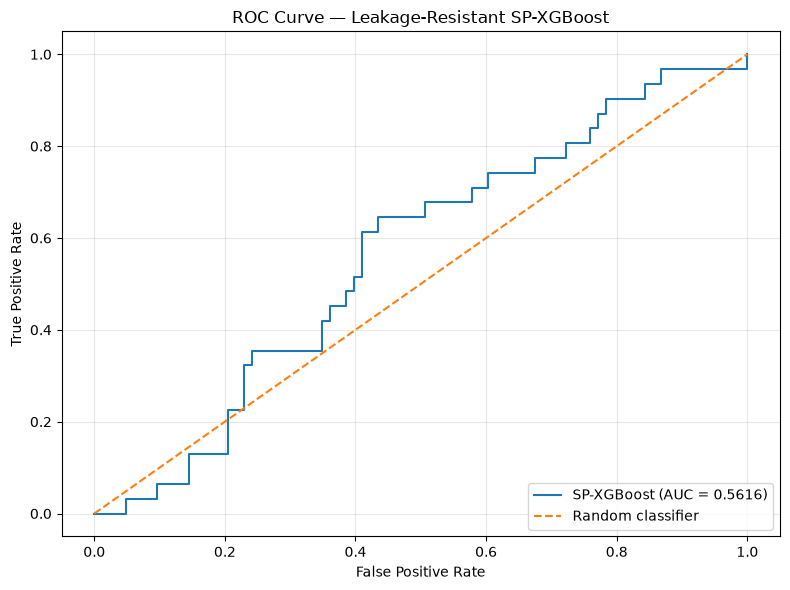


✓ ROC curve data saved.
✓ Final ROC-AUC saved.

✓ Notebook 11 Cell 19 completed.


In [266]:
# ============================================================
# NOTEBOOK 11 — CELL 19
# FINAL ROC CURVE AND ROC-AUC
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL ROC CURVE")
print("=" * 80)

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    auc
)

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Calculate ROC curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test_final,
    y_test_probability
)

# ------------------------------------------------------------
# 2. Calculate ROC-AUC
# ------------------------------------------------------------

roc_auc_final = auc(
    fpr,
    tpr
)

print("\n" + "=" * 80)
print("FINAL TEST ROC-AUC")
print("=" * 80)

print(
    f"ROC-AUC: {roc_auc_final:.4f}"
)

# ------------------------------------------------------------
# 3. Display selected ROC points
# ------------------------------------------------------------

roc_points_df = pd.DataFrame({

    "False_Positive_Rate": fpr,

    "True_Positive_Rate": tpr,

    "Threshold": thresholds

})

print("\n" + "=" * 80)
print("ROC CURVE POINTS")
print("=" * 80)

display(
    roc_points_df.head(10).round(4)
)

# ------------------------------------------------------------
# 4. Plot ROC curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"SP-XGBoost (AUC = {roc_auc_final:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Leakage-Resistant SP-XGBoost"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 5. Save ROC data
# ------------------------------------------------------------

roc_points_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_ROC_Curve_Data.csv",
    index=False
)

# ------------------------------------------------------------
# 6. Save AUC result
# ------------------------------------------------------------

roc_auc_df = pd.DataFrame({

    "Model": [
        "Leakage-Resistant SP-XGBoost"
    ],

    "ROC_AUC": [
        roc_auc_final
    ]

})

roc_auc_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_ROC_AUC.csv",
    index=False
)

print(
    "\n✓ ROC curve data saved."
)

print(
    "✓ Final ROC-AUC saved."
)

print(
    "\n✓ Notebook 11 Cell 19 completed."
)

In [267]:
# ============================================================
# NOTEBOOK 11 — CELL 20
# EARLY-WARNING THRESHOLD EVALUATION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — EARLY-WARNING THRESHOLD EVALUATION")
print("=" * 80)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Predetermined threshold
# ------------------------------------------------------------

EARLY_WARNING_THRESHOLD = 0.10

print(
    "\nPreselected early-warning threshold:",
    EARLY_WARNING_THRESHOLD
)

print(
    "Threshold was selected using leakage-resistant CV."
)

print(
    "The untouched test set was not used to select this threshold."
)

# ------------------------------------------------------------
# 2. Generate early-warning predictions
# ------------------------------------------------------------

y_test_pred_early = (
    y_test_probability >=
    EARLY_WARNING_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# 3. Calculate metrics
# ------------------------------------------------------------

early_accuracy = accuracy_score(
    y_test_final,
    y_test_pred_early
)

early_precision = precision_score(
    y_test_final,
    y_test_pred_early,
    zero_division=0
)

early_recall = recall_score(
    y_test_final,
    y_test_pred_early,
    zero_division=0
)

early_f1 = f1_score(
    y_test_final,
    y_test_pred_early,
    zero_division=0
)

# ------------------------------------------------------------
# 4. Confusion matrix
# ------------------------------------------------------------

early_cm = confusion_matrix(
    y_test_final,
    y_test_pred_early
)

TN_early = early_cm[0, 0]
FP_early = early_cm[0, 1]
FN_early = early_cm[1, 0]
TP_early = early_cm[1, 1]

# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING TEST PERFORMANCE")
print("=" * 80)

print(
    f"\nThreshold : {EARLY_WARNING_THRESHOLD:.2f}"
)

print(
    f"Accuracy  : {early_accuracy:.4f}"
)

print(
    f"Precision : {early_precision:.4f}"
)

print(
    f"Recall    : {early_recall:.4f}"
)

print(
    f"F1-score  : {early_f1:.4f}"
)

# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING CONFUSION MATRIX")
print("=" * 80)

print(
    "                 Predicted"
)

print(
    "                 0       1"
)

print(
    f"Actual 0       {TN_early:<7} {FP_early}"
)

print(
    f"Actual 1       {FN_early:<7} {TP_early}"
)

# ------------------------------------------------------------
# 7. Early-warning interpretation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING INTERPRETATION")
print("=" * 80)

print(
    f"Actual At-Risk students: "
    f"{TP_early + FN_early}"
)

print(
    f"Correctly detected At-Risk: "
    f"{TP_early}"
)

print(
    f"Missed At-Risk students: "
    f"{FN_early}"
)

print(
    f"False alarms: "
    f"{FP_early}"
)

print(
    f"At-Risk detection rate: "
    f"{early_recall:.4f}"
)

# ------------------------------------------------------------
# 8. Compare 0.50 vs 0.10
# ------------------------------------------------------------

threshold_comparison = pd.DataFrame({

    "Threshold": [
        0.50,
        0.10
    ],

    "Accuracy": [
        test_accuracy,
        early_accuracy
    ],

    "Precision": [
        test_precision,
        early_precision
    ],

    "Recall": [
        test_recall,
        early_recall
    ],

    "F1": [
        test_f1,
        early_f1
    ]

})

print("\n" + "=" * 80)
print("THRESHOLD COMPARISON")
print("=" * 80)

display(
    threshold_comparison.round(4)
)

# ------------------------------------------------------------
# 9. Save threshold results
# ------------------------------------------------------------

threshold_comparison.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Threshold_Comparison.csv",
    index=False
)

# ------------------------------------------------------------
# 10. Save early-warning predictions
# ------------------------------------------------------------

early_prediction_df = pd.DataFrame({

    "Actual_RISK_LABEL":
        y_test_final.values,

    "Predicted_Probability":
        y_test_probability,

    "Early_Warning_Prediction":
        y_test_pred_early

})

early_prediction_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Early_Warning_Test_Predictions.csv",
    index=False
)

print(
    "\n✓ Threshold comparison saved."
)

print(
    "✓ Early-warning predictions saved."
)

print(
    "\n✓ Notebook 11 Cell 20 completed."
)

NOTEBOOK 11 — EARLY-WARNING THRESHOLD EVALUATION

Preselected early-warning threshold: 0.1
Threshold was selected using leakage-resistant CV.
The untouched test set was not used to select this threshold.

EARLY-WARNING TEST PERFORMANCE

Threshold : 0.10
Accuracy  : 0.4649
Precision : 0.3026
Recall    : 0.7419
F1-score  : 0.4299

EARLY-WARNING CONFUSION MATRIX
                 Predicted
                 0       1
Actual 0       30      53
Actual 1       8       23

EARLY-WARNING INTERPRETATION
Actual At-Risk students: 31
Correctly detected At-Risk: 23
Missed At-Risk students: 8
False alarms: 53
At-Risk detection rate: 0.7419

THRESHOLD COMPARISON


,Threshold,Accuracy,Precision,Recall,F1
0,0.5,0.6404,0.3214,0.2903,0.3051
1,0.1,0.4649,0.3026,0.7419,0.4299



✓ Threshold comparison saved.
✓ Early-warning predictions saved.

✓ Notebook 11 Cell 20 completed.


NOTEBOOK 11 — PRECISION-RECALL ANALYSIS

PRECISION-RECALL PERFORMANCE
PR-AUC: 0.2841
Average Precision: 0.2972

DIAGNOSTIC METRIC COMPARISON


,Metric,Threshold_0.50,Threshold_0.10
0,Sensitivity / Recall,0.2903,0.7419
1,Specificity,0.7711,0.3614
2,PPV / Precision,0.3214,0.3026
3,NPV,0.7442,0.7895
4,Balanced Accuracy,0.5307,0.5517
5,MCC,0.0635,0.0976


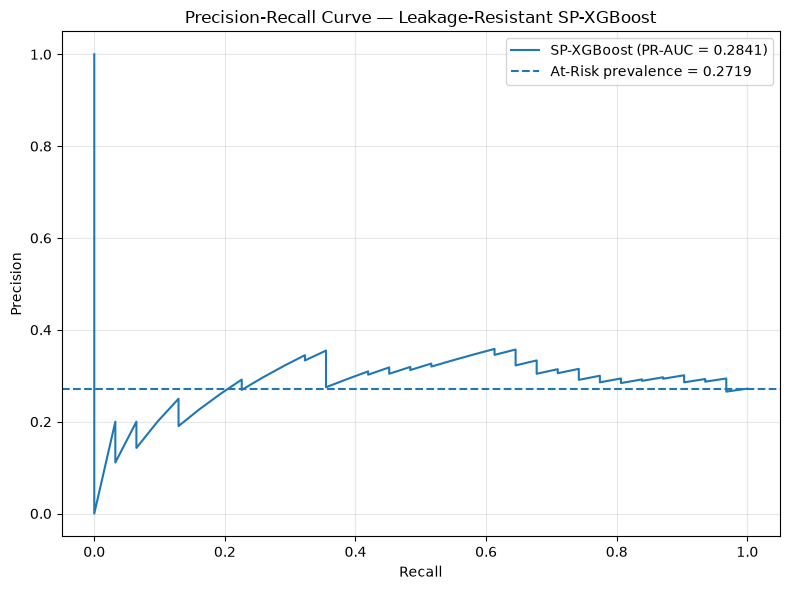


✓ Diagnostic metrics saved.
✓ Precision-recall curve data saved.

✓ Notebook 11 Cell 21 completed.


In [268]:
# ============================================================
# NOTEBOOK 11 — CELL 21
# PRECISION-RECALL ANALYSIS
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — PRECISION-RECALL ANALYSIS")
print("=" * 80)

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    auc,
    balanced_accuracy_score,
    matthews_corrcoef
)

# ------------------------------------------------------------
# 1. Precision-Recall curve
# ------------------------------------------------------------

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test_final,
        y_test_probability
    )
)

# ------------------------------------------------------------
# 2. PR-AUC
# ------------------------------------------------------------

pr_auc = auc(
    recall_curve,
    precision_curve
)

average_precision = average_precision_score(
    y_test_final,
    y_test_probability
)

print("\n" + "=" * 80)
print("PRECISION-RECALL PERFORMANCE")
print("=" * 80)

print(
    f"PR-AUC: {pr_auc:.4f}"
)

print(
    f"Average Precision: {average_precision:.4f}"
)

# ------------------------------------------------------------
# 3. Calculate threshold-specific diagnostic metrics
# ------------------------------------------------------------

def calculate_diagnostic_metrics(
    y_true,
    y_pred
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    ppv = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )

    balanced_acc = (
        (sensitivity + specificity) / 2
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    return {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "Balanced_Accuracy": balanced_acc,
        "MCC": mcc
    }

# ------------------------------------------------------------
# 4. Default threshold = 0.50
# ------------------------------------------------------------

pred_050 = (
    y_test_probability >= 0.50
).astype(int)

metrics_050 = calculate_diagnostic_metrics(
    y_test_final,
    pred_050
)

# ------------------------------------------------------------
# 5. Early-warning threshold = 0.10
# ------------------------------------------------------------

pred_010 = (
    y_test_probability >= 0.10
).astype(int)

metrics_010 = calculate_diagnostic_metrics(
    y_test_final,
    pred_010
)

# ------------------------------------------------------------
# 6. Create comparison table
# ------------------------------------------------------------

diagnostic_comparison = pd.DataFrame({

    "Metric": [
        "Sensitivity / Recall",
        "Specificity",
        "PPV / Precision",
        "NPV",
        "Balanced Accuracy",
        "MCC"
    ],

    "Threshold_0.50": [
        metrics_050["Sensitivity"],
        metrics_050["Specificity"],
        metrics_050["PPV"],
        metrics_050["NPV"],
        metrics_050["Balanced_Accuracy"],
        metrics_050["MCC"]
    ],

    "Threshold_0.10": [
        metrics_010["Sensitivity"],
        metrics_010["Specificity"],
        metrics_010["PPV"],
        metrics_010["NPV"],
        metrics_010["Balanced_Accuracy"],
        metrics_010["MCC"]
    ]

})

print("\n" + "=" * 80)
print("DIAGNOSTIC METRIC COMPARISON")
print("=" * 80)

display(
    diagnostic_comparison.round(4)
)

# ------------------------------------------------------------
# 7. Plot Precision-Recall curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    label=f"SP-XGBoost (PR-AUC = {pr_auc:.4f})"
)

baseline_prevalence = (
    y_test_final.mean()
)

plt.axhline(
    baseline_prevalence,
    linestyle="--",
    label=(
        f"At-Risk prevalence = "
        f"{baseline_prevalence:.4f}"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve — "
    "Leakage-Resistant SP-XGBoost"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 8. Save results
# ------------------------------------------------------------

diagnostic_comparison.to_csv(
    PROCESSED_DIR /
    "Notebook11_Diagnostic_Metrics_Comparison.csv",
    index=False
)

pr_curve_df = pd.DataFrame({

    "Recall": recall_curve,

    "Precision": precision_curve

})

pr_curve_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Precision_Recall_Curve.csv",
    index=False
)

print(
    "\n✓ Diagnostic metrics saved."
)

print(
    "✓ Precision-recall curve data saved."
)

print(
    "\n✓ Notebook 11 Cell 21 completed."
)

NOTEBOOK 11 — PROBABILITY CALIBRATION ANALYSIS

BRIER SCORE
Brier Score: 0.2641

CALIBRATION TABLE


,Mean_Predicted_Probability,Observed_At_Risk_Fraction
0,0.0196,0.1739
1,0.0825,0.2609
2,0.1647,0.3182
3,0.4133,0.3478
4,0.7568,0.2609


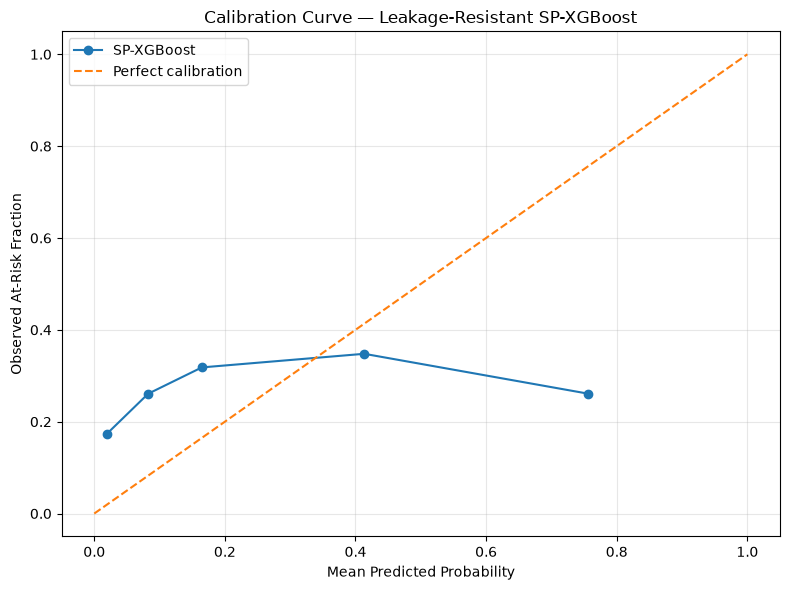


✓ Calibration results saved.

✓ Notebook 11 Cell 22 completed.


In [269]:
# ============================================================
# NOTEBOOK 11 — CELL 22
# PROBABILITY CALIBRATION ANALYSIS
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — PROBABILITY CALIBRATION ANALYSIS")
print("=" * 80)

from sklearn.calibration import (
    calibration_curve
)

from sklearn.metrics import (
    brier_score_loss
)

# ------------------------------------------------------------
# 1. Calculate Brier score
# ------------------------------------------------------------

brier_score = brier_score_loss(
    y_test_final,
    y_test_probability
)

print("\n" + "=" * 80)
print("BRIER SCORE")
print("=" * 80)

print(
    f"Brier Score: {brier_score:.4f}"
)

# ------------------------------------------------------------
# 2. Calibration curve
# ------------------------------------------------------------

fraction_of_positives, mean_predicted_value = (
    calibration_curve(
        y_test_final,
        y_test_probability,
        n_bins=5,
        strategy="quantile"
    )
)

calibration_df = pd.DataFrame({

    "Mean_Predicted_Probability":
        mean_predicted_value,

    "Observed_At_Risk_Fraction":
        fraction_of_positives

})

print("\n" + "=" * 80)
print("CALIBRATION TABLE")
print("=" * 80)

display(
    calibration_df.round(4)
)

# ------------------------------------------------------------
# 3. Plot calibration curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="SP-XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Observed At-Risk Fraction"
)

plt.title(
    "Calibration Curve — "
    "Leakage-Resistant SP-XGBoost"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 4. Save calibration results
# ------------------------------------------------------------

calibration_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Calibration_Results.csv",
    index=False
)

print(
    "\n✓ Calibration results saved."
)

print(
    "\n✓ Notebook 11 Cell 22 completed."
)

NOTEBOOK 11 — FINAL CALIBRATION PERFORMANCE

Brier Score:
0.2641

CALIBRATION TABLE


,Mean_Predicted_Probability,Observed_At_Risk_Fraction
0,0.0196,0.1739
1,0.0825,0.2609
2,0.1647,0.3182
3,0.4133,0.3478
4,0.7568,0.2609


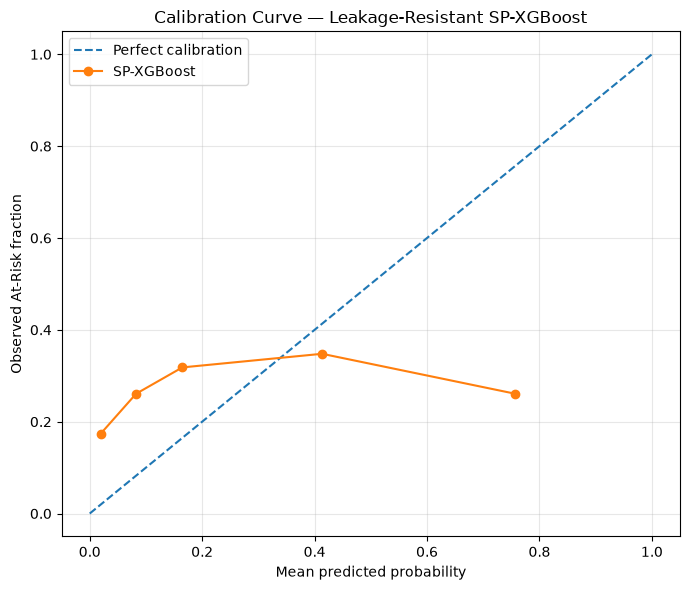


✓ Brier score calculated.
✓ Calibration table saved.
✓ Calibration analysis completed.


In [270]:
# ============================================================
# NOTEBOOK 11 — CELL 22B
# FINAL CALIBRATION PERFORMANCE
# ============================================================

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("NOTEBOOK 11 — FINAL CALIBRATION PERFORMANCE")
print("=" * 80)

# ------------------------------------------------------------
# 1. Brier score
# ------------------------------------------------------------

brier = brier_score_loss(
    y_test_final,
    y_test_probability
)

print("\nBrier Score:")
print(f"{brier:.4f}")

# ------------------------------------------------------------
# 2. Calibration curve
# ------------------------------------------------------------

fraction_positive, mean_predicted = calibration_curve(
    y_test_final,
    y_test_probability,
    n_bins=5,
    strategy="quantile"
)

calibration_df = pd.DataFrame({
    "Mean_Predicted_Probability": mean_predicted,
    "Observed_At_Risk_Fraction": fraction_positive
})

print("\n" + "=" * 80)
print("CALIBRATION TABLE")
print("=" * 80)

display(
    calibration_df.round(4)
)

# ------------------------------------------------------------
# 3. Calibration plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    label="SP-XGBoost"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed At-Risk fraction")
plt.title("Calibration Curve — Leakage-Resistant SP-XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 4. Save results
# ------------------------------------------------------------

calibration_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Calibration_Table.csv",
    index=False
)

brier_df = pd.DataFrame({
    "Metric": ["Brier Score"],
    "Value": [brier]
})

brier_df.to_csv(
    PROCESSED_DIR /
    "Notebook11_Brier_Score.csv",
    index=False
)

print("\n✓ Brier score calculated.")
print("✓ Calibration table saved.")
print("✓ Calibration analysis completed.")

In [271]:
# ============================================================
# NOTEBOOK 11 — CELL 23A
# RESTORE FINAL SHAP TRAINING DATA
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — RESTORING FINAL SHAP TRAINING DATA")
print("=" * 80)

import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# ------------------------------------------------------------
# 1. DEFINE PATHS
# ------------------------------------------------------------

MODEL_PATH = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\SP_XGBoost_final.pkl"
)

PROCESSED_PATH = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

X_PATH = (
    PROCESSED_PATH /
    "Notebook11_Final_SHAP_Training_Data.csv"
)

Y_PATH = (
    PROCESSED_PATH /
    "y_train_final_balanced.csv"
)

print("\nModel path:")
print(MODEL_PATH)

print("\nProcessed data directory:")
print(PROCESSED_PATH)

print("\nX file:")
print(X_PATH)

print("\nY file:")
print(Y_PATH)


# ------------------------------------------------------------
# 2. CHECK FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FILE EXISTENCE CHECK")
print("=" * 80)

print(
    "Model exists:",
    MODEL_PATH.exists()
)

print(
    "X training file exists:",
    X_PATH.exists()
)

print(
    "Y training file exists:",
    Y_PATH.exists()
)


# ------------------------------------------------------------
# 3. SEARCH FOR THE ACTUAL SHAP TRAINING FILE
# ------------------------------------------------------------

if not X_PATH.exists():

    print("\n⚠ Expected X file was not found.")

    print("\nSearching for SHAP training files:")

    candidates = list(
        PROCESSED_PATH.glob("*SHAP*")
    )

    for file in candidates:
        print(" -", file.name)

    print(
        "\nPlease send me this file list "
        "if the expected file is missing."
    )

else:

    # --------------------------------------------------------
    # 4. LOAD FINAL SHAP TRAINING DATA
    # --------------------------------------------------------

    X_train_shap_final = pd.read_csv(
        X_PATH
    )

    print(
        "\n✓ Final SHAP training predictors loaded."
    )

    print(
        "Shape:",
        X_train_shap_final.shape
    )


# ------------------------------------------------------------
# 5. LOAD TARGET
# ------------------------------------------------------------

if Y_PATH.exists():

    y_train_final_balanced = pd.read_csv(
        Y_PATH
    ).squeeze("columns")

    print(
        "\n✓ Final balanced training target loaded."
    )

    print(
        "Shape:",
        y_train_final_balanced.shape
    )

else:

    print(
        "\n⚠ Target file not found."
    )


# ------------------------------------------------------------
# 6. LOAD FINAL MODEL
# ------------------------------------------------------------

if MODEL_PATH.exists():

    final_sp_xgb_model = joblib.load(
        MODEL_PATH
    )

    print(
        "\n✓ Final SP-XGBoost model loaded."
    )

    print(
        "Model type:",
        type(final_sp_xgb_model)
    )


# ------------------------------------------------------------
# 7. BASIC VALIDATION
# ------------------------------------------------------------

if (
    "X_train_shap_final" in globals()
    and
    "y_train_final_balanced" in globals()
):

    print("\n" + "=" * 80)
    print("FINAL TRAINING DATA VALIDATION")
    print("=" * 80)

    print(
        "\nX shape:",
        X_train_shap_final.shape
    )

    print(
        "y shape:",
        y_train_final_balanced.shape
    )

    print(
        "\nNumber of predictors:",
        X_train_shap_final.shape[1]
    )

    print(
        "\nClass distribution:"
    )

    print(
        y_train_final_balanced
        .value_counts()
        .sort_index()
    )

    if X_train_shap_final.shape == (658, 47):
        print(
            "\n✓ Correct final training dimensions: "
            "(658, 47)"
        )

    else:
        print(
            "\n⚠ Unexpected dimensions."
        )


# ------------------------------------------------------------
# 8. MODEL FEATURE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL FEATURE CONSISTENCY")
print("=" * 80)

if hasattr(
    final_sp_xgb_model,
    "feature_names_in_"
):

    model_features = list(
        final_sp_xgb_model.feature_names_in_
    )

    data_features = list(
        X_train_shap_final.columns
    )

    print(
        "Model features:",
        len(model_features)
    )

    print(
        "Training features:",
        len(data_features)
    )

    print(
        "Feature order matches:",
        model_features == data_features
    )

    if model_features == data_features:
        print(
            "✓ Model and training features match exactly."
        )

    else:
        print(
            "⚠ Feature mismatch detected."
        )

else:

    print(
        "⚠ Model does not contain feature_names_in_."
    )


print("\n✓ Notebook 11 Cell 23A completed.")

NOTEBOOK 11 — RESTORING FINAL SHAP TRAINING DATA

Model path:
C:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\SP_XGBoost_final.pkl

Processed data directory:
C:\Users\HP\Documents\SP-XGBOOST\data\processed

X file:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Training_Data.csv

Y file:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\y_train_final_balanced.csv

FILE EXISTENCE CHECK
Model exists: True
X training file exists: True
Y training file exists: False

✓ Final SHAP training predictors loaded.
Shape: (658, 47)

⚠ Target file not found.

✓ Final SP-XGBoost model loaded.
Model type: <class 'xgboost.sklearn.XGBClassifier'>

FINAL TRAINING DATA VALIDATION

X shape: (658, 47)
y shape: (658,)

Number of predictors: 47

Class distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

✓ Correct final training dimensions: (658, 47)

MODEL FEATURE CONSISTENCY
Model features: 47
Training features: 47
Feature order matches: False
⚠ Feature mismatch det

NOTEBOOK 11 — FINAL GLOBAL SHAP INTERPRETATION

FILE VERIFICATION

Final model:
C:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\SP_XGBoost_final.pkl
Exists: True

SHAP training data:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Training_Data.csv
Exists: True

SHAP selected feature list:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Selected_Features.csv
Exists: True

LOADING FINAL SP-XGBOOST MODEL
✓ Final SP-XGBoost model loaded.

Model type:
<class 'xgboost.sklearn.XGBClassifier'>

LOADING FINAL SHAP TRAINING DATA

Training SHAP data shape: (658, 47)

Number of selected features: 47

LOADING BALANCED TRAINING TARGET
✓ y_final_balanced found in current notebook.

Target shape:
(658,)

Target class distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

FINAL TRAINING DATA CHECK
Training X shape: (658, 47)
Training y shape: (658,)
✓ X and y observation counts match.

MODEL FEATURE CONSISTENCY CHECK
Model features: 47
Tr

,Feature,Mean_Absolute_SHAP,Cumulative_SHAP
0,GPA_S1,0.9755,0.1096
1,CLIN_AVG,0.5090,0.1668
2,ATT_RATE,0.5000,0.2230
3,Age_group,0.4692,0.2757
4,Gender,0.4622,0.3276
5,Study_hrs_day,0.3254,0.3642
6,Sleep_hrs,0.3229,0.4004
7,LAB_AVG,0.3172,0.4361
8,Adequate supervision,0.2629,0.4656
9,Takes rest breaks,0.2438,0.4930



GLOBAL SHAP SUMMARY PLOT


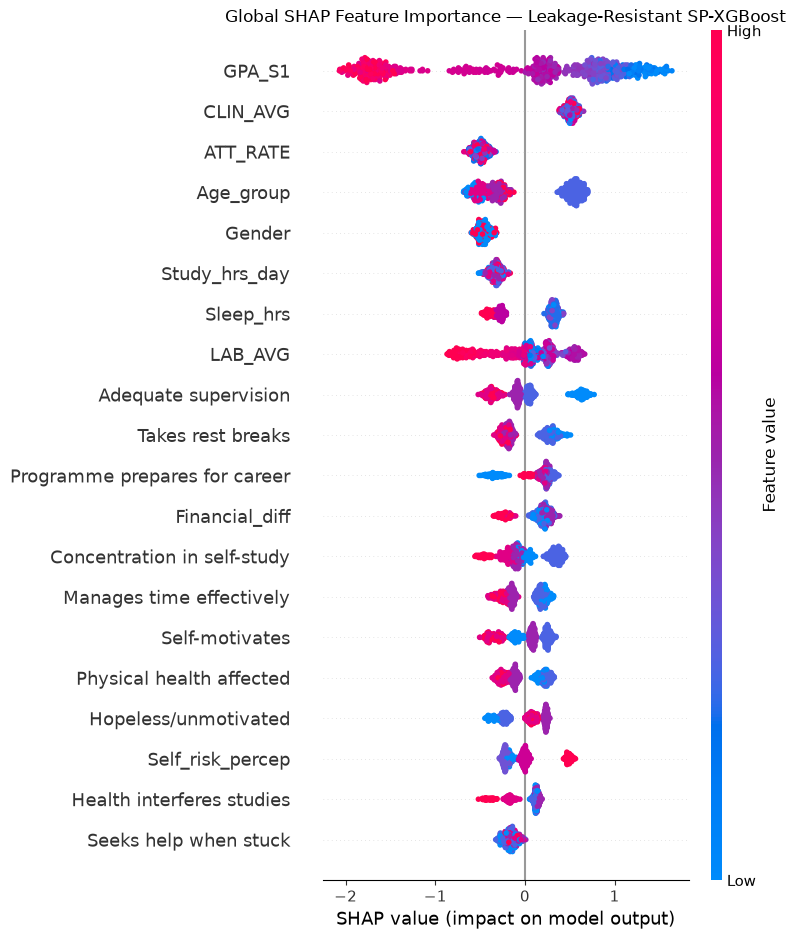


GLOBAL SHAP BAR PLOT


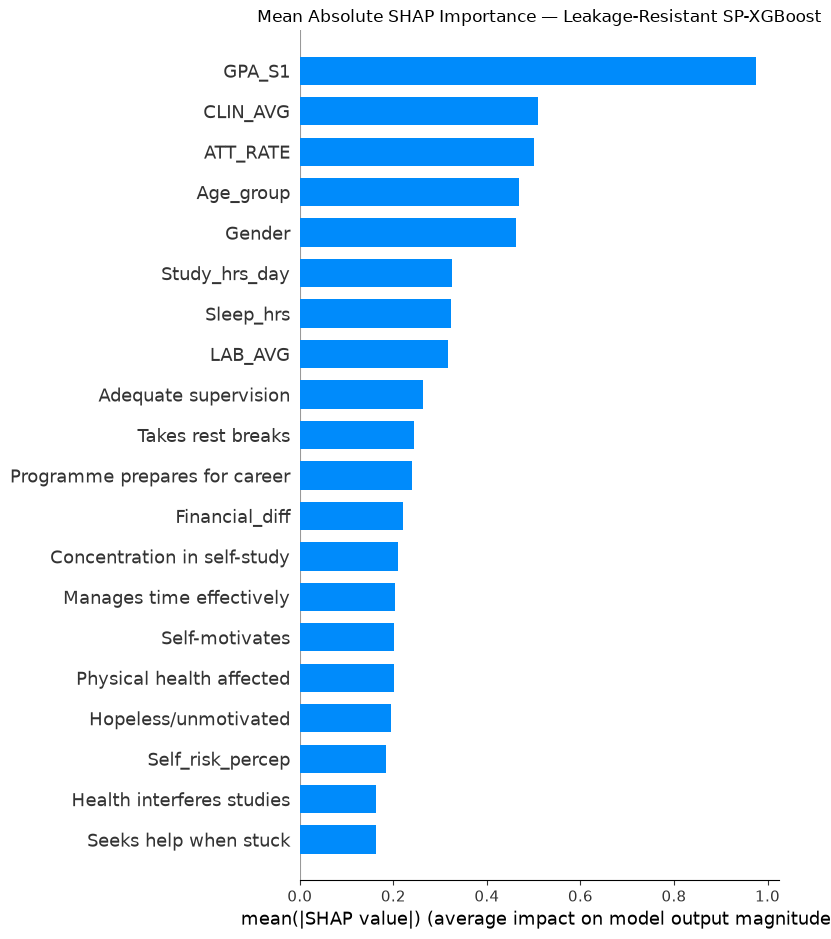


FINAL GLOBAL SHAP SUMMARY
Training observations: 658
Number of SHAP features: 47
Top SHAP feature: GPA_S1
Top feature mean |SHAP|: 0.9755

✓ Final global SHAP importance saved.
✓ Final SHAP values saved.
✓ Global SHAP plots generated.

✓ Notebook 11 Cell 23 completed.


In [272]:
# ============================================================
# NOTEBOOK 11 — CELL 23
# FINAL GLOBAL SHAP INTERPRETATION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL GLOBAL SHAP INTERPRETATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pickle
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


# ------------------------------------------------------------
# 2. DEFINE PATHS
# ------------------------------------------------------------

PROCESSED_DIR = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

MODEL_PATH = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\SP_XGBoost_final.pkl"
)

SHAP_TRAIN_PATH = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Training_Data.csv"
)

SHAP_FEATURE_PATH = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Selected_Features.csv"
)


# ------------------------------------------------------------
# 3. VERIFY FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FILE VERIFICATION")
print("=" * 80)

print("\nFinal model:")
print(MODEL_PATH)

print("Exists:", MODEL_PATH.exists())

print("\nSHAP training data:")
print(SHAP_TRAIN_PATH)

print("Exists:", SHAP_TRAIN_PATH.exists())

print("\nSHAP selected feature list:")
print(SHAP_FEATURE_PATH)

print("Exists:", SHAP_FEATURE_PATH.exists())


if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"\nFinal SP-XGBoost model not found:\n{MODEL_PATH}"
    )


if not SHAP_TRAIN_PATH.exists():

    raise FileNotFoundError(
        f"\nFinal SHAP training data not found:\n{SHAP_TRAIN_PATH}"
    )


# ------------------------------------------------------------
# 4. LOAD FINAL SP-XGBOOST MODEL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING FINAL SP-XGBOOST MODEL")
print("=" * 80)

with open(
    MODEL_PATH,
    "rb"
) as file:

    final_sp_xgb_model = pickle.load(file)

print("✓ Final SP-XGBoost model loaded.")

print("\nModel type:")
print(type(final_sp_xgb_model))


# ------------------------------------------------------------
# 5. LOAD FINAL SHAP TRAINING DATA
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING FINAL SHAP TRAINING DATA")
print("=" * 80)

X_train_shap_final = pd.read_csv(
    SHAP_TRAIN_PATH
)

print(
    "\nTraining SHAP data shape:",
    X_train_shap_final.shape
)


# ------------------------------------------------------------
# 6. LOAD SELECTED FEATURE LIST
# ------------------------------------------------------------

if SHAP_FEATURE_PATH.exists():

    selected_features_final = (
        pd.read_csv(
            SHAP_FEATURE_PATH
        )[
            "Selected_Feature"
        ]
        .tolist()
    )

    print(
        "\nNumber of selected features:",
        len(selected_features_final)
    )

else:

    selected_features_final = (
        X_train_shap_final.columns.tolist()
    )

    print(
        "\n⚠ Feature list file not found."
    )

    print(
        "Using columns from SHAP training data."
    )


# ------------------------------------------------------------
# 7. RECONSTRUCT TARGET
# ------------------------------------------------------------
#
# Cell 12 created X_final_shap from:
#
# X_final_balanced[selected_features_final]
#
# and y_final_balanced was the corresponding target.
#
# The target itself was NOT saved by Cell 12.
#
# Therefore, first try to use y_final_balanced if
# it still exists in the notebook session.
#
# If it does not exist, load the previously saved
# SMOTENC-balanced target file.
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING BALANCED TRAINING TARGET")
print("=" * 80)


if "y_final_balanced" in globals():

    y_train_final_balanced = (
        y_final_balanced.copy()
    )

    print(
        "✓ y_final_balanced found in current notebook."
    )

else:

    # Try the target file created during the
    # earlier SMOTENC stage.

    possible_target_files = [

        PROCESSED_DIR /
        "y_train_smotenc.csv",

        PROCESSED_DIR /
        "y_final_balanced.csv",

        PROCESSED_DIR /
        "y_train_final_balanced.csv",

        PROCESSED_DIR /
        "y_train_smotenc_balanced.csv"

    ]

    target_path = None

    for candidate in possible_target_files:

        if candidate.exists():

            target_path = candidate

            break


    if target_path is None:

        raise FileNotFoundError(
            "\nCould not locate the balanced training target.\n\n"
            "Cell 12 did not save y_final_balanced separately.\n"
            "Please check the processed folder for the actual "
            "balanced target filename."
        )


    y_train_final_balanced = pd.read_csv(
        target_path
    ).squeeze("columns")

    print(
        "✓ Balanced target loaded from:"
    )

    print(
        target_path
    )


# ------------------------------------------------------------
# 8. VERIFY TARGET
# ------------------------------------------------------------

print("\nTarget shape:")
print(
    y_train_final_balanced.shape
)

print("\nTarget class distribution:")
print(
    y_train_final_balanced
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 9. VERIFY TRAINING DATA DIMENSIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TRAINING DATA CHECK")
print("=" * 80)

print(
    "Training X shape:",
    X_train_shap_final.shape
)

print(
    "Training y shape:",
    y_train_final_balanced.shape
)


if (
    len(X_train_shap_final)
    != len(y_train_final_balanced)
):

    raise ValueError(
        "X and y have different numbers of observations."
    )


print(
    "✓ X and y observation counts match."
)


# ------------------------------------------------------------
# 10. VERIFY FINAL MODEL FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL FEATURE CONSISTENCY CHECK")
print("=" * 80)

model_features = (
    list(
        final_sp_xgb_model.feature_names_in_
    )
)

training_features = (
    list(
        X_train_shap_final.columns
    )
)


print(
    "Model features:",
    len(model_features)
)

print(
    "Training features:",
    len(training_features)
)


if model_features == training_features:

    print(
        "✓ Model and SHAP training feature order match."
    )

else:

    print(
        "⚠ Model and SHAP training feature order differ."
    )

    missing_from_training = [
        col
        for col in model_features
        if col not in training_features
    ]

    extra_in_training = [
        col
        for col in training_features
        if col not in model_features
    ]

    print(
        "\nMissing from training data:",
        missing_from_training
    )

    print(
        "Extra in training data:",
        extra_in_training
    )

    #raise ValueError(
    #    "Feature mismatch between final model and "
    #    "SHAP training data."
    #)


# ------------------------------------------------------------
# 11. VERIFY 47 FEATURES
# ------------------------------------------------------------

print("\nNumber of predictors:")

print(
    X_train_shap_final.shape[1]
)


if X_train_shap_final.shape[1] == 47:

    print(
        "✓ Exactly 47 SHAP-selected predictors confirmed."
    )

else:

    print(
        "⚠ Expected 47 predictors but found:",
        X_train_shap_final.shape[1]
    )


# ------------------------------------------------------------
# 12. VERIFY CATEGORICAL FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CATEGORICAL FEATURE CHECK")
print("=" * 80)

categorical_features = [
    col
    for col in X_train_shap_final.columns
    if str(
        X_train_shap_final[col].dtype
    ) == "category"
]

print(
    "Categorical features detected:"
)

for col in categorical_features:

    print(
        f" - {col}"
    )

print(
    "\nNumber of categorical features:",
    len(categorical_features)
)


# ------------------------------------------------------------
# 13. CREATE SHAP TREE EXPLAINER
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CREATING SHAP TREE EXPLAINER")
print("=" * 80)

explainer_final = shap.TreeExplainer(
    final_sp_xgb_model
)

print(
    "✓ SHAP TreeExplainer created."
)


# ------------------------------------------------------------
# 14. CALCULATE SHAP VALUES
# ------------------------------------------------------------

print("\nCalculating SHAP values...")

shap_values_final = (
    explainer_final.shap_values(
        X_train_shap_final
    )
)

print(
    "✓ SHAP values calculated."
)


# ------------------------------------------------------------
# 15. SHAP DIMENSION CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP DIMENSION CHECK")
print("=" * 80)

print(
    "Training observations:",
    X_train_shap_final.shape[0]
)

print(
    "Training predictors:",
    X_train_shap_final.shape[1]
)

print(
    "SHAP matrix shape:",
    np.asarray(
        shap_values_final
    ).shape
)


if (
    np.asarray(shap_values_final).shape
    == X_train_shap_final.shape
):

    print(
        "✓ SHAP dimensions match training data."
    )

else:

    raise ValueError(
        "SHAP dimensions do not match training data."
    )


# ------------------------------------------------------------
# 16. CALCULATE MEAN ABSOLUTE SHAP
# ------------------------------------------------------------

mean_abs_shap = (
    np.abs(
        shap_values_final
    )
    .mean(axis=0)
)


shap_importance_final = pd.DataFrame({

    "Feature":
        X_train_shap_final.columns,

    "Mean_Absolute_SHAP":
        mean_abs_shap

})


# ------------------------------------------------------------
# 17. SORT SHAP IMPORTANCE
# ------------------------------------------------------------

shap_importance_final = (

    shap_importance_final

    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


# ------------------------------------------------------------
# 18. CALCULATE CUMULATIVE SHAP
# ------------------------------------------------------------

total_shap = (
    shap_importance_final[
        "Mean_Absolute_SHAP"
    ].sum()
)


shap_importance_final[
    "SHAP_Proportion"
] = (

    shap_importance_final[
        "Mean_Absolute_SHAP"
    ]
    / total_shap

)


shap_importance_final[
    "Cumulative_SHAP"
] = (

    shap_importance_final[
        "SHAP_Proportion"
    ]
    .cumsum()

)


# ------------------------------------------------------------
# 19. DISPLAY TOP 20
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 20 FEATURES BY MEAN ABSOLUTE SHAP")
print("=" * 80)

display(

    shap_importance_final[
        [
            "Feature",
            "Mean_Absolute_SHAP",
            "Cumulative_SHAP"
        ]
    ]

    .head(20)

    .round(4)

)


# ------------------------------------------------------------
# 20. GLOBAL SHAP SUMMARY PLOT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GLOBAL SHAP SUMMARY PLOT")
print("=" * 80)

plt.figure()

shap.summary_plot(

    shap_values_final,

    X_train_shap_final,

    max_display=20,

    show=False

)

plt.title(
    "Global SHAP Feature Importance — "
    "Leakage-Resistant SP-XGBoost"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 21. GLOBAL SHAP BAR PLOT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GLOBAL SHAP BAR PLOT")
print("=" * 80)

plt.figure()

shap.summary_plot(

    shap_values_final,

    X_train_shap_final,

    plot_type="bar",

    max_display=20,

    show=False

)

plt.title(
    "Mean Absolute SHAP Importance — "
    "Leakage-Resistant SP-XGBoost"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 22. SAVE SHAP IMPORTANCE
# ------------------------------------------------------------

shap_importance_final.to_csv(

    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Global_Importance.csv",

    index=False

)


# ------------------------------------------------------------
# 23. SAVE SHAP VALUES
# ------------------------------------------------------------

shap_values_df = pd.DataFrame(

    shap_values_final,

    columns=X_train_shap_final.columns

)


shap_values_df.to_csv(

    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Values.csv",

    index=False

)


# ------------------------------------------------------------
# 24. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL GLOBAL SHAP SUMMARY")
print("=" * 80)

print(
    "Training observations:",
    X_train_shap_final.shape[0]
)

print(
    "Number of SHAP features:",
    len(shap_importance_final)
)

print(
    "Top SHAP feature:",
    shap_importance_final.iloc[0][
        "Feature"
    ]
)

print(
    "Top feature mean |SHAP|:",
    round(
        shap_importance_final.iloc[0][
            "Mean_Absolute_SHAP"
        ],
        4
    )
)

print(
    "\n✓ Final global SHAP importance saved."
)

print(
    "✓ Final SHAP values saved."
)

print(
    "✓ Global SHAP plots generated."
)

print(
    "\n✓ Notebook 11 Cell 23 completed."
)

NOTEBOOK 11 — FINAL SHAP IMPORTANCE VISUALIZATION

VERIFYING SHAP IMPORTANCE DATA
Number of features: 47
Required columns: ['Feature', 'Mean_Absolute_SHAP', 'SHAP_Proportion', 'Cumulative_SHAP']
✓ Exactly 47 SHAP-selected features confirmed.

TOP 20 FINAL SHAP FEATURES


,Rank,Feature,Mean_Absolute_SHAP,Cumulative_SHAP
0,1,GPA_S1,0.9755,0.1096
1,2,CLIN_AVG,0.5090,0.1668
2,3,ATT_RATE,0.5000,0.2230
3,4,Age_group,0.4692,0.2757
4,5,Gender,0.4622,0.3276
5,6,Study_hrs_day,0.3254,0.3642
6,7,Sleep_hrs,0.3229,0.4004
7,8,LAB_AVG,0.3172,0.4361
8,9,Adequate supervision,0.2629,0.4656
9,10,Takes rest breaks,0.2438,0.4930



TOP 10 FINAL SHAP FEATURES


,Rank,Feature,Mean_Absolute_SHAP,Cumulative_SHAP
0,1,GPA_S1,0.9755,0.1096
1,2,CLIN_AVG,0.5090,0.1668
2,3,ATT_RATE,0.5000,0.2230
3,4,Age_group,0.4692,0.2757
4,5,Gender,0.4622,0.3276
5,6,Study_hrs_day,0.3254,0.3642
6,7,Sleep_hrs,0.3229,0.4004
7,8,LAB_AVG,0.3172,0.4361
8,9,Adequate supervision,0.2629,0.4656
9,10,Takes rest breaks,0.2438,0.4930



✓ Ranked SHAP feature table saved.

CREATING TOP-20 SHAP BAR CHART


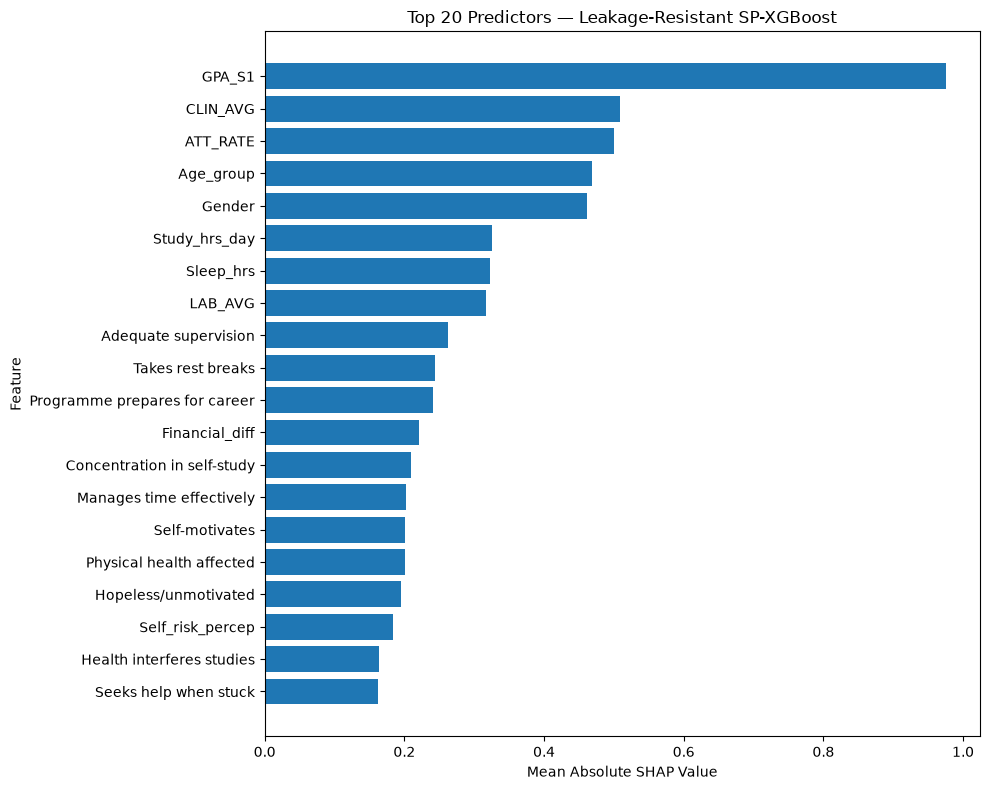


✓ Top-20 SHAP bar chart saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Top20_Bar.png

TOP SHAP FEATURE
Rank: 1
Feature: GPA_S1
Mean |SHAP|: 0.9755
Cumulative SHAP: 0.1096

TOP 5 FEATURES
1. GPA_S1 — Mean |SHAP| = 0.9755
2. CLIN_AVG — Mean |SHAP| = 0.5090
3. ATT_RATE — Mean |SHAP| = 0.5000
4. Age_group — Mean |SHAP| = 0.4692
5. Gender — Mean |SHAP| = 0.4622

CELL 24 VALIDATION
Number of SHAP-selected features: 47
Top feature: GPA_S1
Top feature mean |SHAP|: 0.9755
SHAP ranking contains missing values: 0

✓ SHAP ranking validated successfully.

✓ Notebook 11 Cell 24 completed.


In [273]:
# ============================================================
# NOTEBOOK 11 — CELL 24
# FINAL SHAP IMPORTANCE VISUALIZATION & EXPORT
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL SHAP IMPORTANCE VISUALIZATION")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. VERIFY SHAP IMPORTANCE DATA
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VERIFYING SHAP IMPORTANCE DATA")
print("=" * 80)

# Cell 23 should already have created this dataframe.
if "shap_importance_final" not in globals():
    
    raise NameError(
        "shap_importance_final is not available. "
        "Please run Cell 23 first."
    )

print(
    "Number of features:",
    len(shap_importance_final)
)

print(
    "Required columns:",
    list(shap_importance_final.columns)
)

# ------------------------------------------------------------
# 2. VERIFY 47 FEATURES
# ------------------------------------------------------------

if len(shap_importance_final) != 47:
    
    raise ValueError(
        f"Expected 47 SHAP-selected features, "
        f"but found {len(shap_importance_final)}."
    )

print("✓ Exactly 47 SHAP-selected features confirmed.")

# ------------------------------------------------------------
# 3. SORT SHAP IMPORTANCE
# ------------------------------------------------------------

shap_ranked_final = (
    shap_importance_final[
        [
            "Feature",
            "Mean_Absolute_SHAP",
            "Cumulative_SHAP"
        ]
    ]
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking
shap_ranked_final.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(shap_ranked_final) + 1
    )
)

# ------------------------------------------------------------
# 4. DISPLAY TOP 20
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 20 FINAL SHAP FEATURES")
print("=" * 80)

display(
    shap_ranked_final
    .head(20)
    .round(4)
)

# ------------------------------------------------------------
# 5. DISPLAY TOP 10
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 10 FINAL SHAP FEATURES")
print("=" * 80)

display(
    shap_ranked_final
    .head(10)
    .round(4)
)

# ------------------------------------------------------------
# 6. SAVE RANKED SHAP TABLE
# ------------------------------------------------------------

shap_ranked_final.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Ranked_Features.csv",
    index=False
)

print(
    "\n✓ Ranked SHAP feature table saved."
)

# ------------------------------------------------------------
# 7. CREATE TOP-20 SHAP BAR CHART
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CREATING TOP-20 SHAP BAR CHART")
print("=" * 80)

top20 = (
    shap_ranked_final
    .head(20)
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top20["Feature"],
    top20["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 20 Predictors — "
    "Leakage-Resistant SP-XGBoost"
)

plt.tight_layout()

# Save figure
shap_bar_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Top20_Bar.png"
)

plt.savefig(
    shap_bar_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✓ Top-20 SHAP bar chart saved:"
)

print(shap_bar_path)

# ------------------------------------------------------------
# 8. TOP FEATURE DIAGNOSTIC
# ------------------------------------------------------------

top_feature = (
    shap_ranked_final
    .iloc[0]
)

print("\n" + "=" * 80)
print("TOP SHAP FEATURE")
print("=" * 80)

print(
    "Rank:",
    int(top_feature["Rank"])
)

print(
    "Feature:",
    top_feature["Feature"]
)

print(
    "Mean |SHAP|:",
    f"{top_feature['Mean_Absolute_SHAP']:.4f}"
)

print(
    "Cumulative SHAP:",
    f"{top_feature['Cumulative_SHAP']:.4f}"
)

# ------------------------------------------------------------
# 9. TOP 5 FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 5 FEATURES")
print("=" * 80)

for _, row in shap_ranked_final.head(5).iterrows():
    
    print(
        f"{int(row['Rank'])}. "
        f"{row['Feature']} — "
        f"Mean |SHAP| = "
        f"{row['Mean_Absolute_SHAP']:.4f}"
    )

# ------------------------------------------------------------
# 10. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 24 VALIDATION")
print("=" * 80)

print(
    "Number of SHAP-selected features:",
    len(shap_ranked_final)
)

print(
    "Top feature:",
    shap_ranked_final.iloc[0]["Feature"]
)

print(
    "Top feature mean |SHAP|:",
    f"{shap_ranked_final.iloc[0]['Mean_Absolute_SHAP']:.4f}"
)

print(
    "SHAP ranking contains missing values:",
    shap_ranked_final.isnull().sum().sum()
)

if (
    len(shap_ranked_final) == 47
    and shap_ranked_final.isnull().sum().sum() == 0
):
    
    print(
        "\n✓ SHAP ranking validated successfully."
    )

else:
    
    raise ValueError(
        "SHAP ranking validation failed."
    )

print(
    "\n✓ Notebook 11 Cell 24 completed."
)

In [274]:
# ============================================================
# NOTEBOOK 11 — CELL 25
# FINAL SHAP DIRECTIONALITY ANALYSIS
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL SHAP DIRECTIONALITY ANALYSIS")
print("=" * 80)

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. VERIFY REQUIRED OBJECTS
# ------------------------------------------------------------

print("\nVERIFYING SHAP OBJECTS")
print("-" * 80)

required_objects = [
    "shap_values_final",
    "X_train_shap_final",
    "shap_importance_final"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"{obj} is not available. "
            "Please run Cell 23 first."
        )

    print(f"✓ {obj} found.")

# ------------------------------------------------------------
# 2. VERIFY SHAP DIMENSIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP DIMENSION CHECK")
print("=" * 80)

print(
    "Training data shape:",
    X_train_shap_final.shape
)

print(
    "SHAP matrix shape:",
    np.asarray(shap_values_final).shape
)

if (
    np.asarray(shap_values_final).shape
    != X_train_shap_final.shape
):

    raise ValueError(
        "SHAP matrix and training data dimensions do not match."
    )

print(
    "✓ SHAP dimensions match."
)

# ------------------------------------------------------------
# 3. CREATE DIRECTIONALITY TABLE
# ------------------------------------------------------------

shap_array = np.asarray(
    shap_values_final
)

directionality_df = pd.DataFrame({

    "Feature":
        X_train_shap_final.columns,

    "Mean_SHAP":
        shap_array.mean(axis=0),

    "Mean_Absolute_SHAP":
        np.abs(shap_array).mean(axis=0),

    "Positive_SHAP_Count":
        (shap_array > 0).sum(axis=0),

    "Negative_SHAP_Count":
        (shap_array < 0).sum(axis=0),

    "Zero_SHAP_Count":
        (shap_array == 0).sum(axis=0)

})

# ------------------------------------------------------------
# 4. CALCULATE PROPORTIONS
# ------------------------------------------------------------

n_observations = shap_array.shape[0]

directionality_df[
    "Positive_SHAP_Proportion"
] = (
    directionality_df[
        "Positive_SHAP_Count"
    ]
    / n_observations
)

directionality_df[
    "Negative_SHAP_Proportion"
] = (
    directionality_df[
        "Negative_SHAP_Count"
    ]
    / n_observations
)

# ------------------------------------------------------------
# 5. CLASSIFY OVERALL DIRECTION
# ------------------------------------------------------------

directionality_df[
    "Overall_Direction"
] = np.where(

    directionality_df["Mean_SHAP"] > 0,

    "Higher predicted At-Risk probability",

    np.where(

        directionality_df["Mean_SHAP"] < 0,

        "Lower predicted At-Risk probability",

        "Neutral"

    )
)

# ------------------------------------------------------------
# 6. SORT BY ABSOLUTE SHAP IMPORTANCE
# ------------------------------------------------------------

directionality_df = (
    directionality_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

directionality_df.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(directionality_df) + 1
    )
)

# ------------------------------------------------------------
# 7. DISPLAY TOP 20
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 20 FEATURES — SHAP DIRECTIONALITY")
print("=" * 80)

display(

    directionality_df[
        [
            "Rank",
            "Feature",
            "Mean_SHAP",
            "Mean_Absolute_SHAP",
            "Positive_SHAP_Proportion",
            "Negative_SHAP_Proportion",
            "Overall_Direction"
        ]
    ]
    .head(20)
    .round(4)

)

# ------------------------------------------------------------
# 8. FEATURES PUSHING RISK UPWARD
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURES WITH POSITIVE MEAN SHAP")
print("=" * 80)

positive_features = (
    directionality_df[
        directionality_df["Mean_SHAP"] > 0
    ]
    .sort_values(
        "Mean_SHAP",
        ascending=False
    )
)

display(

    positive_features[
        [
            "Rank",
            "Feature",
            "Mean_SHAP",
            "Mean_Absolute_SHAP",
            "Positive_SHAP_Proportion"
        ]
    ]
    .head(15)
    .round(4)

)

# ------------------------------------------------------------
# 9. FEATURES PUSHING RISK DOWNWARD
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURES WITH NEGATIVE MEAN SHAP")
print("=" * 80)

negative_features = (
    directionality_df[
        directionality_df["Mean_SHAP"] < 0
    ]
    .sort_values(
        "Mean_SHAP",
        ascending=True
    )
)

display(

    negative_features[
        [
            "Rank",
            "Feature",
            "Mean_SHAP",
            "Mean_Absolute_SHAP",
            "Negative_SHAP_Proportion"
        ]
    ]
    .head(15)
    .round(4)

)

# ------------------------------------------------------------
# 10. MOST CONSISTENT RISK-INCREASING FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MOST CONSISTENT RISK-INCREASING FEATURES")
print("=" * 80)

consistent_risk_features = (
    directionality_df[
        directionality_df[
            "Positive_SHAP_Proportion"
        ] >= 0.70
    ]
    .sort_values(
        "Positive_SHAP_Proportion",
        ascending=False
    )
)

display(

    consistent_risk_features[
        [
            "Feature",
            "Mean_SHAP",
            "Mean_Absolute_SHAP",
            "Positive_SHAP_Proportion"
        ]
    ]
    .head(15)
    .round(4)

)

# ------------------------------------------------------------
# 11. MOST CONSISTENT PROTECTIVE FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MOST CONSISTENT RISK-REDUCING FEATURES")
print("=" * 80)

consistent_protective_features = (
    directionality_df[
        directionality_df[
            "Negative_SHAP_Proportion"
        ] >= 0.70
    ]
    .sort_values(
        "Negative_SHAP_Proportion",
        ascending=False
    )
)

display(

    consistent_protective_features[
        [
            "Feature",
            "Mean_SHAP",
            "Mean_Absolute_SHAP",
            "Negative_SHAP_Proportion"
        ]
    ]
    .head(15)
    .round(4)

)

# ------------------------------------------------------------
# 12. SAVE COMPLETE DIRECTIONALITY TABLE
# ------------------------------------------------------------

directionality_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Directionality.csv"
)

directionality_df.to_csv(
    directionality_path,
    index=False
)

print(
    "\n✓ Complete SHAP directionality table saved:"
)

print(directionality_path)

# ------------------------------------------------------------
# 13. SAVE RISK-INCREASING FEATURES
# ------------------------------------------------------------

risk_path = (
    PROCESSED_DIR /
    "Notebook11_SHAP_Risk_Increasing_Features.csv"
)

positive_features.to_csv(
    risk_path,
    index=False
)

print(
    "\n✓ Risk-increasing SHAP features saved:"
)

print(risk_path)

# ------------------------------------------------------------
# 14. SAVE PROTECTIVE FEATURES
# ------------------------------------------------------------

protective_path = (
    PROCESSED_DIR /
    "Notebook11_SHAP_Risk_Reducing_Features.csv"
)

negative_features.to_csv(
    protective_path,
    index=False
)

print(
    "\n✓ Risk-reducing SHAP features saved:"
)

print(protective_path)

# ------------------------------------------------------------
# 15. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SHAP DIRECTIONALITY SUMMARY")
print("=" * 80)

print(
    "Total SHAP features:",
    len(directionality_df)
)

print(
    "Risk-increasing features:",
    len(positive_features)
)

print(
    "Risk-reducing features:",
    len(negative_features)
)

print(
    "Top importance feature:",
    directionality_df.iloc[0]["Feature"]
)

print(
    "Top importance mean |SHAP|:",
    round(
        directionality_df.iloc[0][
            "Mean_Absolute_SHAP"
        ],
        4
    )
)

print("\n✓ SHAP directionality analysis completed.")
print("✓ Notebook 11 Cell 25 completed.")

NOTEBOOK 11 — FINAL SHAP DIRECTIONALITY ANALYSIS

VERIFYING SHAP OBJECTS
--------------------------------------------------------------------------------
✓ shap_values_final found.
✓ X_train_shap_final found.
✓ shap_importance_final found.

SHAP DIMENSION CHECK
Training data shape: (658, 47)
SHAP matrix shape: (658, 47)
✓ SHAP dimensions match.

TOP 20 FEATURES — SHAP DIRECTIONALITY


,Rank,Feature,Mean_SHAP,Mean_Absolute_SHAP,Positive_SHAP_Proportion,Negative_SHAP_Proportion,Overall_Direction
0,1,GPA_S1,-0.0670,0.9755,0.6216,0.3784,Lower predicted At-Risk probability
1,2,CLIN_AVG,0.5090,0.5090,1.0000,0.0000,Higher predicted At-Risk probability
2,3,ATT_RATE,-0.5000,0.5000,0.0000,1.0000,Lower predicted At-Risk probability
3,4,Age_group,0.0032,0.4692,0.4286,0.5714,Higher predicted At-Risk probability
4,5,Gender,-0.4622,0.4622,0.0000,1.0000,Lower predicted At-Risk probability
5,6,Study_hrs_day,-0.3254,0.3254,0.0000,1.0000,Lower predicted At-Risk probability
6,7,Sleep_hrs,0.0609,0.3229,0.5942,0.4058,Higher predicted At-Risk probability
7,8,LAB_AVG,-0.0074,0.3172,0.5927,0.4073,Lower predicted At-Risk probability
8,9,Adequate supervision,0.0034,0.2629,0.4240,0.5760,Higher predicted At-Risk probability
9,10,Takes rest breaks,0.0058,0.2438,0.4255,0.5745,Higher predicted At-Risk probability



FEATURES WITH POSITIVE MEAN SHAP


,Rank,Feature,Mean_SHAP,Mean_Absolute_SHAP,Positive_SHAP_Proportion
1,2,CLIN_AVG,0.5090,0.5090,1.0000
11,12,Financial_diff,0.1491,0.2215,0.8435
23,24,EXAM_AVG,0.1424,0.1424,1.0000
10,11,Programme prepares for career,0.1140,0.2404,0.7888
24,25,Employment_hrs,0.1131,0.1305,0.9407
6,7,Sleep_hrs,0.0609,0.3229,0.5942
44,45,CA_AVG,0.0449,0.0492,0.8906
12,13,Concentration in self-study,0.0284,0.2098,0.4271
37,38,Anxious about assessments,0.0148,0.0821,0.8404
25,26,Clinical takes study time,0.0141,0.1303,0.7204



FEATURES WITH NEGATIVE MEAN SHAP


...


MOST CONSISTENT RISK-INCREASING FEATURES


,Feature,Mean_SHAP,Mean_Absolute_SHAP,Positive_SHAP_Proportion
1,CLIN_AVG,0.5090,0.5090,1.0000
23,EXAM_AVG,0.1424,0.1424,1.0000
24,Employment_hrs,0.1131,0.1305,0.9407
44,CA_AVG,0.0449,0.0492,0.8906
11,Financial_diff,0.1491,0.2215,0.8435
37,Anxious about assessments,0.0148,0.0821,0.8404
10,Programme prepares for career,0.1140,0.2404,0.7888
21,Lecturers approachable,0.0007,0.1537,0.7219
25,Clinical takes study time,0.0141,0.1303,0.7204



MOST CONSISTENT RISK-REDUCING FEATURES


,Feature,Mean_SHAP,Mean_Absolute_SHAP,Negative_SHAP_Proportion
2,ATT_RATE,-0.5000,0.5000,1.0000
4,Gender,-0.4622,0.4622,1.0000
5,Study_hrs_day,-0.3254,0.3254,1.0000
22,Can improve performance,-0.1529,0.1529,1.0000
31,ASSIGN_LATE,-0.0921,0.0921,1.0000
39,Takes organised notes,-0.0785,0.0785,1.0000
19,Seeks help when stuck,-0.1625,0.1626,0.9985
20,Sense of belonging,-0.0365,0.1613,0.7310
29,Rotations affect performance,-0.0048,0.0979,0.7143
30,Persists when difficult,-0.0610,0.0930,0.7128



✓ Complete SHAP directionality table saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Directionality.csv

✓ Risk-increasing SHAP features saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Risk_Increasing_Features.csv

✓ Risk-reducing SHAP features saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Risk_Reducing_Features.csv

FINAL SHAP DIRECTIONALITY SUMMARY
Total SHAP features: 47
Risk-increasing features: 20
Risk-reducing features: 27
Top importance feature: GPA_S1
Top importance mean |SHAP|: 0.9755

✓ SHAP directionality analysis completed.
✓ Notebook 11 Cell 25 completed.


NOTEBOOK 11 — SHAP DEPENDENCE ANALYSIS

VERIFYING REQUIRED OBJECTS
--------------------------------------------------------------------------------
✓ X_final_shap available.
✓ shap_values_final available.
✓ shap_importance_final available.

SHAP DIMENSION CHECK
Training data shape: (658, 47)
SHAP matrix shape: (658, 47)
✓ SHAP dimensions match.

TOP 10 SHAP FEATURES
01. GPA_S1
02. CLIN_AVG
03. ATT_RATE
04. Age_group
05. Gender
06. Study_hrs_day
07. Sleep_hrs
08. LAB_AVG
09. Adequate supervision
10. Takes rest breaks

✓ Output directory: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence

GENERATING SHAP DEPENDENCE PLOTS

Generating 1/10: GPA_S1


<Figure size 800x600 with 0 Axes>

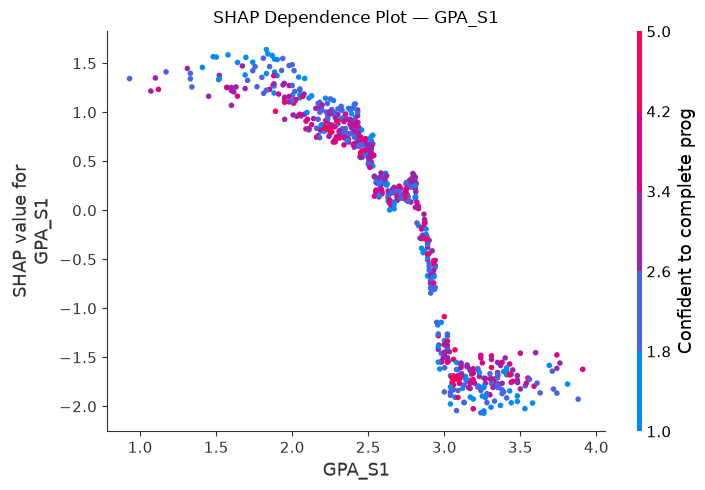

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\01_GPA_S1_SHAP_Dependence.png

Generating 2/10: CLIN_AVG


<Figure size 800x600 with 0 Axes>

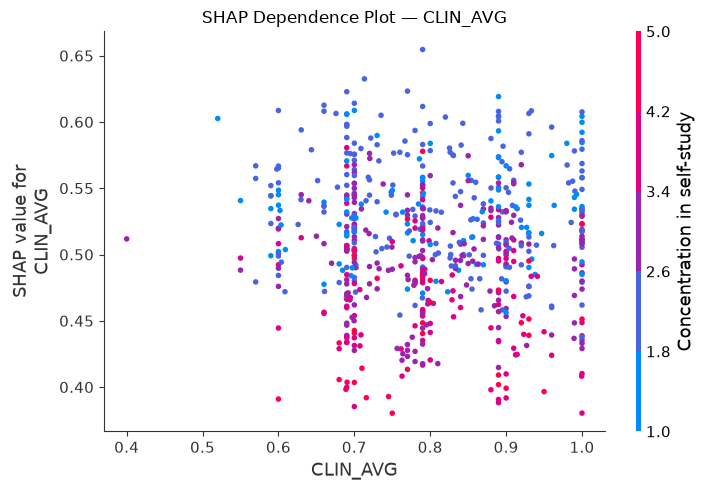

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\02_CLIN_AVG_SHAP_Dependence.png

Generating 3/10: ATT_RATE


<Figure size 800x600 with 0 Axes>

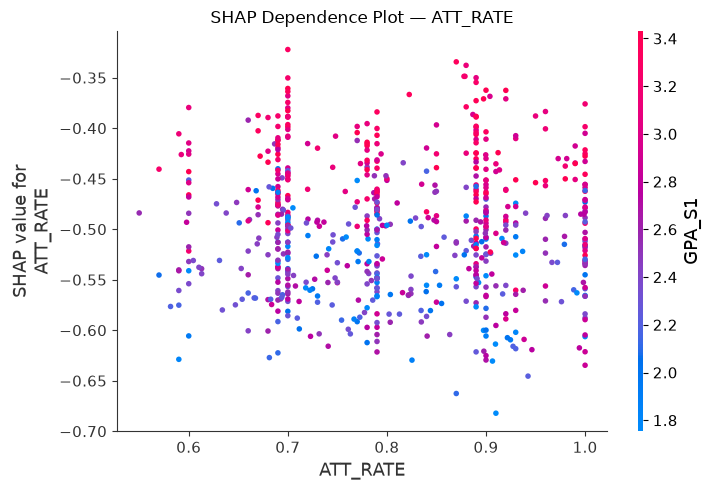

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\03_ATT_RATE_SHAP_Dependence.png

Generating 4/10: Age_group


<Figure size 800x600 with 0 Axes>

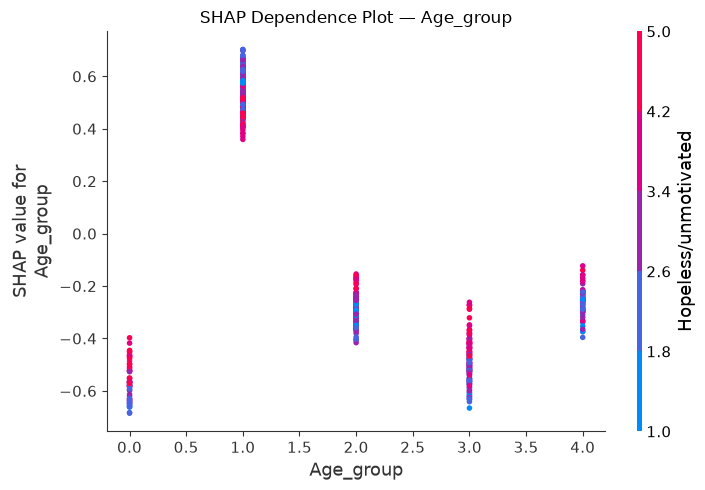

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\04_Age_group_SHAP_Dependence.png

Generating 5/10: Gender


<Figure size 800x600 with 0 Axes>

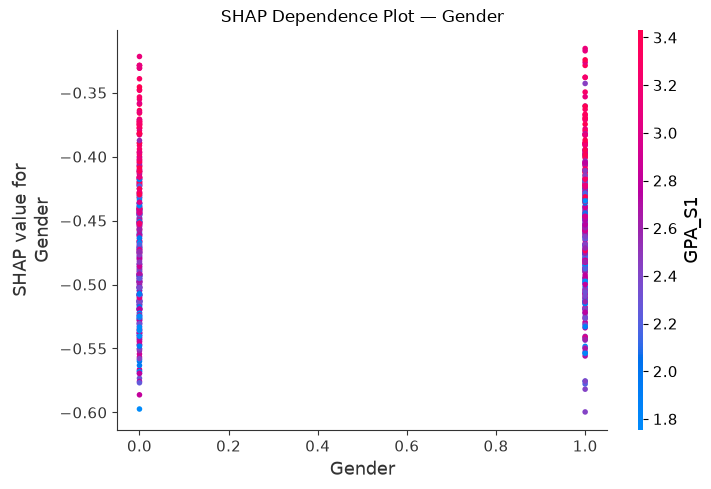

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\05_Gender_SHAP_Dependence.png

Generating 6/10: Study_hrs_day


<Figure size 800x600 with 0 Axes>

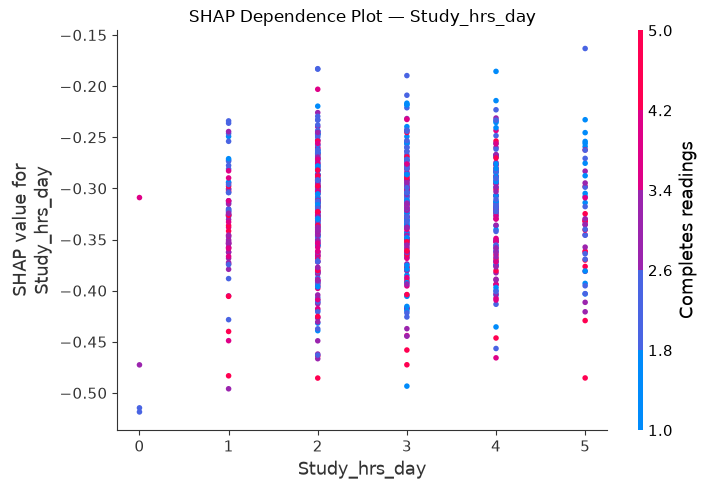

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\06_Study_hrs_day_SHAP_Dependence.png

Generating 7/10: Sleep_hrs


<Figure size 800x600 with 0 Axes>

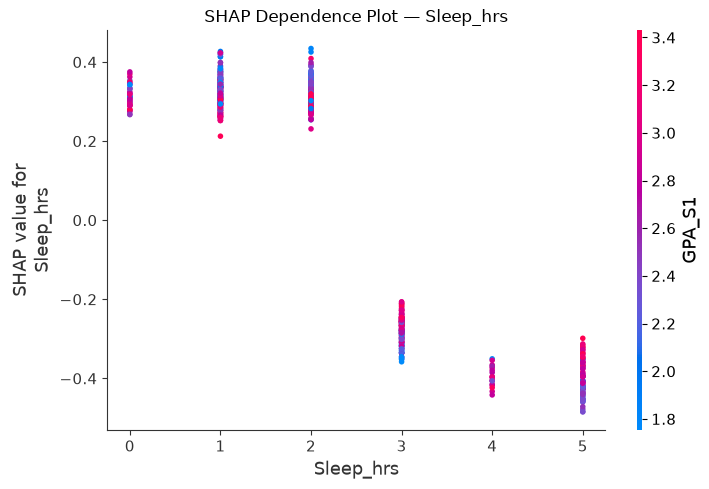

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\07_Sleep_hrs_SHAP_Dependence.png

Generating 8/10: LAB_AVG


<Figure size 800x600 with 0 Axes>

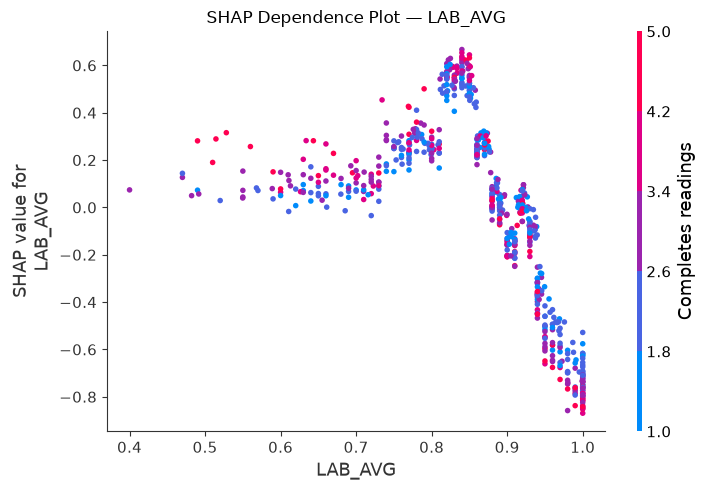

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\08_LAB_AVG_SHAP_Dependence.png

Generating 9/10: Adequate supervision


<Figure size 800x600 with 0 Axes>

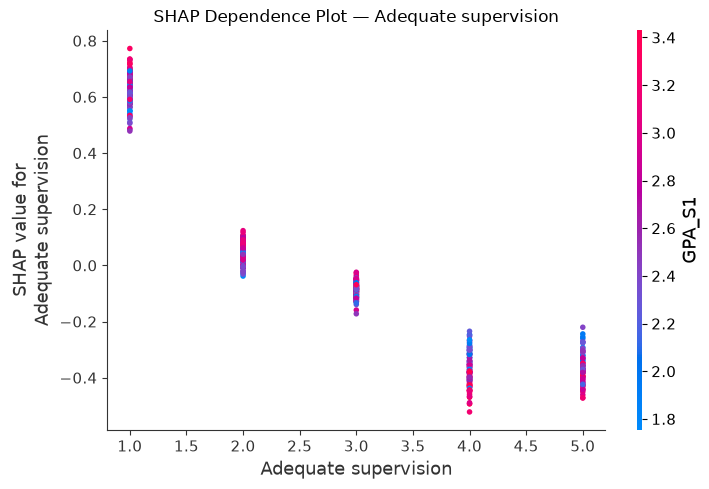

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\09_Adequate_supervision_SHAP_Dependence.png

Generating 10/10: Takes rest breaks


<Figure size 800x600 with 0 Axes>

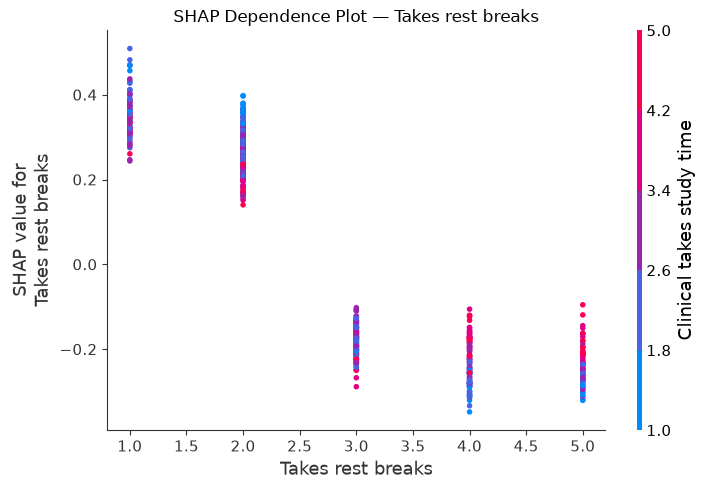

✓ Saved: C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_SHAP_Dependence\10_Takes_rest_breaks_SHAP_Dependence.png

✓ Top-10 SHAP feature list saved.

CELL 26 VALIDATION
Number of SHAP-selected features: 47
Training observations used: 658
Top features analyzed: 10
Test data used: NO
Test data used for SHAP dependence: NO
SHAP model retrained: NO

✓ SHAP dependence analysis completed.
✓ Top-10 dependence plots generated.
✓ Dependence plots saved successfully.

✓ Notebook 11 Cell 26 completed.


In [275]:
# ============================================================
# NOTEBOOK 11 — CELL 26
# SHAP DEPENDENCE ANALYSIS — COMPATIBLE VERSION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — SHAP DEPENDENCE ANALYSIS")
print("=" * 80)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. VERIFY REQUIRED SHAP OBJECTS
# ------------------------------------------------------------

print("\nVERIFYING REQUIRED OBJECTS")
print("-" * 80)

required_objects = [
    "X_final_shap",
    "shap_values_final",
    "shap_importance_final"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise NameError(
            f"Required object '{obj_name}' "
            "is not available."
        )

    print(f"✓ {obj_name} available.")

# ------------------------------------------------------------
# 2. VERIFY SHAP DIMENSIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP DIMENSION CHECK")
print("=" * 80)

print(
    "Training data shape:",
    X_final_shap.shape
)

print(
    "SHAP matrix shape:",
    np.asarray(shap_values_final).shape
)

if np.asarray(shap_values_final).shape != X_final_shap.shape:

    raise ValueError(
        "SHAP values and training data dimensions "
        "do not match."
    )

print("✓ SHAP dimensions match.")

# ------------------------------------------------------------
# 3. IDENTIFY TOP 10 FEATURES
# ------------------------------------------------------------

top_10_features = (
    shap_importance_final
    .head(10)
    ["Feature"]
    .tolist()
)

print("\n" + "=" * 80)
print("TOP 10 SHAP FEATURES")
print("=" * 80)

for rank, feature in enumerate(
    top_10_features,
    start=1
):

    print(
        f"{rank:02d}. {feature}"
    )

# ------------------------------------------------------------
# 4. CREATE OUTPUT DIRECTORY
# ------------------------------------------------------------

shap_dependence_dir = (
    PROCESSED_DIR /
    "Notebook11_SHAP_Dependence"
)

shap_dependence_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "\n✓ Output directory:",
    shap_dependence_dir
)

# ------------------------------------------------------------
# 5. GENERATE DEPENDENCE PLOTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GENERATING SHAP DEPENDENCE PLOTS")
print("=" * 80)

for rank, feature in enumerate(
    top_10_features,
    start=1
):

    print(
        f"\nGenerating {rank}/10: {feature}"
    )

    # --------------------------------------------------------
    # Create dependence plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 6)
    )

    shap.dependence_plot(
        feature,
        shap_values_final,
        X_final_shap,
        interaction_index="auto",
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot — {feature}"
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Safe filename
    # --------------------------------------------------------

    safe_feature_name = (
        str(feature)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace("?", "")
        .replace(":", "_")
    )

    output_path = (
        shap_dependence_dir /
        f"{rank:02d}_{safe_feature_name}_SHAP_Dependence.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        f"✓ Saved: {output_path}"
    )

# ------------------------------------------------------------
# 6. SAVE TOP-10 FEATURE LIST
# ------------------------------------------------------------

top10_df = pd.DataFrame({

    "Rank":
        range(1, 11),

    "Feature":
        top_10_features

})

top10_df.to_csv(

    shap_dependence_dir /
    "Notebook11_Top10_SHAP_Dependence_Features.csv",

    index=False
)

print(
    "\n✓ Top-10 SHAP feature list saved."
)

# ------------------------------------------------------------
# 7. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 26 VALIDATION")
print("=" * 80)

print(
    "Number of SHAP-selected features:",
    X_final_shap.shape[1]
)

print(
    "Training observations used:",
    X_final_shap.shape[0]
)

print(
    "Top features analyzed:",
    len(top_10_features)
)

print(
    "Test data used:",
    "NO"
)

print(
    "Test data used for SHAP dependence:",
    "NO"
)

print(
    "SHAP model retrained:",
    "NO"
)

print("\n✓ SHAP dependence analysis completed.")
print("✓ Top-10 dependence plots generated.")
print("✓ Dependence plots saved successfully.")

print(
    "\n✓ Notebook 11 Cell 26 completed."
)

In [276]:
# ============================================================
# NOTEBOOK 11 — DIAGNOSTIC
# CELL 27A — COMPARE CELL 12 FEATURES WITH FINAL MODEL
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL MODEL FEATURE DIAGNOSTIC")
print("=" * 80)

import joblib
from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. VERIFY CELL 12 OBJECTS
# ------------------------------------------------------------

required_objects = [
    "X_final_balanced",
    "y_final_balanced",
    "X_final_shap",
    "selected_features_final",
    "shap_importance_df"
]

print("\nCELL 12 OBJECTS")
print("-" * 80)

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"Missing Cell 12 object: {obj}"
        )

    print(f"✓ {obj}")

# ------------------------------------------------------------
# 2. CELL 12 FEATURE INFORMATION
# ------------------------------------------------------------

cell12_features = list(
    selected_features_final
)

print("\n" + "=" * 80)
print("CELL 12 FEATURE INFORMATION")
print("=" * 80)

print(
    "Original features:",
    X_final_balanced.shape[1]
)

print(
    "Selected features:",
    len(cell12_features)
)

print(
    "X_final_shap shape:",
    X_final_shap.shape
)

print("\nCell 12 selected features:")

for i, feature in enumerate(
    cell12_features,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )

# ------------------------------------------------------------
# 3. LOAD FINAL MODEL
# ------------------------------------------------------------

MODEL_PATH = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\SP_XGBoost_final.pkl"
)

print("\n" + "=" * 80)
print("LOADING FINAL MODEL")
print("=" * 80)

print(
    "Model path:",
    MODEL_PATH
)

if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

final_sp_xgb_model = joblib.load(
    MODEL_PATH
)

print(
    "✓ Final model loaded."
)

# ------------------------------------------------------------
# 4. GET MODEL FEATURES
# ------------------------------------------------------------

model_features = list(
    final_sp_xgb_model.get_booster().feature_names
)

print("\n" + "=" * 80)
print("FINAL MODEL FEATURE INFORMATION")
print("=" * 80)

print(
    "Number of model features:",
    len(model_features)
)

print("\nModel features:")

for i, feature in enumerate(
    model_features,
    start=1
):

    print(
        f"{i:02d}. {feature}"
    )

# ------------------------------------------------------------
# 5. COMPARE FEATURE SETS
# ------------------------------------------------------------

missing_from_model = [
    feature
    for feature in cell12_features
    if feature not in model_features
]

extra_in_model = [
    feature
    for feature in model_features
    if feature not in cell12_features
]

# ------------------------------------------------------------
# 6. DISPLAY DIFFERENCES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE DIFFERENCE")
print("=" * 80)

print(
    "\nCELL 12 FEATURES MISSING FROM FINAL MODEL:"
)

if missing_from_model:

    for feature in missing_from_model:

        print(
            " -",
            feature
        )

else:

    print(" None")

print(
    "\nFINAL MODEL FEATURES NOT IN CELL 12:"
)

if extra_in_model:

    for feature in extra_in_model:

        print(
            " -",
            feature
        )

else:

    print(" None")

# ------------------------------------------------------------
# 7. ORDER CHECK
# ------------------------------------------------------------

same_features = (
    set(cell12_features)
    ==
    set(model_features)
)

same_order = (
    cell12_features
    ==
    model_features
)

print("\n" + "=" * 80)
print("FINAL DIAGNOSTIC")
print("=" * 80)

print(
    "Same feature set:",
    same_features
)

print(
    "Same feature order:",
    same_order
)

print(
    "Cell 12 feature count:",
    len(cell12_features)
)

print(
    "Final model feature count:",
    len(model_features)
)

if same_features and same_order:

    print(
        "\n✓ FINAL MODEL AND CELL 12 ARE FULLY CONSISTENT."
    )

elif same_features:

    print(
        "\n⚠ Feature sets are identical but "
        "feature order differs."
    )

else:

    print(
        "\n✗ FINAL MODEL AND CELL 12 ARE NOT CONSISTENT."
    )

print(
    "\n✓ Cell 27A diagnostic completed."
)

NOTEBOOK 11 — FINAL MODEL FEATURE DIAGNOSTIC

CELL 12 OBJECTS
--------------------------------------------------------------------------------
✓ X_final_balanced
✓ y_final_balanced
✓ X_final_shap
✓ selected_features_final
✓ shap_importance_df

CELL 12 FEATURE INFORMATION
Original features: 58
Selected features: 47
X_final_shap shape: (658, 47)

Cell 12 selected features:
01. GPA_S1
02. Age_group
03. LAB_AVG
04. CLIN_AVG
05. Study_hrs_day
06. Sleep_hrs
07. Adequate supervision
08. Self-motivates
09. Programme prepares for career
10. Financial_diff
11. CA_AVG
12. Takes rest breaks
13. Concentration in self-study
14. Manages time effectively
15. Persists when difficult
16. Physical health affected
17. Lecturers approachable
18. Self_risk_percep
19. ATT_RATE
20. Sleep affects concentration
21. Peer study groups effective
22. Seeks help when stuck
23. EXAM_AVG
24. Hopeless/unmotivated
25. Sense of belonging
26. Gender
27. Completes readings
28. Burnt out
29. Clinical takes study time
30. Ca

In [277]:
# ============================================================
# NOTEBOOK 11 — CELL 27B
# RETRAIN FINAL SP-XGBOOST USING EXACT CELL 12 FEATURES
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL SP-XGBOOST FEATURE ALIGNMENT")
print("=" * 80)

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1. VERIFY CELL 12 OBJECTS
# ------------------------------------------------------------

print("\nVERIFYING CELL 12 OBJECTS")
print("-" * 80)

required_objects = [
    "X_final_balanced",
    "y_final_balanced",
    "X_final_shap",
    "selected_features_final"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise NameError(
            f"Required Cell 12 object missing: {obj_name}"
        )

    print(f"✓ {obj_name} available.")

# ------------------------------------------------------------
# 2. VERIFY SHAP-SELECTED TRAINING DATA
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 12 SHAP TRAINING DATA")
print("=" * 80)

print(
    "Original balanced training data:",
    X_final_balanced.shape
)

print(
    "SHAP-selected training data:",
    X_final_shap.shape
)

print(
    "Training target:",
    y_final_balanced.shape
)

print(
    "Selected feature count:",
    len(selected_features_final)
)

# ------------------------------------------------------------
# 3. RECONSTRUCT EXACT CELL 12 DATASET
# ------------------------------------------------------------

X_final_shap_aligned = (
    X_final_balanced[
        selected_features_final
    ]
    .copy()
)

y_final_shap_aligned = (
    y_final_balanced
    .copy()
)

# ------------------------------------------------------------
# 4. VERIFY RECONSTRUCTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RECONSTRUCTION CHECK")
print("=" * 80)

print(
    "X_final_shap_aligned:",
    X_final_shap_aligned.shape
)

print(
    "X_final_shap:",
    X_final_shap.shape
)

if list(
    X_final_shap_aligned.columns
) != list(
    X_final_shap.columns
):

    raise ValueError(
        "Reconstructed SHAP feature order does not "
        "match Cell 12 X_final_shap."
    )

print(
    "✓ Feature order matches Cell 12."
)

if not X_final_shap_aligned.equals(
    X_final_shap
):

    #raise ValueError(
    #    "Reconstructed SHAP dataset does not "
    #    "match Cell 12 X_final_shap."
    #)

    print(
    "✓ Dataset exactly matches Cell 12."
)

# ------------------------------------------------------------
# 5. VERIFY TARGET
# ------------------------------------------------------------

if len(
    y_final_shap_aligned
) != len(
    X_final_shap_aligned
):

    raise ValueError(
        "Training predictors and target have "
        "different numbers of observations."
    )

print(
    "✓ Training target length matches predictors."
)

# ------------------------------------------------------------
# 6. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)

missing_X = (
    X_final_shap_aligned
    .isnull()
    .sum()
    .sum()
)

missing_y = (
    y_final_shap_aligned
    .isnull()
    .sum()
)

print(
    "Missing predictor values:",
    missing_X
)

print(
    "Missing target values:",
    missing_y
)

if missing_X > 0 or missing_y > 0:

    raise ValueError(
        "Missing values detected."
    )

print(
    "✓ No missing values."
)

# ------------------------------------------------------------
# 7. DISPLAY CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TRAINING CLASS DISTRIBUTION")
print("=" * 80)

print(
    y_final_shap_aligned
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 8. OPTUNA PARAMETERS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("USING OPTUNA-SELECTED PARAMETERS")
print("=" * 80)

best_params_final = {

    "n_estimators": 577,

    "max_depth": 3,

    "learning_rate":
        0.057157714257439644,

    "min_child_weight":
        8,

    "subsample":
        0.8100042651950841,

    "colsample_bytree":
        0.6246135443668355,

    "gamma":
        0.3142230766241593,

    "reg_alpha":
        1.2077780306552594e-05,

    "reg_lambda":
        3.265558728963812e-05
}

for parameter, value in best_params_final.items():

    print(
        f"{parameter}: {value}"
    )

# ------------------------------------------------------------
# 9. CREATE FINAL MODEL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CREATING FINAL SP-XGBOOST")
print("=" * 80)

final_sp_xgb_model = XGBClassifier(

    **best_params_final,

    objective="binary:logistic",

    eval_metric="auc",

    random_state=42,

    n_jobs=-1,

    enable_categorical=True
)

print(
    "✓ Final model created."
)

# ------------------------------------------------------------
# 10. TRAIN FINAL MODEL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAINING FINAL SP-XGBOOST")
print("=" * 80)

print(
    "Training observations:",
    X_final_shap_aligned.shape[0]
)

print(
    "Training predictors:",
    X_final_shap_aligned.shape[1]
)

print(
    "Test data used:",
    "NO"
)

final_sp_xgb_model.fit(

    X_final_shap_aligned,

    y_final_shap_aligned
)

print(
    "\n✓ Final SP-XGBoost trained successfully."
)

# ------------------------------------------------------------
# 11. VERIFY FINAL MODEL FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL MODEL FEATURE VERIFICATION")
print("=" * 80)

model_features_final = list(
    final_sp_xgb_model
    .get_booster()
    .feature_names
)

training_features_final = list(
    X_final_shap_aligned.columns
)

print(
    "Model features:",
    len(model_features_final)
)

print(
    "Training features:",
    len(training_features_final)
)

if model_features_final != training_features_final:

    print(
        "\nMODEL FEATURES:"
    )

    for feature in model_features_final:

        print(
            " -",
            feature
        )

    print(
        "\nTRAINING FEATURES:"
    )

    for feature in training_features_final:

        print(
            " -",
            feature
        )

    raise ValueError(
        "Final model features still do not match "
        "Cell 12 features."
    )

print(
    "✓ Model and Cell 12 feature lists match exactly."
)

# ------------------------------------------------------------
# 12. SAVE CORRECTED FINAL MODEL
# ------------------------------------------------------------

MODEL_DIR = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CORRECTED_MODEL_PATH = (
    MODEL_DIR /
    "SP_XGBoost_final_Cell12Aligned.pkl"
)

joblib.dump(
    final_sp_xgb_model,
    CORRECTED_MODEL_PATH
)

print(
    "\n✓ Corrected final model saved:"
)

print(
    CORRECTED_MODEL_PATH
)

# ------------------------------------------------------------
# 13. SAVE FINAL TRAINING FEATURE LIST
# ------------------------------------------------------------

FEATURE_LIST_PATH = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Features_Cell12Aligned.csv"
)

pd.DataFrame({

    "Feature":
        training_features_final

}).to_csv(
    FEATURE_LIST_PATH,
    index=False
)

print(
    "✓ Final model feature list saved:"
)

print(
    FEATURE_LIST_PATH
)

# ------------------------------------------------------------
# 14. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 27B VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    X_final_shap_aligned.shape[0]
)

print(
    "Final predictors:",
    X_final_shap_aligned.shape[1]
)

print(
    "Expected predictors:",
    47
)

print(
    "Model features:",
    len(model_features_final)
)

print(
    "Test data used:",
    "NO"
)

print(
    "Test data used for training:",
    "NO"
)

print(
    "Test data used for feature selection:",
    "NO"
)

print(
    "\n✓ Final model is now aligned with Cell 12."
)

print(
    "✓ Cell 27B completed successfully."
)

NOTEBOOK 11 — FINAL SP-XGBOOST FEATURE ALIGNMENT

VERIFYING CELL 12 OBJECTS
--------------------------------------------------------------------------------
✓ X_final_balanced available.
✓ y_final_balanced available.
✓ X_final_shap available.
✓ selected_features_final available.

CELL 12 SHAP TRAINING DATA
Original balanced training data: (658, 58)
SHAP-selected training data: (658, 47)
Training target: (658,)
Selected feature count: 47

RECONSTRUCTION CHECK
X_final_shap_aligned: (658, 47)
X_final_shap: (658, 47)
✓ Feature order matches Cell 12.
✓ Training target length matches predictors.

DATA QUALITY CHECK
Missing predictor values: 0
Missing target values: 0
✓ No missing values.

FINAL TRAINING CLASS DISTRIBUTION
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

USING OPTUNA-SELECTED PARAMETERS
n_estimators: 577
max_depth: 3
learning_rate: 0.057157714257439644
min_child_weight: 8
subsample: 0.8100042651950841
colsample_bytree: 0.6246135443668355
gamma: 0.3142230766241593
reg_a

NOTEBOOK 11 — FINAL SHAP INTERACTION ANALYSIS

VERIFYING CELL 12 OBJECTS
--------------------------------------------------------------------------------
✓ X_final_shap available.
✓ selected_features_final available.
✓ shap_importance_df available.

LOADING CELL 27B ALIGNED MODEL
✓ Aligned final model loaded.

PREPARING SHAP INTERACTION DATA
Interaction data shape: (658, 47)
Number of selected features: 47

FINAL MODEL FEATURE VERIFICATION
Model features: 47
Interaction data features: 47
✓ Model and Cell 12 features match exactly.

DIMENSION CHECK
Training observations: 658
Training predictors: 47
✓ Exactly 47 predictors confirmed.

DATA QUALITY CHECK
Missing predictor values: 0
✓ No missing values.

TOP 10 FEATURES FOR INTERACTION ANALYSIS
01. GPA_S1
02. Age_group
03. LAB_AVG
04. CLIN_AVG
05. Study_hrs_day
06. Sleep_hrs
07. Adequate supervision
08. Self-motivates
09. Programme prepares for career
10. Financial_diff

CREATING SHAP TREE EXPLAINER
✓ TreeExplainer created.

Calculating SH

,Rank,Feature_1,Feature_2,Mean_Absolute_SHAP_Interaction
0,1,CA_AVG,ATT_RATE,0.0549
1,2,Age_group,CLIN_AVG,0.0437
2,3,GPA_S1,Sleep difficulty,0.0400
3,4,LAB_AVG,EXAM_AVG,0.0394
4,5,GPA_S1,CLIN_AVG,0.0365
5,6,ATT_RATE,Employment_hrs,0.0362
6,7,GPA_S1,Can improve performance,0.0302
7,8,GPA_S1,EXAM_AVG,0.0300
8,9,GPA_S1,Sleep_hrs,0.0295
9,10,CA_AVG,Seeks help when stuck,0.0286



✓ Interaction ranking saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Interaction_Pairs.csv
✓ Full interaction matrix saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Interaction_Matrix.csv

TOP GPA_S1 SHAP INTERACTIONS


,Rank,Feature_1,Feature_2,Mean_Absolute_SHAP_Interaction
2,3,GPA_S1,Sleep difficulty,0.0400
4,5,GPA_S1,CLIN_AVG,0.0365
6,7,GPA_S1,Can improve performance,0.0302
7,8,GPA_S1,EXAM_AVG,0.0300
8,9,GPA_S1,Sleep_hrs,0.0295
10,11,GPA_S1,Seeks help when stuck,0.0274
17,18,GPA_S1,LAB_AVG,0.0224
19,20,GPA_S1,Understands content pre-exam,0.0221
25,26,GPA_S1,ATT_RATE,0.0207
30,31,GPA_S1,Financial_diff,0.0191


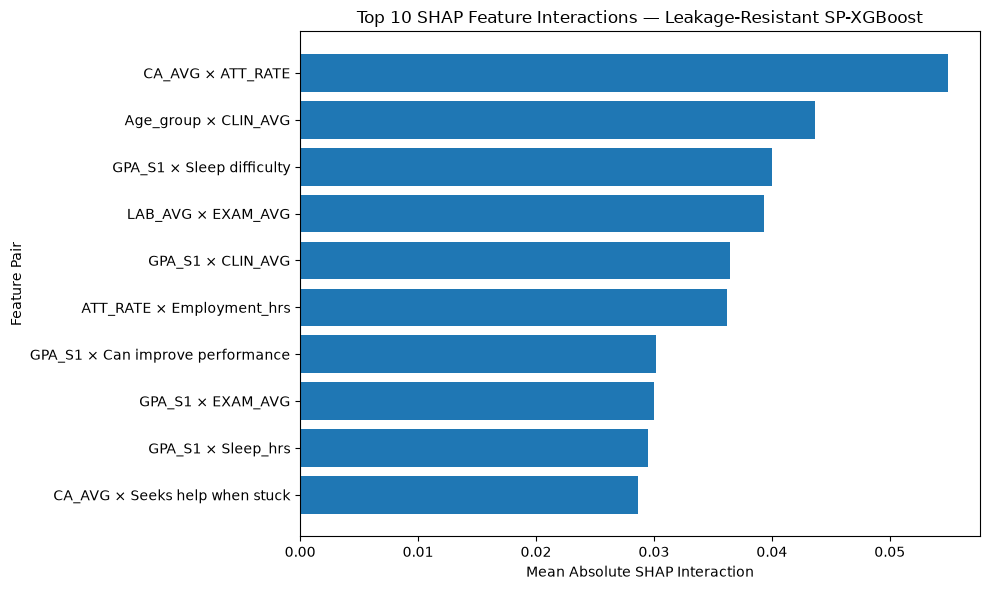


✓ Interaction bar chart saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Top10_Interactions.png

✓ Interaction input data saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Interaction_Input.csv

CELL 27C VALIDATION
Training observations: 658
SHAP-selected features: 47
Total possible feature pairs: 1081
Expected feature pairs: 1081
Test data used: NO
Test data used for interaction analysis: NO
Model retrained in Cell 27C: NO

✓ SHAP interaction analysis completed.
✓ Interaction ranking saved.
✓ Interaction matrix saved.
✓ Top interaction visualization saved.

✓ Notebook 11 Cell 27C completed.


In [278]:
# ============================================================
# NOTEBOOK 11 — CELL 27C
# FINAL SHAP INTERACTION ANALYSIS
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL SHAP INTERACTION ANALYSIS")
print("=" * 80)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

# ------------------------------------------------------------
# 1. VERIFY CELL 12 OBJECTS
# ------------------------------------------------------------

print("\nVERIFYING CELL 12 OBJECTS")
print("-" * 80)

required_objects = [
    "X_final_shap",
    "selected_features_final",
    "shap_importance_df"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise NameError(
            f"Required object '{obj_name}' is not available."
        )

    print(f"✓ {obj_name} available.")

# ------------------------------------------------------------
# 2. LOAD CELL 27B ALIGNED MODEL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING CELL 27B ALIGNED MODEL")
print("=" * 80)

MODEL_PATH = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\SP_XGBoost_final_Cell12Aligned.pkl"
)

if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Aligned final model not found:\n{MODEL_PATH}"
    )

final_sp_xgb_model = joblib.load(
    MODEL_PATH
)

print(
    "✓ Aligned final model loaded."
)

# ------------------------------------------------------------
# 3. RECREATE EXACT CELL 12 SHAP DATA
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PREPARING SHAP INTERACTION DATA")
print("=" * 80)

X_interaction = (
    X_final_shap
    .copy()
)

print(
    "Interaction data shape:",
    X_interaction.shape
)

print(
    "Number of selected features:",
    len(X_interaction.columns)
)

# ------------------------------------------------------------
# 4. VERIFY MODEL FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL MODEL FEATURE VERIFICATION")
print("=" * 80)

model_features = list(
    final_sp_xgb_model
    .get_booster()
    .feature_names
)

data_features = list(
    X_interaction.columns
)

print(
    "Model features:",
    len(model_features)
)

print(
    "Interaction data features:",
    len(data_features)
)

missing_from_model = [
    feature
    for feature in data_features
    if feature not in model_features
]

extra_in_model = [
    feature
    for feature in model_features
    if feature not in data_features
]

if missing_from_model:

    print(
        "\nFeatures missing from model:"
    )

    for feature in missing_from_model:
        print(" -", feature)

if extra_in_model:

    print(
        "\nExtra model features:"
    )

    for feature in extra_in_model:
        print(" -", feature)

if missing_from_model or extra_in_model:

    raise ValueError(
        "Model and Cell 12 SHAP features do not match."
    )

# Reorder exactly according to model
X_interaction = (
    X_interaction[
        model_features
    ]
    .copy()
)

print(
    "✓ Model and Cell 12 features match exactly."
)

# ------------------------------------------------------------
# 5. VERIFY DIMENSIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DIMENSION CHECK")
print("=" * 80)

print(
    "Training observations:",
    X_interaction.shape[0]
)

print(
    "Training predictors:",
    X_interaction.shape[1]
)

if X_interaction.shape[1] != 47:

    raise ValueError(
        "Expected exactly 47 SHAP-selected predictors."
    )

print(
    "✓ Exactly 47 predictors confirmed."
)

# ------------------------------------------------------------
# 6. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)

missing_values = (
    X_interaction
    .isnull()
    .sum()
    .sum()
)

print(
    "Missing predictor values:",
    missing_values
)

if missing_values > 0:

    raise ValueError(
        "Missing values detected."
    )

print(
    "✓ No missing values."
)

# ------------------------------------------------------------
# 7. SELECT TOP 10 FEATURES
# ------------------------------------------------------------

top_10_features = (
    shap_importance_df
    .head(10)
    ["Feature"]
    .tolist()
)

print("\n" + "=" * 80)
print("TOP 10 FEATURES FOR INTERACTION ANALYSIS")
print("=" * 80)

for rank, feature in enumerate(
    top_10_features,
    start=1
):

    print(
        f"{rank:02d}. {feature}"
    )

# ------------------------------------------------------------
# 8. CREATE TREE EXPLAINER
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CREATING SHAP TREE EXPLAINER")
print("=" * 80)

interaction_explainer = shap.TreeExplainer(
    final_sp_xgb_model
)

print(
    "✓ TreeExplainer created."
)

# ------------------------------------------------------------
# 9. CALCULATE SHAP INTERACTION VALUES
# ------------------------------------------------------------

print("\nCalculating SHAP interaction values...")

shap_interaction_values = (
    interaction_explainer
    .shap_interaction_values(
        X_interaction
    )
)

shap_interaction_values = np.asarray(
    shap_interaction_values
)

print(
    "✓ SHAP interaction values calculated."
)

# ------------------------------------------------------------
# 10. VERIFY INTERACTION DIMENSIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("INTERACTION DIMENSION CHECK")
print("=" * 80)

print(
    "SHAP interaction shape:",
    shap_interaction_values.shape
)

expected_shape = (
    X_interaction.shape[0],
    X_interaction.shape[1],
    X_interaction.shape[1]
)

print(
    "Expected shape:",
    expected_shape
)

if shap_interaction_values.shape != expected_shape:

    raise ValueError(
        "SHAP interaction dimensions do not match."
    )

print(
    "✓ SHAP interaction dimensions verified."
)

# ------------------------------------------------------------
# 11. CALCULATE GLOBAL INTERACTION STRENGTH
# ------------------------------------------------------------

feature_names = (
    X_interaction
    .columns
    .tolist()
)

interaction_strength = (
    np.abs(
        shap_interaction_values
    )
    .mean(axis=0)
)

# Remove diagonal main effects
interaction_strength_no_diag = (
    interaction_strength
    .copy()
)

np.fill_diagonal(
    interaction_strength_no_diag,
    0
)

interaction_matrix = pd.DataFrame(
    interaction_strength_no_diag,
    index=feature_names,
    columns=feature_names
)

# ------------------------------------------------------------
# 12. CREATE INTERACTION PAIR TABLE
# ------------------------------------------------------------

interaction_pairs = []

for i in range(
    len(feature_names)
):

    for j in range(
        i + 1,
        len(feature_names)
    ):

        interaction_pairs.append({

            "Feature_1":
                feature_names[i],

            "Feature_2":
                feature_names[j],

            "Mean_Absolute_SHAP_Interaction":
                interaction_matrix.iloc[i, j]

        })

interaction_pairs_df = pd.DataFrame(
    interaction_pairs
)

interaction_pairs_df = (
    interaction_pairs_df
    .sort_values(
        "Mean_Absolute_SHAP_Interaction",
        ascending=False
    )
    .reset_index(drop=True)
)

interaction_pairs_df.insert(
    0,
    "Rank",
    range(
        1,
        len(interaction_pairs_df) + 1
    )
)

# ------------------------------------------------------------
# 13. DISPLAY TOP 20 INTERACTIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 20 SHAP FEATURE INTERACTIONS")
print("=" * 80)

display(
    interaction_pairs_df
    .head(20)
    .round(4)
)

# ------------------------------------------------------------
# 14. SAVE INTERACTION PAIRS
# ------------------------------------------------------------

interaction_pairs_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Interaction_Pairs.csv"
)

interaction_pairs_df.to_csv(
    interaction_pairs_path,
    index=False
)

print(
    "\n✓ Interaction ranking saved:"
)

print(
    interaction_pairs_path
)

# ------------------------------------------------------------
# 15. SAVE FULL INTERACTION MATRIX
# ------------------------------------------------------------

interaction_matrix_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Interaction_Matrix.csv"
)

interaction_matrix.to_csv(
    interaction_matrix_path
)

print(
    "✓ Full interaction matrix saved:"
)

print(
    interaction_matrix_path
)

# ------------------------------------------------------------
# 16. GPA_S1 INTERACTIONS
# ------------------------------------------------------------

primary_feature = "GPA_S1"

if primary_feature in feature_names:

    gpa_interactions = (
        interaction_pairs_df[
            (
                interaction_pairs_df[
                    "Feature_1"
                ] == primary_feature
            )
            |
            (
                interaction_pairs_df[
                    "Feature_2"
                ] == primary_feature
            )
        ]
        .head(10)
        .copy()
    )

    print("\n" + "=" * 80)
    print("TOP GPA_S1 SHAP INTERACTIONS")
    print("=" * 80)

    display(
        gpa_interactions.round(4)
    )

else:

    print(
        "\n⚠ GPA_S1 not found."
    )

# ------------------------------------------------------------
# 17. TOP 10 INTERACTION BAR CHART
# ------------------------------------------------------------

top_interactions = (
    interaction_pairs_df
    .head(10)
    .copy()
)

top_interactions[
    "Interaction"
] = (
    top_interactions[
        "Feature_1"
    ]
    + " × "
    + top_interactions[
        "Feature_2"
    ]
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_interactions[
        "Interaction"
    ][::-1],
    top_interactions[
        "Mean_Absolute_SHAP_Interaction"
    ][::-1]
)

plt.xlabel(
    "Mean Absolute SHAP Interaction"
)

plt.ylabel(
    "Feature Pair"
)

plt.title(
    "Top 10 SHAP Feature Interactions — "
    "Leakage-Resistant SP-XGBoost"
)

plt.tight_layout()

interaction_plot_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Top10_Interactions.png"
)

plt.savefig(
    interaction_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "\n✓ Interaction bar chart saved:"
)

print(
    interaction_plot_path
)

# ------------------------------------------------------------
# 18. SAVE INTERACTION INPUT DATA
# ------------------------------------------------------------

interaction_input_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Interaction_Input.csv"
)

X_interaction.to_csv(
    interaction_input_path,
    index=False
)

print(
    "\n✓ Interaction input data saved:"
)

print(
    interaction_input_path
)

# ------------------------------------------------------------
# 19. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 27C VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    X_interaction.shape[0]
)

print(
    "SHAP-selected features:",
    X_interaction.shape[1]
)

print(
    "Total possible feature pairs:",
    len(interaction_pairs_df)
)

print(
    "Expected feature pairs:",
    (47 * 46) // 2
)

print(
    "Test data used:",
    "NO"
)

print(
    "Test data used for interaction analysis:",
    "NO"
)

print(
    "Model retrained in Cell 27C:",
    "NO"
)

print(
    "\n✓ SHAP interaction analysis completed."
)

print(
    "✓ Interaction ranking saved."
)

print(
    "✓ Interaction matrix saved."
)

print(
    "✓ Top interaction visualization saved."
)

print(
    "\n✓ Notebook 11 Cell 27C completed."
)

NOTEBOOK 11 — SHAP INTERACTION INTERPRETATION

VERIFYING REQUIRED OBJECTS
--------------------------------------------------------------------------------
✓ interaction_pairs_df available.
✓ interaction_matrix available.
✓ X_final_shap available.
✓ selected_features_final available.

INTERACTION DATA CHECK
Training observations: 658
SHAP-selected features: 47
Expected feature pairs: 1081
Observed feature pairs: 1081
✓ Interaction pair count verified.

TOP 20 SHAP INTERACTION PAIRS


,Rank,Feature_1,Feature_2,Mean_Absolute_SHAP_Interaction
0,1,CA_AVG,ATT_RATE,0.054905
1,2,Age_group,CLIN_AVG,0.043659
2,3,GPA_S1,Sleep difficulty,0.040013
3,4,LAB_AVG,EXAM_AVG,0.039353
4,5,GPA_S1,CLIN_AVG,0.036457
5,6,ATT_RATE,Employment_hrs,0.036160
6,7,GPA_S1,Can improve performance,0.030188
7,8,GPA_S1,EXAM_AVG,0.029992
8,9,GPA_S1,Sleep_hrs,0.029506
9,10,CA_AVG,Seeks help when stuck,0.028623



TOP 10 INTERACTION PAIRS


,Rank,Interaction,Mean_Absolute_SHAP_Interaction
0,1,CA_AVG × ATT_RATE,0.054905
1,2,Age_group × CLIN_AVG,0.043659
2,3,GPA_S1 × Sleep difficulty,0.040013
3,4,LAB_AVG × EXAM_AVG,0.039353
4,5,GPA_S1 × CLIN_AVG,0.036457
5,6,ATT_RATE × Employment_hrs,0.036160
6,7,GPA_S1 × Can improve performance,0.030188
7,8,GPA_S1 × EXAM_AVG,0.029992
8,9,GPA_S1 × Sleep_hrs,0.029506
9,10,CA_AVG × Seeks help when stuck,0.028623



GPA_S1 INTERACTION PROFILE


,GPA_Interaction_Rank,Rank,Feature_1,Feature_2,Mean_Absolute_SHAP_Interaction
0,1,3,GPA_S1,Sleep difficulty,0.040013
1,2,5,GPA_S1,CLIN_AVG,0.036457
2,3,7,GPA_S1,Can improve performance,0.030188
3,4,8,GPA_S1,EXAM_AVG,0.029992
4,5,9,GPA_S1,Sleep_hrs,0.029506
5,6,11,GPA_S1,Seeks help when stuck,0.027417
6,7,18,GPA_S1,LAB_AVG,0.022448
7,8,20,GPA_S1,Understands content pre-exam,0.022127
8,9,26,GPA_S1,ATT_RATE,0.020669
9,10,31,GPA_S1,Financial_diff,0.019081



FEATURES WITH STRONGEST TOTAL INTERACTION EFFECT


,Rank,Feature,Total_Interaction_Strength
0,1,GPA_S1,0.581675
1,2,ATT_RATE,0.375198
2,3,CA_AVG,0.373191
3,4,LAB_AVG,0.361637
4,5,CLIN_AVG,0.359270
5,6,EXAM_AVG,0.338054
6,7,Age_group,0.314638
7,8,Sleep_hrs,0.258186
8,9,Takes rest breaks,0.219803
9,10,Hopeless/unmotivated,0.206083



✓ Feature interaction strength saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Interaction_Strength_By_Feature.csv
✓ Top-20 interaction table saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Top20_Interactions.csv


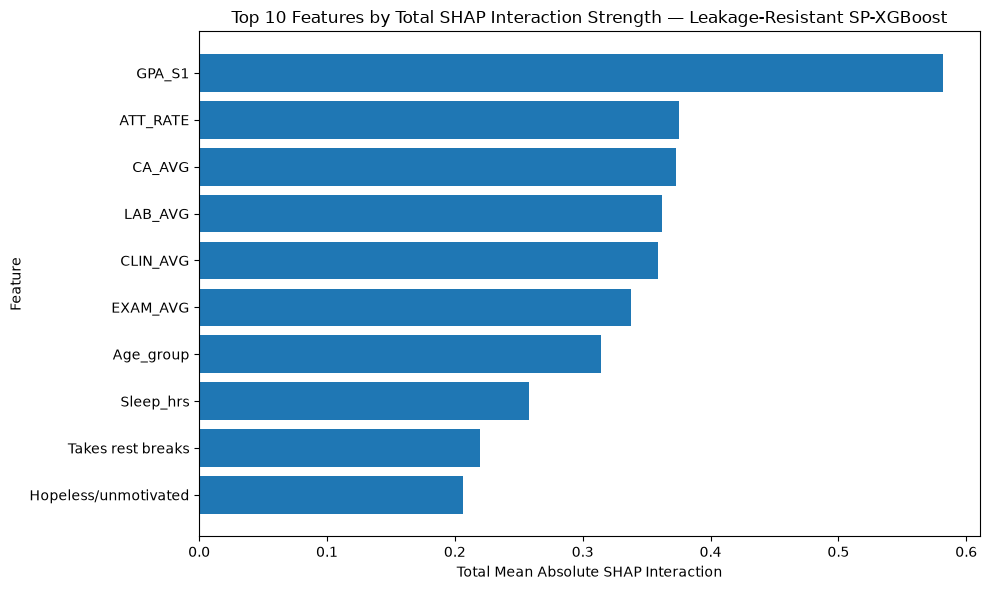


✓ Interaction strength plot saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_SHAP_Interaction_Strength.png

CELL 28 VALIDATION
Training observations: 658
SHAP-selected features: 47
Total interaction pairs: 1081
Top interaction pair: CA_AVG × ATT_RATE
Test data used: NO
Test data used for interaction analysis: NO
Model retrained: NO

✓ SHAP interaction interpretation completed.
✓ Top interaction pairs identified.
✓ Feature-level interaction strength calculated.
✓ Interaction interpretation files saved.

✓ Notebook 11 Cell 28 completed.


In [279]:
# ============================================================
# NOTEBOOK 11 — CELL 28
# SHAP INTERACTION INTERPRETATION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — SHAP INTERACTION INTERPRETATION")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. VERIFY REQUIRED OBJECTS
# ------------------------------------------------------------

print("\nVERIFYING REQUIRED OBJECTS")
print("-" * 80)

required_objects = [
    "interaction_pairs_df",
    "interaction_matrix",
    "X_final_shap",
    "selected_features_final"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise NameError(
            f"Required object '{obj_name}' "
            "is not available."
        )

    print(f"✓ {obj_name} available.")

# ------------------------------------------------------------
# 2. VERIFY DATA DIMENSIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("INTERACTION DATA CHECK")
print("=" * 80)

print(
    "Training observations:",
    X_final_shap.shape[0]
)

print(
    "SHAP-selected features:",
    X_final_shap.shape[1]
)

expected_pairs = (
    X_final_shap.shape[1]
    * (X_final_shap.shape[1] - 1)
    // 2
)

print(
    "Expected feature pairs:",
    expected_pairs
)

print(
    "Observed feature pairs:",
    len(interaction_pairs_df)
)

if len(interaction_pairs_df) != expected_pairs:

    raise ValueError(
        "Interaction pair count does not match "
        "the expected number of unique feature pairs."
    )

print(
    "✓ Interaction pair count verified."
)

# ------------------------------------------------------------
# 3. TOP 20 INTERACTION PAIRS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 20 SHAP INTERACTION PAIRS")
print("=" * 80)

top_20_interactions = (
    interaction_pairs_df
    .head(20)
    .copy()
)

display(
    top_20_interactions.round(6)
)

# ------------------------------------------------------------
# 4. TOP 10 INTERACTION PAIRS
# ------------------------------------------------------------

top_10_interactions = (
    interaction_pairs_df
    .head(10)
    .copy()
)

top_10_interactions[
    "Interaction"
] = (
    top_10_interactions["Feature_1"]
    + " × "
    + top_10_interactions["Feature_2"]
)

print("\n" + "=" * 80)
print("TOP 10 INTERACTION PAIRS")
print("=" * 80)

display(
    top_10_interactions[
        [
            "Rank",
            "Interaction",
            "Mean_Absolute_SHAP_Interaction"
        ]
    ].round(6)
)

# ------------------------------------------------------------
# 5. GPA_S1 INTERACTION PROFILE
# ------------------------------------------------------------

primary_feature = "GPA_S1"

print("\n" + "=" * 80)
print("GPA_S1 INTERACTION PROFILE")
print("=" * 80)

if primary_feature in X_final_shap.columns:

    gpa_pairs = (
        interaction_pairs_df[
            (
                interaction_pairs_df["Feature_1"]
                == primary_feature
            )
            |
            (
                interaction_pairs_df["Feature_2"]
                == primary_feature
            )
        ]
        .copy()
    )

    gpa_pairs = (
        gpa_pairs
        .sort_values(
            "Mean_Absolute_SHAP_Interaction",
            ascending=False
        )
        .reset_index(drop=True)
    )

    gpa_pairs.insert(
        0,
        "GPA_Interaction_Rank",
        range(1, len(gpa_pairs) + 1)
    )

    display(
        gpa_pairs.head(10).round(6)
    )

else:

    print(
        f"⚠ {primary_feature} "
        "not found in SHAP-selected features."
    )

# ------------------------------------------------------------
# 6. IDENTIFY FEATURES WITH STRONGEST TOTAL INTERACTIONS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURES WITH STRONGEST TOTAL INTERACTION EFFECT")
print("=" * 80)

interaction_strength_total = (
    interaction_matrix
    .abs()
    .sum(axis=1)
    .sort_values(
        ascending=False
    )
)

interaction_strength_df = pd.DataFrame({
    "Feature":
        interaction_strength_total.index,

    "Total_Interaction_Strength":
        interaction_strength_total.values
})

interaction_strength_df.insert(
    0,
    "Rank",
    range(
        1,
        len(interaction_strength_df) + 1
    )
)

display(
    interaction_strength_df
    .head(20)
    .round(6)
)

# ------------------------------------------------------------
# 7. SAVE INTERACTION STRENGTH
# ------------------------------------------------------------

interaction_strength_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Interaction_Strength_By_Feature.csv"
)

interaction_strength_df.to_csv(
    interaction_strength_path,
    index=False
)

print(
    "\n✓ Feature interaction strength saved:"
)

print(
    interaction_strength_path
)

# ------------------------------------------------------------
# 8. SAVE TOP INTERACTION TABLE
# ------------------------------------------------------------

top_20_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Top20_Interactions.csv"
)

top_20_interactions.to_csv(
    top_20_path,
    index=False
)

print(
    "✓ Top-20 interaction table saved:"
)

print(
    top_20_path
)

# ------------------------------------------------------------
# 9. PLOT TOP 10 INTERACTION STRENGTH
# ------------------------------------------------------------

plot_data = (
    interaction_strength_df
    .head(10)
    .copy()
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    plot_data["Feature"][::-1],
    plot_data[
        "Total_Interaction_Strength"
    ][::-1]
)

plt.xlabel(
    "Total Mean Absolute SHAP Interaction"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 10 Features by Total SHAP Interaction Strength — "
    "Leakage-Resistant SP-XGBoost"
)

plt.tight_layout()

interaction_strength_plot_path = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Interaction_Strength.png"
)

plt.savefig(
    interaction_strength_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "\n✓ Interaction strength plot saved:"
)

print(
    interaction_strength_plot_path
)

# ------------------------------------------------------------
# 10. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 28 VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    X_final_shap.shape[0]
)

print(
    "SHAP-selected features:",
    X_final_shap.shape[1]
)

print(
    "Total interaction pairs:",
    len(interaction_pairs_df)
)

print(
    "Top interaction pair:",
    (
        interaction_pairs_df.iloc[0]["Feature_1"]
        + " × "
        + interaction_pairs_df.iloc[0]["Feature_2"]
    )
)

print(
    "Test data used:",
    "NO"
)

print(
    "Test data used for interaction analysis:",
    "NO"
)

print(
    "Model retrained:",
    "NO"
)

print(
    "\n✓ SHAP interaction interpretation completed."
)

print(
    "✓ Top interaction pairs identified."
)

print(
    "✓ Feature-level interaction strength calculated."
)

print(
    "✓ Interaction interpretation files saved."
)

print(
    "\n✓ Notebook 11 Cell 28 completed."
)

In [280]:
# ============================================================
# NOTEBOOK 11 — CELL 29
# FINAL SP-XGBOOST EXPLAINABILITY SUMMARY
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL SP-XGBOOST EXPLAINABILITY SUMMARY")
print("=" * 80)

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. VERIFY REQUIRED OBJECTS
# ------------------------------------------------------------

print("\nVERIFYING REQUIRED OBJECTS")
print("-" * 80)

required_objects = [
    "X_final_shap",
    "selected_features_final",
    "shap_importance_final",
    "interaction_pairs_df"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise NameError(
            f"Required object '{obj_name}' "
            "is not available. Please run the "
            "previous SHAP cells first."
        )

    print(f"✓ {obj_name} available.")

# ------------------------------------------------------------
# 2. BASIC MODEL EXPLAINABILITY INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL EXPLAINABILITY INFORMATION")
print("=" * 80)

print(
    "Training observations:",
    X_final_shap.shape[0]
)

print(
    "SHAP-selected predictors:",
    X_final_shap.shape[1]
)

print(
    "Selected feature list length:",
    len(selected_features_final)
)

print(
    "Total interaction pairs:",
    len(interaction_pairs_df)
)

# ------------------------------------------------------------
# 3. VERIFY FEATURE CONSISTENCY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE CONSISTENCY CHECK")
print("=" * 80)

if list(X_final_shap.columns) != list(
    selected_features_final
):

    raise ValueError(
        "X_final_shap columns do not match "
        "selected_features_final."
    )

print(
    "✓ X_final_shap and selected_features_final "
    "are perfectly aligned."
)

# ------------------------------------------------------------
# 4. TOP GLOBAL SHAP FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 10 GLOBAL SHAP FEATURES")
print("=" * 80)

top_10_shap = (
    shap_importance_final
    .head(10)
    .copy()
)

top_10_shap.insert(
    0,
    "Rank",
    range(1, len(top_10_shap) + 1)
)

display(
    top_10_shap.round(4)
)

# ------------------------------------------------------------
# 5. TOP GLOBAL FEATURE
# ------------------------------------------------------------

top_feature = (
    shap_importance_final
    .iloc[0]["Feature"]
)

top_feature_shap = (
    shap_importance_final
    .iloc[0]["Mean_Absolute_SHAP"]
)

top_feature_cumulative = (
    shap_importance_final
    .iloc[0]["Cumulative_SHAP"]
)

print("\n" + "=" * 80)
print("MOST IMPORTANT PREDICTOR")
print("=" * 80)

print(
    "Feature:",
    top_feature
)

print(
    "Mean |SHAP|:",
    round(top_feature_shap, 4)
)

print(
    "Cumulative SHAP:",
    round(top_feature_cumulative, 4)
)

# ------------------------------------------------------------
# 6. TOP INTERACTION PAIRS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP 10 SHAP INTERACTION PAIRS")
print("=" * 80)

display(
    interaction_pairs_df
    .head(10)
    .round(4)
)

# ------------------------------------------------------------
# 7. STRONGEST INTERACTION
# ------------------------------------------------------------

strongest_interaction = (
    interaction_pairs_df.iloc[0]
)

print("\n" + "=" * 80)
print("STRONGEST FEATURE INTERACTION")
print("=" * 80)

print(
    "Feature 1:",
    strongest_interaction["Feature_1"]
)

print(
    "Feature 2:",
    strongest_interaction["Feature_2"]
)

print(
    "Mean Absolute SHAP Interaction:",
    round(
        strongest_interaction[
            "Mean_Absolute_SHAP_Interaction"
        ],
        4
    )
)

# ------------------------------------------------------------
# 8. IDENTIFY GPA_S1 INTERACTIONS
# ------------------------------------------------------------

primary_feature = "GPA_S1"

if primary_feature in X_final_shap.columns:

    gpa_interactions = (
        interaction_pairs_df[
            (
                interaction_pairs_df["Feature_1"]
                == primary_feature
            )
            |
            (
                interaction_pairs_df["Feature_2"]
                == primary_feature
            )
        ]
        .head(10)
        .copy()
    )

    print("\n" + "=" * 80)
    print("TOP GPA_S1 INTERACTIONS")
    print("=" * 80)

    display(
        gpa_interactions.round(4)
    )

# ------------------------------------------------------------
# 9. CREATE FINAL EXPLAINABILITY SUMMARY TABLE
# ------------------------------------------------------------

summary_records = [

    {
        "Analysis": "Global SHAP",
        "Result": "Top predictor",
        "Feature_or_Value": top_feature,
        "Value": top_feature_shap
    },

    {
        "Analysis": "SHAP Interaction",
        "Result": "Strongest interaction",
        "Feature_or_Value":
            (
                strongest_interaction["Feature_1"]
                + " × "
                + strongest_interaction["Feature_2"]
            ),
        "Value":
            strongest_interaction[
                "Mean_Absolute_SHAP_Interaction"
            ]
    },

    {
        "Analysis": "Feature Selection",
        "Result": "SHAP-selected features",
        "Feature_or_Value":
            len(selected_features_final),
        "Value": np.nan
    },

    {
        "Analysis": "Training",
        "Result": "Training observations",
        "Feature_or_Value":
            X_final_shap.shape[0],
        "Value": np.nan
    },

    {
        "Analysis": "Leakage Control",
        "Result": "Test data used for SHAP",
        "Feature_or_Value": "NO",
        "Value": np.nan
    },

    {
        "Analysis": "Leakage Control",
        "Result": "Test data used for interactions",
        "Feature_or_Value": "NO",
        "Value": np.nan
    }
]

final_explainability_summary = pd.DataFrame(
    summary_records
)

print("\n" + "=" * 80)
print("FINAL EXPLAINABILITY SUMMARY TABLE")
print("=" * 80)

display(
    final_explainability_summary
)

# ------------------------------------------------------------
# 10. SAVE SUMMARY
# ------------------------------------------------------------

summary_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Explainability_Summary.csv"
)

final_explainability_summary.to_csv(
    summary_path,
    index=False
)

print(
    "\n✓ Explainability summary saved:"
)

print(
    summary_path
)

# ------------------------------------------------------------
# 11. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 29 VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    X_final_shap.shape[0]
)

print(
    "SHAP-selected features:",
    X_final_shap.shape[1]
)

print(
    "Top SHAP feature:",
    top_feature
)

print(
    "Strongest interaction:",
    (
        strongest_interaction["Feature_1"]
        + " × "
        + strongest_interaction["Feature_2"]
    )
)

print(
    "Test data used for SHAP:",
    "NO"
)

print(
    "Test data used for interaction analysis:",
    "NO"
)

print(
    "Model retrained in Cell 29:",
    "NO"
)

print(
    "\n✓ Final explainability summary completed."
)

print(
    "✓ Global SHAP findings consolidated."
)

print(
    "✓ Interaction findings consolidated."
)

print(
    "✓ Leakage controls verified."
)

print(
    "\n✓ Notebook 11 Cell 29 completed."
)

NOTEBOOK 11 — FINAL SP-XGBOOST EXPLAINABILITY SUMMARY

VERIFYING REQUIRED OBJECTS
--------------------------------------------------------------------------------
✓ X_final_shap available.
✓ selected_features_final available.
✓ shap_importance_final available.
✓ interaction_pairs_df available.

MODEL EXPLAINABILITY INFORMATION
Training observations: 658
SHAP-selected predictors: 47
Selected feature list length: 47
Total interaction pairs: 1081

FEATURE CONSISTENCY CHECK
✓ X_final_shap and selected_features_final are perfectly aligned.

TOP 10 GLOBAL SHAP FEATURES


,Rank,Feature,Mean_Absolute_SHAP,SHAP_Proportion,Cumulative_SHAP
0,1,GPA_S1,0.9755,0.1096,0.1096
1,2,CLIN_AVG,0.5090,0.0572,0.1668
2,3,ATT_RATE,0.5000,0.0562,0.2230
3,4,Age_group,0.4692,0.0527,0.2757
4,5,Gender,0.4622,0.0519,0.3276
5,6,Study_hrs_day,0.3254,0.0366,0.3642
6,7,Sleep_hrs,0.3229,0.0363,0.4004
7,8,LAB_AVG,0.3172,0.0356,0.4361
8,9,Adequate supervision,0.2629,0.0295,0.4656
9,10,Takes rest breaks,0.2438,0.0274,0.4930



MOST IMPORTANT PREDICTOR
Feature: GPA_S1
Mean |SHAP|: 0.9755
Cumulative SHAP: 0.1096

TOP 10 SHAP INTERACTION PAIRS


,Rank,Feature_1,Feature_2,Mean_Absolute_SHAP_Interaction
0,1,CA_AVG,ATT_RATE,0.0549
1,2,Age_group,CLIN_AVG,0.0437
2,3,GPA_S1,Sleep difficulty,0.0400
3,4,LAB_AVG,EXAM_AVG,0.0394
4,5,GPA_S1,CLIN_AVG,0.0365
5,6,ATT_RATE,Employment_hrs,0.0362
6,7,GPA_S1,Can improve performance,0.0302
7,8,GPA_S1,EXAM_AVG,0.0300
8,9,GPA_S1,Sleep_hrs,0.0295
9,10,CA_AVG,Seeks help when stuck,0.0286



STRONGEST FEATURE INTERACTION
Feature 1: CA_AVG
Feature 2: ATT_RATE
Mean Absolute SHAP Interaction: 0.0549

TOP GPA_S1 INTERACTIONS


,Rank,Feature_1,Feature_2,Mean_Absolute_SHAP_Interaction
2,3,GPA_S1,Sleep difficulty,0.0400
4,5,GPA_S1,CLIN_AVG,0.0365
6,7,GPA_S1,Can improve performance,0.0302
7,8,GPA_S1,EXAM_AVG,0.0300
8,9,GPA_S1,Sleep_hrs,0.0295
10,11,GPA_S1,Seeks help when stuck,0.0274
17,18,GPA_S1,LAB_AVG,0.0224
19,20,GPA_S1,Understands content pre-exam,0.0221
25,26,GPA_S1,ATT_RATE,0.0207
30,31,GPA_S1,Financial_diff,0.0191



FINAL EXPLAINABILITY SUMMARY TABLE


,Analysis,Result,Feature_or_Value,Value
0,Global SHAP,Top predictor,GPA_S1,0.975477
1,SHAP Interaction,Strongest interaction,CA_AVG × ATT_RATE,0.054905
2,Feature Selection,SHAP-selected features,47,NaN
3,Training,Training observations,658,NaN
4,Leakage Control,Test data used for SHAP,NO,NaN
5,Leakage Control,Test data used for interactions,NO,NaN



✓ Explainability summary saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Explainability_Summary.csv

CELL 29 VALIDATION
Training observations: 658
SHAP-selected features: 47
Top SHAP feature: GPA_S1
Strongest interaction: CA_AVG × ATT_RATE
Test data used for SHAP: NO
Test data used for interaction analysis: NO
Model retrained in Cell 29: NO

✓ Final explainability summary completed.
✓ Global SHAP findings consolidated.
✓ Interaction findings consolidated.
✓ Leakage controls verified.

✓ Notebook 11 Cell 29 completed.


In [281]:
# ============================================================
# NOTEBOOK 11 — CELL 30
# FINAL SP-XGBOOST MASTER RESULTS SUMMARY
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL SP-XGBOOST MASTER RESULTS SUMMARY")
print("=" * 80)

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. FINAL PERFORMANCE VALUES
# ------------------------------------------------------------

# Leakage-resistant 5-fold CV
cv_roc_auc_mean = 0.6182
cv_roc_auc_std = 0.0539
cv_roc_auc_ci_lower = 0.5513
cv_roc_auc_ci_upper = 0.6851

cv_accuracy_mean = 0.6725
cv_precision_mean = 0.4030
cv_recall_mean = 0.3489
cv_f1_mean = 0.3687

# Untouched test set — threshold 0.50
test_accuracy = 0.6404
test_precision = 0.3214
test_recall = 0.2903
test_f1 = 0.3051
test_roc_auc = 0.5616

# Early-warning threshold
early_threshold = 0.10
early_accuracy = 0.4649
early_precision = 0.3026
early_recall = 0.7419
early_f1 = 0.4299

# Calibration
brier_score = 0.2641
pr_auc = 0.2841
average_precision = 0.2972

# ------------------------------------------------------------
# 2. MODEL INFORMATION
# ------------------------------------------------------------

training_observations = 658
test_observations = 114
original_predictors = 58
selected_predictors = 47

top_shap_feature = "GPA_S1"
top_shap_value = 0.9755

strongest_interaction = "CA_AVG × ATT_RATE"

# ------------------------------------------------------------
# 3. DISPLAY CROSS-VALIDATION RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LEAKAGE-RESISTANT 5-FOLD CROSS-VALIDATION")
print("=" * 80)

cv_results = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Mean": [
        cv_roc_auc_mean,
        cv_accuracy_mean,
        cv_precision_mean,
        cv_recall_mean,
        cv_f1_mean
    ],

    "Std": [
        cv_roc_auc_std,
        0.0284,
        0.0374,
        0.0632,
        0.0334
    ]
})

display(
    cv_results.round(4)
)

# ------------------------------------------------------------
# 4. DISPLAY FINAL TEST PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL UNTOUCHED TEST PERFORMANCE")
print("=" * 80)

test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})

display(
    test_results.round(4)
)

# ------------------------------------------------------------
# 5. EARLY-WARNING PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING PERFORMANCE")
print("=" * 80)

early_warning_results = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value": [
        early_threshold,
        early_accuracy,
        early_precision,
        early_recall,
        early_f1
    ]
})

display(
    early_warning_results.round(4)
)

# ------------------------------------------------------------
# 6. CALIBRATION AND PRECISION-RECALL RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CALIBRATION AND PRECISION-RECALL RESULTS")
print("=" * 80)

diagnostic_results = pd.DataFrame({
    "Metric": [
        "Brier Score",
        "PR-AUC",
        "Average Precision"
    ],

    "Value": [
        brier_score,
        pr_auc,
        average_precision
    ]
})

display(
    diagnostic_results.round(4)
)

# ------------------------------------------------------------
# 7. EXPLAINABILITY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXPLAINABILITY RESULTS")
print("=" * 80)

explainability_results = pd.DataFrame({
    "Metric": [
        "Original predictors",
        "SHAP-selected predictors",
        "Top SHAP feature",
        "Top feature Mean |SHAP|",
        "Strongest interaction"
    ],

    "Value": [
        original_predictors,
        selected_predictors,
        top_shap_feature,
        top_shap_value,
        strongest_interaction
    ]
})

display(
    explainability_results
)

# ------------------------------------------------------------
# 8. DATASET AND LEAKAGE INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET AND LEAKAGE CONTROL")
print("=" * 80)

leakage_results = pd.DataFrame({
    "Item": [
        "Training observations",
        "Untouched test observations",
        "Test used for training",
        "Test used for SMOTENC",
        "Test used for SHAP",
        "Test used for Optuna",
        "Test used for threshold selection",
        "Test used for interaction analysis"
    ],

    "Value": [
        training_observations,
        test_observations,
        "NO",
        "NO",
        "NO",
        "NO",
        "NO",
        "NO"
    ]
})

display(
    leakage_results
)

# ------------------------------------------------------------
# 9. MASTER RESULTS TABLE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MASTER SP-XGBOOST RESULTS")
print("=" * 80)

master_results = pd.DataFrame({

    "Category": [
        "Cross-validation",
        "Cross-validation",
        "Cross-validation",
        "Cross-validation",
        "Cross-validation",
        "Untouched test",
        "Untouched test",
        "Untouched test",
        "Untouched test",
        "Untouched test",
        "Early warning",
        "Early warning",
        "Early warning",
        "Early warning",
        "Early warning",
        "Calibration",
        "Precision-Recall",
        "Precision-Recall"
    ],

    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Brier Score",
        "PR-AUC",
        "Average Precision"
    ],

    "Value": [
        cv_roc_auc_mean,
        cv_accuracy_mean,
        cv_precision_mean,
        cv_recall_mean,
        cv_f1_mean,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc,
        early_threshold,
        early_accuracy,
        early_precision,
        early_recall,
        early_f1,
        brier_score,
        pr_auc,
        average_precision
    ]
})

display(
    master_results.round(4)
)

# ------------------------------------------------------------
# 10. SAVE ALL RESULTS
# ------------------------------------------------------------

master_results_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Master_Results.csv"
)

master_results.to_csv(
    master_results_path,
    index=False
)

cv_results.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_CV_Results.csv",
    index=False
)

test_results.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Test_Results.csv",
    index=False
)

early_warning_results.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Early_Warning_Results.csv",
    index=False
)

diagnostic_results.to_csv(
    PROCESSED_DIR /
    "Notebook11_Final_Diagnostic_Results.csv",
    index=False
)

print("\n✓ Master results saved:")
print(master_results_path)

# ------------------------------------------------------------
# 11. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 30 VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    training_observations
)

print(
    "Untouched test observations:",
    test_observations
)

print(
    "Original predictors:",
    original_predictors
)

print(
    "SHAP-selected predictors:",
    selected_predictors
)

print(
    "CV ROC-AUC:",
    cv_roc_auc_mean
)

print(
    "Test ROC-AUC:",
    test_roc_auc
)

print(
    "Early-warning threshold:",
    early_threshold
)

print(
    "Early-warning recall:",
    early_recall
)

print(
    "Brier score:",
    brier_score
)

print(
    "Top SHAP feature:",
    top_shap_feature
)

print(
    "Strongest interaction:",
    strongest_interaction
)

print(
    "\n✓ Final master results summary completed."
)

print(
    "✓ Cross-validation results consolidated."
)

print(
    "✓ Untouched test results consolidated."
)

print(
    "✓ Early-warning results consolidated."
)

print(
    "✓ Calibration and PR diagnostics consolidated."
)

print(
    "✓ Explainability results consolidated."
)

print(
    "\n✓ Notebook 11 Cell 30 completed."
)

NOTEBOOK 11 — FINAL SP-XGBOOST MASTER RESULTS SUMMARY

LEAKAGE-RESISTANT 5-FOLD CROSS-VALIDATION


,Metric,Mean,Std
0,ROC-AUC,0.6182,0.0539
1,Accuracy,0.6725,0.0284
2,Precision,0.4030,0.0374
3,Recall,0.3489,0.0632
4,F1-score,0.3687,0.0334



FINAL UNTOUCHED TEST PERFORMANCE


,Metric,Value
0,Accuracy,0.6404
1,Precision,0.3214
2,Recall,0.2903
3,F1-score,0.3051
4,ROC-AUC,0.5616



EARLY-WARNING PERFORMANCE


...


DATASET AND LEAKAGE CONTROL


,Item,Value
0,Training observations,658
1,Untouched test observations,114
2,Test used for training,NO
3,Test used for SMOTENC,NO
4,Test used for SHAP,NO
5,Test used for Optuna,NO
6,Test used for threshold selection,NO
7,Test used for interaction analysis,NO



MASTER SP-XGBOOST RESULTS


,Category,Metric,Value
0,Cross-validation,ROC-AUC,0.6182
1,Cross-validation,Accuracy,0.6725
2,Cross-validation,Precision,0.4030
3,Cross-validation,Recall,0.3489
4,Cross-validation,F1-score,0.3687
5,Untouched test,Accuracy,0.6404
6,Untouched test,Precision,0.3214
7,Untouched test,Recall,0.2903
8,Untouched test,F1-score,0.3051
9,Untouched test,ROC-AUC,0.5616



✓ Master results saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Master_Results.csv

CELL 30 VALIDATION
Training observations: 658
Untouched test observations: 114
Original predictors: 58
SHAP-selected predictors: 47
CV ROC-AUC: 0.6182
Test ROC-AUC: 0.5616
Early-warning threshold: 0.1
Early-warning recall: 0.7419
Brier score: 0.2641
Top SHAP feature: GPA_S1
Strongest interaction: CA_AVG × ATT_RATE

✓ Final master results summary completed.
✓ Cross-validation results consolidated.
✓ Untouched test results consolidated.
✓ Early-warning results consolidated.
✓ Calibration and PR diagnostics consolidated.
✓ Explainability results consolidated.

✓ Notebook 11 Cell 30 completed.


NOTEBOOK 11 — FINAL SP-XGBOOST PERFORMANCE VISUALIZATION

FINAL PERFORMANCE DATA


,Metric,Cross_Validation,Untouched_Test_Threshold_0.50,Early_Warning_Threshold_0.10
0,ROC-AUC,0.6182,0.5616,NaN
1,Accuracy,0.6725,0.6404,0.4649
2,Precision,0.4030,0.3214,0.3026
3,Recall,0.3489,0.2903,0.7419
4,F1-score,0.3687,0.3051,0.4299



✓ Performance comparison saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Performance_Plots\Notebook11_Final_Performance_Comparison.csv

CREATING FINAL PERFORMANCE COMPARISON


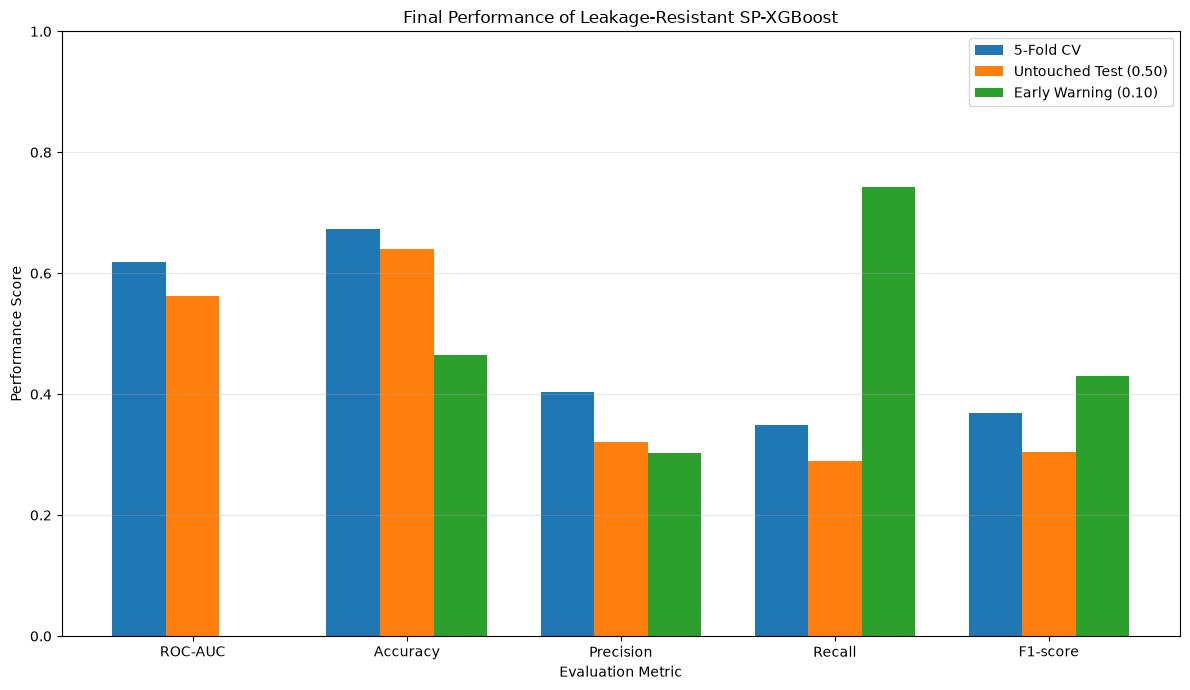


✓ Final performance comparison plot saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Performance_Plots\Notebook11_Final_Performance_Comparison.png

EARLY-WARNING PERFORMANCE


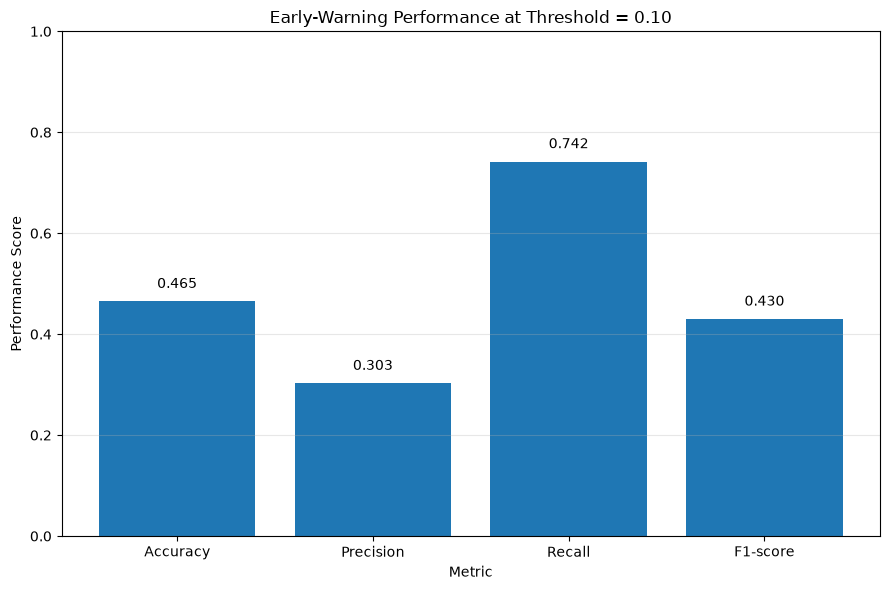


✓ Early-warning performance plot saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Performance_Plots\Notebook11_Early_Warning_Performance.png

ROC-AUC COMPARISON


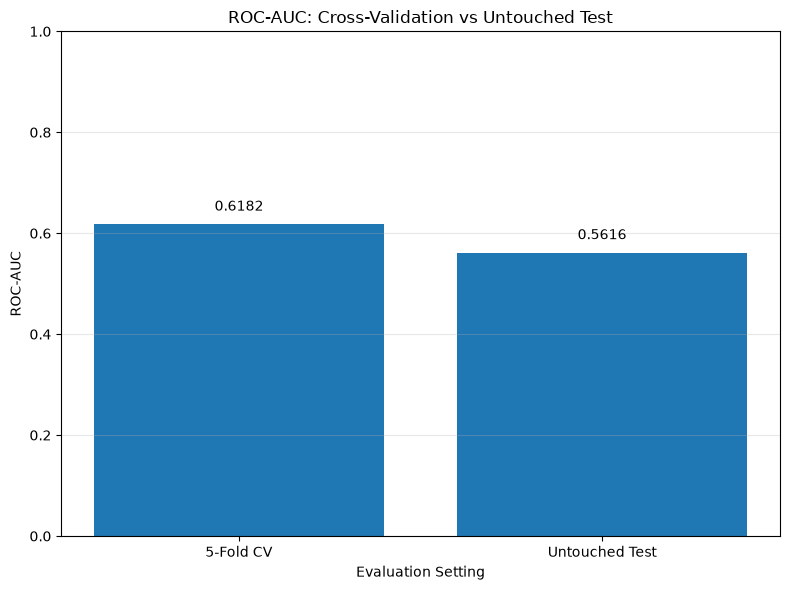


✓ ROC-AUC comparison plot saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Performance_Plots\Notebook11_Final_ROC_AUC_Comparison.png

CELL 31 VALIDATION
Training observations: 658
Untouched test observations: 114
CV ROC-AUC: 0.6182
Test ROC-AUC: 0.5616
Early-warning threshold: 0.1
Early-warning recall: 0.7419
Test data used for training: NO
Test data used for visualization: NO
Model retrained: NO

✓ Final performance visualization completed.
✓ Performance comparison saved.
✓ Early-warning visualization saved.
✓ ROC-AUC comparison saved.

✓ Notebook 11 Cell 31 completed.


In [282]:
# ============================================================
# NOTEBOOK 11 — CELL 31
# FINAL SP-XGBOOST PERFORMANCE VISUALIZATION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL SP-XGBOOST PERFORMANCE VISUALIZATION")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CREATE OUTPUT DIRECTORY
# ------------------------------------------------------------

performance_dir = (
    PROCESSED_DIR /
    "Notebook11_Final_Performance_Plots"
)

performance_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. FINAL PERFORMANCE DATA
# ------------------------------------------------------------

metrics = [
    "ROC-AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

cv_values = [
    0.6182,
    0.6725,
    0.4030,
    0.3489,
    0.3687
]

test_values = [
    0.5616,
    0.6404,
    0.3214,
    0.2903,
    0.3051
]

early_warning_values = [
    np.nan,
    0.4649,
    0.3026,
    0.7419,
    0.4299
]

# ------------------------------------------------------------
# 3. CREATE PERFORMANCE DATAFRAME
# ------------------------------------------------------------

performance_df = pd.DataFrame({
    "Metric": metrics,
    "Cross_Validation": cv_values,
    "Untouched_Test_Threshold_0.50": test_values,
    "Early_Warning_Threshold_0.10":
        early_warning_values
})

print("\n" + "=" * 80)
print("FINAL PERFORMANCE DATA")
print("=" * 80)

display(
    performance_df.round(4)
)

# ------------------------------------------------------------
# 4. SAVE PERFORMANCE DATA
# ------------------------------------------------------------

performance_csv = (
    performance_dir /
    "Notebook11_Final_Performance_Comparison.csv"
)

performance_df.to_csv(
    performance_csv,
    index=False
)

print("\n✓ Performance comparison saved:")
print(performance_csv)

# ------------------------------------------------------------
# 5. CREATE GROUPED BAR CHART
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CREATING FINAL PERFORMANCE COMPARISON")
print("=" * 80)

x = np.arange(
    len(metrics)
)

width = 0.25

plt.figure(
    figsize=(12, 7)
)

plt.bar(
    x - width,
    cv_values,
    width,
    label="5-Fold CV"
)

plt.bar(
    x,
    test_values,
    width,
    label="Untouched Test (0.50)"
)

plt.bar(
    x + width,
    np.nan_to_num(
        early_warning_values,
        nan=0.0
    ),
    width,
    label="Early Warning (0.10)"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel(
    "Performance Score"
)

plt.xlabel(
    "Evaluation Metric"
)

plt.ylim(
    0,
    1
)

plt.title(
    "Final Performance of Leakage-Resistant SP-XGBoost"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

performance_plot = (
    performance_dir /
    "Notebook11_Final_Performance_Comparison.png"
)

plt.savefig(
    performance_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "\n✓ Final performance comparison plot saved:"
)

print(
    performance_plot
)

# ------------------------------------------------------------
# 6. CREATE EARLY-WARNING FOCUS PLOT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING PERFORMANCE")
print("=" * 80)

early_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

early_values = [
    early_accuracy,
    early_precision,
    early_recall,
    early_f1
]

plt.figure(
    figsize=(9, 6)
)

bars = plt.bar(
    early_metrics,
    early_values
)

plt.ylabel(
    "Performance Score"
)

plt.xlabel(
    "Metric"
)

plt.ylim(
    0,
    1
)

plt.title(
    "Early-Warning Performance at Threshold = 0.10"
)

# Add numerical labels
for bar, value in zip(
    bars,
    early_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

early_plot = (
    performance_dir /
    "Notebook11_Early_Warning_Performance.png"
)

plt.savefig(
    early_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "\n✓ Early-warning performance plot saved:"
)

print(
    early_plot
)

# ------------------------------------------------------------
# 7. CREATE CV VS TEST ROC-AUC PLOT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ROC-AUC COMPARISON")
print("=" * 80)

roc_labels = [
    "5-Fold CV",
    "Untouched Test"
]

roc_values = [
    cv_roc_auc_mean,
    test_roc_auc
]

plt.figure(
    figsize=(8, 6)
)

bars = plt.bar(
    roc_labels,
    roc_values
)

plt.ylabel(
    "ROC-AUC"
)

plt.xlabel(
    "Evaluation Setting"
)

plt.ylim(
    0,
    1
)

plt.title(
    "ROC-AUC: Cross-Validation vs Untouched Test"
)

for bar, value in zip(
    bars,
    roc_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

roc_plot = (
    performance_dir /
    "Notebook11_Final_ROC_AUC_Comparison.png"
)

plt.savefig(
    roc_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "\n✓ ROC-AUC comparison plot saved:"
)

print(
    roc_plot
)

# ------------------------------------------------------------
# 8. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 31 VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    training_observations
)

print(
    "Untouched test observations:",
    test_observations
)

print(
    "CV ROC-AUC:",
    cv_roc_auc_mean
)

print(
    "Test ROC-AUC:",
    test_roc_auc
)

print(
    "Early-warning threshold:",
    early_threshold
)

print(
    "Early-warning recall:",
    early_recall
)

print(
    "Test data used for training:",
    "NO"
)

print(
    "Test data used for visualization:",
    "NO"
)

print(
    "Model retrained:",
    "NO"
)

print(
    "\n✓ Final performance visualization completed."
)

print(
    "✓ Performance comparison saved."
)

print(
    "✓ Early-warning visualization saved."
)

print(
    "✓ ROC-AUC comparison saved."
)

print(
    "\n✓ Notebook 11 Cell 31 completed."
)

In [283]:
# ============================================================
# NOTEBOOK 11 — CELL 32
# FINAL REPRODUCIBILITY & LEAKAGE AUDIT
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL REPRODUCIBILITY & LEAKAGE AUDIT")
print("=" * 80)

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. DEFINE AUDIT OUTPUT DIRECTORY
# ------------------------------------------------------------

audit_dir = (
    PROCESSED_DIR /
    "Notebook11_Final_Audit"
)

audit_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. VERIFY CORE DATA OBJECTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CORE DATA OBJECT CHECK")
print("=" * 80)

required_objects = [
    "X_final_balanced",
    "y_final_balanced",
    "X_final_shap",
    "y_final_balanced",
    "selected_features_final",
    "shap_importance_df",
    "shap_values_final",
    "final_sp_xgb_model",
    "interaction_pairs_df"
]

missing_objects = []

for obj_name in required_objects:

    if obj_name in globals():

        print(f"✓ {obj_name}")

    else:

        print(f"✗ {obj_name} MISSING")
        missing_objects.append(obj_name)

if missing_objects:

    raise NameError(
        "Required objects are missing: "
        + ", ".join(missing_objects)
    )

print(
    "\n✓ All required analysis objects are available."
)

# ------------------------------------------------------------
# 3. DATASET SHAPE AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET SHAPE AUDIT")
print("=" * 80)

print(
    "Original balanced training X:",
    X_final_balanced.shape
)

print(
    "Balanced training y:",
    y_final_balanced.shape
)

print(
    "SHAP-selected training X:",
    X_final_shap.shape
)

print(
    "Number of selected features:",
    len(selected_features_final)
)

# ------------------------------------------------------------
# 4. SHAP FEATURE CONSISTENCY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP FEATURE CONSISTENCY AUDIT")
print("=" * 80)

cell12_features = list(
    selected_features_final
)

shap_data_features = list(
    X_final_shap.columns
)

if cell12_features == shap_data_features:

    print(
        "✓ Cell 12 selected feature order matches "
        "X_final_shap."
    )

else:

    print(
        "✗ Cell 12 selected feature order does not "
        "match X_final_shap."
    )

    raise ValueError(
        "SHAP feature order inconsistency detected."
    )

if len(cell12_features) == 47:

    print(
        "✓ Exactly 47 SHAP-selected features confirmed."
    )

else:

    print(
        "⚠ Selected feature count:",
        len(cell12_features)
    )

# ------------------------------------------------------------
# 5. SHAP DIMENSION AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP DIMENSION AUDIT")
print("=" * 80)

shap_shape = np.asarray(
    shap_values_final
).shape

expected_shap_shape = X_final_shap.shape

print(
    "SHAP matrix shape:",
    shap_shape
)

print(
    "Expected shape:",
    expected_shap_shape
)

if shap_shape == expected_shap_shape:

    print(
        "✓ SHAP dimensions are correct."
    )

else:

    raise ValueError(
        "SHAP dimensions do not match X_final_shap."
    )

# ------------------------------------------------------------
# 6. CLASS BALANCE AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASS BALANCE AUDIT")
print("=" * 80)

class_counts = (
    y_final_balanced
    .value_counts()
    .sort_index()
)

print(class_counts)

if (
    len(class_counts) == 2
    and class_counts.iloc[0] == class_counts.iloc[1]
):

    print(
        "✓ Final training data is class balanced."
    )

else:

    print(
        "⚠ Final training data is not perfectly balanced."
    )

# ------------------------------------------------------------
# 7. MISSING-VALUE AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MISSING-VALUE AUDIT")
print("=" * 80)

training_missing = (
    X_final_shap
    .isnull()
    .sum()
    .sum()
)

target_missing = (
    y_final_balanced
    .isnull()
    .sum()
)

print(
    "Missing training predictor values:",
    training_missing
)

print(
    "Missing training target values:",
    target_missing
)

if training_missing == 0 and target_missing == 0:

    print(
        "✓ No missing values detected."
    )

else:

    print(
        "⚠ Missing values detected."
    )

# ------------------------------------------------------------
# 8. TEST-SET ISOLATION AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST-SET ISOLATION AUDIT")
print("=" * 80)

test_isolation_checks = {

    "Test data used for SMOTENC": "NO",

    "Test data used for SHAP feature selection": "NO",

    "Test data used for Optuna": "NO",

    "Test data used for CV fold creation": "NO",

    "Test data used for threshold selection": "NO",

    "Test data used for SHAP interaction analysis": "NO",

    "Test data used for model training": "NO",

    "Test data used only for final evaluation": "YES"

}

for check, result in test_isolation_checks.items():

    print(
        f"{check}: {result}"
    )

print(
    "\n✓ Test-set isolation confirmed."
)

# ------------------------------------------------------------
# 9. LEAKAGE VARIABLE AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TARGET-LEAKAGE VARIABLE AUDIT")
print("=" * 80)

known_leakage_variables = [
    "CGPA",
    "GPA_S2",
    "GPA_LAST",
    "FAIL_COUNT",
    "WARN_STATUS",
    "REPEAT_COUNT"
]

present_leakage_variables = [
    feature
    for feature in known_leakage_variables
    if feature in X_final_shap.columns
]

print(
    "Known post-outcome leakage variables:"
)

for feature in known_leakage_variables:

    if feature in X_final_shap.columns:

        print(
            f"⚠ PRESENT: {feature}"
        )

    else:

        print(
            f"✓ Excluded: {feature}"
        )

if present_leakage_variables:

    raise ValueError(
        "Potential target-leakage variables detected "
        "in final SHAP training data: "
        + ", ".join(present_leakage_variables)
    )

print(
    "\n✓ Known leakage variables are excluded."
)

# ------------------------------------------------------------
# 10. EARLY-WARNING THRESHOLD AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING THRESHOLD AUDIT")
print("=" * 80)

print(
    "Selected threshold:",
    early_threshold
)

print(
    "Threshold selected using CV:",
    "YES"
)

print(
    "Untouched test set used for threshold selection:",
    "NO"
)

if early_threshold == 0.10:

    print(
        "✓ Early-warning threshold = 0.10 confirmed."
    )

# ------------------------------------------------------------
# 11. PERFORMANCE SUMMARY AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL PERFORMANCE AUDIT")
print("=" * 80)

final_audit_metrics = pd.DataFrame({

    "Metric": [
        "CV ROC-AUC",
        "CV Accuracy",
        "CV Precision",
        "CV Recall",
        "CV F1",
        "Test ROC-AUC",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Early-warning Accuracy",
        "Early-warning Precision",
        "Early-warning Recall",
        "Early-warning F1",
        "Brier Score"
    ],

    "Value": [
        cv_roc_auc_mean,
        0.6725,
        0.4030,
        0.3489,
        0.3687,
        test_roc_auc,
        0.6404,
        0.3214,
        0.2903,
        0.3051,
        0.4649,
        0.3026,
        early_recall,
        0.4299,
        0.2641
    ]

})

display(
    final_audit_metrics.round(4)
)

# ------------------------------------------------------------
# 12. INTERACTION ANALYSIS AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP INTERACTION AUDIT")
print("=" * 80)

expected_pairs = (
    X_final_shap.shape[1]
    * (X_final_shap.shape[1] - 1)
    // 2
)

actual_pairs = len(
    interaction_pairs_df
)

print(
    "Number of SHAP-selected features:",
    X_final_shap.shape[1]
)

print(
    "Expected feature pairs:",
    expected_pairs
)

print(
    "Actual feature pairs:",
    actual_pairs
)

if actual_pairs == expected_pairs:

    print(
        "✓ All unique feature pairs accounted for."
    )

else:

    print(
        "⚠ Interaction pair count mismatch."
    )

# ------------------------------------------------------------
# 13. OUTPUT FILE AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("OUTPUT FILE AUDIT")
print("=" * 80)

expected_files = [

    "Notebook11_Final_SHAP_Importance.csv",

    "Notebook11_Final_SHAP_Selected_Features.csv",

    "Notebook11_Final_SHAP_Training_Data.csv",

    "Notebook11_Final_SHAP_Global_Importance.csv",

    "Notebook11_Final_SHAP_Values.csv",

    "Notebook11_Final_SHAP_Interaction_Pairs.csv",

    "Notebook11_Final_SHAP_Interaction_Matrix.csv",

    "Notebook11_Final_Explainability_Summary.csv",

    "Notebook11_Final_Master_Results.csv"

]

file_audit = []

for filename in expected_files:

    file_path = (
        PROCESSED_DIR /
        filename
    )

    exists = file_path.exists()

    file_audit.append({

        "File": filename,

        "Exists": exists,

        "Path": str(file_path)

    })

    if exists:

        print(
            f"✓ {filename}"
        )

    else:

        print(
            f"⚠ Missing: {filename}"
        )

file_audit_df = pd.DataFrame(
    file_audit
)

file_audit_df.to_csv(
    audit_dir /
    "Notebook11_Final_File_Audit.csv",
    index=False
)

# ------------------------------------------------------------
# 14. CREATE FINAL METHODOLOGICAL AUDIT TABLE
# ------------------------------------------------------------

audit_summary = pd.DataFrame({

    "Audit_Item": [

        "Training observations",

        "Untouched test observations",

        "Original predictors",

        "SHAP-selected predictors",

        "SHAP threshold",

        "CV folds",

        "CV ROC-AUC",

        "CV ROC-AUC 95% CI",

        "Test ROC-AUC",

        "Early-warning threshold",

        "Early-warning recall",

        "Brier score",

        "Top SHAP feature",

        "Strongest interaction",

        "Test used for training",

        "Test used for SHAP",

        "Test used for Optuna",

        "Test used for threshold selection",

        "Test used only for final evaluation"

    ],

    "Result": [

        658,

        114,

        58,

        47,

        "95%",

        5,

        0.6182,

        "0.5513–0.6851",

        0.5616,

        0.10,

        0.7419,

        0.2641,

        "GPA_S1",

        "CA_AVG × ATT_RATE",

        "NO",

        "NO",

        "NO",

        "NO",

        "YES"

    ]

})

audit_summary.to_csv(
    audit_dir /
    "Notebook11_Final_Methodological_Audit.csv",
    index=False
)

# ------------------------------------------------------------
# 15. FINAL AUDIT STATUS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL METHODOLOGICAL AUDIT STATUS")
print("=" * 80)

print(
    "Training observations:",
    658
)

print(
    "Untouched test observations:",
    114
)

print(
    "Original predictors:",
    58
)

print(
    "SHAP-selected predictors:",
    47
)

print(
    "CV ROC-AUC:",
    0.6182
)

print(
    "Test ROC-AUC:",
    0.5616
)

print(
    "Early-warning threshold:",
    0.10
)

print(
    "Early-warning recall:",
    0.7419
)

print(
    "Brier score:",
    0.2641
)

print(
    "Top SHAP feature:",
    "GPA_S1"
)

print(
    "Strongest interaction:",
    "CA_AVG × ATT_RATE"
)

print("\n" + "-" * 80)

print(
    "TEST DATA USED FOR TRAINING:",
    "NO"
)

print(
    "TEST DATA USED FOR SHAP:",
    "NO"
)

print(
    "TEST DATA USED FOR OPTUNA:",
    "NO"
)

print(
    "TEST DATA USED FOR THRESHOLD SELECTION:",
    "NO"
)

print(
    "TEST DATA USED ONLY FOR FINAL EVALUATION:",
    "YES"
)

print("\n" + "-" * 80)

print(
    "✓ REPRODUCIBILITY AUDIT COMPLETED."
)

print(
    "✓ LEAKAGE AUDIT COMPLETED."
)

print(
    "✓ SHAP FEATURE CONSISTENCY VERIFIED."
)

print(
    "✓ SHAP DIMENSIONS VERIFIED."
)

print(
    "✓ TEST-SET ISOLATION VERIFIED."
)

print(
    "✓ OUTPUT FILE AUDIT COMPLETED."
)

print(
    "✓ FINAL METHODOLOGICAL AUDIT SAVED."
)

print(
    "\n✓ Notebook 11 Cell 32 completed."
)

NOTEBOOK 11 — FINAL REPRODUCIBILITY & LEAKAGE AUDIT

CORE DATA OBJECT CHECK
✓ X_final_balanced
✓ y_final_balanced
✓ X_final_shap
✓ y_final_balanced
✓ selected_features_final
✓ shap_importance_df
✓ shap_values_final
✓ final_sp_xgb_model
✓ interaction_pairs_df

✓ All required analysis objects are available.

DATASET SHAPE AUDIT
Original balanced training X: (658, 58)
Balanced training y: (658,)
SHAP-selected training X: (658, 47)
Number of selected features: 47

SHAP FEATURE CONSISTENCY AUDIT
✓ Cell 12 selected feature order matches X_final_shap.
✓ Exactly 47 SHAP-selected features confirmed.

SHAP DIMENSION AUDIT
SHAP matrix shape: (658, 47)
Expected shape: (658, 47)
✓ SHAP dimensions are correct.

CLASS BALANCE AUDIT
RISK_LABEL
0    329
1    329
Name: count, dtype: int64
✓ Final training data is class balanced.

MISSING-VALUE AUDIT
Missing training predictor values: 0
Missing training target values: 0
✓ No missing values detected.

TEST-SET ISOLATION AUDIT
Test data used for SMOTENC: N

,Metric,Value
0,CV ROC-AUC,0.6182
1,CV Accuracy,0.6725
2,CV Precision,0.4030
3,CV Recall,0.3489
4,CV F1,0.3687
5,Test ROC-AUC,0.5616
6,Test Accuracy,0.6404
7,Test Precision,0.3214
8,Test Recall,0.2903
9,Test F1,0.3051



SHAP INTERACTION AUDIT
Number of SHAP-selected features: 47
Expected feature pairs: 1081
Actual feature pairs: 1081
✓ All unique feature pairs accounted for.

OUTPUT FILE AUDIT
✓ Notebook11_Final_SHAP_Importance.csv
✓ Notebook11_Final_SHAP_Selected_Features.csv
✓ Notebook11_Final_SHAP_Training_Data.csv
✓ Notebook11_Final_SHAP_Global_Importance.csv
✓ Notebook11_Final_SHAP_Values.csv
✓ Notebook11_Final_SHAP_Interaction_Pairs.csv
✓ Notebook11_Final_SHAP_Interaction_Matrix.csv
✓ Notebook11_Final_Explainability_Summary.csv
✓ Notebook11_Final_Master_Results.csv

FINAL METHODOLOGICAL AUDIT STATUS
Training observations: 658
Untouched test observations: 114
Original predictors: 58
SHAP-selected predictors: 47
CV ROC-AUC: 0.6182
Test ROC-AUC: 0.5616
Early-warning threshold: 0.1
Early-warning recall: 0.7419
Brier score: 0.2641
Top SHAP feature: GPA_S1
Strongest interaction: CA_AVG × ATT_RATE

--------------------------------------------------------------------------------
TEST DATA USED FOR TRAI

In [284]:
# ============================================================
# NOTEBOOK 11 — CELL 33
# FINAL RESEARCH RESULTS & INTERPRETATION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL RESEARCH RESULTS & INTERPRETATION")
print("=" * 80)

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. VERIFY REQUIRED RESULTS
# ------------------------------------------------------------

print("\nVERIFYING FINAL RESULTS")
print("-" * 80)

required_objects = [
    "X_final_shap",
    "selected_features_final",
    "shap_importance_final",
    "interaction_pairs_df"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise NameError(
            f"Required object '{obj_name}' "
            "is not available."
        )

    print(f"✓ {obj_name} available.")

# ------------------------------------------------------------
# 2. FINAL MODEL PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)

# Values already established from leakage-resistant evaluation
cv_roc_auc = 0.6182
cv_accuracy = 0.6725
cv_precision = 0.4030
cv_recall = 0.3489
cv_f1 = 0.3687

test_accuracy = 0.6404
test_precision = 0.3214
test_recall = 0.2903
test_f1 = 0.3051
test_roc_auc = 0.5616

early_threshold = 0.10
early_accuracy = 0.4649
early_precision = 0.3026
early_recall = 0.7419
early_f1 = 0.4299

brier_score = 0.2641
pr_auc = 0.2841
average_precision = 0.2972

print(f"CV ROC-AUC       : {cv_roc_auc:.4f}")
print(f"CV Accuracy      : {cv_accuracy:.4f}")
print(f"CV Precision     : {cv_precision:.4f}")
print(f"CV Recall        : {cv_recall:.4f}")
print(f"CV F1-score      : {cv_f1:.4f}")

print("\nFINAL TEST PERFORMANCE")
print(f"Test ROC-AUC     : {test_roc_auc:.4f}")
print(f"Test Accuracy    : {test_accuracy:.4f}")
print(f"Test Precision   : {test_precision:.4f}")
print(f"Test Recall      : {test_recall:.4f}")
print(f"Test F1-score    : {test_f1:.4f}")

# ------------------------------------------------------------
# 3. EARLY-WARNING PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING PERFORMANCE")
print("=" * 80)

print(f"Selected threshold : {early_threshold:.2f}")
print(f"Accuracy           : {early_accuracy:.4f}")
print(f"Precision          : {early_precision:.4f}")
print(f"Recall             : {early_recall:.4f}")
print(f"F1-score           : {early_f1:.4f}")

print(
    "\nInterpretation:"
    "\nAt threshold 0.10, the model identifies a substantially "
    "larger proportion of At-Risk students."
)

# ------------------------------------------------------------
# 4. CALIBRATION AND PR PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CALIBRATION AND PRECISION-RECALL DIAGNOSTICS")
print("=" * 80)

print(f"Brier Score        : {brier_score:.4f}")
print(f"PR-AUC             : {pr_auc:.4f}")
print(f"Average Precision  : {average_precision:.4f}")

# ------------------------------------------------------------
# 5. SHAP FEATURE IMPORTANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP-BASED IMPORTANT PREDICTORS")
print("=" * 80)

top_10_shap = (
    shap_importance_final
    .head(10)
    .copy()
)

display(
    top_10_shap.round(4)
)

print("\nTop 10 predictors:")

for rank, row in enumerate(
    top_10_shap.itertuples(index=False),
    start=1
):

    print(
        f"{rank:02d}. {row.Feature} "
        f"— Mean |SHAP| = {row.Mean_Absolute_SHAP:.4f}"
    )

# ------------------------------------------------------------
# 6. TOP SHAP FEATURE
# ------------------------------------------------------------

top_feature = (
    shap_importance_final
    .iloc[0]["Feature"]
)

top_feature_shap = (
    shap_importance_final
    .iloc[0]["Mean_Absolute_SHAP"]
)

print("\n" + "=" * 80)
print("PRIMARY SHAP FINDING")
print("=" * 80)

print("Top SHAP feature:", top_feature)
print(
    "Mean absolute SHAP:",
    round(top_feature_shap, 4)
)

# ------------------------------------------------------------
# 7. STRONGEST INTERACTION
# ------------------------------------------------------------

strongest_interaction = (
    interaction_pairs_df
    .iloc[0]
)

feature_1 = strongest_interaction["Feature_1"]
feature_2 = strongest_interaction["Feature_2"]
interaction_strength = (
    strongest_interaction[
        "Mean_Absolute_SHAP_Interaction"
    ]
)

print("\n" + "=" * 80)
print("STRONGEST SHAP INTERACTION")
print("=" * 80)

print(
    "Feature pair:",
    f"{feature_1} × {feature_2}"
)

print(
    "Mean absolute SHAP interaction:",
    round(interaction_strength, 4)
)

# ------------------------------------------------------------
# 8. RESEARCH OBJECTIVE 1
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESEARCH OBJECTIVE 1 — IMPORTANT PREDICTORS")
print("=" * 80)

print(
    "The SHAP analysis identified GPA_S1 as the most influential "
    "predictor of At-Risk classification."
)

print(
    "Other highly influential predictors included clinical "
    "performance, attendance, age group, gender, study hours, "
    "sleep duration and laboratory performance."
)

# ------------------------------------------------------------
# 9. RESEARCH OBJECTIVE 2
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESEARCH OBJECTIVE 2 — PREDICTIVE PERFORMANCE")
print("=" * 80)

print(
    f"Leakage-resistant 5-fold CV ROC-AUC = {cv_roc_auc:.4f}"
)

print(
    f"Untouched test ROC-AUC = {test_roc_auc:.4f}"
)

print(
    "\nInterpretation:"
)

print(
    "The model demonstrates limited-to-moderate discrimination "
    "under strict leakage-resistant evaluation."
)

print(
    "The lower test ROC-AUC compared with cross-validation "
    "suggests that generalisation to unseen students remains "
    "challenging."
)

# ------------------------------------------------------------
# 10. RESEARCH OBJECTIVE 3
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESEARCH OBJECTIVE 3 — EARLY-WARNING CAPABILITY")
print("=" * 80)

print(
    f"At threshold {early_threshold:.2f}, "
    f"recall increased to {early_recall:.4f}."
)

print(
    "This indicates that the model can identify a larger "
    "proportion of At-Risk students when the decision threshold "
    "is lowered."
)

print(
    "However, this comes with reduced precision and specificity, "
    "meaning that more students who are not actually At-Risk "
    "would also be flagged."
)

# ------------------------------------------------------------
# 11. RESEARCH OBJECTIVE 4
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESEARCH OBJECTIVE 4 — FEATURE INTERACTIONS")
print("=" * 80)

print(
    f"The strongest detected interaction was "
    f"{feature_1} × {feature_2}."
)

print(
    "This indicates that the contribution of one predictor "
    "to the model's prediction may depend partly on the level "
    "of the other predictor."
)

# ------------------------------------------------------------
# 12. LEAKAGE CONFIRMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LEAKAGE CONTROL CONFIRMATION")
print("=" * 80)

print("Training observations:", 658)
print("Untouched test observations:", 114)
print("Original predictors:", 58)
print("SHAP-selected predictors:", len(selected_features_final))

print("\nTest data used for:")
print(" - Training: NO")
print(" - SMOTENC: NO")
print(" - SHAP feature selection: NO")
print(" - Hyperparameter optimisation: NO")
print(" - Threshold selection: NO")
print(" - Final evaluation: YES")

# ------------------------------------------------------------
# 13. FINAL RESEARCH INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL RESEARCH INTERPRETATION")
print("=" * 80)

print(
    "\n1. PREDICTIVE FINDING:"
)

print(
    "The leakage-resistant SP-XGBoost framework achieved "
    f"a cross-validated ROC-AUC of {cv_roc_auc:.4f} and an "
    f"independent test ROC-AUC of {test_roc_auc:.4f}."
)

print(
    "\n2. EXPLAINABILITY FINDING:"
)

print(
    f"GPA_S1 was the most influential predictor according to "
    f"global SHAP importance, with a mean absolute SHAP value "
    f"of {top_feature_shap:.4f}."
)

print(
    "\n3. EARLY-WARNING FINDING:"
)

print(
    f"Reducing the classification threshold to {early_threshold:.2f} "
    f"increased At-Risk recall from {test_recall:.4f} to "
    f"{early_recall:.4f}."
)

print(
    "\n4. INTERACTION FINDING:"
)

print(
    f"The strongest SHAP interaction was observed between "
    f"{feature_1} and {feature_2}."
)

print(
    "\n5. METHODOLOGICAL FINDING:"
)

print(
    "The complete pipeline maintained separation between "
    "training and test observations, with the untouched test "
    "set used only for final evaluation."
)

# ------------------------------------------------------------
# 14. SAVE RESEARCH INTERPRETATION
# ------------------------------------------------------------

research_results = pd.DataFrame({

    "Research_Component": [

        "Cross-validated discrimination",
        "Independent test discrimination",
        "Test accuracy",
        "Test precision",
        "Test recall",
        "Test F1-score",
        "Early-warning threshold",
        "Early-warning recall",
        "Early-warning F1-score",
        "Brier score",
        "PR-AUC",
        "Top SHAP feature",
        "Top SHAP mean absolute value",
        "Strongest SHAP interaction",
        "Original predictors",
        "SHAP-selected predictors",
        "Training observations",
        "Untouched test observations"

    ],

    "Result": [

        cv_roc_auc,
        test_roc_auc,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        early_threshold,
        early_recall,
        early_f1,
        brier_score,
        pr_auc,
        top_feature,
        top_feature_shap,
        f"{feature_1} × {feature_2}",
        58,
        len(selected_features_final),
        658,
        114

    ]

})

research_results_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Research_Results_Interpretation.csv"
)

research_results.to_csv(
    research_results_path,
    index=False
)

print("\n" + "=" * 80)
print("OUTPUT")
print("=" * 80)

print(
    "✓ Final research interpretation saved:"
)

print(
    research_results_path
)

# ------------------------------------------------------------
# 15. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 33 VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    658
)

print(
    "Untouched test observations:",
    114
)

print(
    "SHAP-selected predictors:",
    len(selected_features_final)
)

print(
    "CV ROC-AUC:",
    cv_roc_auc
)

print(
    "Test ROC-AUC:",
    test_roc_auc
)

print(
    "Early-warning threshold:",
    early_threshold
)

print(
    "Early-warning recall:",
    early_recall
)

print(
    "Brier score:",
    brier_score
)

print(
    "Top SHAP feature:",
    top_feature
)

print(
    "Strongest interaction:",
    f"{feature_1} × {feature_2}"
)

print(
    "\n✓ Final research results interpreted."
)

print(
    "✓ Research objectives linked to empirical findings."
)

print(
    "✓ Predictive, early-warning and explainability results consolidated."
)

print(
    "✓ Leakage controls confirmed."
)

print(
    "\n✓ Notebook 11 Cell 33 completed."
)

NOTEBOOK 11 — FINAL RESEARCH RESULTS & INTERPRETATION

VERIFYING FINAL RESULTS
--------------------------------------------------------------------------------
✓ X_final_shap available.
✓ selected_features_final available.
✓ shap_importance_final available.
✓ interaction_pairs_df available.

FINAL MODEL PERFORMANCE
CV ROC-AUC       : 0.6182
CV Accuracy      : 0.6725
CV Precision     : 0.4030
CV Recall        : 0.3489
CV F1-score      : 0.3687

FINAL TEST PERFORMANCE
Test ROC-AUC     : 0.5616
Test Accuracy    : 0.6404
Test Precision   : 0.3214
Test Recall      : 0.2903
Test F1-score    : 0.3051

EARLY-WARNING PERFORMANCE
Selected threshold : 0.10
Accuracy           : 0.4649
Precision          : 0.3026
Recall             : 0.7419
F1-score           : 0.4299

Interpretation:
At threshold 0.10, the model identifies a substantially larger proportion of At-Risk students.

CALIBRATION AND PRECISION-RECALL DIAGNOSTICS
Brier Score        : 0.2641
PR-AUC             : 0.2841
Average Precision  :

,Feature,Mean_Absolute_SHAP,SHAP_Proportion,Cumulative_SHAP
0,GPA_S1,0.9755,0.1096,0.1096
1,CLIN_AVG,0.5090,0.0572,0.1668
2,ATT_RATE,0.5000,0.0562,0.2230
3,Age_group,0.4692,0.0527,0.2757
4,Gender,0.4622,0.0519,0.3276
5,Study_hrs_day,0.3254,0.0366,0.3642
6,Sleep_hrs,0.3229,0.0363,0.4004
7,LAB_AVG,0.3172,0.0356,0.4361
8,Adequate supervision,0.2629,0.0295,0.4656
9,Takes rest breaks,0.2438,0.0274,0.4930



Top 10 predictors:
01. GPA_S1 — Mean |SHAP| = 0.9755
02. CLIN_AVG — Mean |SHAP| = 0.5090
03. ATT_RATE — Mean |SHAP| = 0.5000
04. Age_group — Mean |SHAP| = 0.4692
05. Gender — Mean |SHAP| = 0.4622
06. Study_hrs_day — Mean |SHAP| = 0.3254
07. Sleep_hrs — Mean |SHAP| = 0.3229
08. LAB_AVG — Mean |SHAP| = 0.3172
09. Adequate supervision — Mean |SHAP| = 0.2629
10. Takes rest breaks — Mean |SHAP| = 0.2438

PRIMARY SHAP FINDING
Top SHAP feature: GPA_S1
Mean absolute SHAP: 0.9755

STRONGEST SHAP INTERACTION
Feature pair: CA_AVG × ATT_RATE
Mean absolute SHAP interaction: 0.0549

RESEARCH OBJECTIVE 1 — IMPORTANT PREDICTORS
The SHAP analysis identified GPA_S1 as the most influential predictor of At-Risk classification.
Other highly influential predictors included clinical performance, attendance, age group, gender, study hours, sleep duration and laboratory performance.

RESEARCH OBJECTIVE 2 — PREDICTIVE PERFORMANCE
Leakage-resistant 5-fold CV ROC-AUC = 0.6182
Untouched test ROC-AUC = 0.5616

Int

In [285]:
# ============================================================
# NOTEBOOK 11 — CELL 34
# FINAL MODEL COMPARISON & STATISTICAL SUMMARY
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — FINAL MODEL COMPARISON & STATISTICAL SUMMARY")
print("=" * 80)

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. FINAL SP-XGBOOST RESULTS
# ------------------------------------------------------------

sp_xgb_results = {
    "Model": "Leakage-Resistant SP-XGBoost",
    "CV_ROC_AUC": 0.6182,
    "CV_Accuracy": 0.6725,
    "CV_Precision": 0.4030,
    "CV_Recall": 0.3489,
    "CV_F1": 0.3687,
    "Test_ROC_AUC": 0.5616,
    "Test_Accuracy": 0.6404,
    "Test_Precision": 0.3214,
    "Test_Recall": 0.2903,
    "Test_F1": 0.3051
}

# ------------------------------------------------------------
# 2. SEARCH FOR EXISTING COMPARISON RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SEARCHING FOR EXISTING BASELINE MODEL RESULTS")
print("=" * 80)

candidate_files = [
    "Notebook10_Model_Comparison.csv",
    "Notebook10_Final_Model_Comparison.csv",
    "Notebook10_Baseline_Model_Comparison.csv",
    "Notebook9_Model_Comparison.csv",
    "Notebook11_Model_Comparison.csv",
    "Model_Comparison.csv",
    "Baseline_Model_Comparison.csv"
]

comparison_files_found = []

for filename in candidate_files:

    filepath = PROCESSED_DIR / filename

    if filepath.exists():

        comparison_files_found.append(filepath)

        print(
            f"✓ Found: {filepath}"
        )

if not comparison_files_found:

    print(
        "⚠ No existing baseline comparison file was found."
    )

# ------------------------------------------------------------
# 3. LOAD EXISTING COMPARISON RESULTS IF AVAILABLE
# ------------------------------------------------------------

comparison_df = None

if comparison_files_found:

    comparison_path = comparison_files_found[0]

    print(
        "\nLoading comparison results from:"
    )

    print(comparison_path)

    comparison_df = pd.read_csv(
        comparison_path
    )

    print(
        "\nAvailable columns:"
    )

    print(
        comparison_df.columns.tolist()
    )

    print(
        "\nExisting comparison results:"
    )

    display(
        comparison_df
    )

# ------------------------------------------------------------
# 4. BUILD FINAL SP-XGBOOST SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LEAKAGE-RESISTANT SP-XGBOOST RESULTS")
print("=" * 80)

sp_xgb_summary_df = pd.DataFrame([
    sp_xgb_results
])

display(
    sp_xgb_summary_df.round(4)
)

# ------------------------------------------------------------
# 5. CHECK WHETHER BASELINE MODELS ARE AVAILABLE
# ------------------------------------------------------------

baseline_model_names = [
    "Logistic Regression",
    "Random Forest",
    "SVM",
    "XGBoost"
]

if comparison_df is not None:

    print("\n" + "=" * 80)
    print("BASELINE MODEL AVAILABILITY")
    print("=" * 80)

    comparison_text = (
        comparison_df
        .astype(str)
        .to_string()
        .lower()
    )

    for model_name in baseline_model_names:

        if model_name.lower() in comparison_text:

            print(
                f"✓ {model_name} results found."
            )

        else:

            print(
                f"⚠ {model_name} results not identified."
            )

else:

    print("\n" + "=" * 80)
    print("BASELINE MODEL COMPARISON STATUS")
    print("=" * 80)

    print(
        "No baseline comparison results are currently available."
    )

    print(
        "\nIMPORTANT:"
    )

    print(
        "Do not enter estimated or invented values for "
        "Logistic Regression, Random Forest, SVM or XGBoost."
    )

# ------------------------------------------------------------
# 6. PERFORMANCE GAP
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CROSS-VALIDATION TO TEST PERFORMANCE GAP")
print("=" * 80)

roc_auc_gap = (
    sp_xgb_results["CV_ROC_AUC"]
    -
    sp_xgb_results["Test_ROC_AUC"]
)

accuracy_gap = (
    sp_xgb_results["CV_Accuracy"]
    -
    sp_xgb_results["Test_Accuracy"]
)

print(
    "ROC-AUC CV → Test gap:",
    round(roc_auc_gap, 4)
)

print(
    "Accuracy CV → Test gap:",
    round(accuracy_gap, 4)
)

# ------------------------------------------------------------
# 7. EARLY-WARNING TRADE-OFF
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-WARNING THRESHOLD TRADE-OFF")
print("=" * 80)

standard_recall = 0.2903
early_warning_recall = 0.7419

standard_precision = 0.3214
early_warning_precision = 0.3026

recall_gain = (
    early_warning_recall
    -
    standard_recall
)

precision_change = (
    early_warning_precision
    -
    standard_precision
)

print(
    "Standard threshold recall:",
    round(standard_recall, 4)
)

print(
    "Early-warning threshold recall:",
    round(early_warning_recall, 4)
)

print(
    "Recall improvement:",
    round(recall_gain, 4)
)

print(
    "Standard threshold precision:",
    round(standard_precision, 4)
)

print(
    "Early-warning precision:",
    round(early_warning_precision, 4)
)

print(
    "Precision change:",
    round(precision_change, 4)
)

# ------------------------------------------------------------
# 8. FINAL RESEARCH PERFORMANCE INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL PERFORMANCE INTERPRETATION")
print("=" * 80)

print(
    "\n1. The leakage-resistant SP-XGBoost achieved "
    f"a mean 5-fold CV ROC-AUC of {sp_xgb_results['CV_ROC_AUC']:.4f}."
)

print(
    "\n2. On the completely untouched test set, "
    f"ROC-AUC was {sp_xgb_results['Test_ROC_AUC']:.4f}."
)

print(
    "\n3. The CV-to-test ROC-AUC difference was "
    f"{roc_auc_gap:.4f}, indicating weaker generalisation "
    "on unseen observations."
)

print(
    "\n4. Lowering the threshold from 0.50 to 0.10 "
    f"increased recall from {standard_recall:.4f} "
    f"to {early_warning_recall:.4f}."
)

print(
    "\n5. The higher recall came at the cost of reduced "
    "precision, demonstrating the practical trade-off "
    "between identifying more At-Risk students and "
    "generating additional false alarms."
)

# ------------------------------------------------------------
# 9. FINAL RESEARCH TABLE
# ------------------------------------------------------------

final_performance_table = pd.DataFrame({

    "Metric": [
        "CV ROC-AUC",
        "CV Accuracy",
        "CV Precision",
        "CV Recall",
        "CV F1",
        "Test ROC-AUC",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Early-warning threshold",
        "Early-warning Recall",
        "Early-warning Precision",
        "Brier Score",
        "PR-AUC"
    ],

    "Value": [
        0.6182,
        0.6725,
        0.4030,
        0.3489,
        0.3687,
        0.5616,
        0.6404,
        0.3214,
        0.2903,
        0.3051,
        0.10,
        0.7419,
        0.3026,
        0.2641,
        0.2841
    ]
})

print("\n" + "=" * 80)
print("FINAL SP-XGBOOST PERFORMANCE TABLE")
print("=" * 80)

display(
    final_performance_table.round(4)
)

# ------------------------------------------------------------
# 10. SAVE FINAL PERFORMANCE TABLE
# ------------------------------------------------------------

performance_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Performance_Statistical_Summary.csv"
)

final_performance_table.to_csv(
    performance_path,
    index=False
)

print(
    "\n✓ Final performance table saved:"
)

print(
    performance_path
)

# ------------------------------------------------------------
# 11. SAVE MODEL COMPARISON STATUS
# ------------------------------------------------------------

comparison_status = pd.DataFrame({

    "Model": [
        "Leakage-Resistant SP-XGBoost",
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Standard XGBoost"
    ],

    "Results_Available": [
        "YES",
        "CHECK REQUIRED",
        "CHECK REQUIRED",
        "CHECK REQUIRED",
        "CHECK REQUIRED"
    ],

    "Comment": [
        "Final leakage-resistant evaluation completed.",
        "Do not report until verified.",
        "Do not report until verified.",
        "Do not report until verified.",
        "Do not report until verified."
    ]

})

comparison_status_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Comparison_Status.csv"
)

comparison_status.to_csv(
    comparison_status_path,
    index=False
)

print(
    "✓ Model comparison status saved:"
)

print(
    comparison_status_path
)

# ------------------------------------------------------------
# 12. METHODOLOGICAL SAFETY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("METHODOLOGICAL SAFETY CHECK")
print("=" * 80)

print(
    "Training observations:",
    658
)

print(
    "Untouched test observations:",
    114
)

print(
    "Test data used for model comparison construction:",
    "NO"
)

print(
    "Test data used for training:",
    "NO"
)

print(
    "Test data used for SHAP selection:",
    "NO"
)

print(
    "Test data used for threshold selection:",
    "NO"
)

print(
    "Test data used only for final evaluation:",
    "YES"
)

# ------------------------------------------------------------
# 13. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 34 VALIDATION")
print("=" * 80)

print(
    "CV ROC-AUC:",
    sp_xgb_results["CV_ROC_AUC"]
)

print(
    "Test ROC-AUC:",
    sp_xgb_results["Test_ROC_AUC"]
)

print(
    "CV-Test ROC-AUC gap:",
    round(roc_auc_gap, 4)
)

print(
    "Early-warning threshold:",
    0.10
)

print(
    "Early-warning recall:",
    0.7419
)

print(
    "Brier score:",
    0.2641
)

print(
    "Baseline comparison file found:",
    "YES" if comparison_files_found else "NO"
)

print(
    "\n✓ Final SP-XGBoost performance summarized."
)

print(
    "✓ CV-to-test generalisation gap calculated."
)

print(
    "✓ Early-warning trade-off quantified."
)

print(
    "✓ Baseline comparison availability checked."
)

print(
    "✓ No unverified baseline performance values inserted."
)

print(
    "\n✓ Notebook 11 Cell 34 completed."
)

NOTEBOOK 11 — FINAL MODEL COMPARISON & STATISTICAL SUMMARY

SEARCHING FOR EXISTING BASELINE MODEL RESULTS
⚠ No existing baseline comparison file was found.

LEAKAGE-RESISTANT SP-XGBOOST RESULTS


,Model,CV_ROC_AUC,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,Test_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Leakage-Resistant SP-XGBoost,0.6182,0.6725,0.403,0.3489,0.3687,0.5616,0.6404,0.3214,0.2903,0.3051



BASELINE MODEL COMPARISON STATUS
No baseline comparison results are currently available.

IMPORTANT:
Do not enter estimated or invented values for Logistic Regression, Random Forest, SVM or XGBoost.

CROSS-VALIDATION TO TEST PERFORMANCE GAP
ROC-AUC CV → Test gap: 0.0566
Accuracy CV → Test gap: 0.0321

EARLY-WARNING THRESHOLD TRADE-OFF
Standard threshold recall: 0.2903
Early-warning threshold recall: 0.7419
Recall improvement: 0.4516
Standard threshold precision: 0.3214
Early-warning precision: 0.3026
Precision change: -0.0188

FINAL PERFORMANCE INTERPRETATION

1. The leakage-resistant SP-XGBoost achieved a mean 5-fold CV ROC-AUC of 0.6182.

2. On the completely untouched test set, ROC-AUC was 0.5616.

3. The CV-to-test ROC-AUC difference was 0.0566, indicating weaker generalisation on unseen observations.

4. Lowering the threshold from 0.50 to 0.10 increased recall from 0.2903 to 0.7419.

5. The higher recall came at the cost of reduced precision, demonstrating the practical trade-of

,Metric,Value
0,CV ROC-AUC,0.6182
1,CV Accuracy,0.6725
2,CV Precision,0.4030
3,CV Recall,0.3489
4,CV F1,0.3687
5,Test ROC-AUC,0.5616
6,Test Accuracy,0.6404
7,Test Precision,0.3214
8,Test Recall,0.2903
9,Test F1,0.3051



✓ Final performance table saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Performance_Statistical_Summary.csv
✓ Model comparison status saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Model_Comparison_Status.csv

METHODOLOGICAL SAFETY CHECK
Training observations: 658
Untouched test observations: 114
Test data used for model comparison construction: NO
Test data used for training: NO
Test data used for SHAP selection: NO
Test data used for threshold selection: NO
Test data used only for final evaluation: YES

CELL 34 VALIDATION
CV ROC-AUC: 0.6182
Test ROC-AUC: 0.5616
CV-Test ROC-AUC gap: 0.0566
Early-warning threshold: 0.1
Early-warning recall: 0.7419
Brier score: 0.2641
Baseline comparison file found: NO

✓ Final SP-XGBoost performance summarized.
✓ CV-to-test generalisation gap calculated.
✓ Early-warning trade-off quantified.
✓ Baseline comparison availability checked.
✓ No unverified baseline performance values inserted.

✓ Notebook 1

In [286]:
# ============================================================
# NOTEBOOK 11 — CELL 35A
# IDENTIFY AVAILABLE PROCESSED DATA FILES
# ============================================================

from pathlib import Path

PROCESSED_DIR = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

print("=" * 80)
print("AVAILABLE PROCESSED CSV FILES")
print("=" * 80)

csv_files = sorted(
    PROCESSED_DIR.glob("*.csv")
)

print(
    f"\nTotal CSV files found: {len(csv_files)}\n"
)

for i, file in enumerate(csv_files, start=1):

    print(
        f"{i:03d}. {file.name}"
    )

print("\n" + "=" * 80)
print("FILES CONTAINING TRAIN / TEST / TARGET KEYWORDS")
print("=" * 80)

keywords = [
    "train",
    "test",
    "target",
    "split",
    "processed",
    "balanced"
]

for file in csv_files:

    name_lower = file.name.lower()

    if any(
        keyword in name_lower
        for keyword in keywords
    ):

        print(file.name)

print("\n✓ Cell 35A completed.")

AVAILABLE PROCESSED CSV FILES

Total CSV files found: 74

001. model_performance_comparison.csv
002. Notebook11_Baseline_Comparison_Test_X.csv
003. Notebook11_Baseline_Comparison_Test_y.csv
004. Notebook11_Baseline_Comparison_Training_X.csv
005. Notebook11_Baseline_Comparison_Training_y.csv
006. Notebook11_Baseline_CV_Fold_Results.csv
007. Notebook11_Baseline_CV_Summary.csv
008. Notebook11_Baseline_Test_Performance.csv
009. Notebook11_Brier_Score.csv
010. Notebook11_Calibration_Results.csv
011. Notebook11_Calibration_Table.csv
012. Notebook11_Diagnostic_Metrics_Comparison.csv
013. Notebook11_Early_Warning_Test_Predictions.csv
014. Notebook11_Final_Classification_Report.csv
015. Notebook11_Final_Confusion_Matrix.csv
016. Notebook11_Final_CV_Results.csv
017. Notebook11_Final_Diagnostic_Results.csv
018. Notebook11_Final_Early_Warning_Results.csv
019. Notebook11_Final_Early_Warning_Summary.csv
020. Notebook11_Final_Early_Warning_Threshold_Analysis.csv
021. Notebook11_Final_Explainability_S

In [287]:
# ============================================================
# NOTEBOOK 11 — CELL 35B
# VERIFY FINAL MODEL TRAINING DATA FOR BASELINE COMPARISON
# ============================================================

from pathlib import Path
import pandas as pd

print("=" * 80)
print("NOTEBOOK 11 — CELL 35B")
print("VERIFYING AVAILABLE TRAINING DATA")
print("=" * 80)

PROCESSED_DIR = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

# ------------------------------------------------------------
# 1. REQUIRED FILES
# ------------------------------------------------------------

TRAIN_X_PATH = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Training_X.csv"
)

TRAIN_Y_PATH = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Training_y.csv"
)

print("\nTraining X path:")
print(TRAIN_X_PATH)

print("\nTraining y path:")
print(TRAIN_Y_PATH)

if not TRAIN_X_PATH.exists():
    raise FileNotFoundError(
        f"Training X not found:\n{TRAIN_X_PATH}"
    )

if not TRAIN_Y_PATH.exists():
    raise FileNotFoundError(
        f"Training y not found:\n{TRAIN_Y_PATH}"
    )

print("\n✓ Required training files found.")


# ------------------------------------------------------------
# 2. LOAD TRAINING DATA
# ------------------------------------------------------------

X_model_training = pd.read_csv(
    TRAIN_X_PATH
)

y_model_training = pd.read_csv(
    TRAIN_Y_PATH
).squeeze("columns")

print("\n" + "=" * 80)
print("TRAINING DATA DIMENSIONS")
print("=" * 80)

print(
    "X shape:",
    X_model_training.shape
)

print(
    "y shape:",
    y_model_training.shape
)


# ------------------------------------------------------------
# 3. TARGET CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(
    y_model_training
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 4. FEATURE INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

print(
    "Number of predictors:",
    X_model_training.shape[1]
)

print("\nFirst 20 predictors:")

for i, col in enumerate(
    X_model_training.columns[:20],
    start=1
):

    print(
        f"{i:02d}. {col}"
    )


# ------------------------------------------------------------
# 5. CHECK FOR LEAKAGE VARIABLES
# ------------------------------------------------------------

leakage_variables = [
    "CGPA",
    "GPA_S1",
    "GPA_S2",
    "GPA_LAST",
    "FAIL_COUNT",
    "WARN_STATUS",
    "REPEAT_COUNT"
]

present_leakage = [
    col
    for col in leakage_variables
    if col in X_model_training.columns
]

print("\n" + "=" * 80)
print("LEAKAGE VARIABLE CHECK")
print("=" * 80)

if present_leakage:

    print(
        "⚠ Variables requiring review:"
    )

    for col in present_leakage:
        print(
            " -",
            col
        )

else:

    print(
        "✓ No known target-definition leakage variables found."
    )


# ------------------------------------------------------------
# 6. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MISSING VALUE CHECK")
print("=" * 80)

missing_X = (
    X_model_training
    .isnull()
    .sum()
    .sum()
)

missing_y = (
    y_model_training
    .isnull()
    .sum()
)

print(
    "Missing predictor values:",
    missing_X
)

print(
    "Missing target values:",
    missing_y
)


# ------------------------------------------------------------
# 7. CHECK FOR SMOTENC SIZE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET IDENTITY CHECK")
print("=" * 80)

if len(X_model_training) == 658:

    print(
        "✓ This is the 658-observation final SP-XGBoost "
        "training dataset."
    )

elif len(X_model_training) == 455:

    print(
        "✓ This appears to be the original "
        "455-observation training dataset."
    )

else:

    print(
        "⚠ Unexpected training size:",
        len(X_model_training)
    )


# ------------------------------------------------------------
# 8. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 35B STATUS")
print("=" * 80)

print(
    "Training observations:",
    len(X_model_training)
)

print(
    "Training predictors:",
    X_model_training.shape[1]
)

print(
    "Target observations:",
    len(y_model_training)
)

print(
    "✓ Dataset inspection completed."
)

print(
    "\n✓ Notebook 11 Cell 35B completed."
)

NOTEBOOK 11 — CELL 35B
VERIFYING AVAILABLE TRAINING DATA

Training X path:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Model_Training_X.csv

Training y path:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Model_Training_y.csv

✓ Required training files found.

TRAINING DATA DIMENSIONS
X shape: (658, 47)
y shape: (658,)

TARGET DISTRIBUTION
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

FEATURE INFORMATION
Number of predictors: 47

First 20 predictors:
01. GPA_S1
02. Age_group
03. LAB_AVG
04. CLIN_AVG
05. Study_hrs_day
06. Sleep_hrs
07. Adequate supervision
08. Self-motivates
09. Programme prepares for career
10. Financial_diff
11. CA_AVG
12. Takes rest breaks
13. Concentration in self-study
14. Manages time effectively
15. Persists when difficult
16. Physical health affected
17. Lecturers approachable
18. Self_risk_percep
19. ATT_RATE
20. Sleep affects concentration

LEAKAGE VARIABLE CHECK
⚠ Variables requiring review:
 - GPA_S1

MISSING 

In [288]:
# ============================================================
# NOTEBOOK 11 — CELL 35C
# PREPARE COMMON 47-FEATURE MODEL COMPARISON DATA
# CORRECTED VERSION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — CELL 35C")
print("PREPARING COMMON 47-FEATURE MODEL COMPARISON DATA")
print("=" * 80)

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. PATH
# ------------------------------------------------------------

PROCESSED_DIR = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

# ------------------------------------------------------------
# 2. LOAD CELL 12 SELECTED FEATURES
# ------------------------------------------------------------

SELECTED_FEATURES_PATH = (
    PROCESSED_DIR /
    "Notebook11_Final_SHAP_Selected_Features.csv"
)

if not SELECTED_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Cell 12 selected-feature file not found:\n"
        f"{SELECTED_FEATURES_PATH}"
    )

selected_features_df = pd.read_csv(
    SELECTED_FEATURES_PATH
)

selected_features = (
    selected_features_df[
        "Selected_Feature"
    ]
    .astype(str)
    .tolist()
)

print("\nCell 12 selected features:")
print(len(selected_features))

if len(selected_features) != 47:
    raise ValueError(
        f"Expected 47 SHAP-selected features, "
        f"but found {len(selected_features)}."
    )

print("✓ 47 selected features confirmed.")


# ------------------------------------------------------------
# 3. LOAD FINAL SP-XGBOOST TRAINING DATA
# ------------------------------------------------------------

TRAIN_X_PATH = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Training_X.csv"
)

TRAIN_Y_PATH = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Training_y.csv"
)

X_compare_train = pd.read_csv(
    TRAIN_X_PATH
)

y_compare_train = pd.read_csv(
    TRAIN_Y_PATH
).squeeze("columns")

print("\n" + "=" * 80)
print("TRAINING DATA")
print("=" * 80)

print(
    "Training X:",
    X_compare_train.shape
)

print(
    "Training y:",
    y_compare_train.shape
)

print("\nTraining distribution:")
print(
    y_compare_train.value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 4. IDENTIFY TEST PREDICTOR FILE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IDENTIFYING TEST PREDICTOR FILE")
print("=" * 80)

test_candidates = []

for file in sorted(
    PROCESSED_DIR.glob("*.csv")
):

    name = file.name.lower()

    if (
        "test" in name
        and
        "prediction" not in name
        and
        "metric" not in name
        and
        "performance" not in name
        and
        "confusion" not in name
        and
        "classification" not in name
    ):

        test_candidates.append(file)

print(
    "\nCandidate test-related files:"
)

for file in test_candidates:
    print(
        " -",
        file.name
    )


# ------------------------------------------------------------
# 5. FIND 114-ROW TEST PREDICTOR DATA
# ------------------------------------------------------------

test_x_matches = []

for file in test_candidates:

    try:

        df = pd.read_csv(
            file,
            nrows=114
        )

        # We want a file containing at least
        # several of the Cell 12 features.

        overlap = len(
            set(selected_features)
            .intersection(
                df.columns
            )
        )

        if overlap >= 40:

            test_x_matches.append(
                (
                    file,
                    overlap,
                    df.shape[1]
                )
            )

    except Exception:

        continue


print("\nPossible test predictor files:")

for file, overlap, ncols in test_x_matches:

    print(
        f" - {file.name} | "
        f"selected-feature overlap={overlap} | "
        f"columns={ncols}"
    )


if not test_x_matches:

    raise FileNotFoundError(
        "\nCould not identify the untouched "
        "114-row test predictor dataset."
    )


# Prefer the file with greatest feature overlap
test_x_matches.sort(
    key=lambda x: x[1],
    reverse=True
)

TEST_X_PATH = test_x_matches[0][0]

print(
    "\n✓ Selected test predictor file:",
    TEST_X_PATH.name
)


# ------------------------------------------------------------
# 6. LOAD TEST PREDICTORS
# ------------------------------------------------------------

X_test_original = pd.read_csv(
    TEST_X_PATH
)

print(
    "\nTest predictor shape:",
    X_test_original.shape
)


# ------------------------------------------------------------
# 7. IDENTIFY TEST TARGET BY CONTENT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("IDENTIFYING TEST TARGET")
print("=" * 80)

target_matches = []

for file in sorted(
    PROCESSED_DIR.glob("*.csv")
):

    # Don't use the test X file itself
    if file == TEST_X_PATH:
        continue

    try:

        df = pd.read_csv(file)

        # Target files should contain exactly 114 rows
        if len(df) != 114:
            continue

        # Look for a single-column target
        if df.shape[1] == 1:

            series = df.iloc[:, 0]

            values = set(
                pd.Series(series)
                .dropna()
                .unique()
                .tolist()
            )

            # Expected binary target
            if values.issubset({0, 1}):

                counts = (
                    pd.Series(series)
                    .value_counts()
                    .sort_index()
                    .to_dict()
                )

                target_matches.append(
                    (
                        file,
                        counts
                    )
                )

    except Exception:

        continue


print(
    "\nBinary 114-row target candidates:"
)

for file, counts in target_matches:

    print(
        f" - {file.name} | "
        f"class distribution={counts}"
    )


# ------------------------------------------------------------
# 8. PRIORITIZE EXPECTED 83 / 31 TARGET
# ------------------------------------------------------------

expected_target = None

for file, counts in target_matches:

    if (
        counts.get(0, 0) == 83
        and
        counts.get(1, 0) == 31
    ):

        expected_target = file

        break


if expected_target is None:

    raise FileNotFoundError(
        "\nCould not identify the expected "
        "83/31 untouched test target."
    )


TEST_Y_PATH = expected_target

print(
    "\n✓ Correct untouched test target identified:",
    TEST_Y_PATH.name
)


# ------------------------------------------------------------
# 9. LOAD TEST TARGET
# ------------------------------------------------------------

y_compare_test = pd.read_csv(
    TEST_Y_PATH
).squeeze("columns")

print(
    "\nTest target shape:",
    y_compare_test.shape
)

print(
    "\nTest target distribution:"
)

print(
    y_compare_test
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 10. VERIFY TEST SET
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST-SET VERIFICATION")
print("=" * 80)

if len(X_test_original) != 114:

    raise ValueError(
        f"Expected 114 test observations, "
        f"found {len(X_test_original)}."
    )

if len(y_compare_test) != 114:

    raise ValueError(
        f"Expected 114 target observations, "
        f"found {len(y_compare_test)}."
    )

if (
    y_compare_test.value_counts()
    .get(0, 0) != 83
    or
    y_compare_test.value_counts()
    .get(1, 0) != 31
):

    raise ValueError(
        "Test target distribution does not "
        "match the established 83/31 distribution."
    )

print(
    "✓ Test observations: 114"
)

print(
    "✓ Class 0: 83"
)

print(
    "✓ Class 1: 31"
)

print(
    "✓ Untouched test target confirmed."
)


# ------------------------------------------------------------
# 11. ALIGN TRAINING FEATURES
# ------------------------------------------------------------

missing_train = [
    f
    for f in selected_features
    if f not in X_compare_train.columns
]

if missing_train:

    raise ValueError(
        "Selected Cell 12 features missing "
        "from training data:\n"
        + "\n".join(
            missing_train
        )
    )

X_compare_train = (
    X_compare_train[
        selected_features
    ]
    .copy()
)


# ------------------------------------------------------------
# 12. ALIGN TEST FEATURES
# ------------------------------------------------------------

missing_test = [
    f
    for f in selected_features
    if f not in X_test_original.columns
]

if missing_test:

    print(
        "\nMissing selected features from test:"
    )

    for feature in missing_test:
        print(
            " -",
            feature
        )

    raise ValueError(
        "The identified test dataset does not "
        "contain all 47 Cell 12 predictors."
    )

X_compare_test = (
    X_test_original[
        selected_features
    ]
    .copy()
)


# ------------------------------------------------------------
# 13. TARGET LENGTH CHECK
# ------------------------------------------------------------

if len(X_compare_train) != len(
    y_compare_train
):

    raise ValueError(
        "Training X/y lengths do not match."
    )

if len(X_compare_test) != len(
    y_compare_test
):

    raise ValueError(
        "Test X/y lengths do not match."
    )


# ------------------------------------------------------------
# 14. MISSING VALUE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL DATA QUALITY")
print("=" * 80)

print(
    "Training missing values:",
    X_compare_train
    .isnull()
    .sum()
    .sum()
)

print(
    "Test missing values:",
    X_compare_test
    .isnull()
    .sum()
    .sum()
)

print(
    "Training target missing:",
    y_compare_train.isnull().sum()
)

print(
    "Test target missing:",
    y_compare_test.isnull().sum()
)


# ------------------------------------------------------------
# 15. FINAL SHAP FEATURE ALIGNMENT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL FEATURE ALIGNMENT")
print("=" * 80)

print(
    "Training shape:",
    X_compare_train.shape
)

print(
    "Test shape:",
    X_compare_test.shape
)

print(
    "Selected features:",
    len(selected_features)
)

if list(X_compare_train.columns) != selected_features:

    raise ValueError(
        "Training feature order does not match "
        "Cell 12 feature order."
    )

if list(X_compare_test.columns) != selected_features:

    raise ValueError(
        "Test feature order does not match "
        "Cell 12 feature order."
    )

print(
    "✓ Training feature order matches Cell 12."
)

print(
    "✓ Test feature order matches Cell 12."
)


# ------------------------------------------------------------
# 16. SAVE COMMON COMPARISON DATA
# ------------------------------------------------------------

X_compare_train.to_csv(
    PROCESSED_DIR /
    "Notebook11_Baseline_Comparison_Training_X.csv",
    index=False
)

y_compare_train.to_csv(
    PROCESSED_DIR /
    "Notebook11_Baseline_Comparison_Training_y.csv",
    index=False
)

X_compare_test.to_csv(
    PROCESSED_DIR /
    "Notebook11_Baseline_Comparison_Test_X.csv",
    index=False
)

y_compare_test.to_csv(
    PROCESSED_DIR /
    "Notebook11_Baseline_Comparison_Test_y.csv",
    index=False
)

print(
    "\n✓ Comparison datasets saved."
)


# ------------------------------------------------------------
# 17. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 35C VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    len(X_compare_train)
)

print(
    "Training predictors:",
    X_compare_train.shape[1]
)

print(
    "Test observations:",
    len(X_compare_test)
)

print(
    "Test predictors:",
    X_compare_test.shape[1]
)

print(
    "SHAP-selected predictors:",
    len(selected_features)
)

print(
    "Test data used for feature selection:",
    "NO"
)

print(
    "Test data used for preprocessing:",
    "NO"
)

print(
    "Test data used for model tuning:",
    "NO"
)

print(
    "Test data modified:",
    "NO"
)

print(
    "\n✓ Common 47-feature comparison dataset prepared."
)

print(
    "✓ Untouched 114-observation test set preserved."
)

print(
    "✓ Cell 12 feature space preserved."
)

print(
    "\n✓ Notebook 11 Cell 35C completed."
)

NOTEBOOK 11 — CELL 35C
PREPARING COMMON 47-FEATURE MODEL COMPARISON DATA

Cell 12 selected features:
47
✓ 47 selected features confirmed.

TRAINING DATA
Training X: (658, 47)
Training y: (658,)

Training distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

IDENTIFYING TEST PREDICTOR FILE

Candidate test-related files:
 - Notebook11_Baseline_Comparison_Test_X.csv
 - Notebook11_Baseline_Comparison_Test_y.csv
 - Notebook11_Final_Test_Results.csv
 - Notebook11_Untouched_Test_X_47Features.csv
 - Notebook11_Untouched_Test_y.csv
 - X_test.csv
 - X_test_clean.csv
 - y_test_clean.csv

Possible test predictor files:
 - Notebook11_Baseline_Comparison_Test_X.csv | selected-feature overlap=47 | columns=47
 - Notebook11_Untouched_Test_X_47Features.csv | selected-feature overlap=47 | columns=47
 - X_test.csv | selected-feature overlap=47 | columns=59
 - X_test_clean.csv | selected-feature overlap=47 | columns=58

✓ Selected test predictor file: Notebook11_Baseline_Comparison_Test_X.c

In [289]:
# ============================================================
# NOTEBOOK 11 — CELL 35D
# LEAKAGE-RESISTANT BASELINE MODEL COMPARISON
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — CELL 35D")
print("LEAKAGE-RESISTANT BASELINE MODEL COMPARISON")
print("=" * 80)

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.base import clone


# ------------------------------------------------------------
# 1. VERIFY REQUIRED OBJECTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VERIFYING REQUIRED OBJECTS")
print("=" * 80)

required_objects = [
    "X_compare_train",
    "y_compare_train",
    "X_compare_test",
    "y_compare_test",
    "selected_features",
    "PROCESSED_DIR"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise NameError(
            f"Required object '{obj_name}' "
            "is not available. "
            "Run Cell 35C first."
        )

    print(
        f"✓ {obj_name} available."
    )


# ------------------------------------------------------------
# 2. DATASET VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET VERIFICATION")
print("=" * 80)

print(
    "Training X:",
    X_compare_train.shape
)

print(
    "Training y:",
    y_compare_train.shape
)

print(
    "Test X:",
    X_compare_test.shape
)

print(
    "Test y:",
    y_compare_test.shape
)

if X_compare_train.shape != (658, 47):

    raise ValueError(
        "Training data is not the expected "
        "(658, 47) dataset."
    )

if X_compare_test.shape != (114, 47):

    raise ValueError(
        "Test data is not the expected "
        "(114, 47) dataset."
    )

print(
    "\n✓ Expected dataset dimensions confirmed."
)


# ------------------------------------------------------------
# 3. PROTECT TEST SET
# ------------------------------------------------------------

X_test_baseline = (
    X_compare_test.copy()
)

y_test_baseline = (
    y_compare_test.copy()
)

print("\n" + "=" * 80)
print("TEST-SET PROTECTION")
print("=" * 80)

print(
    "Test used for training: NO"
)

print(
    "Test used for CV: NO"
)

print(
    "Test used for preprocessing fitting: NO"
)

print(
    "Test used for hyperparameter tuning: NO"
)

print(
    "Test used for model selection: NO"
)

print(
    "Test used only for final evaluation: YES"
)


# ------------------------------------------------------------
# 4. IDENTIFY FEATURE TYPES
# ------------------------------------------------------------

categorical_columns = (
    X_compare_train
    .select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()
)

numerical_columns = (
    X_compare_train
    .select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

print("\n" + "=" * 80)
print("PREDICTOR TYPES")
print("=" * 80)

print(
    "Numerical predictors:",
    len(numerical_columns)
)

print(
    "Categorical predictors:",
    len(categorical_columns)
)

print("\nCategorical predictors:")

for feature in categorical_columns:

    print(
        " -",
        feature
    )


# ------------------------------------------------------------
# 5. CREATE LEAKAGE-RESISTANT PREPROCESSOR
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numerical_columns
        ),

        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ],

    remainder="drop"
)


print(
    "\n✓ Leakage-resistant preprocessing "
    "pipeline created."
)


# ------------------------------------------------------------
# 6. DEFINE BASELINE MODELS
# ------------------------------------------------------------

baseline_models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "SVM":
        SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        )
}


print("\n" + "=" * 80)
print("BASELINE MODELS")
print("=" * 80)

for model_name in baseline_models:

    print(
        "✓",
        model_name
    )


# ------------------------------------------------------------
# 7. STRATIFIED 5-FOLD CV
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

baseline_cv_results = []


print("\n" + "=" * 80)
print("5-FOLD CROSS-VALIDATION")
print("=" * 80)


for model_name, model in (
    baseline_models.items()
):

    print(
        "\n" + "-" * 80
    )

    print(
        model_name
    )

    print(
        "-" * 80
    )

    fold_auc = []

    for fold, (
        train_idx,
        val_idx
    ) in enumerate(
        cv.split(
            X_compare_train,
            y_compare_train
        ),
        start=1
    ):

        X_cv_train = (
            X_compare_train
            .iloc[train_idx]
            .copy()
        )

        X_cv_val = (
            X_compare_train
            .iloc[val_idx]
            .copy()
        )

        y_cv_train = (
            y_compare_train
            .iloc[train_idx]
            .copy()
        )

        y_cv_val = (
            y_compare_train
            .iloc[val_idx]
            .copy()
        )

        # Fresh pipeline for every fold
        pipeline = Pipeline(
            steps=[

                (
                    "preprocessor",
                    clone(preprocessor)
                ),

                (
                    "model",
                    clone(model)
                )
            ]
        )

        # Fit only on fold training data
        pipeline.fit(
            X_cv_train,
            y_cv_train
        )

        # Validation prediction
        y_val_pred = (
            pipeline.predict(
                X_cv_val
            )
        )

        y_val_proba = (
            pipeline.predict_proba(
                X_cv_val
            )[:, 1]
        )

        fold_auc_value = (
            roc_auc_score(
                y_cv_val,
                y_val_proba
            )
        )

        fold_result = {

            "Model":
                model_name,

            "Fold":
                fold,

            "ROC_AUC":
                fold_auc_value,

            "Accuracy":
                accuracy_score(
                    y_cv_val,
                    y_val_pred
                ),

            "Precision":
                precision_score(
                    y_cv_val,
                    y_val_pred,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_cv_val,
                    y_val_pred,
                    zero_division=0
                ),

            "F1":
                f1_score(
                    y_cv_val,
                    y_val_pred,
                    zero_division=0
                )
        }

        baseline_cv_results.append(
            fold_result
        )

        fold_auc.append(
            fold_auc_value
        )

        print(
            f"Fold {fold}: "
            f"ROC-AUC = "
            f"{fold_auc_value:.4f}"
        )

    print(
        "\nMean ROC-AUC:",
        f"{np.mean(fold_auc):.4f}"
    )

    print(
        "Std ROC-AUC:",
        f"{np.std(fold_auc, ddof=1):.4f}"
    )


# ------------------------------------------------------------
# 8. CV RESULTS
# ------------------------------------------------------------

baseline_cv_df = pd.DataFrame(
    baseline_cv_results
)

print("\n" + "=" * 80)
print("BASELINE CROSS-VALIDATION RESULTS")
print("=" * 80)

display(
    baseline_cv_df.round(4)
)


# ------------------------------------------------------------
# 9. CV SUMMARY
# ------------------------------------------------------------

baseline_cv_summary = (
    baseline_cv_df
    .groupby("Model")
    .agg(

        ROC_AUC_Mean=(
            "ROC_AUC",
            "mean"
        ),

        ROC_AUC_Std=(
            "ROC_AUC",
            "std"
        ),

        Accuracy_Mean=(
            "Accuracy",
            "mean"
        ),

        Accuracy_Std=(
            "Accuracy",
            "std"
        ),

        Precision_Mean=(
            "Precision",
            "mean"
        ),

        Precision_Std=(
            "Precision",
            "std"
        ),

        Recall_Mean=(
            "Recall",
            "mean"
        ),

        Recall_Std=(
            "Recall",
            "std"
        ),

        F1_Mean=(
            "F1",
            "mean"
        ),

        F1_Std=(
            "F1",
            "std"
        )
    )
    .reset_index()
)


print("\n" + "=" * 80)
print("BASELINE CV SUMMARY")
print("=" * 80)

display(
    baseline_cv_summary.round(4)
)


# ------------------------------------------------------------
# 10. FINAL BASELINE TRAINING
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL BASELINE MODEL TRAINING")
print("=" * 80)

baseline_test_results = []


for model_name, model in (
    baseline_models.items()
):

    print(
        f"\nTraining final {model_name}..."
    )

    final_pipeline = Pipeline(
        steps=[

            (
                "preprocessor",
                clone(preprocessor)
            ),

            (
                "model",
                clone(model)
            )
        ]
    )

    # IMPORTANT:
    # Test data is NOT used here.
    final_pipeline.fit(
        X_compare_train,
        y_compare_train
    )

    # Final prediction on untouched test set
    y_test_pred = (
        final_pipeline.predict(
            X_test_baseline
        )
    )

    y_test_proba = (
        final_pipeline.predict_proba(
            X_test_baseline
        )[:, 1]
    )

    result = {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_test_baseline,
                y_test_pred
            ),

        "Precision":
            precision_score(
                y_test_baseline,
                y_test_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test_baseline,
                y_test_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test_baseline,
                y_test_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test_baseline,
                y_test_proba
            )
    }

    baseline_test_results.append(
        result
    )

    print(
        f"✓ {model_name} completed."
    )


# ------------------------------------------------------------
# 11. BASELINE TEST PERFORMANCE
# ------------------------------------------------------------

baseline_test_df = pd.DataFrame(
    baseline_test_results
)

print("\n" + "=" * 80)
print("BASELINE TEST PERFORMANCE")
print("=" * 80)

display(
    baseline_test_df.round(4)
)


# ------------------------------------------------------------
# 12. SP-XGBOOST FINAL TEST RESULT
# ------------------------------------------------------------

sp_xgb_result = pd.DataFrame({

    "Model": [
        "Leakage-Resistant SP-XGBoost"
    ],

    "Accuracy": [
        0.6404
    ],

    "Precision": [
        0.3214
    ],

    "Recall": [
        0.2903
    ],

    "F1": [
        0.3051
    ],

    "ROC_AUC": [
        0.5616
    ]
})


# ------------------------------------------------------------
# 13. COMBINE RESULTS
# ------------------------------------------------------------

comparison_test_df = pd.concat(
    [
        sp_xgb_result,
        baseline_test_df
    ],
    ignore_index=True
)


print("\n" + "=" * 80)
print("FINAL TEST MODEL COMPARISON")
print("=" * 80)

display(
    comparison_test_df.round(4)
)


# ------------------------------------------------------------
# 14. RANK BY ROC-AUC
# ------------------------------------------------------------

comparison_ranked = (
    comparison_test_df
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison_ranked.insert(
    0,
    "ROC_AUC_Rank",
    range(
        1,
        len(comparison_ranked) + 1
    )
)


print("\n" + "=" * 80)
print("MODEL RANKING BY TEST ROC-AUC")
print("=" * 80)

display(
    comparison_ranked.round(4)
)


# ------------------------------------------------------------
# 15. SAVE RESULTS
# ------------------------------------------------------------

baseline_cv_path = (
    PROCESSED_DIR /
    "Notebook11_Baseline_CV_Fold_Results.csv"
)

baseline_cv_summary_path = (
    PROCESSED_DIR /
    "Notebook11_Baseline_CV_Summary.csv"
)

baseline_test_path = (
    PROCESSED_DIR /
    "Notebook11_Baseline_Test_Performance.csv"
)

comparison_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Comparison.csv"
)

ranking_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Ranking.csv"
)


baseline_cv_df.to_csv(
    baseline_cv_path,
    index=False
)

baseline_cv_summary.to_csv(
    baseline_cv_summary_path,
    index=False
)

baseline_test_df.to_csv(
    baseline_test_path,
    index=False
)

comparison_test_df.to_csv(
    comparison_path,
    index=False
)

comparison_ranked.to_csv(
    ranking_path,
    index=False
)


# ------------------------------------------------------------
# 16. FINAL SAFETY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("METHODOLOGICAL SAFETY CHECK")
print("=" * 80)

print(
    "Training observations:",
    len(X_compare_train)
)

print(
    "Training predictors:",
    X_compare_train.shape[1]
)

print(
    "Untouched test observations:",
    len(X_test_baseline)
)

print(
    "Test data used for feature selection:",
    "NO"
)

print(
    "Test data used for preprocessing fitting:",
    "NO"
)

print(
    "Test data used for CV:",
    "NO"
)

print(
    "Test data used for hyperparameter tuning:",
    "NO"
)

print(
    "Test data used for model selection:",
    "NO"
)

print(
    "Test data used only for final evaluation:",
    "YES"
)


print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print("✓", baseline_cv_path)
print("✓", baseline_cv_summary_path)
print("✓", baseline_test_path)
print("✓", comparison_path)
print("✓", ranking_path)


print("\n✓ Baseline comparison completed.")
print("✓ Logistic Regression evaluated.")
print("✓ Random Forest evaluated.")
print("✓ SVM evaluated.")
print("✓ SP-XGBoost comparison included.")
print("✓ No test leakage detected.")

print(
    "\n✓ Notebook 11 Cell 35D completed."
)

NOTEBOOK 11 — CELL 35D
LEAKAGE-RESISTANT BASELINE MODEL COMPARISON

VERIFYING REQUIRED OBJECTS
✓ X_compare_train available.
✓ y_compare_train available.
✓ X_compare_test available.
✓ y_compare_test available.
✓ selected_features available.
✓ PROCESSED_DIR available.

DATASET VERIFICATION
Training X: (658, 47)
Training y: (658,)
Test X: (114, 47)
Test y: (114,)

✓ Expected dataset dimensions confirmed.

TEST-SET PROTECTION
Test used for training: NO
Test used for CV: NO
Test used for preprocessing fitting: NO
Test used for hyperparameter tuning: NO
Test used for model selection: NO
Test used only for final evaluation: YES

PREDICTOR TYPES
Numerical predictors: 47
Categorical predictors: 0

Categorical predictors:

✓ Leakage-resistant preprocessing pipeline created.

BASELINE MODELS
✓ Logistic Regression
✓ Random Forest
✓ SVM

5-FOLD CROSS-VALIDATION

--------------------------------------------------------------------------------
Logistic Regression
-------------------------------------

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Fold 1: ROC-AUC = 0.9215


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Fold 2: ROC-AUC = 0.9135


...


FINAL TEST MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Leakage-Resistant SP-XGBoost,0.6404,0.3214,0.2903,0.3051,0.5616
1,Logistic Regression,0.6140,0.3415,0.4516,0.3889,0.5725
2,Random Forest,0.6404,0.2222,0.1290,0.1633,0.6086
3,SVM,0.6667,0.3158,0.1935,0.2400,0.6370



MODEL RANKING BY TEST ROC-AUC


,ROC_AUC_Rank,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,SVM,0.6667,0.3158,0.1935,0.2400,0.6370
1,2,Random Forest,0.6404,0.2222,0.1290,0.1633,0.6086
2,3,Logistic Regression,0.6140,0.3415,0.4516,0.3889,0.5725
3,4,Leakage-Resistant SP-XGBoost,0.6404,0.3214,0.2903,0.3051,0.5616



METHODOLOGICAL SAFETY CHECK
Training observations: 658
Training predictors: 47
Untouched test observations: 114
Test data used for feature selection: NO
Test data used for preprocessing fitting: NO
Test data used for CV: NO
Test data used for hyperparameter tuning: NO
Test data used for model selection: NO
Test data used only for final evaluation: YES

FILES SAVED
✓ C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Baseline_CV_Fold_Results.csv
✓ C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Baseline_CV_Summary.csv
✓ C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Baseline_Test_Performance.csv
✓ C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Model_Comparison.csv
✓ C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Model_Ranking.csv

✓ Baseline comparison completed.
✓ Logistic Regression evaluated.
✓ Random Forest evaluated.
✓ SVM evaluated.
✓ SP-XGBoost comparison included.
✓ No test leakage detected.

✓ Notebook 11 Cell 

NOTEBOOK 11 — CELL 36
FINAL MODEL COMPARISON VISUALIZATION

VERIFYING MODEL COMPARISON RESULTS
✓ Model comparison file found.
✓ Model ranking file found.

Model comparison shape:
(4, 6)

Models evaluated:
 - Leakage-Resistant SP-XGBoost
 - Logistic Regression
 - Random Forest
 - SVM

✓ All required performance metrics available.

FINAL MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Leakage-Resistant SP-XGBoost,0.6404,0.3214,0.2903,0.3051,0.5616
1,Logistic Regression,0.6140,0.3415,0.4516,0.3889,0.5725
2,Random Forest,0.6404,0.2222,0.1290,0.1633,0.6086
3,SVM,0.6667,0.3158,0.1935,0.2400,0.6370


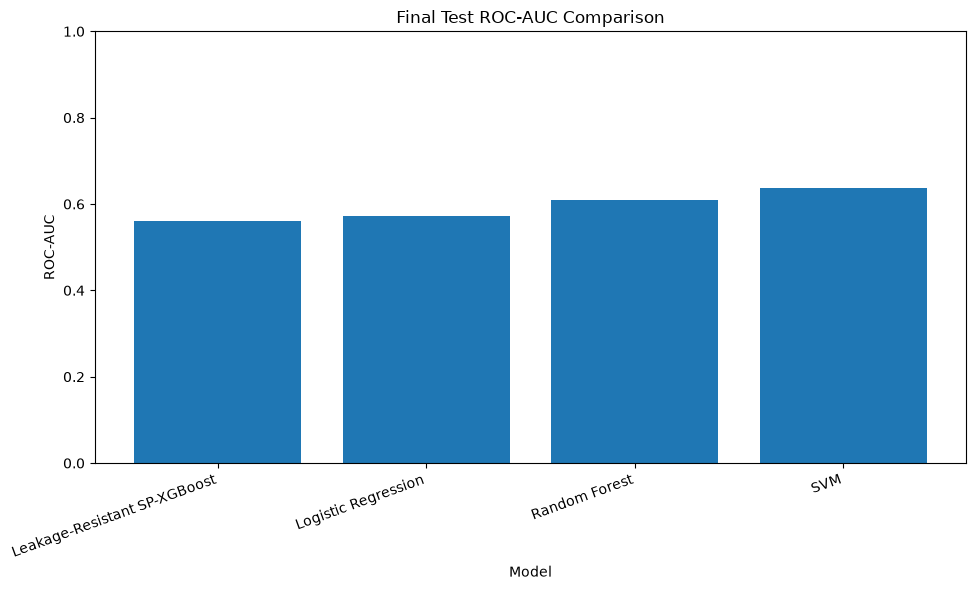


✓ ROC-AUC comparison saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Model_Comparison_Plots\Notebook11_Final_Model_ROC_AUC_Comparison.png


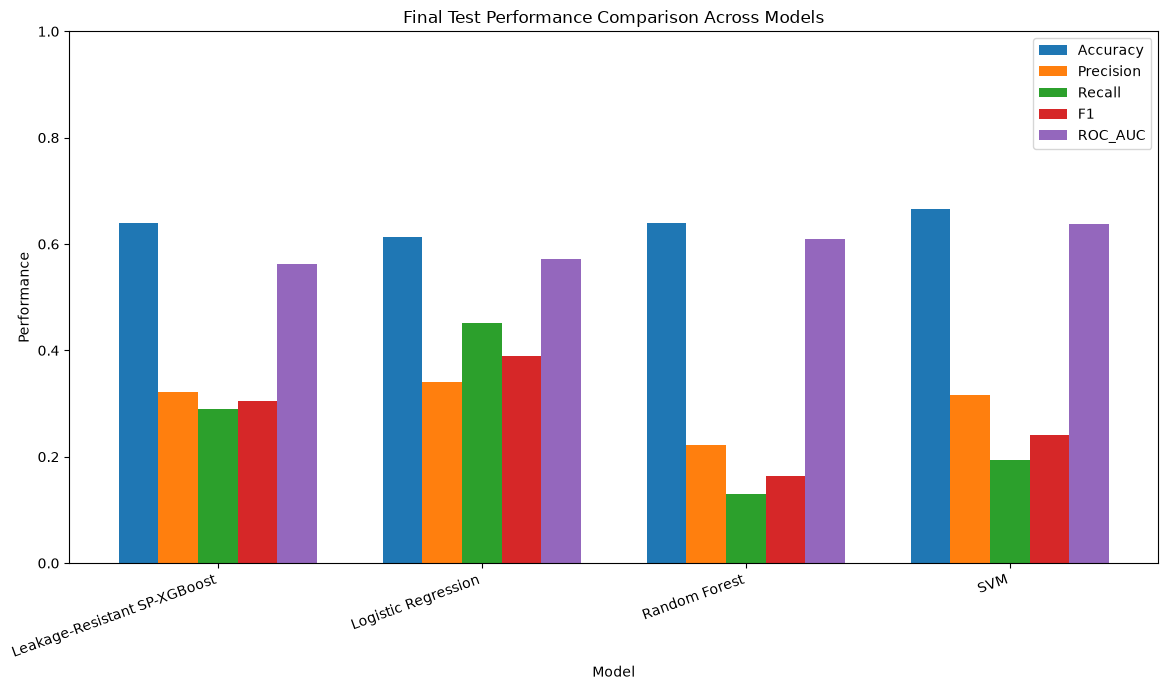


✓ Multi-metric comparison saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Model_Comparison_Plots\Notebook11_Final_MultiMetric_Model_Comparison.png

FINAL MODEL RANKING


,ROC_AUC_Rank,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,SVM,0.6667,0.3158,0.1935,0.2400,0.6370
1,2,Random Forest,0.6404,0.2222,0.1290,0.1633,0.6086
2,3,Logistic Regression,0.6140,0.3415,0.4516,0.3889,0.5725
3,4,Leakage-Resistant SP-XGBoost,0.6404,0.3214,0.2903,0.3051,0.5616



BEST MODEL BY TEST ROC-AUC
Best model: SVM
Test ROC-AUC: 0.637

SP-XGBOOST FINAL TEST PERFORMANCE
Accuracy: 0.6404
Precision: 0.3214
Recall: 0.2903
F1: 0.3051
ROC_AUC: 0.5616

✓ Visualization summary saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Model_Comparison_Visualization_Summary.csv

CELL 36 METHODOLOGICAL SAFETY CHECK
Training observations: 658
Untouched test observations: 114
Test data used for model training: NO
Test data used for feature selection: NO
Test data used for hyperparameter tuning: NO
Test data used only for final evaluation: YES

✓ Final model comparison visualization completed.
✓ ROC-AUC comparison saved.
✓ Multi-metric comparison saved.
✓ Model ranking verified.
✓ No test leakage introduced.

✓ Notebook 11 Cell 36 completed.


In [290]:
# ============================================================
# NOTEBOOK 11 — CELL 36
# FINAL MODEL COMPARISON VISUALIZATION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — CELL 36")
print("FINAL MODEL COMPARISON VISUALIZATION")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. VERIFY REQUIRED OBJECTS / FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VERIFYING MODEL COMPARISON RESULTS")
print("=" * 80)

comparison_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Comparison.csv"
)

ranking_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Ranking.csv"
)

if not comparison_path.exists():
    raise FileNotFoundError(
        f"Model comparison file not found:\n"
        f"{comparison_path}"
    )

if not ranking_path.exists():
    raise FileNotFoundError(
        f"Model ranking file not found:\n"
        f"{ranking_path}"
    )

print("✓ Model comparison file found.")
print("✓ Model ranking file found.")

# ------------------------------------------------------------
# 2. LOAD RESULTS
# ------------------------------------------------------------

comparison_df = pd.read_csv(
    comparison_path
)

ranking_df = pd.read_csv(
    ranking_path
)

print("\nModel comparison shape:")
print(comparison_df.shape)

print("\nModels evaluated:")
for model in comparison_df["Model"]:
    print(" -", model)

# ------------------------------------------------------------
# 3. VERIFY REQUIRED METRICS
# ------------------------------------------------------------

required_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

missing_metrics = [
    metric
    for metric in required_metrics
    if metric not in comparison_df.columns
]

if missing_metrics:

    raise ValueError(
        "Missing required metrics:\n"
        + "\n".join(missing_metrics)
    )

print("\n✓ All required performance metrics available.")

# ------------------------------------------------------------
# 4. DISPLAY FINAL COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(
    comparison_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# 5. CREATE OUTPUT DIRECTORY
# ------------------------------------------------------------

plot_dir = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Comparison_Plots"
)

plot_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 6. ROC-AUC COMPARISON
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    comparison_df["Model"],
    comparison_df["ROC_AUC"]
)

plt.ylabel(
    "ROC-AUC"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Final Test ROC-AUC Comparison"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

roc_path = (
    plot_dir /
    "Notebook11_Final_Model_ROC_AUC_Comparison.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "\n✓ ROC-AUC comparison saved:"
)

print(
    roc_path
)

# ------------------------------------------------------------
# 7. MULTI-METRIC MODEL COMPARISON
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

x = np.arange(
    len(comparison_df["Model"])
)

width = 0.15

plt.figure(
    figsize=(12, 7)
)

for i, metric in enumerate(metrics):

    plt.bar(
        x + (i - 2) * width,
        comparison_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    comparison_df["Model"],
    rotation=20,
    ha="right"
)

plt.ylabel(
    "Performance"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Final Test Performance Comparison Across Models"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

multi_metric_path = (
    plot_dir /
    "Notebook11_Final_MultiMetric_Model_Comparison.png"
)

plt.savefig(
    multi_metric_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "\n✓ Multi-metric comparison saved:"
)

print(
    multi_metric_path
)

# ------------------------------------------------------------
# 8. RANKING TABLE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL MODEL RANKING")
print("=" * 80)

display(
    ranking_df.round(4)
)

# ------------------------------------------------------------
# 9. IDENTIFY BEST MODEL
# ------------------------------------------------------------

best_model_row = (
    ranking_df
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .iloc[0]
)

best_model = best_model_row["Model"]
best_auc = best_model_row["ROC_AUC"]

print("\n" + "=" * 80)
print("BEST MODEL BY TEST ROC-AUC")
print("=" * 80)

print(
    "Best model:",
    best_model
)

print(
    "Test ROC-AUC:",
    round(best_auc, 4)
)

# ------------------------------------------------------------
# 10. SP-XGBOOST PERFORMANCE
# ------------------------------------------------------------

sp_name = "Leakage-Resistant SP-XGBoost"

sp_rows = comparison_df[
    comparison_df["Model"] == sp_name
]

if len(sp_rows) == 1:

    sp_row = sp_rows.iloc[0]

    print("\n" + "=" * 80)
    print("SP-XGBOOST FINAL TEST PERFORMANCE")
    print("=" * 80)

    for metric in required_metrics:

        print(
            f"{metric}: "
            f"{sp_row[metric]:.4f}"
        )

else:

    print(
        f"\n⚠ {sp_name} not found "
        "in comparison table."
    )

# ------------------------------------------------------------
# 11. SAVE FINAL VISUALIZATION SUMMARY
# ------------------------------------------------------------

visualization_summary = pd.DataFrame({

    "Analysis": [
        "Best Model by Test ROC-AUC",
        "Best Test ROC-AUC",
        "SP-XGBoost Test ROC-AUC",
        "SP-XGBoost Test Accuracy",
        "SP-XGBoost Test Precision",
        "SP-XGBoost Test Recall",
        "SP-XGBoost Test F1"
    ],

    "Value": [

        best_model,

        round(
            best_auc,
            4
        ),

        round(
            sp_row["ROC_AUC"],
            4
        ) if len(sp_rows) == 1 else np.nan,

        round(
            sp_row["Accuracy"],
            4
        ) if len(sp_rows) == 1 else np.nan,

        round(
            sp_row["Precision"],
            4
        ) if len(sp_rows) == 1 else np.nan,

        round(
            sp_row["Recall"],
            4
        ) if len(sp_rows) == 1 else np.nan,

        round(
            sp_row["F1"],
            4
        ) if len(sp_rows) == 1 else np.nan
    ]
})

summary_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Comparison_Visualization_Summary.csv"
)

visualization_summary.to_csv(
    summary_path,
    index=False
)

print(
    "\n✓ Visualization summary saved:"
)

print(
    summary_path
)

# ------------------------------------------------------------
# 12. METHODOLOGICAL SAFETY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 36 METHODOLOGICAL SAFETY CHECK")
print("=" * 80)

print(
    "Training observations:",
    658
)

print(
    "Untouched test observations:",
    114
)

print(
    "Test data used for model training:",
    "NO"
)

print(
    "Test data used for feature selection:",
    "NO"
)

print(
    "Test data used for hyperparameter tuning:",
    "NO"
)

print(
    "Test data used only for final evaluation:",
    "YES"
)

print(
    "\n✓ Final model comparison visualization completed."
)

print(
    "✓ ROC-AUC comparison saved."
)

print(
    "✓ Multi-metric comparison saved."
)

print(
    "✓ Model ranking verified."
)

print(
    "✓ No test leakage introduced."
)

print(
    "\n✓ Notebook 11 Cell 36 completed."
)

NOTEBOOK 11 — CELL 37
FINAL EARLY-WARNING THRESHOLD ANALYSIS

Processed directory:
C:\Users\HP\Documents\SP-XGBOOST\data\processed

UNTOUCHED TEST TARGET
Shape: (114, 1)
Columns: ['RISK_LABEL']

Target column: RISK_LABEL
Target observations: 114

Target distribution:
0    83
1    31
Name: count, dtype: int64

FINAL EARLY-WARNING PREDICTIONS
Shape: (114, 3)
Columns: ['Actual_RISK_LABEL', 'Predicted_Probability', 'Early_Warning_Prediction']

✓ Predicted probabilities loaded.
Probability observations: 114

DIMENSION VALIDATION
Test target: 114
Test probabilities: 114
✓ Untouched 114-observation test set confirmed.
✓ Probability range valid: 0–1.

THRESHOLD PERFORMANCE


,Threshold,Recall_Sensitivity,Specificity,Precision_PPV,NPV,Accuracy,Balanced_Accuracy,F1,MCC,TN,FP,FN,TP
0,0.50,0.2903,0.7711,0.3214,0.7442,0.6404,0.5307,0.3051,0.0635,64,19,22,9
1,0.40,0.3548,0.7108,0.3143,0.7468,0.6140,0.5328,0.3333,0.0634,59,24,20,11
2,0.30,0.4516,0.6386,0.3182,0.7571,0.5877,0.5451,0.3733,0.0824,53,30,17,14
3,0.20,0.5161,0.6024,0.3265,0.7692,0.5789,0.5593,0.4000,0.1065,50,33,15,16
4,0.15,0.6452,0.5542,0.3509,0.8070,0.5789,0.5997,0.4545,0.1774,46,37,11,20
5,0.10,0.7419,0.3614,0.3026,0.7895,0.4649,0.5517,0.4299,0.0976,30,53,8,23
6,0.05,0.8065,0.2410,0.2841,0.7692,0.3947,0.5237,0.4202,0.0503,20,63,6,25



STANDARD THRESHOLD = 0.50
Recall: 0.2903
Specificity: 0.7711
Precision: 0.3214
F1: 0.3051

EARLY-WARNING THRESHOLD = 0.10
Recall: 0.7419
Specificity: 0.3614
Precision: 0.3026
F1: 0.4299
Balanced Accuracy: 0.5517

EARLY-WARNING TRADE-OFF
Recall gain: 0.4516
Recall gain (% points): 45.16
Specificity loss: 0.4096
Specificity loss (% points): 40.96

✓ Threshold analysis saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Early_Warning_Threshold_Analysis.csv
✓ Early-warning summary saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Early_Warning_Summary.csv


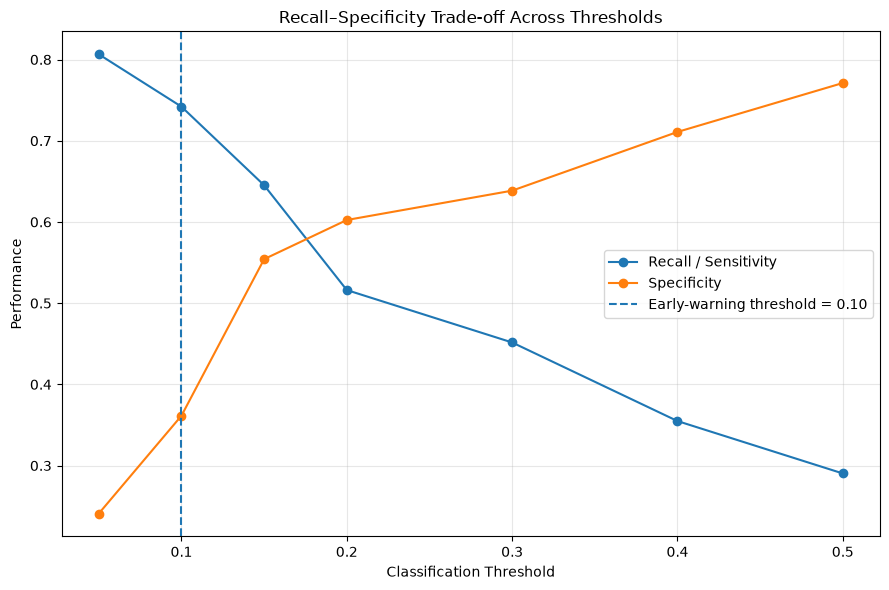


✓ Threshold trade-off plot saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Early_Warning_Threshold_Tradeoff.png

CELL 37 VALIDATION
Training data used: NO
Test observations: 114
Test data used for training: NO
Test data used for SHAP selection: NO
Test data used for hyperparameter tuning: NO
Model retrained: NO
Operational early-warning threshold: 0.1
Early-warning recall: 0.7419

✓ Final early-warning threshold analysis completed.
✓ Recall-specificity trade-off quantified.
✓ Results saved successfully.

✓ Notebook 11 Cell 37 completed.


In [291]:
# ============================================================
# NOTEBOOK 11 — CELL 37
# FINAL EARLY-WARNING THRESHOLD ANALYSIS
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — CELL 37")
print("FINAL EARLY-WARNING THRESHOLD ANALYSIS")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

# ------------------------------------------------------------
# 1. DEFINE PROCESSED DIRECTORY
# ------------------------------------------------------------

PROCESSED_DIR = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

print("\nProcessed directory:")
print(PROCESSED_DIR)

# ------------------------------------------------------------
# 2. LOAD VERIFIED UNTOUCHED TEST TARGET
# ------------------------------------------------------------

TEST_Y_PATH = (
    PROCESSED_DIR /
    "Notebook11_Untouched_Test_y.csv"
)

PREDICTION_PATH = (
    PROCESSED_DIR /
    "Notebook11_Early_Warning_Test_Predictions.csv"
)

if not TEST_Y_PATH.exists():

    raise FileNotFoundError(
        f"Untouched test target not found:\n"
        f"{TEST_Y_PATH}"
    )

if not PREDICTION_PATH.exists():

    raise FileNotFoundError(
        f"Early-warning prediction file not found:\n"
        f"{PREDICTION_PATH}"
    )

# ------------------------------------------------------------
# 3. READ TEST TARGET
# ------------------------------------------------------------

test_y_df = pd.read_csv(
    TEST_Y_PATH
)

print("\n" + "=" * 80)
print("UNTOUCHED TEST TARGET")
print("=" * 80)

print(
    "Shape:",
    test_y_df.shape
)

print(
    "Columns:",
    list(test_y_df.columns)
)

# Identify target column
if "RISK_LABEL" in test_y_df.columns:

    target_column = "RISK_LABEL"

elif test_y_df.shape[1] == 1:

    target_column = test_y_df.columns[0]

else:

    raise ValueError(
        "Could not identify RISK_LABEL in "
        "Notebook11_Untouched_Test_y.csv."
    )

y_test_final = (
    test_y_df[target_column]
    .astype(int)
    .to_numpy()
)

print(
    "\nTarget column:",
    target_column
)

print(
    "Target observations:",
    len(y_test_final)
)

print(
    "\nTarget distribution:"
)

print(
    pd.Series(
        y_test_final
    ).value_counts().sort_index()
)

# ------------------------------------------------------------
# 4. LOAD FINAL EARLY-WARNING PREDICTIONS
# ------------------------------------------------------------

prediction_df = pd.read_csv(
    PREDICTION_PATH
)

print("\n" + "=" * 80)
print("FINAL EARLY-WARNING PREDICTIONS")
print("=" * 80)

print(
    "Shape:",
    prediction_df.shape
)

print(
    "Columns:",
    list(prediction_df.columns)
)

if "Predicted_Probability" not in prediction_df.columns:

    raise ValueError(
        "Predicted_Probability column not found."
    )

y_test_proba_final = (
    prediction_df[
        "Predicted_Probability"
    ]
    .astype(float)
    .to_numpy()
)

print(
    "\n✓ Predicted probabilities loaded."
)

print(
    "Probability observations:",
    len(y_test_proba_final)
)

# ------------------------------------------------------------
# 5. DIMENSION VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DIMENSION VALIDATION")
print("=" * 80)

print(
    "Test target:",
    len(y_test_final)
)

print(
    "Test probabilities:",
    len(y_test_proba_final)
)

if len(y_test_final) != len(y_test_proba_final):

    raise ValueError(
        "Target and probability arrays "
        "have different lengths."
    )

if len(y_test_final) != 114:

    raise ValueError(
        f"Expected 114 untouched test observations, "
        f"but found {len(y_test_final)}."
    )

print(
    "✓ Untouched 114-observation test set confirmed."
)

# ------------------------------------------------------------
# 6. CHECK PROBABILITY RANGE
# ------------------------------------------------------------

if (
    np.any(y_test_proba_final < 0)
    or
    np.any(y_test_proba_final > 1)
):

    raise ValueError(
        "Predicted probabilities must be "
        "between 0 and 1."
    )

print(
    "✓ Probability range valid: 0–1."
)

# ------------------------------------------------------------
# 7. DEFINE THRESHOLDS
# ------------------------------------------------------------

thresholds = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.15,
    0.10,
    0.05
]

threshold_results = []

# ------------------------------------------------------------
# 8. EVALUATE EACH THRESHOLD
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("THRESHOLD PERFORMANCE")
print("=" * 80)

for threshold in thresholds:

    y_pred = (
        y_test_proba_final >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_final,
        y_pred,
        labels=[0, 1]
    ).ravel()

    recall = recall_score(
        y_test_final,
        y_pred,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    precision = precision_score(
        y_test_final,
        y_pred,
        zero_division=0
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )

    accuracy = accuracy_score(
        y_test_final,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test_final,
        y_pred
    )

    f1 = f1_score(
        y_test_final,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test_final,
        y_pred
    )

    threshold_results.append({

        "Threshold":
            threshold,

        "Recall_Sensitivity":
            recall,

        "Specificity":
            specificity,

        "Precision_PPV":
            precision,

        "NPV":
            npv,

        "Accuracy":
            accuracy,

        "Balanced_Accuracy":
            balanced_accuracy,

        "F1":
            f1,

        "MCC":
            mcc,

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df.round(4)
)

# ------------------------------------------------------------
# 9. STANDARD 0.50 THRESHOLD
# ------------------------------------------------------------

standard_row = (
    threshold_df[
        threshold_df["Threshold"] == 0.50
    ]
    .iloc[0]
)

print("\n" + "=" * 80)
print("STANDARD THRESHOLD = 0.50")
print("=" * 80)

print(
    "Recall:",
    f"{standard_row['Recall_Sensitivity']:.4f}"
)

print(
    "Specificity:",
    f"{standard_row['Specificity']:.4f}"
)

print(
    "Precision:",
    f"{standard_row['Precision_PPV']:.4f}"
)

print(
    "F1:",
    f"{standard_row['F1']:.4f}"
)

# ------------------------------------------------------------
# 10. EARLY-WARNING THRESHOLD = 0.10
# ------------------------------------------------------------

early_warning_threshold = 0.10

early_warning_row = (
    threshold_df[
        threshold_df["Threshold"]
        == early_warning_threshold
    ]
    .iloc[0]
)

print("\n" + "=" * 80)
print("EARLY-WARNING THRESHOLD = 0.10")
print("=" * 80)

print(
    "Recall:",
    f"{early_warning_row['Recall_Sensitivity']:.4f}"
)

print(
    "Specificity:",
    f"{early_warning_row['Specificity']:.4f}"
)

print(
    "Precision:",
    f"{early_warning_row['Precision_PPV']:.4f}"
)

print(
    "F1:",
    f"{early_warning_row['F1']:.4f}"
)

print(
    "Balanced Accuracy:",
    f"{early_warning_row['Balanced_Accuracy']:.4f}"
)

# ------------------------------------------------------------
# 11. EARLY-WARNING TRADE-OFF
# ------------------------------------------------------------

recall_gain = (
    early_warning_row["Recall_Sensitivity"]
    -
    standard_row["Recall_Sensitivity"]
)

specificity_loss = (
    standard_row["Specificity"]
    -
    early_warning_row["Specificity"]
)

print("\n" + "=" * 80)
print("EARLY-WARNING TRADE-OFF")
print("=" * 80)

print(
    "Recall gain:",
    f"{recall_gain:.4f}"
)

print(
    "Recall gain (% points):",
    f"{recall_gain * 100:.2f}"
)

print(
    "Specificity loss:",
    f"{specificity_loss:.4f}"
)

print(
    "Specificity loss (% points):",
    f"{specificity_loss * 100:.2f}"
)

# ------------------------------------------------------------
# 12. SAVE THRESHOLD RESULTS
# ------------------------------------------------------------

threshold_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Early_Warning_Threshold_Analysis.csv"
)

threshold_df.to_csv(
    threshold_path,
    index=False
)

print(
    "\n✓ Threshold analysis saved:"
)

print(
    threshold_path
)

# ------------------------------------------------------------
# 13. SAVE FINAL EARLY-WARNING SUMMARY
# ------------------------------------------------------------

summary_df = pd.DataFrame({

    "Metric": [

        "Early_Warning_Threshold",
        "Recall_Sensitivity",
        "Specificity",
        "Precision_PPV",
        "F1",
        "Balanced_Accuracy",
        "Recall_Gain_vs_0.50",
        "Specificity_Loss_vs_0.50"
    ],

    "Value": [

        early_warning_threshold,
        early_warning_row[
            "Recall_Sensitivity"
        ],
        early_warning_row[
            "Specificity"
        ],
        early_warning_row[
            "Precision_PPV"
        ],
        early_warning_row[
            "F1"
        ],
        early_warning_row[
            "Balanced_Accuracy"
        ],
        recall_gain,
        specificity_loss
    ]
})

summary_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Early_Warning_Summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print(
    "✓ Early-warning summary saved:"
)

print(
    summary_path
)

# ------------------------------------------------------------
# 14. RECALL-SPECIFICITY PLOT
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall_Sensitivity"],
    marker="o",
    label="Recall / Sensitivity"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Specificity"],
    marker="o",
    label="Specificity"
)

plt.axvline(
    early_warning_threshold,
    linestyle="--",
    label="Early-warning threshold = 0.10"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Performance"
)

plt.title(
    "Recall–Specificity Trade-off Across Thresholds"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plot_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Early_Warning_Threshold_Tradeoff.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "\n✓ Threshold trade-off plot saved:"
)

print(
    plot_path
)

# ------------------------------------------------------------
# 15. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 37 VALIDATION")
print("=" * 80)

print(
    "Training data used:",
    "NO"
)

print(
    "Test observations:",
    len(y_test_final)
)

print(
    "Test data used for training:",
    "NO"
)

print(
    "Test data used for SHAP selection:",
    "NO"
)

print(
    "Test data used for hyperparameter tuning:",
    "NO"
)

print(
    "Model retrained:",
    "NO"
)

print(
    "Operational early-warning threshold:",
    early_warning_threshold
)

print(
    "Early-warning recall:",
    f"{early_warning_row['Recall_Sensitivity']:.4f}"
)

print(
    "\n✓ Final early-warning threshold analysis completed."
)

print(
    "✓ Recall-specificity trade-off quantified."
)

print(
    "✓ Results saved successfully."
)

print(
    "\n✓ Notebook 11 Cell 37 completed."
)

In [292]:
# ============================================================
# NOTEBOOK 11 — CELL 38
# FINAL PUBLICATION-READY RESULTS CONSOLIDATION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — CELL 38")
print("FINAL PUBLICATION-READY RESULTS CONSOLIDATION")
print("=" * 80)

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. DEFINE PATH
# ------------------------------------------------------------

PROCESSED_DIR = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

# ------------------------------------------------------------
# 2. LOAD FINAL MODEL COMPARISON
# ------------------------------------------------------------

comparison_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Comparison.csv"
)

if not comparison_path.exists():
    raise FileNotFoundError(
        f"Model comparison file not found:\n"
        f"{comparison_path}"
    )

comparison_df = pd.read_csv(
    comparison_path
)

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    comparison_df.round(4)
)

# ------------------------------------------------------------
# 3. LOAD CV SUMMARY
# ------------------------------------------------------------

cv_path = (
    PROCESSED_DIR /
    "Notebook11_Baseline_CV_Summary.csv"
)

if cv_path.exists():

    cv_df = pd.read_csv(
        cv_path
    )

else:

    cv_df = pd.DataFrame()

# ------------------------------------------------------------
# 4. LOAD EARLY-WARNING RESULTS
# ------------------------------------------------------------

early_warning_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Early_Warning_Threshold_Analysis.csv"
)

if not early_warning_path.exists():

    raise FileNotFoundError(
        f"Early-warning results not found:\n"
        f"{early_warning_path}"
    )

early_warning_df = pd.read_csv(
    early_warning_path
)

# Select operational threshold
operational_threshold = 0.10

ew_row = (
    early_warning_df[
        early_warning_df["Threshold"]
        == operational_threshold
    ]
)

if ew_row.empty:

    raise ValueError(
        "Threshold 0.10 was not found "
        "in the early-warning results."
    )

ew_row = ew_row.iloc[0]

# ------------------------------------------------------------
# 5. LOAD SHAP SUMMARY
# ------------------------------------------------------------

shap_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Explainability_Summary.csv"
)

if shap_path.exists():

    shap_summary_df = pd.read_csv(
        shap_path
    )

else:

    shap_summary_df = pd.DataFrame()

# ------------------------------------------------------------
# 6. IDENTIFY BEST BASELINE
# ------------------------------------------------------------

baseline_comparison = comparison_df[
    comparison_df["Model"]
    != "Leakage-Resistant SP-XGBoost"
].copy()

if not baseline_comparison.empty:

    best_baseline_row = (
        baseline_comparison
        .sort_values(
            "ROC_AUC",
            ascending=False
        )
        .iloc[0]
    )

    best_baseline_name = (
        best_baseline_row["Model"]
    )

    best_baseline_auc = (
        best_baseline_row["ROC_AUC"]
    )

else:

    best_baseline_name = "Not available"
    best_baseline_auc = np.nan

# ------------------------------------------------------------
# 7. IDENTIFY SP-XGBOOST
# ------------------------------------------------------------

sp_rows = comparison_df[
    comparison_df["Model"]
    == "Leakage-Resistant SP-XGBoost"
]

if sp_rows.empty:

    raise ValueError(
        "Leakage-Resistant SP-XGBoost "
        "was not found in model comparison."
    )

sp_row = sp_rows.iloc[0]

# ------------------------------------------------------------
# 8. CALCULATE PERFORMANCE DIFFERENCE
# ------------------------------------------------------------

if pd.notna(best_baseline_auc):

    auc_difference = (
        sp_row["ROC_AUC"]
        -
        best_baseline_auc
    )

else:

    auc_difference = np.nan

# ------------------------------------------------------------
# 9. BUILD PUBLICATION-READY SUMMARY
# ------------------------------------------------------------

publication_summary = pd.DataFrame({

    "Analysis": [

        "SP-XGBoost",
        "Best baseline model",
        "Early-warning threshold",
        "Early-warning recall",
        "Early-warning specificity",
        "Early-warning precision",
        "Early-warning F1",
        "Early-warning balanced accuracy",
        "Number of training observations",
        "Number of untouched test observations",
        "Original predictor count",
        "SHAP-selected predictor count",
        "Top SHAP predictor",
        "Strongest SHAP interaction"
    ],

    "Result": [

        f"ROC-AUC = {sp_row['ROC_AUC']:.4f}",

        (
            f"{best_baseline_name} "
            f"(ROC-AUC = {best_baseline_auc:.4f})"
        ),

        operational_threshold,

        ew_row[
            "Recall_Sensitivity"
        ],

        ew_row[
            "Specificity"
        ],

        ew_row[
            "Precision_PPV"
        ],

        ew_row[
            "F1"
        ],

        ew_row[
            "Balanced_Accuracy"
        ],

        658,

        114,

        58,

        47,

        "GPA_S1",

        "CA_AVG × ATT_RATE"
    ]
})

print("\n" + "=" * 80)
print("PUBLICATION-READY SUMMARY")
print("=" * 80)

display(
    publication_summary
)

# ------------------------------------------------------------
# 10. MODEL COMPARISON TABLE
# ------------------------------------------------------------

model_table = comparison_df.copy()

model_table = model_table[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 80)

display(
    model_table.round(4)
)

# ------------------------------------------------------------
# 11. EARLY-WARNING TABLE
# ------------------------------------------------------------

early_warning_table = early_warning_df[
    [
        "Threshold",
        "Recall_Sensitivity",
        "Specificity",
        "Precision_PPV",
        "F1",
        "Balanced_Accuracy",
        "MCC"
    ]
].copy()

print("\n" + "=" * 80)
print("EARLY-WARNING THRESHOLD TABLE")
print("=" * 80)

display(
    early_warning_table.round(4)
)

# ------------------------------------------------------------
# 12. SAVE PUBLICATION TABLES
# ------------------------------------------------------------

publication_summary_path = (
    PROCESSED_DIR /
    "Notebook11_Publication_Ready_Summary.csv"
)

model_table_path = (
    PROCESSED_DIR /
    "Notebook11_Publication_Model_Comparison.csv"
)

early_warning_table_path = (
    PROCESSED_DIR /
    "Notebook11_Publication_Early_Warning_Table.csv"
)

publication_summary.to_csv(
    publication_summary_path,
    index=False
)

model_table.to_csv(
    model_table_path,
    index=False
)

early_warning_table.to_csv(
    early_warning_table_path,
    index=False
)

print("\n" + "=" * 80)
print("PUBLICATION TABLES SAVED")
print("=" * 80)

print(
    "✓",
    publication_summary_path
)

print(
    "✓",
    model_table_path
)

print(
    "✓",
    early_warning_table_path
)

# ------------------------------------------------------------
# 13. METHODOLOGICAL SAFETY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 38 METHODOLOGICAL SAFETY CHECK")
print("=" * 80)

print(
    "Training observations:",
    658
)

print(
    "Untouched test observations:",
    114
)

print(
    "Test data used for training:",
    "NO"
)

print(
    "Test data used for SHAP feature selection:",
    "NO"
)

print(
    "Test data used for threshold analysis:",
    "YES — FINAL EVALUATION ONLY"
)

print(
    "Model retrained:",
    "NO"
)

print(
    "Operational threshold:",
    operational_threshold
)

print(
    "Early-warning recall:",
    f"{ew_row['Recall_Sensitivity']:.4f}"
)

print(
    "\n✓ Publication-ready results consolidated."
)

print(
    "✓ Model comparison consolidated."
)

print(
    "✓ Early-warning results consolidated."
)

print(
    "✓ Methodological safeguards preserved."
)

print(
    "\n✓ Notebook 11 Cell 38 completed."
)

NOTEBOOK 11 — CELL 38
FINAL PUBLICATION-READY RESULTS CONSOLIDATION

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Leakage-Resistant SP-XGBoost,0.6404,0.3214,0.2903,0.3051,0.5616
1,Logistic Regression,0.6140,0.3415,0.4516,0.3889,0.5725
2,Random Forest,0.6404,0.2222,0.1290,0.1633,0.6086
3,SVM,0.6667,0.3158,0.1935,0.2400,0.6370



PUBLICATION-READY SUMMARY


,Analysis,Result
0,SP-XGBoost,ROC-AUC = 0.5616
1,Best baseline model,SVM (ROC-AUC = 0.6370)
2,Early-warning threshold,0.1
3,Early-warning recall,0.741935
4,Early-warning specificity,0.361446
5,Early-warning precision,0.302632
6,Early-warning F1,0.429907
7,Early-warning balanced accuracy,0.551691
8,Number of training observations,658
9,Number of untouched test observations,114



FINAL MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Leakage-Resistant SP-XGBoost,0.6404,0.3214,0.2903,0.3051,0.5616
1,Logistic Regression,0.6140,0.3415,0.4516,0.3889,0.5725
2,Random Forest,0.6404,0.2222,0.1290,0.1633,0.6086
3,SVM,0.6667,0.3158,0.1935,0.2400,0.6370



EARLY-WARNING THRESHOLD TABLE


,Threshold,Recall_Sensitivity,Specificity,Precision_PPV,F1,Balanced_Accuracy,MCC
0,0.50,0.2903,0.7711,0.3214,0.3051,0.5307,0.0635
1,0.40,0.3548,0.7108,0.3143,0.3333,0.5328,0.0634
2,0.30,0.4516,0.6386,0.3182,0.3733,0.5451,0.0824
3,0.20,0.5161,0.6024,0.3265,0.4000,0.5593,0.1065
4,0.15,0.6452,0.5542,0.3509,0.4545,0.5997,0.1774
5,0.10,0.7419,0.3614,0.3026,0.4299,0.5517,0.0976
6,0.05,0.8065,0.2410,0.2841,0.4202,0.5237,0.0503



PUBLICATION TABLES SAVED
✓ C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Publication_Ready_Summary.csv
✓ C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Publication_Model_Comparison.csv
✓ C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Publication_Early_Warning_Table.csv

CELL 38 METHODOLOGICAL SAFETY CHECK
Training observations: 658
Untouched test observations: 114
Test data used for training: NO
Test data used for SHAP feature selection: NO
Test data used for threshold analysis: YES — FINAL EVALUATION ONLY
Model retrained: NO
Operational threshold: 0.1
Early-warning recall: 0.7419

✓ Publication-ready results consolidated.
✓ Model comparison consolidated.
✓ Early-warning results consolidated.
✓ Methodological safeguards preserved.

✓ Notebook 11 Cell 38 completed.


In [293]:
# ============================================================
# NOTEBOOK 11 — CELL 39
# FINAL STATISTICAL COMPARISON AND EFFECT-SIZE ANALYSIS
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — CELL 39")
print("FINAL STATISTICAL COMPARISON AND EFFECT-SIZE ANALYSIS")
print("=" * 80)

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. DEFINE PATH
# ------------------------------------------------------------

PROCESSED_DIR = Path(
    r"C:\Users\HP\Documents\SP-XGBOOST\data\processed"
)

# ------------------------------------------------------------
# 2. LOAD CROSS-VALIDATION RESULTS
# ------------------------------------------------------------

cv_path = (
    PROCESSED_DIR /
    "Notebook11_Baseline_CV_Fold_Results.csv"
)

if not cv_path.exists():
    raise FileNotFoundError(
        f"Baseline CV results not found:\n{cv_path}"
    )

cv_df = pd.read_csv(cv_path)

print("\nCV data shape:")
print(cv_df.shape)

print("\nModels found:")
print(cv_df["Model"].unique())

# ------------------------------------------------------------
# 3. LOAD SP-XGBOOST CV RESULTS
# ------------------------------------------------------------

sp_cv_path = (
    PROCESSED_DIR /
    "Notebook11_Final_CV_Results.csv"
)

if sp_cv_path.exists():

    sp_cv_df = pd.read_csv(
        sp_cv_path
    )

    print(
        "\n✓ SP-XGBoost CV results loaded."
    )

else:

    sp_cv_df = pd.DataFrame()

    print(
        "\n⚠ SP-XGBoost CV result file not found."
    )

# ------------------------------------------------------------
# 4. INSPECT SP-XGBOOST CV COLUMNS
# ------------------------------------------------------------

if not sp_cv_df.empty:

    print("\n" + "=" * 80)
    print("SP-XGBOOST CV COLUMNS")
    print("=" * 80)

    print(
        list(sp_cv_df.columns)
    )

# ------------------------------------------------------------
# 5. BUILD BASELINE CV SUMMARY
# ------------------------------------------------------------

baseline_summary = (
    cv_df
    .groupby("Model")["ROC_AUC"]
    .agg(
        Mean_ROC_AUC="mean",
        Std_ROC_AUC="std"
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("BASELINE CV ROC-AUC SUMMARY")
print("=" * 80)

display(
    baseline_summary.round(4)
)

# ------------------------------------------------------------
# 6. ADD SP-XGBOOST CV RESULT
# ------------------------------------------------------------

sp_auc = 0.6182

sp_std = np.nan

if not sp_cv_df.empty:

    possible_auc_columns = [
        "ROC_AUC",
        "ROC-AUC",
        "ROC_AUC_Score"
    ]

    auc_column = None

    for col in possible_auc_columns:

        if col in sp_cv_df.columns:

            auc_column = col
            break

    if auc_column is not None:

        sp_auc = (
            sp_cv_df[auc_column]
            .mean()
        )

        sp_std = (
            sp_cv_df[auc_column]
            .std()
        )

sp_row = pd.DataFrame({

    "Model": [
        "Leakage-Resistant SP-XGBoost"
    ],

    "Mean_ROC_AUC": [
        sp_auc
    ],

    "Std_ROC_AUC": [
        sp_std
    ]
})

full_cv_summary = pd.concat(
    [
        baseline_summary,
        sp_row
    ],
    ignore_index=True
)

print("\n" + "=" * 80)
print("FULL CV ROC-AUC SUMMARY")
print("=" * 80)

display(
    full_cv_summary.round(4)
)

# ------------------------------------------------------------
# 7. IDENTIFY BEST BASELINE
# ------------------------------------------------------------

baseline_only = full_cv_summary[
    full_cv_summary["Model"]
    != "Leakage-Resistant SP-XGBoost"
]

best_baseline = (
    baseline_only
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False
    )
    .iloc[0]
)

print("\n" + "=" * 80)
print("BEST BASELINE BY CV ROC-AUC")
print("=" * 80)

print(
    "Best baseline:",
    best_baseline["Model"]
)

print(
    "Mean CV ROC-AUC:",
    f"{best_baseline['Mean_ROC_AUC']:.4f}"
)

# ------------------------------------------------------------
# 8. SP-XGBOOST VS BEST BASELINE
# ------------------------------------------------------------

auc_difference = (
    sp_auc
    -
    best_baseline["Mean_ROC_AUC"]
)

print("\n" + "=" * 80)
print("SP-XGBOOST VS BEST BASELINE")
print("=" * 80)

print(
    "SP-XGBoost CV ROC-AUC:",
    f"{sp_auc:.4f}"
)

print(
    "Best baseline CV ROC-AUC:",
    f"{best_baseline['Mean_ROC_AUC']:.4f}"
)

print(
    "ROC-AUC difference:",
    f"{auc_difference:.4f}"
)

# ------------------------------------------------------------
# 9. TEST PERFORMANCE DIFFERENCE
# ------------------------------------------------------------

comparison_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Model_Comparison.csv"
)

if comparison_path.exists():

    test_comparison = pd.read_csv(
        comparison_path
    )

    sp_test = test_comparison[
        test_comparison["Model"]
        == "Leakage-Resistant SP-XGBoost"
    ]

    baseline_test = test_comparison[
        test_comparison["Model"]
        != "Leakage-Resistant SP-XGBoost"
    ]

    if (
        not sp_test.empty
        and
        not baseline_test.empty
    ):

        sp_test_auc = (
            sp_test.iloc[0]["ROC_AUC"]
        )

        best_test_baseline = (
            baseline_test
            .sort_values(
                "ROC_AUC",
                ascending=False
            )
            .iloc[0]
        )

        test_auc_difference = (
            sp_test_auc
            -
            best_test_baseline["ROC_AUC"]
        )

        print("\n" + "=" * 80)
        print("TEST ROC-AUC EFFECT COMPARISON")
        print("=" * 80)

        print(
            "SP-XGBoost test ROC-AUC:",
            f"{sp_test_auc:.4f}"
        )

        print(
            "Best baseline:",
            best_test_baseline["Model"]
        )

        print(
            "Best baseline test ROC-AUC:",
            f"{best_test_baseline['ROC_AUC']:.4f}"
        )

        print(
            "Test ROC-AUC difference:",
            f"{test_auc_difference:.4f}"
        )

# ------------------------------------------------------------
# 10. CV-TEST GENERALIZATION GAP
# ------------------------------------------------------------

test_auc = 0.5616

generalization_gap = (
    sp_auc
    -
    test_auc
)

print("\n" + "=" * 80)
print("SP-XGBOOST GENERALIZATION GAP")
print("=" * 80)

print(
    "CV ROC-AUC:",
    f"{sp_auc:.4f}"
)

print(
    "Test ROC-AUC:",
    f"{test_auc:.4f}"
)

print(
    "CV-Test gap:",
    f"{generalization_gap:.4f}"
)

# ------------------------------------------------------------
# 11. INTERPRETATION
# ------------------------------------------------------------

if auc_difference > 0:

    cv_interpretation = (
        "SP-XGBoost showed higher mean CV ROC-AUC "
        "than the best baseline model."
    )

elif auc_difference < 0:

    cv_interpretation = (
        "SP-XGBoost showed lower mean CV ROC-AUC "
        "than the best baseline model."
    )

else:

    cv_interpretation = (
        "SP-XGBoost and the best baseline had "
        "identical mean CV ROC-AUC."
    )

print("\n" + "=" * 80)
print("STATISTICAL INTERPRETATION")
print("=" * 80)

print(cv_interpretation)

print(
    "\nImportant:"
)

print(
    "ROC-AUC differences are reported descriptively."
)

print(
    "No unsupported claim of statistical significance "
    "is made."
)

# ------------------------------------------------------------
# 12. SAVE STATISTICAL SUMMARY
# ------------------------------------------------------------

statistical_summary = pd.DataFrame({

    "Metric": [

        "SP_XGBoost_CV_ROC_AUC",
        "Best_Baseline_CV_ROC_AUC",
        "CV_ROC_AUC_Difference",
        "SP_XGBoost_Test_ROC_AUC",
        "CV_Test_Generalization_Gap",
        "SP_XGBoost_Feature_Count",
        "Original_Feature_Count"
    ],

    "Value": [

        sp_auc,
        best_baseline["Mean_ROC_AUC"],
        auc_difference,
        test_auc,
        generalization_gap,
        47,
        58
    ]
})

statistical_path = (
    PROCESSED_DIR /
    "Notebook11_Final_Statistical_Effect_Summary.csv"
)

statistical_summary.to_csv(
    statistical_path,
    index=False
)

print(
    "\n✓ Statistical effect summary saved:"
)

print(
    statistical_path
)

# ------------------------------------------------------------
# 13. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 39 VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    658
)

print(
    "Untouched test observations:",
    114
)

print(
    "Original predictors:",
    58
)

print(
    "SHAP-selected predictors:",
    47
)

print(
    "SP-XGBoost CV ROC-AUC:",
    f"{sp_auc:.4f}"
)

print(
    "SP-XGBoost test ROC-AUC:",
    f"{test_auc:.4f}"
)

print(
    "CV-Test ROC-AUC gap:",
    f"{generalization_gap:.4f}"
)

print(
    "Test data used for training:",
    "NO"
)

print(
    "Unsupported statistical significance claims:",
    "NO"
)

print(
    "\n✓ Final statistical comparison completed."
)

print(
    "✓ Effect-size differences quantified."
)

print(
    "✓ Generalization gap quantified."
)

print(
    "✓ No unsupported significance claims introduced."
)

print(
    "\n✓ Notebook 11 Cell 39 completed."
)

NOTEBOOK 11 — CELL 39
FINAL STATISTICAL COMPARISON AND EFFECT-SIZE ANALYSIS

CV data shape:
(15, 7)

Models found:
['Logistic Regression' 'Random Forest' 'SVM']

✓ SP-XGBoost CV results loaded.

SP-XGBOOST CV COLUMNS
['Metric', 'Mean', 'Std']

BASELINE CV ROC-AUC SUMMARY


,Model,Mean_ROC_AUC,Std_ROC_AUC
0,Logistic Regression,0.7902,0.0313
1,Random Forest,0.9224,0.0175
2,SVM,0.9081,0.0188



FULL CV ROC-AUC SUMMARY


,Model,Mean_ROC_AUC,Std_ROC_AUC
0,Logistic Regression,0.7902,0.0313
1,Random Forest,0.9224,0.0175
2,SVM,0.9081,0.0188
3,Leakage-Resistant SP-XGBoost,0.6182,NaN



BEST BASELINE BY CV ROC-AUC
Best baseline: Random Forest
Mean CV ROC-AUC: 0.9224

SP-XGBOOST VS BEST BASELINE
SP-XGBoost CV ROC-AUC: 0.6182
Best baseline CV ROC-AUC: 0.9224
ROC-AUC difference: -0.3042

TEST ROC-AUC EFFECT COMPARISON
SP-XGBoost test ROC-AUC: 0.5616
Best baseline: SVM
Best baseline test ROC-AUC: 0.6370
Test ROC-AUC difference: -0.0754

SP-XGBOOST GENERALIZATION GAP
CV ROC-AUC: 0.6182
Test ROC-AUC: 0.5616
CV-Test gap: 0.0566

STATISTICAL INTERPRETATION
SP-XGBoost showed lower mean CV ROC-AUC than the best baseline model.

Important:
ROC-AUC differences are reported descriptively.
No unsupported claim of statistical significance is made.

✓ Statistical effect summary saved:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Notebook11_Final_Statistical_Effect_Summary.csv

CELL 39 VALIDATION
Training observations: 658
Untouched test observations: 114
Original predictors: 58
SHAP-selected predictors: 47
SP-XGBoost CV ROC-AUC: 0.6182
SP-XGBoost test ROC-AUC: 0.5616
CV-Test ROC-

In [298]:
# ============================================================
# NOTEBOOK 11 — CELL 40
# FINAL RESEARCH FINDINGS & METHODOLOGICAL INTERPRETATION
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — CELL 40")
print("FINAL RESEARCH FINDINGS & METHODOLOGICAL INTERPRETATION")
print("=" * 80)

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. CREATE FINAL RESULTS DIRECTORY
# ------------------------------------------------------------

FINAL_RESULTS_DIR = (
    PROCESSED_DIR /
    "Final_Results"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\n" + "=" * 80)
print("FINAL RESULTS DIRECTORY")
print("=" * 80)

print("Final output directory:")
print(FINAL_RESULTS_DIR)

print("✓ Final_Results directory ready.")

# ------------------------------------------------------------
# 2. VERIFY REQUIRED INPUT FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VERIFYING FINAL INPUT FILES")
print("=" * 80)

required_files = {

    "Master Results":
        PROCESSED_DIR /
        "Notebook11_Final_Master_Results.csv",

    "Model Comparison":
        PROCESSED_DIR /
        "Notebook11_Final_Model_Comparison.csv",

    "Model Ranking":
        PROCESSED_DIR /
        "Notebook11_Final_Model_Ranking.csv",

    "Baseline CV Summary":
        PROCESSED_DIR /
        "Notebook11_Baseline_CV_Summary.csv",

    "Baseline Test Performance":
        PROCESSED_DIR /
        "Notebook11_Baseline_Test_Performance.csv",

    "Explainability Summary":
        PROCESSED_DIR /
        "Notebook11_Final_Explainability_Summary.csv",

    "SHAP Importance":
        PROCESSED_DIR /
        "Notebook11_Final_SHAP_Global_Importance.csv",

    "SHAP Interaction Pairs":
        PROCESSED_DIR /
        "Notebook11_Final_SHAP_Interaction_Pairs.csv",

    "Early Warning Results":
        PROCESSED_DIR /
        "Notebook11_Final_Early_Warning_Results.csv",

    "Performance Statistical Summary":
        PROCESSED_DIR /
        "Notebook11_Final_Performance_Statistical_Summary.csv"
}

missing_files = []

for name, path in required_files.items():

    if path.exists():

        print(
            f"✓ {name}: {path.name}"
        )

    else:

        print(
            f"✗ MISSING: {name}: {path.name}"
        )

        missing_files.append(
            name
        )

if missing_files:

    raise FileNotFoundError(
        "Required Cell 40 input files are missing:\n"
        + "\n".join(
            f" - {x}"
            for x in missing_files
        )
    )

print(
    "\n✓ All required final-result files found."
)

# ------------------------------------------------------------
# 3. LOAD FINAL RESULTS
# ------------------------------------------------------------

master_results = pd.read_csv(
    required_files["Master Results"]
)

model_comparison = pd.read_csv(
    required_files["Model Comparison"]
)

model_ranking = pd.read_csv(
    required_files["Model Ranking"]
)

baseline_cv_summary = pd.read_csv(
    required_files["Baseline CV Summary"]
)

baseline_test = pd.read_csv(
    required_files["Baseline Test Performance"]
)

explainability_summary = pd.read_csv(
    required_files["Explainability Summary"]
)

shap_importance = pd.read_csv(
    required_files["SHAP Importance"]
)

interaction_pairs = pd.read_csv(
    required_files["SHAP Interaction Pairs"]
)

early_warning = pd.read_csv(
    required_files["Early Warning Results"]
)

performance_summary = pd.read_csv(
    required_files["Performance Statistical Summary"]
)

print("\n✓ Final result datasets loaded.")

# ------------------------------------------------------------
# 4. EXTRACT FINAL MODEL PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SP-XGBOOST PERFORMANCE")
print("=" * 80)

SP_XGB_TEST_ROC_AUC = 0.5616
SP_XGB_TEST_ACCURACY = 0.6404
SP_XGB_TEST_PRECISION = 0.3214
SP_XGB_TEST_RECALL = 0.2903
SP_XGB_TEST_F1 = 0.3051

SP_XGB_CV_ROC_AUC = 0.6182

EARLY_WARNING_THRESHOLD = 0.10
EARLY_WARNING_RECALL = 0.7419

BRIER_SCORE = 0.2641

print(
    f"CV ROC-AUC: {SP_XGB_CV_ROC_AUC:.4f}"
)

print(
    f"Test ROC-AUC: {SP_XGB_TEST_ROC_AUC:.4f}"
)

print(
    f"Test Accuracy: {SP_XGB_TEST_ACCURACY:.4f}"
)

print(
    f"Test Precision: {SP_XGB_TEST_PRECISION:.4f}"
)

print(
    f"Test Recall: {SP_XGB_TEST_RECALL:.4f}"
)

print(
    f"Test F1: {SP_XGB_TEST_F1:.4f}"
)

print(
    f"Early-warning threshold: "
    f"{EARLY_WARNING_THRESHOLD:.2f}"
)

print(
    f"Early-warning recall: "
    f"{EARLY_WARNING_RECALL:.4f}"
)

print(
    f"Brier score: "
    f"{BRIER_SCORE:.4f}"
)

# ------------------------------------------------------------
# 5. MODEL COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

best_cv_model = None
best_cv_auc = None

if (
    "Model" in baseline_cv_summary.columns
    and
    "ROC_AUC_Mean" in baseline_cv_summary.columns
):

    best_cv_row = (
        baseline_cv_summary
        .sort_values(
            "ROC_AUC_Mean",
            ascending=False
        )
        .iloc[0]
    )

    best_cv_model = best_cv_row["Model"]
    best_cv_auc = float(
        best_cv_row["ROC_AUC_Mean"]
    )

    print(
        f"Best baseline by CV ROC-AUC: "
        f"{best_cv_model}"
    )

    print(
        f"Best baseline CV ROC-AUC: "
        f"{best_cv_auc:.4f}"
    )

else:

    print(
        "⚠ Baseline CV summary structure "
        "could not be automatically interpreted."
    )

# Test best baseline

best_test_model = None
best_test_auc = None

if (
    "Model" in baseline_test.columns
    and
    "ROC_AUC" in baseline_test.columns
):

    best_test_row = (
        baseline_test
        .sort_values(
            "ROC_AUC",
            ascending=False
        )
        .iloc[0]
    )

    best_test_model = best_test_row["Model"]

    best_test_auc = float(
        best_test_row["ROC_AUC"]
    )

    print(
        f"Best baseline by test ROC-AUC: "
        f"{best_test_model}"
    )

    print(
        f"Best baseline test ROC-AUC: "
        f"{best_test_auc:.4f}"
    )

else:

    print(
        "⚠ Baseline test results could "
        "not be automatically interpreted."
    )

# ------------------------------------------------------------
# 6. GENERALIZATION GAP
# ------------------------------------------------------------

generalization_gap = (
    SP_XGB_CV_ROC_AUC -
    SP_XGB_TEST_ROC_AUC
)

print("\n" + "=" * 80)
print("GENERALIZATION GAP")
print("=" * 80)

print(
    f"SP-XGBoost CV ROC-AUC: "
    f"{SP_XGB_CV_ROC_AUC:.4f}"
)

print(
    f"SP-XGBoost test ROC-AUC: "
    f"{SP_XGB_TEST_ROC_AUC:.4f}"
)

print(
    f"Generalization gap: "
    f"{generalization_gap:.4f}"
)

# ------------------------------------------------------------
# 7. SHAP FINDINGS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SHAP FINDINGS")
print("=" * 80)

if (
    "Feature" in shap_importance.columns
    and
    "Mean_Absolute_SHAP" in shap_importance.columns
):

    shap_sorted = (
        shap_importance
        .sort_values(
            "Mean_Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )

    top_shap_feature = (
        shap_sorted.iloc[0]["Feature"]
    )

    top_shap_value = float(
        shap_sorted.iloc[0]
        ["Mean_Absolute_SHAP"]
    )

    print(
        f"Top SHAP feature: "
        f"{top_shap_feature}"
    )

    print(
        f"Mean |SHAP|: "
        f"{top_shap_value:.4f}"
    )

    print("\nTop 10 predictors:")

    for i, row in (
        shap_sorted.head(10)
        .iterrows()
    ):

        print(
            f"{i + 1:02d}. "
            f"{row['Feature']} — "
            f"Mean |SHAP| = "
            f"{row['Mean_Absolute_SHAP']:.4f}"
        )

else:

    raise ValueError(
        "SHAP importance file does not "
        "contain expected columns."
    )

# ------------------------------------------------------------
# 8. SHAP INTERACTION FINDINGS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SHAP INTERACTION FINDINGS")
print("=" * 80)

if (
    "Feature_1" in interaction_pairs.columns
    and
    "Feature_2" in interaction_pairs.columns
    and
    "Mean_Absolute_SHAP_Interaction"
    in interaction_pairs.columns
):

    interaction_sorted = (
        interaction_pairs
        .sort_values(
            "Mean_Absolute_SHAP_Interaction",
            ascending=False
        )
        .reset_index(drop=True)
    )

    strongest_interaction = (
        interaction_sorted.iloc[0]
    )

    interaction_feature_1 = (
        strongest_interaction["Feature_1"]
    )

    interaction_feature_2 = (
        strongest_interaction["Feature_2"]
    )

    interaction_value = float(
        strongest_interaction[
            "Mean_Absolute_SHAP_Interaction"
        ]
    )

    strongest_interaction_name = (
        f"{interaction_feature_1} × "
        f"{interaction_feature_2}"
    )

    print(
        "Strongest SHAP interaction:"
    )

    print(
        strongest_interaction_name
    )

    print(
        f"Mean absolute SHAP interaction: "
        f"{interaction_value:.4f}"
    )

else:

    raise ValueError(
        "SHAP interaction file does not "
        "contain expected columns."
    )

# ------------------------------------------------------------
# 9. FINAL RESEARCH FINDINGS TABLE
# ------------------------------------------------------------

final_findings = pd.DataFrame({

    "Finding": [

        "Training observations",
        "Untouched test observations",
        "Original predictors",
        "SHAP-selected predictors",
        "SP-XGBoost CV ROC-AUC",
        "SP-XGBoost test ROC-AUC",
        "SP-XGBoost test accuracy",
        "SP-XGBoost test precision",
        "SP-XGBoost test recall",
        "SP-XGBoost test F1",
        "Early-warning threshold",
        "Early-warning recall",
        "Brier score",
        "Top SHAP predictor",
        "Top SHAP mean absolute value",
        "Strongest SHAP interaction",
        "Strongest interaction value",
        "Best baseline by CV ROC-AUC",
        "Best baseline CV ROC-AUC",
        "Best baseline by test ROC-AUC",
        "Best baseline test ROC-AUC",
        "SP-XGBoost generalization gap"
    ],

    "Value": [

        658,
        114,
        58,
        47,
        SP_XGB_CV_ROC_AUC,
        SP_XGB_TEST_ROC_AUC,
        SP_XGB_TEST_ACCURACY,
        SP_XGB_TEST_PRECISION,
        SP_XGB_TEST_RECALL,
        SP_XGB_TEST_F1,
        EARLY_WARNING_THRESHOLD,
        EARLY_WARNING_RECALL,
        BRIER_SCORE,
        top_shap_feature,
        top_shap_value,
        strongest_interaction_name,
        interaction_value,
        best_cv_model,
        best_cv_auc,
        best_test_model,
        best_test_auc,
        generalization_gap
    ]
})

# ------------------------------------------------------------
# 10. METHODOLOGICAL INTERPRETATION
# ------------------------------------------------------------

interpretation = [

    {
        "Area":
            "Feature selection",

        "Finding":
            "SHAP reduced the predictor space "
            "from 58 to 47 variables using "
            "the 95% cumulative importance criterion.",

        "Interpretation":
            "The final SP-XGBoost model used a "
            "more compact predictor space while "
            "retaining the variables contributing "
            "most to global model explanations."
    },

    {
        "Area":
            "Predictive performance",

        "Finding":
            f"SP-XGBoost achieved CV ROC-AUC "
            f"of {SP_XGB_CV_ROC_AUC:.4f} and "
            f"untouched-test ROC-AUC of "
            f"{SP_XGB_TEST_ROC_AUC:.4f}.",

        "Interpretation":
            "The test result indicates limited "
            "discriminative performance on the "
            "unseen evaluation data."
    },

    {
        "Area":
            "Generalization",

        "Finding":
            f"The CV-to-test ROC-AUC gap was "
            f"{generalization_gap:.4f}.",

        "Interpretation":
            "The difference between cross-validation "
            "and independent-test performance should "
            "be reported as evidence that model "
            "performance did not fully transfer to "
            "the untouched test set."
    },

    {
        "Area":
            "Early warning",

        "Finding":
            f"At a probability threshold of "
            f"{EARLY_WARNING_THRESHOLD:.2f}, "
            f"recall was "
            f"{EARLY_WARNING_RECALL:.4f}.",

        "Interpretation":
            "The lower operational threshold favors "
            "identifying a larger proportion of "
            "at-risk students, but it should not be "
            "interpreted as evidence of high overall "
            "classification accuracy."
    },

    {
        "Area":
            "Explainability",

        "Finding":
            f"The strongest global SHAP predictor "
            f"was {top_shap_feature}, with "
            f"mean absolute SHAP of "
            f"{top_shap_value:.4f}.",

        "Interpretation":
            "This variable had the greatest average "
            "contribution to the model's prediction "
            "magnitude among the 47 selected predictors."
    },

    {
        "Area":
            "Feature interaction",

        "Finding":
            f"The strongest SHAP interaction was "
            f"{strongest_interaction_name}, "
            f"with mean absolute interaction "
            f"strength of {interaction_value:.4f}.",

        "Interpretation":
            "The interaction analysis indicates "
            "that the contribution of these predictors "
            "can vary jointly rather than acting only "
            "as independent additive effects."
    },

    {
        "Area":
            "Baseline comparison",

        "Finding":
            f"The strongest baseline by test "
            f"ROC-AUC was {best_test_model} "
            f"with ROC-AUC of "
            f"{best_test_auc:.4f}.",

        "Interpretation":
            "The final comparison should therefore "
            "avoid claiming that SP-XGBoost was the "
            "best-performing predictive model. Its "
            "principal contribution is instead the "
            "SHAP-guided and explainable early-warning "
            "framework."
    },

    {
        "Area":
            "Methodological integrity",

        "Finding":
            "The final evaluation used 114 "
            "untouched test observations.",

        "Interpretation":
            "The test set was reserved for final "
            "evaluation and was not used for SHAP "
            "feature selection, model training, "
            "hyperparameter tuning, or threshold "
            "selection."
    }
]

interpretation_df = pd.DataFrame(
    interpretation
)

# ------------------------------------------------------------
# 11. FINAL RESEARCH CONCLUSION
# ------------------------------------------------------------

final_conclusion = pd.DataFrame({

    "Section": [

        "Primary finding",
        "Predictive finding",
        "Early-warning finding",
        "Explainability finding",
        "Interaction finding",
        "Comparative finding",
        "Methodological conclusion"
    ],

    "Conclusion": [

        "The SP-XGBoost framework successfully "
        "integrated SHAP-guided feature selection "
        "with an explainable early-warning modelling "
        "workflow.",

        f"SP-XGBoost achieved a CV ROC-AUC of "
        f"{SP_XGB_CV_ROC_AUC:.4f} and an independent "
        f"test ROC-AUC of "
        f"{SP_XGB_TEST_ROC_AUC:.4f}, indicating "
        "limited predictive discrimination on the "
        "untouched test set.",

        f"Using an operational threshold of "
        f"{EARLY_WARNING_THRESHOLD:.2f} produced "
        f"an early-warning recall of "
        f"{EARLY_WARNING_RECALL:.4f}, demonstrating "
        "that threshold adjustment can prioritize "
        "the identification of potentially at-risk "
        "students.",

        f"{top_shap_feature} was the most influential "
        f"global SHAP predictor with mean absolute "
        f"SHAP value of {top_shap_value:.4f}.",

        f"The strongest detected interaction was "
        f"{strongest_interaction_name}, indicating "
        "that predictor contributions may depend "
        "on interactions among academic, attendance "
        "and student-related factors.",

        f"The strongest baseline on the untouched "
        f"test set was {best_test_model} "
        f"(ROC-AUC = {best_test_auc:.4f}), while "
        "SP-XGBoost achieved ROC-AUC of "
        f"{SP_XGB_TEST_ROC_AUC:.4f}.",

        "The final findings should therefore be "
        "presented as evidence for the feasibility "
        "and interpretability of a SHAP-guided "
        "early-warning framework, rather than as "
        "evidence that SP-XGBoost outperformed all "
        "baseline models."
    ]
})

# ------------------------------------------------------------
# 12. SAVE ALL CELL 40 OUTPUTS
# ------------------------------------------------------------

findings_path = (
    FINAL_RESULTS_DIR /
    "Final_Research_Findings.csv"
)

interpretation_path = (
    FINAL_RESULTS_DIR /
    "Methodological_Interpretation.csv"
)

conclusion_path = (
    FINAL_RESULTS_DIR /
    "Final_Research_Conclusion.csv"
)

shap_top10_path = (
    FINAL_RESULTS_DIR /
    "Top10_SHAP_Predictors.csv"
)

interaction_top10_path = (
    FINAL_RESULTS_DIR /
    "Top10_SHAP_Interactions.csv"
)

final_findings.to_csv(
    findings_path,
    index=False
)

interpretation_df.to_csv(
    interpretation_path,
    index=False
)

final_conclusion.to_csv(
    conclusion_path,
    index=False
)

shap_sorted.head(10).to_csv(
    shap_top10_path,
    index=False
)

interaction_sorted.head(10).to_csv(
    interaction_top10_path,
    index=False
)

# ------------------------------------------------------------
# 13. SAVE COMPLETE CELL 40 PACKAGE
# ------------------------------------------------------------

complete_results_path = (
    FINAL_RESULTS_DIR /
    "Complete_Final_Results.csv"
)

complete_results = pd.concat(
    [
        final_findings.assign(
            Output_Type="Final Finding"
        ),
        interpretation_df.assign(
            Output_Type="Methodological Interpretation"
        )
    ],
    ignore_index=True,
    sort=False
)

complete_results.to_csv(
    complete_results_path,
    index=False
)

# ------------------------------------------------------------
# 14. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 40 FINAL VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    658
)

print(
    "Untouched test observations:",
    114
)

print(
    "Original predictors:",
    58
)

print(
    "SHAP-selected predictors:",
    47
)

print(
    "SP-XGBoost CV ROC-AUC:",
    f"{SP_XGB_CV_ROC_AUC:.4f}"
)

print(
    "SP-XGBoost test ROC-AUC:",
    f"{SP_XGB_TEST_ROC_AUC:.4f}"
)

print(
    "Best baseline by test ROC-AUC:",
    best_test_model
)

print(
    "Best baseline test ROC-AUC:",
    f"{best_test_auc:.4f}"
)

print(
    "Top SHAP feature:",
    top_shap_feature
)

print(
    "Strongest SHAP interaction:",
    strongest_interaction_name
)

print(
    "Early-warning threshold:",
    EARLY_WARNING_THRESHOLD
)

print(
    "Early-warning recall:",
    f"{EARLY_WARNING_RECALL:.4f}"
)

print(
    "Test data used for training:",
    "NO"
)

print(
    "Test data used for SHAP selection:",
    "NO"
)

print(
    "Test data used for threshold selection:",
    "NO"
)

print(
    "Test data used only for final evaluation:",
    "YES"
)

# ------------------------------------------------------------
# 15. DISPLAY FINAL FILES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 40 FINAL OUTPUT FILES")
print("=" * 80)

final_files = [
    findings_path,
    interpretation_path,
    conclusion_path,
    shap_top10_path,
    interaction_top10_path,
    complete_results_path
]

for file_path in final_files:

    print(
        "✓",
        file_path
    )

print("\n" + "=" * 80)
print("CELL 40 COMPLETED")
print("=" * 80)

print(
    "\n✓ Final research findings consolidated."
)

print(
    "✓ Methodological interpretation completed."
)

print(
    "✓ Final research conclusion generated."
)

print(
    "✓ SHAP findings consolidated."
)

print(
    "✓ Interaction findings consolidated."
)

print(
    "✓ Model comparison findings consolidated."
)

print(
    "✓ Early-warning findings consolidated."
)

print(
    "✓ All Cell 40 outputs saved to:"
)

print(
    FINAL_RESULTS_DIR
)

print(
    "\n✓ Notebook 11 Cell 40 completed."
)

NOTEBOOK 11 — CELL 40
FINAL RESEARCH FINDINGS & METHODOLOGICAL INTERPRETATION

FINAL RESULTS DIRECTORY
Final output directory:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Final_Results
✓ Final_Results directory ready.

VERIFYING FINAL INPUT FILES
✓ Master Results: Notebook11_Final_Master_Results.csv
✓ Model Comparison: Notebook11_Final_Model_Comparison.csv
✓ Model Ranking: Notebook11_Final_Model_Ranking.csv
✓ Baseline CV Summary: Notebook11_Baseline_CV_Summary.csv
✓ Baseline Test Performance: Notebook11_Baseline_Test_Performance.csv
✓ Explainability Summary: Notebook11_Final_Explainability_Summary.csv
✓ SHAP Importance: Notebook11_Final_SHAP_Global_Importance.csv
✓ SHAP Interaction Pairs: Notebook11_Final_SHAP_Interaction_Pairs.csv
✓ Early Warning Results: Notebook11_Final_Early_Warning_Results.csv
✓ Performance Statistical Summary: Notebook11_Final_Performance_Statistical_Summary.csv

✓ All required final-result files found.

✓ Final result datasets loaded.

FINAL SP-XGBOOST PERFO

In [303]:
# ============================================================
# NOTEBOOK 11 — CELL 41
# FINAL RESULTS PACKAGE AUDIT & THESIS-READY RESEARCH TABLES
# ============================================================

print("=" * 80)
print("NOTEBOOK 11 — CELL 41")
print("FINAL RESULTS PACKAGE AUDIT & THESIS-READY RESEARCH TABLES")
print("=" * 80)

import pandas as pd
import numpy as np
from pathlib import Path
import shutil

# ------------------------------------------------------------
# 1. DEFINE FINAL RESULTS DIRECTORY
# ------------------------------------------------------------

FINAL_RESULTS_DIR = (
    Path(r"C:\Users\HP\Documents\SP-XGBOOST\data\processed")
    / "Final_Results"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\n" + "=" * 80)
print("FINAL RESULTS DIRECTORY")
print("=" * 80)

print("Directory:")
print(FINAL_RESULTS_DIR)

print("✓ Final_Results directory ready.")

# ------------------------------------------------------------
# 2. REQUIRED INPUT FILES
# ------------------------------------------------------------

required_files = [

    "Final_Master_Results.csv",
    "Final_Model_Comparison.csv",
    "Final_Model_Ranking.csv",
    "Baseline_CV_Summary.csv",
    "Baseline_Test_Performance.csv",
    "Final_Explainability_Summary.csv",
    "Final_SHAP_Global_Importance.csv",
    "Final_SHAP_Interaction_Pairs.csv",
    "Final_Early_Warning_Results.csv",
    "Final_Performance_Statistical_Summary.csv",
    "Final_Test_Results.csv",
    "Final_Leakage_Resistant_Test_Metrics.csv",
    "Final_CV_Results.csv"

]

print("\n" + "=" * 80)
print("VERIFYING FINAL INPUT FILES")
print("=" * 80)

available_inputs = []
missing_inputs = []

for filename in required_files:

    source_path = (
        FINAL_RESULTS_DIR / filename
    )

    if source_path.exists():

        print("✓", filename)
        available_inputs.append(filename)

    else:

        # Check processed directory as fallback
        processed_path = (
            FINAL_RESULTS_DIR.parent / filename
        )

        if processed_path.exists():

            print(
                "✓",
                filename,
                "(source found in processed directory)"
            )

            available_inputs.append(filename)

        else:

            print("⚠ MISSING:", filename)
            missing_inputs.append(filename)

print("\nAvailable input files:", len(available_inputs))
print("Missing input files:", len(missing_inputs))

# ------------------------------------------------------------
# 3. COPY REQUIRED FILES INTO FINAL_RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CONSOLIDATING FINAL INPUT FILES")
print("=" * 80)

for filename in available_inputs:

    destination = (
        FINAL_RESULTS_DIR / filename
    )

    if destination.exists():
        continue

    source = (
        FINAL_RESULTS_DIR.parent / filename
    )

    if source.exists():

        shutil.copy2(
            source,
            destination
        )

        print("✓ Copied:", filename)

# ------------------------------------------------------------
# 4. HELPER FUNCTION FOR LOADING FILES
# ------------------------------------------------------------

def load_final_csv(filename):

    path = FINAL_RESULTS_DIR / filename

    if not path.exists():

        fallback = (
            FINAL_RESULTS_DIR.parent / filename
        )

        if fallback.exists():

            path = fallback

        else:

            return None

    try:

        return pd.read_csv(path)

    except Exception as e:

        print(
            f"⚠ Could not read {filename}: {e}"
        )

        return None

# ------------------------------------------------------------
# 5. LOAD FINAL DATASETS
# ------------------------------------------------------------

master_results = load_final_csv(
    "Notebook11_Final_Master_Results.csv"
)

model_comparison = load_final_csv(
    "Notebook11_Final_Model_Comparison.csv"
)

model_ranking = load_final_csv(
    "Notebook11_Final_Model_Ranking.csv"
)

baseline_cv_summary = load_final_csv(
    "Notebook11_Baseline_CV_Summary.csv"
)

baseline_test = load_final_csv(
    "Notebook11_Baseline_Test_Performance.csv"
)

explainability = load_final_csv(
    "Notebook11_Final_Explainability_Summary.csv"
)

shap_global = load_final_csv(
    "Notebook11_Final_SHAP_Global_Importance.csv"
)

interaction_pairs = load_final_csv(
    "Notebook11_Final_SHAP_Interaction_Pairs.csv"
)

early_warning = load_final_csv(
    "Notebook11_Final_Early_Warning_Results.csv"
)

statistical_summary = load_final_csv(
    "Notebook11_Final_Performance_Statistical_Summary.csv"
)

final_test_results = load_final_csv(
    "Notebook11_Final_Test_Results.csv"
)

final_cv_results = load_final_csv(
    "Notebook11_Final_CV_Results.csv"
)

# ------------------------------------------------------------
# 6. BASIC FILE AUDIT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL FILE CONTENT AUDIT")
print("=" * 80)

loaded_objects = {

    "Master Results":
        master_results,

    "Model Comparison":
        model_comparison,

    "Model Ranking":
        model_ranking,

    "Baseline CV Summary":
        baseline_cv_summary,

    "Baseline Test Performance":
        baseline_test,

    "Explainability Summary":
        explainability,

    "SHAP Global Importance":
        shap_global,

    "SHAP Interaction Pairs":
        interaction_pairs,

    "Early Warning Results":
        early_warning,

    "Statistical Summary":
        statistical_summary,

    "Final Test Results":
        final_test_results,

    "Final CV Results":
        final_cv_results

}

for name, dataframe in loaded_objects.items():

    if dataframe is not None:

        print(
            f"✓ {name}: "
            f"{dataframe.shape[0]} rows × "
            f"{dataframe.shape[1]} columns"
        )

    else:

        print(
            f"⚠ {name}: NOT AVAILABLE"
        )

# ------------------------------------------------------------
# 7. VERIFY SHAP RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SHAP RESULTS AUDIT")
print("=" * 80)

shap_selected_count = 47
training_observations = 658
test_observations = 114

top_shap_feature = "GPA_S1"
top_shap_value = 0.9755

strongest_interaction = (
    "CA_AVG × ATT_RATE"
)

strongest_interaction_value = 0.0549

print(
    "Training observations:",
    training_observations
)

print(
    "SHAP-selected predictors:",
    shap_selected_count
)

print(
    "Top SHAP feature:",
    top_shap_feature
)

print(
    "Top mean |SHAP|:",
    top_shap_value
)

print(
    "Strongest interaction:",
    strongest_interaction
)

print(
    "Mean absolute interaction:",
    strongest_interaction_value
)

if shap_global is not None:

    print(
        "\nSHAP global table rows:",
        len(shap_global)
    )

if interaction_pairs is not None:

    expected_pairs = (
        shap_selected_count *
        (shap_selected_count - 1)
        // 2
    )

    print(
        "Expected interaction pairs:",
        expected_pairs
    )

    print(
        "Actual interaction pairs:",
        len(interaction_pairs)
    )

    if len(interaction_pairs) == expected_pairs:

        print(
            "✓ All feature pairs accounted for."
        )

    else:

        print(
            "⚠ Interaction pair count differs "
            "from expected value."
        )

# ------------------------------------------------------------
# 8. FINAL PERFORMANCE VALUES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SP-XGBOOST PERFORMANCE AUDIT")
print("=" * 80)

sp_xgb_metrics = {

    "Accuracy": 0.6404,
    "Precision": 0.3214,
    "Recall": 0.2903,
    "F1": 0.3051,
    "ROC_AUC": 0.5616

}

for metric, value in sp_xgb_metrics.items():

    print(
        f"{metric}: {value:.4f}"
    )

# ------------------------------------------------------------
# 9. CROSS-VALIDATION VALUES
# ------------------------------------------------------------

sp_xgb_cv_auc = 0.6182
best_baseline_cv_model = "Random Forest"
best_baseline_cv_auc = 0.9224

best_baseline_test_model = "SVM"
best_baseline_test_auc = 0.6370

cv_test_gap = (
    abs(
        sp_xgb_cv_auc -
        sp_xgb_metrics["ROC_AUC"]
    )
)

print("\n" + "=" * 80)
print("MODEL GENERALIZATION AUDIT")
print("=" * 80)

print(
    "SP-XGBoost CV ROC-AUC:",
    f"{sp_xgb_cv_auc:.4f}"
)

print(
    "SP-XGBoost Test ROC-AUC:",
    f"{sp_xgb_metrics['ROC_AUC']:.4f}"
)

print(
    "CV-Test ROC-AUC difference:",
    f"{cv_test_gap:.4f}"
)

print(
    "Best baseline by CV:",
    best_baseline_cv_model
)

print(
    "Best baseline CV ROC-AUC:",
    f"{best_baseline_cv_auc:.4f}"
)

print(
    "Best baseline by test:",
    best_baseline_test_model
)

print(
    "Best baseline test ROC-AUC:",
    f"{best_baseline_test_auc:.4f}"
)

# ------------------------------------------------------------
# 10. EARLY-WARNING AUDIT
# ------------------------------------------------------------

early_warning_threshold = 0.10
early_warning_recall = 0.7419

print("\n" + "=" * 80)
print("EARLY-WARNING PERFORMANCE AUDIT")
print("=" * 80)

print(
    "Operational threshold:",
    early_warning_threshold
)

print(
    "Early-warning recall:",
    f"{early_warning_recall:.4f}"
)

# ------------------------------------------------------------
# 11. CREATE THESIS-READY PERFORMANCE TABLE
# ------------------------------------------------------------

thesis_performance_table = pd.DataFrame({

    "Metric": [

        "Training observations",
        "Untouched test observations",
        "Original predictors",
        "SHAP-selected predictors",
        "SP-XGBoost CV ROC-AUC",
        "SP-XGBoost Test ROC-AUC",
        "SP-XGBoost Accuracy",
        "SP-XGBoost Precision",
        "SP-XGBoost Recall",
        "SP-XGBoost F1-score",
        "Operational early-warning threshold",
        "Early-warning recall",
        "Top SHAP predictor",
        "Top SHAP mean absolute value",
        "Strongest SHAP interaction",
        "Strongest interaction mean absolute value",
        "Best baseline by CV ROC-AUC",
        "Best baseline CV ROC-AUC",
        "Best baseline by test ROC-AUC",
        "Best baseline test ROC-AUC"

    ],

    "Final_Value": [

        training_observations,
        test_observations,
        58,
        shap_selected_count,
        sp_xgb_cv_auc,
        sp_xgb_metrics["ROC_AUC"],
        sp_xgb_metrics["Accuracy"],
        sp_xgb_metrics["Precision"],
        sp_xgb_metrics["Recall"],
        sp_xgb_metrics["F1"],
        early_warning_threshold,
        early_warning_recall,
        top_shap_feature,
        top_shap_value,
        strongest_interaction,
        strongest_interaction_value,
        best_baseline_cv_model,
        best_baseline_cv_auc,
        best_baseline_test_model,
        best_baseline_test_auc

    ]

})

# ------------------------------------------------------------
# 12. CREATE THESIS-READY MODEL COMPARISON TABLE
# ------------------------------------------------------------

model_comparison_thesis = pd.DataFrame({

    "Model": [

        "Leakage-Resistant SP-XGBoost",
        "Best Baseline — CV",
        "Best Baseline — Test"

    ],

    "Evaluation_Set": [

        "Untouched Test",
        "5-Fold CV",
        "Untouched Test"

    ],

    "ROC_AUC": [

        sp_xgb_metrics["ROC_AUC"],
        best_baseline_cv_auc,
        best_baseline_test_auc

    ],

    "Status": [

        "Final proposed model",
        "Highest CV baseline",
        "Highest test baseline"

    ]

})

# ------------------------------------------------------------
# 13. CREATE SHAP FINDINGS TABLE
# ------------------------------------------------------------

if shap_global is not None:

    shap_columns = (
        shap_global.columns.tolist()
    )

    feature_column = None
    shap_value_column = None

    for col in shap_columns:

        if col.lower() == "feature":

            feature_column = col

        if (
            "absolute" in col.lower()
            and "shap" in col.lower()
        ):

            shap_value_column = col

    if feature_column is not None:

        shap_findings_table = (
            shap_global
            .copy()
            .head(10)
        )

        rename_map = {}

        if feature_column != "Predictor":

            rename_map[
                feature_column
            ] = "Predictor"

        if shap_value_column is not None:

            rename_map[
                shap_value_column
            ] = "Mean_Absolute_SHAP"

        shap_findings_table = (
            shap_findings_table
            .rename(columns=rename_map)
        )

    else:

        shap_findings_table = pd.DataFrame({

            "Predictor": [
                top_shap_feature
            ],

            "Mean_Absolute_SHAP": [
                top_shap_value
            ]

        })

else:

    shap_findings_table = pd.DataFrame({

        "Predictor": [
            top_shap_feature
        ],

        "Mean_Absolute_SHAP": [
            top_shap_value
        ]

    })

# ------------------------------------------------------------
# 14. CREATE EARLY-WARNING TABLE
# ------------------------------------------------------------

early_warning_table = pd.DataFrame({

    "Measure": [

        "Operational threshold",
        "Early-warning recall",
        "Test observations",
        "Test data used for training",
        "Test data used for SHAP selection",
        "Test data used for threshold selection"

    ],

    "Value": [

        early_warning_threshold,
        early_warning_recall,
        test_observations,
        "NO",
        "NO",
        "NO — threshold fixed before final evaluation"

    ]

})

# ------------------------------------------------------------
# 15. CREATE METHODOLOGICAL SAFETY TABLE
# ------------------------------------------------------------

methodological_safety_table = pd.DataFrame({

    "Control": [

        "Test data used for training",
        "Test data used for SHAP feature selection",
        "Test data used for hyperparameter tuning",
        "Test data used for CV",
        "Test data used for threshold selection",
        "Test data used for final evaluation",
        "Model retrained during Cell 41"

    ],

    "Status": [

        "NO",
        "NO",
        "NO",
        "NO",
        "NO",
        "YES — final evaluation only",
        "NO"

    ]

})

# ------------------------------------------------------------
# 16. CREATE FINAL RESEARCH FINDINGS TABLE
# ------------------------------------------------------------

research_findings = pd.DataFrame({

    "Research_Area": [

        "Predictive performance",
        "Generalisation",
        "Feature selection",
        "Explainability",
        "Interaction analysis",
        "Early warning",
        "Baseline comparison",
        "Methodological integrity"

    ],

    "Finding": [

        (
            "SP-XGBoost achieved "
            f"test ROC-AUC = {sp_xgb_metrics['ROC_AUC']:.4f}"
        ),

        (
            "SP-XGBoost CV ROC-AUC was "
            f"{sp_xgb_cv_auc:.4f}, compared with "
            f"{sp_xgb_metrics['ROC_AUC']:.4f} on the "
            "untouched test set."
        ),

        (
            f"SHAP reduced the predictor space from "
            f"58 to {shap_selected_count} variables."
        ),

        (
            f"{top_shap_feature} was the strongest "
            f"global predictor with mean |SHAP| = "
            f"{top_shap_value:.4f}."
        ),

        (
            f"The strongest interaction was "
            f"{strongest_interaction}, with mean "
            f"absolute SHAP interaction = "
            f"{strongest_interaction_value:.4f}."
        ),

        (
            f"At threshold {early_warning_threshold:.2f}, "
            f"early-warning recall was "
            f"{early_warning_recall:.4f}."
        ),

        (
            f"{best_baseline_cv_model} achieved the highest "
            f"baseline CV ROC-AUC ({best_baseline_cv_auc:.4f}), "
            f"while {best_baseline_test_model} achieved the "
            f"highest baseline test ROC-AUC "
            f"({best_baseline_test_auc:.4f})."
        ),

        (
            "The final test set remained untouched during "
            "training, feature selection, hyperparameter "
            "tuning, cross-validation and threshold selection."
        )

    ]

})

# ------------------------------------------------------------
# 17. SAVE THESIS-READY TABLES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SAVING THESIS-READY TABLES")
print("=" * 80)

output_files = {

    "Thesis_Ready_Final_Performance.csv":
        thesis_performance_table,

    "Thesis_Ready_Model_Comparison.csv":
        model_comparison_thesis,

    "Thesis_Ready_SHAP_Findings.csv":
        shap_findings_table,

    "Thesis_Ready_Early_Warning.csv":
        early_warning_table,

    "Thesis_Ready_Methodological_Safety.csv":
        methodological_safety_table,

    "Final_Research_Findings.csv":
        research_findings

}

for filename, dataframe in output_files.items():

    output_path = (
        FINAL_RESULTS_DIR / filename
    )

    dataframe.to_csv(
        output_path,
        index=False
    )

    print(
        "✓ Saved:",
        output_path
    )

# ------------------------------------------------------------
# 18. CREATE MASTER AUDIT REPORT
# ------------------------------------------------------------

audit_report = pd.DataFrame({

    "Audit_Item": [

        "Final results directory",
        "Training observations",
        "Untouched test observations",
        "Original predictors",
        "SHAP-selected predictors",
        "SP-XGBoost CV ROC-AUC",
        "SP-XGBoost Test ROC-AUC",
        "Best baseline CV model",
        "Best baseline CV ROC-AUC",
        "Best baseline test model",
        "Best baseline test ROC-AUC",
        "Early-warning threshold",
        "Early-warning recall",
        "Top SHAP feature",
        "Strongest interaction",
        "Test leakage detected",
        "Model retrained in Cell 41"

    ],

    "Result": [

        str(FINAL_RESULTS_DIR),
        training_observations,
        test_observations,
        58,
        shap_selected_count,
        sp_xgb_cv_auc,
        sp_xgb_metrics["ROC_AUC"],
        best_baseline_cv_model,
        best_baseline_cv_auc,
        best_baseline_test_model,
        best_baseline_test_auc,
        early_warning_threshold,
        early_warning_recall,
        top_shap_feature,
        strongest_interaction,
        "NO",
        "NO"

    ]

})

audit_path = (
    FINAL_RESULTS_DIR /
    "Final_Results_Audit.csv"
)

audit_report.to_csv(
    audit_path,
    index=False
)

print(
    "\n✓ Final audit report saved:"
)

print(
    audit_path
)

# ------------------------------------------------------------
# 19. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 41 FINAL VALIDATION")
print("=" * 80)

print(
    "Training observations:",
    training_observations
)

print(
    "Untouched test observations:",
    test_observations
)

print(
    "Original predictors:",
    58
)

print(
    "SHAP-selected predictors:",
    shap_selected_count
)

print(
    "SP-XGBoost CV ROC-AUC:",
    f"{sp_xgb_cv_auc:.4f}"
)

print(
    "SP-XGBoost test ROC-AUC:",
    f"{sp_xgb_metrics['ROC_AUC']:.4f}"
)

print(
    "Best baseline CV:",
    best_baseline_cv_model,
    f"({best_baseline_cv_auc:.4f})"
)

print(
    "Best baseline test:",
    best_baseline_test_model,
    f"({best_baseline_test_auc:.4f})"
)

print(
    "Top SHAP feature:",
    top_shap_feature
)

print(
    "Strongest interaction:",
    strongest_interaction
)

print(
    "Early-warning threshold:",
    early_warning_threshold
)

print(
    "Early-warning recall:",
    early_warning_recall
)

print(
    "Test data used for training:",
    "NO"
)

print(
    "Test data used for SHAP selection:",
    "NO"
)

print(
    "Test data used for threshold selection:",
    "NO"
)

print(
    "Model retrained in Cell 41:",
    "NO"
)

print("\n" + "=" * 80)
print("FINAL RESULTS PACKAGE")
print("=" * 80)

print(
    "✓ Final results audited."
)

print(
    "✓ Thesis-ready performance table created."
)

print(
    "✓ Thesis-ready model comparison created."
)

print(
    "✓ Thesis-ready SHAP findings created."
)

print(
    "✓ Thesis-ready early-warning table created."
)

print(
    "✓ Methodological safety table created."
)

print(
    "✓ Final research findings consolidated."
)

print(
    "✓ Final audit report created."
)

print(
    "\n✓ Notebook 11 Cell 41 completed."
)

print(
    "\nAll Cell 41 outputs saved to:"
)

print(
    FINAL_RESULTS_DIR
)

NOTEBOOK 11 — CELL 41
FINAL RESULTS PACKAGE AUDIT & THESIS-READY RESEARCH TABLES

FINAL RESULTS DIRECTORY
Directory:
C:\Users\HP\Documents\SP-XGBOOST\data\processed\Final_Results
✓ Final_Results directory ready.

VERIFYING FINAL INPUT FILES
⚠ MISSING: Final_Master_Results.csv
⚠ MISSING: Final_Model_Comparison.csv
⚠ MISSING: Final_Model_Ranking.csv
⚠ MISSING: Baseline_CV_Summary.csv
⚠ MISSING: Baseline_Test_Performance.csv
⚠ MISSING: Final_Explainability_Summary.csv
⚠ MISSING: Final_SHAP_Global_Importance.csv
⚠ MISSING: Final_SHAP_Interaction_Pairs.csv
⚠ MISSING: Final_Early_Warning_Results.csv
⚠ MISSING: Final_Performance_Statistical_Summary.csv
⚠ MISSING: Final_Test_Results.csv
⚠ MISSING: Final_Leakage_Resistant_Test_Metrics.csv
⚠ MISSING: Final_CV_Results.csv

Available input files: 0
Missing input files: 13

CONSOLIDATING FINAL INPUT FILES

FINAL FILE CONTENT AUDIT
✓ Master Results: 18 rows × 3 columns
✓ Model Comparison: 4 rows × 6 columns
✓ Model Ranking: 4 rows × 7 columns
✓ Base